In [1]:
import numpy as np
import pandas as pd


def sin2_integral_simply_supported(L, x1=0.0, x2=None):
    """
    Integral of phi(x)^2 for first simply-supported mode:
        phi(x) = sin(pi*x/L)

    Integral from x1 to x2:
        ∫ sin^2(pi*x/L) dx
    """
    if x2 is None:
        x2 = L

    if x1 < 0 or x2 > L or x1 >= x2:
        raise ValueError("Use 0 <= x1 < x2 <= L")

    return (
        (x2 - x1) / 2
        - L / (4 * np.pi) * (
            np.sin(2 * np.pi * x2 / L) - np.sin(2 * np.pi * x1 / L)
        )
    )


def occupancy_mass_ratio(
    L,
    B,
    m_bridge_kg_m,
    crowd_density_p_m2,
    pedestrian_mass_kg=70.0,
    occupied_start=0.0,
    occupied_end=None,
):
    """
    Calculate occupancy mass ratios.

    Parameters
    ----------
    L : float
        Bridge span/length in m.
    B : float
        Effective walking width in m.
    m_bridge_kg_m : float
        Bridge linear mass in kg/m.
    crowd_density_p_m2 : float or list/array
        Crowd density in persons/m^2.
    pedestrian_mass_kg : float
        Average pedestrian mass in kg.
    occupied_start : float
        Start of occupied region along bridge in m.
    occupied_end : float
        End of occupied region along bridge in m.
        If None, full span occupancy is assumed.

    Returns
    -------
    pandas.DataFrame
    """

    if occupied_end is None:
        occupied_end = L

    densities = np.atleast_1d(crowd_density_p_m2).astype(float)

    # Bridge mass
    bridge_total_mass = m_bridge_kg_m * L

    # Simply-supported first mode bridge modal mass
    bridge_modal_mass = m_bridge_kg_m * L / 2.0

    # Mode-shape-squared integral over occupied region
    I_occ = sin2_integral_simply_supported(L, occupied_start, occupied_end)

    rows = []

    for rho in densities:
        # Crowd mass per unit bridge length
        m_crowd_kg_m = rho * B * pedestrian_mass_kg

        # Physical crowd mass over occupied region
        occupied_length = occupied_end - occupied_start
        crowd_total_mass = m_crowd_kg_m * occupied_length

        # Linear occupancy mass ratio
        mu_linear = m_crowd_kg_m / m_bridge_kg_m

        # Modal crowd mass for simply-supported first mode
        crowd_modal_mass = m_crowd_kg_m * I_occ

        # Modal occupancy mass ratio
        mu_modal = crowd_modal_mass / bridge_modal_mass

        rows.append({
            "crowd_density_p_m2": rho,
            "pedestrian_mass_kg": pedestrian_mass_kg,
            "bridge_length_m": L,
            "bridge_width_m": B,
            "bridge_linear_mass_kg_m": m_bridge_kg_m,
            "crowd_linear_mass_kg_m": m_crowd_kg_m,
            "bridge_total_mass_kg": bridge_total_mass,
            "crowd_total_mass_kg": crowd_total_mass,
            "bridge_modal_mass_kg_SS_mode1": bridge_modal_mass,
            "crowd_modal_mass_kg_SS_mode1": crowd_modal_mass,
            "mu_linear": mu_linear,
            "mu_modal_SS_mode1": mu_modal,
        })

    return pd.DataFrame(rows)


# ==================================================
# EXAMPLE: Pantak concrete footbridges
# ==================================================

bridges = pd.DataFrame({
    "bridge": [
        "Stanisławice/Kłaj frame bridge",
        "Kraków girder bridge",
        "Cekov arch bridge",
    ],
    "L_m": [64.0, 80.0, 69.0],
    "B_m": [3.0, 4.0, 3.0],
    "m_bridge_kg_m": [4500.0, 5900.0, 5450.0],
})

crowd_densities = [0.5, 1.0, 2.5]  # persons/m^2
pedestrian_mass = 70.0             # kg

all_results = []

for _, row in bridges.iterrows():
    df = occupancy_mass_ratio(
        L=row["L_m"],
        B=row["B_m"],
        m_bridge_kg_m=row["m_bridge_kg_m"],
        crowd_density_p_m2=crowd_densities,
        pedestrian_mass_kg=pedestrian_mass,
        occupied_start=0.0,
        occupied_end=row["L_m"],   # full-span occupancy
    )

    df.insert(0, "bridge", row["bridge"])
    all_results.append(df)

results_df = pd.concat(all_results, ignore_index=True)

# Show important columns only
display_cols = [
    "bridge",
    "crowd_density_p_m2",
    "bridge_linear_mass_kg_m",
    "crowd_linear_mass_kg_m",
    "bridge_modal_mass_kg_SS_mode1",
    "crowd_modal_mass_kg_SS_mode1",
    "mu_linear",
    "mu_modal_SS_mode1",
]

print(results_df[display_cols].to_string(index=False))

                        bridge  crowd_density_p_m2  bridge_linear_mass_kg_m  crowd_linear_mass_kg_m  bridge_modal_mass_kg_SS_mode1  crowd_modal_mass_kg_SS_mode1  mu_linear  mu_modal_SS_mode1
Stanisławice/Kłaj frame bridge                 0.5                   4500.0                   105.0                       144000.0                        3360.0   0.023333           0.023333
Stanisławice/Kłaj frame bridge                 1.0                   4500.0                   210.0                       144000.0                        6720.0   0.046667           0.046667
Stanisławice/Kłaj frame bridge                 2.5                   4500.0                   525.0                       144000.0                       16800.0   0.116667           0.116667
          Kraków girder bridge                 0.5                   5900.0                   140.0                       236000.0                        5600.0   0.023729           0.023729
          Kraków girder bridge               

In [3]:
import numpy as np
import pandas as pd

# ==================================================
# INPUTS
# ==================================================

pedestrian_mass_kg = 70.0

crowd_densities = [0.25, 0.50, 1.00, 1.50]  # persons/m^2

# Table 4: FRP bridges from Wei et al.
# For Prato, width is 2.5–3.6 m, so I use the average width = (2.5 + 3.6)/2 = 3.05 m.
# You can change this if you want min/max cases.

bridges = pd.DataFrame({
    "bridge": [
        "Parsons Bridge",
        "St Austell Bridge",
        "Delft Bridge A",
        "Delft Bridge B",
        "Dover Seawall Wellards Way",
        "Prato Bridge",
        "Wilcott Bridge",
        "Halgavor Bridge",
        "Aberfeldy Bridge",
        "Pontresina Bridge",
    ],
    "girder_material": [
        "FRP", "FRP", "FRP", "FRP", "FRP",
        "FRP", "FRP", "FRP", "FRP", "FRP",
    ],
    "total_length_m": [
        16.9, 25.0, 20.0, 14.9, 29.0,
        25.0, 51.3, 47.0, 113.0, 12.5,
    ],
    "main_span_m": [
        16.9, 14.0, 15.0, 14.9, 14.5,
        25.0, 51.3, 47.0, 63.0, 12.5,
    ],
    "width_m": [
        0.78, 1.42, 2.0, 4.5, 2.4,
        3.05, 2.1, 3.5, 2.12, 1.93,
    ],
    "mass_area_kg_m2": [
        137, 252, 150, 98, 158,
        118, 288, 52, 96, 70,
    ],
})

# ==================================================
# CALCULATE BRIDGE LINEAR MASS
# ==================================================

bridges["bridge_linear_mass_kg_m"] = (
    bridges["mass_area_kg_m2"] * bridges["width_m"]
)

# Simply supported first-mode bridge modal mass
# M* = mL/2, using main span
bridges["bridge_modal_mass_SS_mode1_kg"] = (
    bridges["bridge_linear_mass_kg_m"] * bridges["main_span_m"] / 2.0
)

# Physical mass of main span estimated from mass per area
bridges["estimated_main_span_mass_kg"] = (
    bridges["mass_area_kg_m2"] * bridges["width_m"] * bridges["main_span_m"]
)

# ==================================================
# CALCULATE OCCUPANCY MASS RATIOS
# ==================================================

rows = []

for _, bridge in bridges.iterrows():
    for rho in crowd_densities:
        
        # crowd mass per metre
        crowd_linear_mass_kg_m = rho * bridge["width_m"] * pedestrian_mass_kg
        
        # linear occupancy mass ratio
        mu_linear = crowd_linear_mass_kg_m / bridge["bridge_linear_mass_kg_m"]
        
        # full-span uniform occupancy:
        # crowd modal mass = crowd_linear_mass * L/2
        crowd_modal_mass_SS_mode1_kg = (
            crowd_linear_mass_kg_m * bridge["main_span_m"] / 2.0
        )
        
        # modal occupancy mass ratio
        mu_modal_SS_mode1 = (
            crowd_modal_mass_SS_mode1_kg /
            bridge["bridge_modal_mass_SS_mode1_kg"]
        )
        
        rows.append({
            "bridge": bridge["bridge"],
            "main_span_m": bridge["main_span_m"],
            "width_m": bridge["width_m"],
            "mass_area_kg_m2": bridge["mass_area_kg_m2"],
            "bridge_linear_mass_kg_m": bridge["bridge_linear_mass_kg_m"],
            "bridge_modal_mass_SS_mode1_kg": bridge["bridge_modal_mass_SS_mode1_kg"],
            "crowd_density_p_m2": rho,
            "crowd_linear_mass_kg_m": crowd_linear_mass_kg_m,
            "crowd_modal_mass_SS_mode1_kg": crowd_modal_mass_SS_mode1_kg,
            "mu_linear": mu_linear,
            "mu_modal_SS_mode1": mu_modal_SS_mode1,
        })

results_df = pd.DataFrame(rows)

# ==================================================
# DISPLAY
# ==================================================

display_cols = [
    "bridge",
    "crowd_density_p_m2",
    "width_m",
    "mass_area_kg_m2",
    "bridge_linear_mass_kg_m",
    "crowd_linear_mass_kg_m",
    "bridge_modal_mass_SS_mode1_kg",
    "crowd_modal_mass_SS_mode1_kg",
    "mu_linear",
    "mu_modal_SS_mode1",
]

print(results_df[display_cols].to_string(index=False))

                    bridge  crowd_density_p_m2  width_m  mass_area_kg_m2  bridge_linear_mass_kg_m  crowd_linear_mass_kg_m  bridge_modal_mass_SS_mode1_kg  crowd_modal_mass_SS_mode1_kg  mu_linear  mu_modal_SS_mode1
            Parsons Bridge                0.25     0.78              137                   106.86                  13.650                        902.967                     115.34250   0.127737           0.127737
            Parsons Bridge                0.50     0.78              137                   106.86                  27.300                        902.967                     230.68500   0.255474           0.255474
            Parsons Bridge                1.00     0.78              137                   106.86                  54.600                        902.967                     461.37000   0.510949           0.510949
            Parsons Bridge                1.50     0.78              137                   106.86                  81.900                        902

In [6]:
import numpy as np
import pandas as pd

# ==================================================
# INPUTS
# ==================================================

pedestrian_mass_kg = 70.0

crowd_densities = [0.1, 0.2, 0.5, 1.0, 1.5]  # persons/m^2

# Table 5: conventional footbridges from Wei et al.
bridges = pd.DataFrame({
    "bridge": [
        "Changi Mezzanine Bridge",
        "Cekov Footbridge",
        "Krakow Footbridge",
        "Baker Bridge",
        "Stanislawice Footbridge",
        "Rotterdam Footbridge",
        "Helix Bridge",
        "Podgorica Bridge",
        "Noisy-le-Grand Footbridge",
    ],

    "girder_material": [
        "Steel",
        "Concrete",
        "Concrete",
        "Concrete",
        "Concrete",
        "Steel-concrete",
        "Steel",
        "Steel",
        "Concrete",
    ],

    "total_length_m": [
        200.0,
        80.0,
        80.0,
        109.0,
        62.0,
        136.0,
        280.0,
        104.0,
        88.0,
    ],

    "main_span_m": [
        140.0,
        69.0,
        40.0,
        72.0,
        34.0,
        27.0,
        65.0,
        78.0,
        44.0,
    ],

    "width_m": [
        4.2,
        3.0,
        4.0,
        3.0,
        4.1,
        5.3,
        6.0,
        3.0,
        5.0,
    ],

    "total_physical_mass_kg": [
        1300000.0,
        376000.0,
        472000.0,
        150000.0,
        279000.0,
        721000.0,
        1700000.0,
        260000.0,
        860000.0,
    ],

    "mass_area_kg_m2": [
        1548.0,
        1567.0,
        1475.0,
        459.0,
        1098.0,
        1000.0,
        1012.0,
        833.0,
        1955.0,
    ],
})

# ==================================================
# CALCULATE BRIDGE LINEAR MASS
# ==================================================

# Linear mass from mass per area:
# m_b = mass_area * width
bridges["bridge_linear_mass_kg_m"] = (
    bridges["mass_area_kg_m2"] * bridges["width_m"]
)

# Estimated main-span mass from mass per area
bridges["estimated_main_span_mass_kg"] = (
    bridges["bridge_linear_mass_kg_m"] * bridges["main_span_m"]
)

# Simply supported first-mode bridge modal mass:
# M_b* = m_b L / 2
bridges["bridge_modal_mass_SS_mode1_kg"] = (
    bridges["bridge_linear_mass_kg_m"] * bridges["main_span_m"] / 2.0
)

# Optional check:
# linear mass based on total physical mass / total length
bridges["linear_mass_from_total_mass_kg_m"] = (
    bridges["total_physical_mass_kg"] / bridges["total_length_m"]
)

# ==================================================
# CALCULATE OCCUPANCY MASS RATIOS
# ==================================================

rows = []

for _, bridge in bridges.iterrows():
    for rho in crowd_densities:

        # Crowd linear mass
        # m_c = rho * B * pedestrian_mass
        crowd_linear_mass_kg_m = (
            rho * bridge["width_m"] * pedestrian_mass_kg
        )

        # Linear occupancy mass ratio
        mu_linear = (
            crowd_linear_mass_kg_m / bridge["bridge_linear_mass_kg_m"]
        )

        # For full-span uniform occupancy and simply supported first mode:
        # M_c* = m_c L / 2
        crowd_modal_mass_SS_mode1_kg = (
            crowd_linear_mass_kg_m * bridge["main_span_m"] / 2.0
        )

        # Modal mass ratio
        mu_modal_SS_mode1 = (
            crowd_modal_mass_SS_mode1_kg /
            bridge["bridge_modal_mass_SS_mode1_kg"]
        )

        rows.append({
            "bridge": bridge["bridge"],
            "girder_material": bridge["girder_material"],
            "main_span_m": bridge["main_span_m"],
            "width_m": bridge["width_m"],
            "mass_area_kg_m2": bridge["mass_area_kg_m2"],
            "bridge_linear_mass_kg_m": bridge["bridge_linear_mass_kg_m"],
            "bridge_modal_mass_SS_mode1_kg": bridge["bridge_modal_mass_SS_mode1_kg"],
            "crowd_density_p_m2": rho,
            "crowd_linear_mass_kg_m": crowd_linear_mass_kg_m,
            "crowd_modal_mass_SS_mode1_kg": crowd_modal_mass_SS_mode1_kg,
            "mu_linear": mu_linear,
            "mu_modal_SS_mode1": mu_modal_SS_mode1,
        })

results_df = pd.DataFrame(rows)

# ==================================================
# DISPLAY FULL RESULTS
# ==================================================

display_cols = [
    "bridge",
    "girder_material",
    "crowd_density_p_m2",
    "mu_linear",
    "mu_modal_SS_mode1",
]

print(results_df[display_cols].to_string(index=False))

                   bridge girder_material  crowd_density_p_m2  mu_linear  mu_modal_SS_mode1
  Changi Mezzanine Bridge           Steel                 0.1   0.004522           0.004522
  Changi Mezzanine Bridge           Steel                 0.2   0.009044           0.009044
  Changi Mezzanine Bridge           Steel                 0.5   0.022610           0.022610
  Changi Mezzanine Bridge           Steel                 1.0   0.045220           0.045220
  Changi Mezzanine Bridge           Steel                 1.5   0.067829           0.067829
         Cekov Footbridge        Concrete                 0.1   0.004467           0.004467
         Cekov Footbridge        Concrete                 0.2   0.008934           0.008934
         Cekov Footbridge        Concrete                 0.5   0.022336           0.022336
         Cekov Footbridge        Concrete                 1.0   0.044671           0.044671
         Cekov Footbridge        Concrete                 1.5   0.067007        

In [7]:
import numpy as np
import pandas as pd

# ==================================================
# INPUTS
# ==================================================

pedestrian_mass_kg = 70.0

crowd_densities = [0.25, 0.50, 1.00, 1.50, 2.00, 2.50]  # persons/m^2

# Table 5: conventional footbridges from Wei et al.
bridges = pd.DataFrame({
    "bridge": [
        "Changi Mezzanine Bridge",
        "Cekov Footbridge",
        "Krakow Footbridge",
        "Baker Bridge",
        "Stanislawice Footbridge",
        "Rotterdam Footbridge",
        "Helix Bridge",
        "Podgorica Bridge",
        "Noisy-le-Grand Footbridge",
    ],

    "girder_material": [
        "Steel",
        "Concrete",
        "Concrete",
        "Concrete",
        "Concrete",
        "Steel-concrete",
        "Steel",
        "Steel",
        "Concrete",
    ],

    "total_length_m": [
        200.0,
        80.0,
        80.0,
        109.0,
        62.0,
        136.0,
        280.0,
        104.0,
        88.0,
    ],

    "main_span_m": [
        140.0,
        69.0,
        40.0,
        72.0,
        34.0,
        27.0,
        65.0,
        78.0,
        44.0,
    ],

    "width_m": [
        4.2,
        3.0,
        4.0,
        3.0,
        4.1,
        5.3,
        6.0,
        3.0,
        5.0,
    ],

    "total_physical_mass_kg": [
        1300000.0,
        376000.0,
        472000.0,
        150000.0,
        279000.0,
        721000.0,
        1700000.0,
        260000.0,
        860000.0,
    ],

    "mass_area_kg_m2": [
        1548.0,
        1567.0,
        1475.0,
        459.0,
        1098.0,
        1000.0,
        1012.0,
        833.0,
        1955.0,
    ],
})

# ==================================================
# CALCULATE BRIDGE LINEAR MASS
# ==================================================

# Linear mass from mass per area:
# m_b = mass_area * width
bridges["bridge_linear_mass_kg_m"] = (
    bridges["mass_area_kg_m2"] * bridges["width_m"]
)

# Estimated main-span mass from mass per area
bridges["estimated_main_span_mass_kg"] = (
    bridges["bridge_linear_mass_kg_m"] * bridges["main_span_m"]
)

# Simply supported first-mode bridge modal mass:
# M_b* = m_b L / 2
bridges["bridge_modal_mass_SS_mode1_kg"] = (
    bridges["bridge_linear_mass_kg_m"] * bridges["main_span_m"] / 2.0
)

# Optional check:
# linear mass based on total physical mass / total length
bridges["linear_mass_from_total_mass_kg_m"] = (
    bridges["total_physical_mass_kg"] / bridges["total_length_m"]
)

# ==================================================
# CALCULATE OCCUPANCY MASS RATIOS
# ==================================================

rows = []

for _, bridge in bridges.iterrows():
    for rho in crowd_densities:

        # Crowd linear mass
        # m_c = rho * B * pedestrian_mass
        crowd_linear_mass_kg_m = (
            rho * bridge["width_m"] * pedestrian_mass_kg
        )

        # Linear occupancy mass ratio
        mu_linear = (
            crowd_linear_mass_kg_m / bridge["bridge_linear_mass_kg_m"]
        )

        # For full-span uniform occupancy and simply supported first mode:
        # M_c* = m_c L / 2
        crowd_modal_mass_SS_mode1_kg = (
            crowd_linear_mass_kg_m * bridge["main_span_m"] / 2.0
        )

        # Modal mass ratio
        mu_modal_SS_mode1 = (
            crowd_modal_mass_SS_mode1_kg /
            bridge["bridge_modal_mass_SS_mode1_kg"]
        )

        rows.append({
            "bridge": bridge["bridge"],
            "girder_material": bridge["girder_material"],
            "main_span_m": bridge["main_span_m"],
            "width_m": bridge["width_m"],
            "mass_area_kg_m2": bridge["mass_area_kg_m2"],
            "bridge_linear_mass_kg_m": bridge["bridge_linear_mass_kg_m"],
            "bridge_modal_mass_SS_mode1_kg": bridge["bridge_modal_mass_SS_mode1_kg"],
            "crowd_density_p_m2": rho,
            "crowd_linear_mass_kg_m": crowd_linear_mass_kg_m,
            "crowd_modal_mass_SS_mode1_kg": crowd_modal_mass_SS_mode1_kg,
            "mu_linear": mu_linear,
            "mu_modal_SS_mode1": mu_modal_SS_mode1,
        })

results_df = pd.DataFrame(rows)

# ==================================================
# DISPLAY FULL RESULTS
# ==================================================

display_cols = [
    "bridge",
    "girder_material",
    "crowd_density_p_m2",
    "bridge_modal_mass_SS_mode1_kg",
    "crowd_modal_mass_SS_mode1_kg",
    "mu_linear",
    "mu_modal_SS_mode1",
]

print(results_df[display_cols].to_string(index=False))

                   bridge girder_material  crowd_density_p_m2  bridge_modal_mass_SS_mode1_kg  crowd_modal_mass_SS_mode1_kg  mu_linear  mu_modal_SS_mode1
  Changi Mezzanine Bridge           Steel                0.25                       455112.0                      5145.000   0.011305           0.011305
  Changi Mezzanine Bridge           Steel                0.50                       455112.0                     10290.000   0.022610           0.022610
  Changi Mezzanine Bridge           Steel                1.00                       455112.0                     20580.000   0.045220           0.045220
  Changi Mezzanine Bridge           Steel                1.50                       455112.0                     30870.000   0.067829           0.067829
  Changi Mezzanine Bridge           Steel                2.00                       455112.0                     41160.000   0.090439           0.090439
  Changi Mezzanine Bridge           Steel                2.50                     

In [15]:
import numpy as np
import pandas as pd

# ==================================================
# SETTINGS
# ==================================================

pedestrian_density = 1.5   # persons/m^2
pedestrian_mass = 70.0     # kg/person

# ==================================================
# INPUT TABLE: 16 UNIQUE BRIDGES
# ==================================================

bridges = pd.DataFrame({
    "No": list(range(1, 16)),

    "bridge": [
        "Changi Mezzanine Bridge",
        "Cekov Footbridge",
        "Krakow Footbridge",
        "Baker Bridge",
        "Stanisławice Footbridge",
        "Rotterdam Footbridge",
        "Helix Bridge",
        "Podgorica Bridge",
        "Noisy-le-Grand Footbridge",
        "Cavaillon Footbridge",
        "Stade de France Footbridge",
        "Montigny-lès-Cormeilles Footbridge",
        "Footbridge over the Aisne at Soissons",
        "Solférino Footbridge",
       
        "Mont-Saint-Martin Footbridge",
    ],

    "material": [
        "Steel",
        "Concrete",
        "Concrete",
        "Concrete",
        "Concrete",
        "Steel-concrete",
        "Steel",
        "Steel",
        "Concrete ribbed slab",
        "Warren-type lateral beams",
        "Steel box girder",
        "Bow-string arch",
        "Suspended steel box girder",
        "Steel arch",

        "Mixed steel-concrete beam",
    ],

    "total_length_m": [
        200.0,
        80.0,
        80.0,
        109.0,
        62.0,
        136.0,
        280.0,
        104.0,
        88.0,
        99.4,
        180.0,
        55.0,
        60.0,
        106.0,
  
        23.0,
    ],

    # Use width_min and width_max so Solférino can be treated as a range
    "width_min_m": [
        4.2, 3.0, 4.0, 3.0, 4.1, 5.3, 6.0, 3.0,
        5.0, 3.0, 11.0, 3.5, 3.0, 12.0, 2.5
    ],

    "width_max_m": [
        4.2, 3.0, 4.0, 3.0, 4.1, 5.3, 6.0, 3.0,
        5.0, 3.0, 11.0, 3.5, 3.0, 14.8, 2.5
    ],

    "total_mass_kg": [
        1300000.0,
        376000.0,
        472000.0,
        150000.0,
        279000.0,
        721000.0,
        1700000.0,
        260000.0,
        860000.0,
        37600.0,
        595000.0,
        85000.0,
        105000.0,
        900000.0,
        22000.0,
    ],
})

# ==================================================
# CALCULATIONS
# ==================================================

# Bridge linear mass
bridges["bridge_linear_mass_kg_m"] = (
    bridges["total_mass_kg"] / bridges["total_length_m"]
)

# Crowd linear mass for min/max width
bridges["crowd_linear_mass_min_kg_m"] = (
    pedestrian_density * bridges["width_min_m"] * pedestrian_mass
)

bridges["crowd_linear_mass_max_kg_m"] = (
    pedestrian_density * bridges["width_max_m"] * pedestrian_mass
)

# Occupancy mass ratio
bridges["mu_occ_min"] = (
    bridges["crowd_linear_mass_min_kg_m"] /
    bridges["bridge_linear_mass_kg_m"]
)

bridges["mu_occ_max"] = (
    bridges["crowd_linear_mass_max_kg_m"] /
    bridges["bridge_linear_mass_kg_m"]
)

# ==================================================
# DISPLAY
# ==================================================

display_df = bridges[[
    "No",
    "bridge",
    "material",
    "mu_occ_max",
]].copy()

print(display_df.round(3).to_string(index=False))

 No                                bridge                   material  mu_occ_max
  1               Changi Mezzanine Bridge                      Steel       0.068
  2                      Cekov Footbridge                   Concrete       0.067
  3                     Krakow Footbridge                   Concrete       0.071
  4                          Baker Bridge                   Concrete       0.229
  5               Stanisławice Footbridge                   Concrete       0.096
  6                  Rotterdam Footbridge             Steel-concrete       0.105
  7                          Helix Bridge                      Steel       0.104
  8                      Podgorica Bridge                      Steel       0.126
  9             Noisy-le-Grand Footbridge       Concrete ribbed slab       0.054
 10                  Cavaillon Footbridge  Warren-type lateral beams       0.833
 11            Stade de France Footbridge           Steel box girder       0.349
 12    Montigny-lès-Cormeill

In [22]:
import numpy as np
import pandas as pd

# ==================================================
# SETTINGS
# ==================================================

pedestrian_mass_kg = 70.0

# Crowd densities to simulate, persons/m^2
crowd_densities = [1.50]

# ==================================================
# INPUT: WEI TABLE 4 FRP BRIDGES
# ==================================================

frp_bridges = pd.DataFrame({
    "No": list(range(1, 11)),

    "bridge": [
        "Parsons Bridge",
        "St Austell Bridge",
        "Delft Bridge A",
        "Delft Bridge B",
        "Dover Seawall Wellards Way",
        "Prato Bridge",
        "Wilcott Bridge",
        "Halgavor Bridge",
        "Aberfeldy Bridge",
        "Pontresina Bridge",
    ],

    "material": [
        "FRP", "FRP", "FRP", "FRP", "FRP",
        "FRP", "FRP", "FRP", "FRP", "FRP",
    ],

    "total_length_m": [
        16.9, 25.0, 20.0, 14.9, 29.0,
        25.0, 51.3, 47.0, 113.0, 12.5,
    ],

    "main_span_m": [
        16.9, 14.0, 15.0, 14.9, 14.5,
        25.0, 51.3, 47.0, 63.0, 12.5,
    ],

    # For Prato, width is 2.5–3.6 m.
    # I use mean width = (2.5 + 3.6)/2 = 3.05 m.
    "width_m": [
        0.78, 1.42, 2.00, 4.50, 2.40,
        3.05, 2.10, 3.50, 2.12, 1.93,
    ],

    "total_physical_mass_kg": [
        1800.0, 5000.0, 4500.0, 6600.0, 5500.0,
        8000.0, 31000.0, 8600.0, 23000.0, 1680.0,
    ],

    "mass_area_kg_m2": [
        137.0, 252.0, 150.0, 98.0, 158.0,
        118.0, 288.0, 52.0, 96.0, 70.0,
    ],
})

# ==================================================
# BRIDGE MASS PER UNIT LENGTH
# ==================================================

# Recommended here because the table gives physical mass per square metre
frp_bridges["bridge_linear_mass_kg_m"] = (
    frp_bridges["mass_area_kg_m2"] * frp_bridges["width_m"]
)

# Optional check using total mass / total length
frp_bridges["linear_mass_from_total_mass_kg_m"] = (
    frp_bridges["total_physical_mass_kg"] / frp_bridges["total_length_m"]
)

# ==================================================
# OCCUPANCY MASS RATIO SIMULATION
# ==================================================

rows = []

for _, bridge in frp_bridges.iterrows():
    for rho in crowd_densities:

        crowd_linear_mass_kg_m = rho * bridge["width_m"] * pedestrian_mass_kg

        mu_occ = crowd_linear_mass_kg_m / bridge["bridge_linear_mass_kg_m"]

        rows.append({
            "No": bridge["No"],
            "bridge": bridge["bridge"],
            "material": bridge["material"],
            "total_length_m": bridge["total_length_m"],
            "main_span_m": bridge["main_span_m"],
            "width_m": bridge["width_m"],
            "mass_area_kg_m2": bridge["mass_area_kg_m2"],
            "bridge_linear_mass_kg_m": bridge["bridge_linear_mass_kg_m"],
            "crowd_density_p_m2": rho,
            "crowd_linear_mass_kg_m": crowd_linear_mass_kg_m,
            "mu_occ": mu_occ,
            "mu_occ_percent": mu_occ * 100.0,
        })

mu_df = pd.DataFrame(rows)

# ==================================================
# DISPLAY FULL TABLE
# ==================================================

display_cols = [
    "No",
    "bridge",
    "crowd_density_p_m2",
    "width_m",
    "mass_area_kg_m2",
    "bridge_linear_mass_kg_m",
    "crowd_linear_mass_kg_m",
    "mu_occ",
    "mu_occ_percent",
]

print(mu_df[display_cols].round(4).to_string(index=False))

 No                     bridge  crowd_density_p_m2  width_m  mass_area_kg_m2  bridge_linear_mass_kg_m  crowd_linear_mass_kg_m  mu_occ  mu_occ_percent
  1             Parsons Bridge                 1.5     0.78            137.0                   106.86                   81.90  0.7664         76.6423
  2          St Austell Bridge                 1.5     1.42            252.0                   357.84                  149.10  0.4167         41.6667
  3             Delft Bridge A                 1.5     2.00            150.0                   300.00                  210.00  0.7000         70.0000
  4             Delft Bridge B                 1.5     4.50             98.0                   441.00                  472.50  1.0714        107.1429
  5 Dover Seawall Wellards Way                 1.5     2.40            158.0                   379.20                  252.00  0.6646         66.4557
  6               Prato Bridge                 1.5     3.05            118.0                   359.9

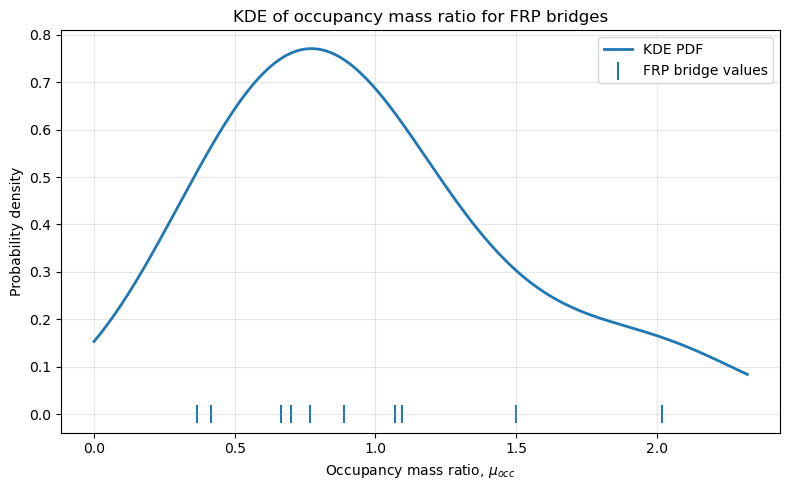

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ==================================================
# KDE PDF OF OCCUPANCY MASS RATIO
# ==================================================

mu_values = mu_df["mu_occ"].dropna().values

# x-range for plotting
x_min = 0.0
x_max = mu_values.max() * 1.15
x_grid = np.linspace(x_min, x_max, 500)

# KDE
kde = gaussian_kde(mu_values)

pdf_values = kde(x_grid)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(8, 5))

plt.plot(x_grid, pdf_values, linewidth=2, label="KDE PDF")

# show individual bridge mass ratios
plt.scatter(mu_values, np.zeros_like(mu_values), marker="|", s=150, label="FRP bridge values")

plt.xlabel("Occupancy mass ratio, $\\mu_{occ}$")
plt.ylabel("Probability density")
plt.title("KDE of occupancy mass ratio for FRP bridges")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

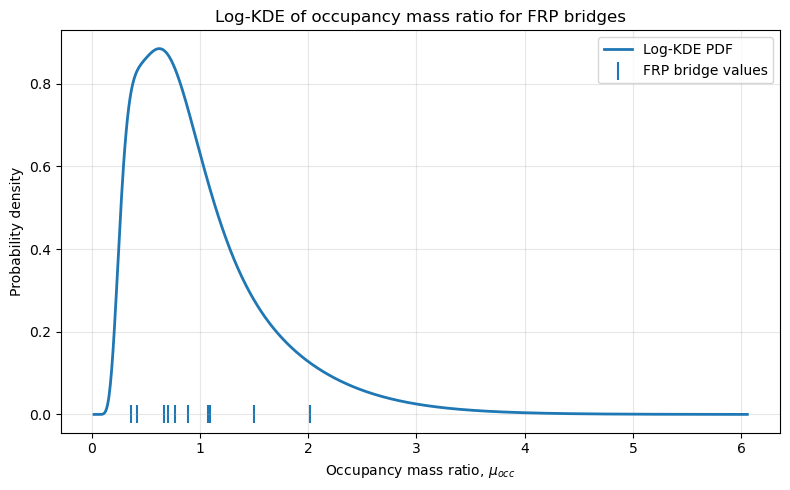

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ==================================================
# LOG-KDE WITH WIDER RANGE
# ==================================================

mu_values = mu_df["mu_occ"].dropna().values
mu_values = mu_values[mu_values > 0]

log_mu = np.log(mu_values)
kde_log = gaussian_kde(log_mu)

# Wider x-range
x_grid = np.linspace(0.02, mu_values.max() * 3.0, 1000)

# Convert log-KDE back to original scale
pdf_values = kde_log(np.log(x_grid)) / x_grid

plt.figure(figsize=(8, 5))

plt.plot(x_grid, pdf_values, linewidth=2, label="Log-KDE PDF")

plt.scatter(
    mu_values,
    np.zeros_like(mu_values),
    marker="|",
    s=150,
    label="FRP bridge values"
)

plt.xlabel(r"Occupancy mass ratio, $\mu_{occ}$")
plt.ylabel("Probability density")
plt.title("Log-KDE of occupancy mass ratio for FRP bridges")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Non-FRP below threshold: 5 / 15
FRP below threshold: 0 / 10

             quantity  mean  median  2.5%  97.5%
               P(FRP) 0.108   0.107 0.072  0.150
P(mu < 0.1 | non-FRP) 0.353   0.347 0.152  0.588
    P(mu < 0.1 | FRP) 0.083   0.061 0.002  0.285
  P(mu < 0.1) overall 0.324   0.318 0.144  0.535


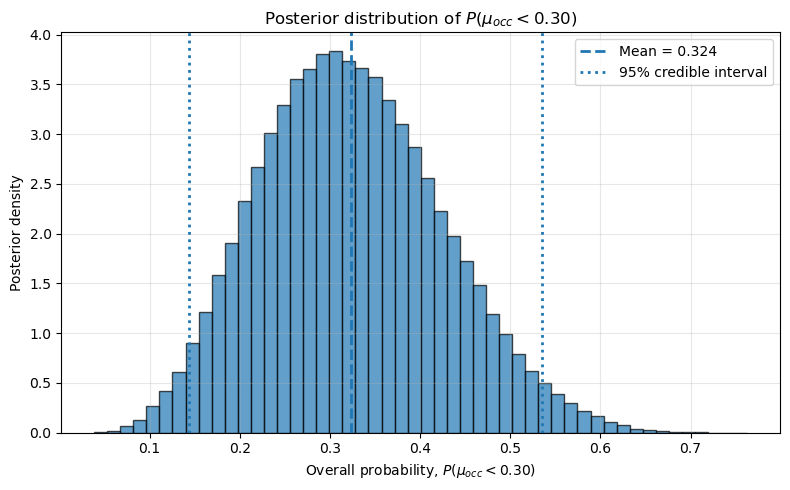

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

THRESHOLD = 0.10
N_SAMPLES = 200_000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# ==================================================
# MASS-RATIO DATA AT rho = 1.5 persons/m^2
# ==================================================

mu_nonfrp = np.array([
    0.068,
    0.067,
    0.071,
    0.229,
    0.096,
    0.105,
    0.104,
    0.126,
    0.054,
    0.833,
    0.349,
    0.238,
    0.180,
    0.183,
    0.274,
])

mu_frp = np.array([
    0.7664,
    0.4167,
    0.7000,
    1.0714,
    0.6646,
    0.8898,
    0.3646,
    2.0192,
    1.0938,
    1.5000,
])

# ==================================================
# SUCCESS / FAILURE COUNTS
# ==================================================

nonfrp_success = np.sum(mu_nonfrp < THRESHOLD)
nonfrp_failure = np.sum(mu_nonfrp >= THRESHOLD)

frp_success = np.sum(mu_frp < THRESHOLD)
frp_failure = np.sum(mu_frp >= THRESHOLD)

print("Non-FRP below threshold:", nonfrp_success, "/", len(mu_nonfrp))
print("FRP below threshold:", frp_success, "/", len(mu_frp))

# ==================================================
# MATERIAL PROPORTION UPDATE
# ==================================================

wei_frp = 14
wei_nonfrp = 124

gong_frp = 11
gong_nonfrp = 89

prior_frp_a = 1
prior_frp_b = 1

post_w_frp_a = prior_frp_a + wei_frp + gong_frp
post_w_frp_b = prior_frp_b + wei_nonfrp + gong_nonfrp

# ==================================================
# CONDITIONAL PROBABILITY UPDATE
# ==================================================

prior_theta_a = 1
prior_theta_b = 1

post_theta_nonfrp_a = prior_theta_a + nonfrp_success
post_theta_nonfrp_b = prior_theta_b + nonfrp_failure

post_theta_frp_a = prior_theta_a + frp_success
post_theta_frp_b = prior_theta_b + frp_failure

# ==================================================
# MONTE CARLO POSTERIOR SIMULATION
# ==================================================

w_frp_samples = rng.beta(post_w_frp_a, post_w_frp_b, size=N_SAMPLES)

theta_nonfrp_samples = rng.beta(
    post_theta_nonfrp_a,
    post_theta_nonfrp_b,
    size=N_SAMPLES
)

theta_frp_samples = rng.beta(
    post_theta_frp_a,
    post_theta_frp_b,
    size=N_SAMPLES
)

p_mu_less_threshold_samples = (
    (1.0 - w_frp_samples) * theta_nonfrp_samples
    + w_frp_samples * theta_frp_samples
)

# ==================================================
# SUMMARY
# ==================================================

def summarize(samples, name):
    mean = np.mean(samples)
    median = np.median(samples)
    q025, q975 = np.quantile(samples, [0.025, 0.975])

    return {
        "quantity": name,
        "mean": mean,
        "median": median,
        "2.5%": q025,
        "97.5%": q975,
    }


summary = pd.DataFrame([
    summarize(w_frp_samples, "P(FRP)"),
    summarize(theta_nonfrp_samples, f"P(mu < {THRESHOLD} | non-FRP)"),
    summarize(theta_frp_samples, f"P(mu < {THRESHOLD} | FRP)"),
    summarize(p_mu_less_threshold_samples, f"P(mu < {THRESHOLD}) overall"),
])

print()
print(summary.round(3).to_string(index=False))

# ==================================================
# PLOT POSTERIOR DISTRIBUTION
# ==================================================

plt.figure(figsize=(8, 5))

plt.hist(
    p_mu_less_threshold_samples,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

plt.axvline(
    np.mean(p_mu_less_threshold_samples),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(p_mu_less_threshold_samples):.3f}"
)

plt.axvline(
    np.quantile(p_mu_less_threshold_samples, 0.025),
    linestyle=":",
    linewidth=2,
    label="95% credible interval"
)

plt.axvline(
    np.quantile(p_mu_less_threshold_samples, 0.975),
    linestyle=":",
    linewidth=2
)

plt.xlabel(r"Overall probability, $P(\mu_{occ}<0.30)$")
plt.ylabel("Posterior density")
plt.title(r"Posterior distribution of $P(\mu_{occ}<0.30)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Non-FRP below threshold: 5 / 15
FRP below threshold: 0 / 10

                       quantity                 posterior  mean  median  2.5%  97.5%
                   w_F = P(FRP)             Beta(26, 214) 0.108   0.107 0.072  0.150
               w_N = P(non-FRP)          Derived: 1 - w_F 0.892   0.893 0.850  0.928
theta_N = P(mu < 0.1 | non-FRP)               Beta(6, 11) 0.353   0.347 0.152  0.588
    theta_F = P(mu < 0.1 | FRP)               Beta(1, 11) 0.083   0.061 0.002  0.285
        p = P(mu < 0.1) overall Derived mixture posterior 0.324   0.318 0.144  0.535


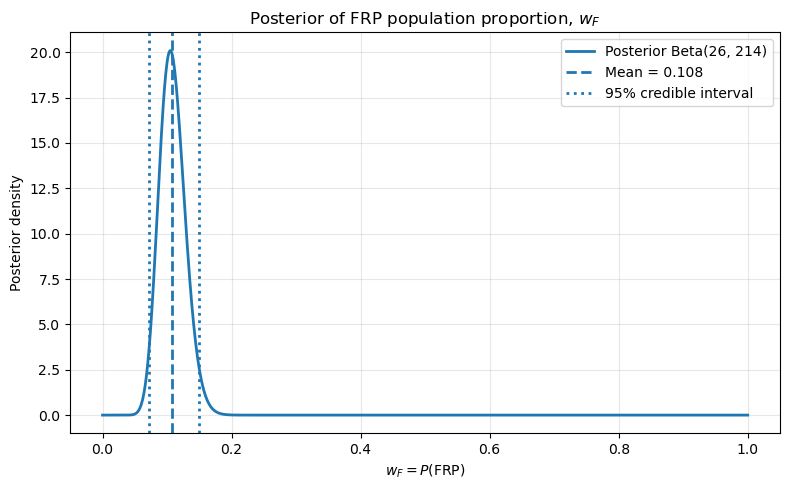

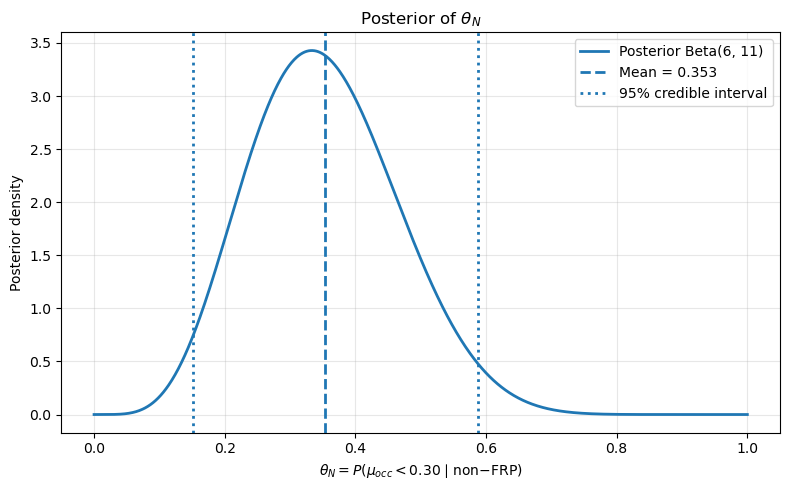

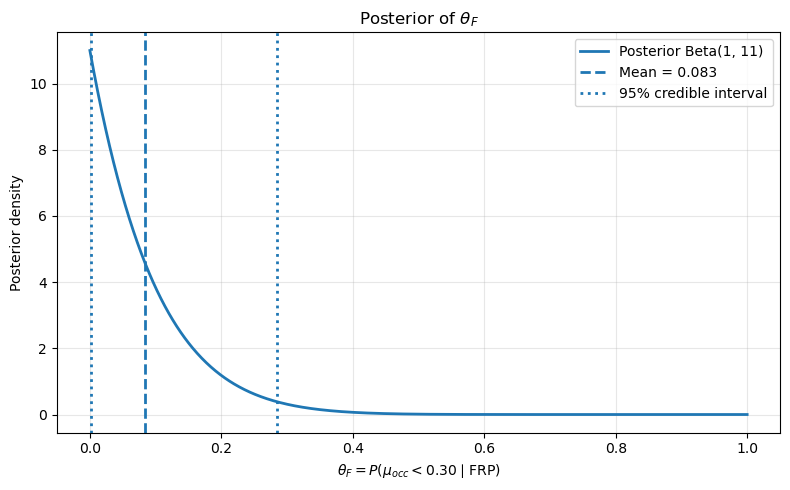

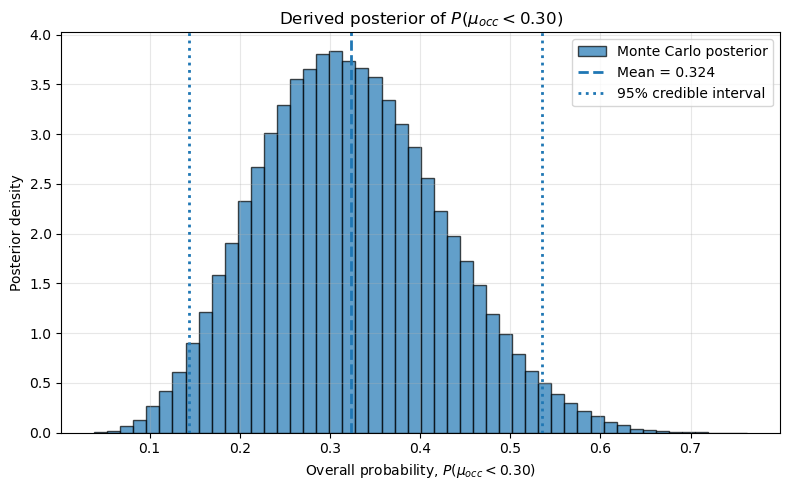

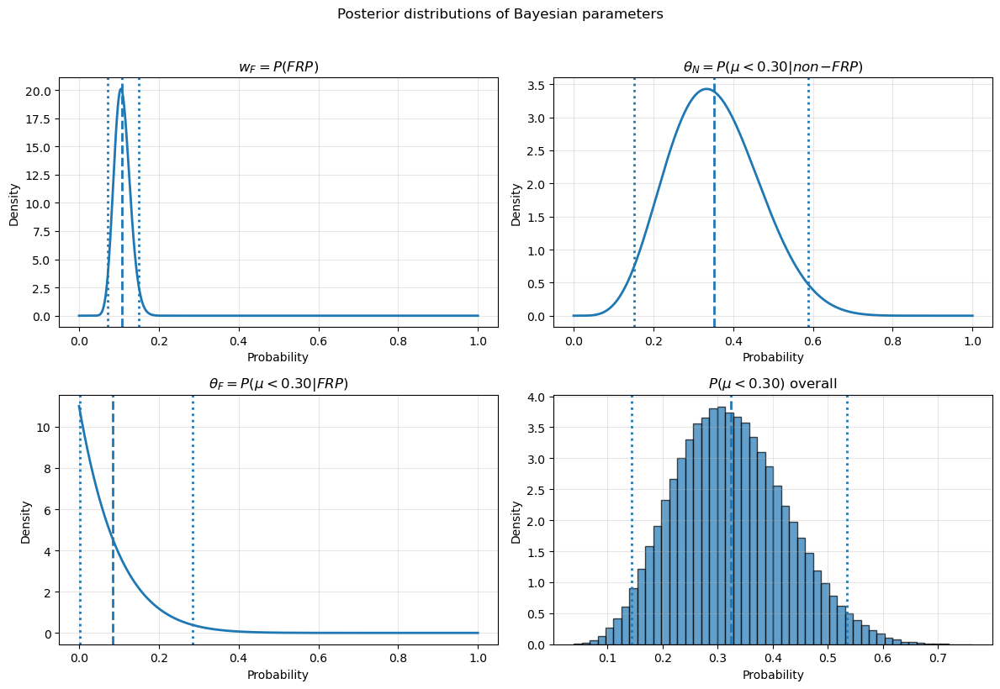

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta

# ==================================================
# SETTINGS
# ==================================================

THRESHOLD = 0.30
N_SAMPLES = 200_000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# ==================================================
# MASS-RATIO DATA AT rho = 1.5 persons/m^2
# ==================================================

mu_nonfrp = np.array([
    0.068,
    0.067,
    0.071,
    0.229,
    0.096,
    0.105,
    0.104,
    0.126,
    0.054,
    0.833,
    0.349,
    0.238,
    0.180,
    0.183,
    0.274,
])

mu_frp = np.array([
    0.7664,
    0.4167,
    0.7000,
    1.0714,
    0.6646,
    0.8898,
    0.3646,
    2.0192,
    1.0938,
    1.5000,
])

# ==================================================
# SUCCESS / FAILURE COUNTS
# ==================================================

nonfrp_success = np.sum(mu_nonfrp < THRESHOLD)
nonfrp_failure = np.sum(mu_nonfrp >= THRESHOLD)

frp_success = np.sum(mu_frp < THRESHOLD)
frp_failure = np.sum(mu_frp >= THRESHOLD)

print("Non-FRP below threshold:", nonfrp_success, "/", len(mu_nonfrp))
print("FRP below threshold:", frp_success, "/", len(mu_frp))

# ==================================================
# MATERIAL PROPORTION UPDATE
# ==================================================

# Wei counts
wei_frp = 14
wei_nonfrp = 124

# Gong counts
gong_frp = 11
gong_nonfrp = 89

# Prior for w_F = P(FRP)
prior_frp_a = 1
prior_frp_b = 1

# Posterior for w_F
post_w_frp_a = prior_frp_a + wei_frp + gong_frp
post_w_frp_b = prior_frp_b + wei_nonfrp + gong_nonfrp

# ==================================================
# CONDITIONAL PROBABILITY UPDATE
# ==================================================

# Prior for theta values
prior_theta_a = 1
prior_theta_b = 1

# theta_N = P(mu < threshold | non-FRP)
post_theta_nonfrp_a = prior_theta_a + nonfrp_success
post_theta_nonfrp_b = prior_theta_b + nonfrp_failure

# theta_F = P(mu < threshold | FRP)
post_theta_frp_a = prior_theta_a + frp_success
post_theta_frp_b = prior_theta_b + frp_failure

# ==================================================
# MONTE CARLO POSTERIOR SIMULATION
# ==================================================

# Direct posterior samples
w_frp_samples = rng.beta(post_w_frp_a, post_w_frp_b, size=N_SAMPLES)

theta_nonfrp_samples = rng.beta(
    post_theta_nonfrp_a,
    post_theta_nonfrp_b,
    size=N_SAMPLES
)

theta_frp_samples = rng.beta(
    post_theta_frp_a,
    post_theta_frp_b,
    size=N_SAMPLES
)

# Derived posterior samples
w_nonfrp_samples = 1.0 - w_frp_samples

p_mu_less_threshold_samples = (
    w_nonfrp_samples * theta_nonfrp_samples
    + w_frp_samples * theta_frp_samples
)

# ==================================================
# SUMMARY
# ==================================================

def summarize(samples, name, posterior_name):
    mean = np.mean(samples)
    median = np.median(samples)
    q025, q975 = np.quantile(samples, [0.025, 0.975])

    return {
        "quantity": name,
        "posterior": posterior_name,
        "mean": mean,
        "median": median,
        "2.5%": q025,
        "97.5%": q975,
    }


summary = pd.DataFrame([
    summarize(
        w_frp_samples,
        "w_F = P(FRP)",
        f"Beta({post_w_frp_a}, {post_w_frp_b})"
    ),
    summarize(
        w_nonfrp_samples,
        "w_N = P(non-FRP)",
        "Derived: 1 - w_F"
    ),
    summarize(
        theta_nonfrp_samples,
        f"theta_N = P(mu < {THRESHOLD} | non-FRP)",
        f"Beta({post_theta_nonfrp_a}, {post_theta_nonfrp_b})"
    ),
    summarize(
        theta_frp_samples,
        f"theta_F = P(mu < {THRESHOLD} | FRP)",
        f"Beta({post_theta_frp_a}, {post_theta_frp_b})"
    ),
    summarize(
        p_mu_less_threshold_samples,
        f"p = P(mu < {THRESHOLD}) overall",
        "Derived mixture posterior"
    ),
])

print()
print(summary.round(3).to_string(index=False))

# ==================================================
# PLOT 1: POSTERIOR OF w_F = P(FRP)
# ==================================================

x = np.linspace(0, 1, 1000)

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    beta.pdf(x, post_w_frp_a, post_w_frp_b),
    linewidth=2,
    label=f"Posterior Beta({post_w_frp_a}, {post_w_frp_b})"
)

plt.axvline(np.mean(w_frp_samples), linestyle="--", linewidth=2,
            label=f"Mean = {np.mean(w_frp_samples):.3f}")

plt.axvline(np.quantile(w_frp_samples, 0.025), linestyle=":", linewidth=2,
            label="95% credible interval")

plt.axvline(np.quantile(w_frp_samples, 0.975), linestyle=":", linewidth=2)

plt.xlabel(r"$w_F = P(\mathrm{FRP})$")
plt.ylabel("Posterior density")
plt.title(r"Posterior of FRP population proportion, $w_F$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# PLOT 2: POSTERIOR OF theta_N
# ==================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    beta.pdf(x, post_theta_nonfrp_a, post_theta_nonfrp_b),
    linewidth=2,
    label=f"Posterior Beta({post_theta_nonfrp_a}, {post_theta_nonfrp_b})"
)

plt.axvline(np.mean(theta_nonfrp_samples), linestyle="--", linewidth=2,
            label=f"Mean = {np.mean(theta_nonfrp_samples):.3f}")

plt.axvline(np.quantile(theta_nonfrp_samples, 0.025), linestyle=":", linewidth=2,
            label="95% credible interval")

plt.axvline(np.quantile(theta_nonfrp_samples, 0.975), linestyle=":", linewidth=2)

plt.xlabel(r"$\theta_N = P(\mu_{occ}<0.30 \mid \mathrm{non\!-\!FRP})$")
plt.ylabel("Posterior density")
plt.title(r"Posterior of $\theta_N$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# PLOT 3: POSTERIOR OF theta_F
# ==================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    beta.pdf(x, post_theta_frp_a, post_theta_frp_b),
    linewidth=2,
    label=f"Posterior Beta({post_theta_frp_a}, {post_theta_frp_b})"
)

plt.axvline(np.mean(theta_frp_samples), linestyle="--", linewidth=2,
            label=f"Mean = {np.mean(theta_frp_samples):.3f}")

plt.axvline(np.quantile(theta_frp_samples, 0.025), linestyle=":", linewidth=2,
            label="95% credible interval")

plt.axvline(np.quantile(theta_frp_samples, 0.975), linestyle=":", linewidth=2)

plt.xlabel(r"$\theta_F = P(\mu_{occ}<0.30 \mid \mathrm{FRP})$")
plt.ylabel("Posterior density")
plt.title(r"Posterior of $\theta_F$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# PLOT 4: DERIVED POSTERIOR OF OVERALL PROBABILITY
# ==================================================

plt.figure(figsize=(8, 5))

plt.hist(
    p_mu_less_threshold_samples,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Monte Carlo posterior"
)

plt.axvline(
    np.mean(p_mu_less_threshold_samples),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(p_mu_less_threshold_samples):.3f}"
)

plt.axvline(
    np.quantile(p_mu_less_threshold_samples, 0.025),
    linestyle=":",
    linewidth=2,
    label="95% credible interval"
)

plt.axvline(
    np.quantile(p_mu_less_threshold_samples, 0.975),
    linestyle=":",
    linewidth=2
)

plt.xlabel(r"Overall probability, $P(\mu_{occ}<0.30)$")
plt.ylabel("Posterior density")
plt.title(r"Derived posterior of $P(\mu_{occ}<0.30)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# OPTIONAL: ALL POSTERIORS IN ONE FIGURE
# ==================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. w_F
axes[0, 0].plot(x, beta.pdf(x, post_w_frp_a, post_w_frp_b), linewidth=2)
axes[0, 0].axvline(np.mean(w_frp_samples), linestyle="--", linewidth=2)
axes[0, 0].axvline(np.quantile(w_frp_samples, 0.025), linestyle=":", linewidth=2)
axes[0, 0].axvline(np.quantile(w_frp_samples, 0.975), linestyle=":", linewidth=2)
axes[0, 0].set_title(r"$w_F = P(FRP)$")
axes[0, 0].set_xlabel("Probability")
axes[0, 0].set_ylabel("Density")
axes[0, 0].grid(True, alpha=0.3)

# 2. theta_N
axes[0, 1].plot(x, beta.pdf(x, post_theta_nonfrp_a, post_theta_nonfrp_b), linewidth=2)
axes[0, 1].axvline(np.mean(theta_nonfrp_samples), linestyle="--", linewidth=2)
axes[0, 1].axvline(np.quantile(theta_nonfrp_samples, 0.025), linestyle=":", linewidth=2)
axes[0, 1].axvline(np.quantile(theta_nonfrp_samples, 0.975), linestyle=":", linewidth=2)
axes[0, 1].set_title(r"$\theta_N = P(\mu<0.30 | non\!-\!FRP)$")
axes[0, 1].set_xlabel("Probability")
axes[0, 1].set_ylabel("Density")
axes[0, 1].grid(True, alpha=0.3)

# 3. theta_F
axes[1, 0].plot(x, beta.pdf(x, post_theta_frp_a, post_theta_frp_b), linewidth=2)
axes[1, 0].axvline(np.mean(theta_frp_samples), linestyle="--", linewidth=2)
axes[1, 0].axvline(np.quantile(theta_frp_samples, 0.025), linestyle=":", linewidth=2)
axes[1, 0].axvline(np.quantile(theta_frp_samples, 0.975), linestyle=":", linewidth=2)
axes[1, 0].set_title(r"$\theta_F = P(\mu<0.30 | FRP)$")
axes[1, 0].set_xlabel("Probability")
axes[1, 0].set_ylabel("Density")
axes[1, 0].grid(True, alpha=0.3)

# 4. overall p
axes[1, 1].hist(
    p_mu_less_threshold_samples,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black"
)
axes[1, 1].axvline(np.mean(p_mu_less_threshold_samples), linestyle="--", linewidth=2)
axes[1, 1].axvline(np.quantile(p_mu_less_threshold_samples, 0.025), linestyle=":", linewidth=2)
axes[1, 1].axvline(np.quantile(p_mu_less_threshold_samples, 0.975), linestyle=":", linewidth=2)
axes[1, 1].set_title(r"$P(\mu<0.30)$ overall")
axes[1, 1].set_xlabel("Probability")
axes[1, 1].set_ylabel("Density")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(r"Posterior distributions of Bayesian parameters", y=1.02)
plt.tight_layout()
plt.show()

In [31]:
import pymc as pm
import arviz as az
import numpy as np

# ==================================================
# DATA
# ==================================================

# Material data: Wei + Gong
n_material_total = 238
k_frp = 25

# Mass-ratio threshold data
# non-FRP: 13 below threshold out of 15
n_nonfrp = 15
k_nonfrp_below = 13

# FRP: 0 below threshold out of 10
n_frp = 10
k_frp_below = 0

THRESHOLD = 0.30

# ==================================================
# PYMC MODEL
# ==================================================

with pm.Model() as model:

    # ------------------------------
    # Priors
    # ------------------------------

    # w_F = P(FRP)
    w_F = pm.Beta("w_F", alpha=1, beta=1)

    # theta_N = P(mu < 0.30 | non-FRP)
    theta_N = pm.Beta("theta_N", alpha=1, beta=1)

    # theta_F = P(mu < 0.30 | FRP)
    theta_F = pm.Beta("theta_F", alpha=1, beta=1)

    # ------------------------------
    # Likelihoods
    # ------------------------------

    # Material-count likelihood
    material_counts = pm.Binomial(
        "material_counts",
        n=n_material_total,
        p=w_F,
        observed=k_frp
    )

    # non-FRP threshold likelihood
    nonfrp_threshold_counts = pm.Binomial(
        "nonfrp_threshold_counts",
        n=n_nonfrp,
        p=theta_N,
        observed=k_nonfrp_below
    )

    # FRP threshold likelihood
    frp_threshold_counts = pm.Binomial(
        "frp_threshold_counts",
        n=n_frp,
        p=theta_F,
        observed=k_frp_below
    )

    # ------------------------------
    # Derived overall probability
    # ------------------------------

    p_overall = pm.Deterministic(
        "p_overall",
        (1.0 - w_F) * theta_N + w_F * theta_F
    )

    # ------------------------------
    # Sampling
    # ------------------------------

    trace = pm.sample(
        draws=4000,
        tune=1000,
        chains=4,
        target_accept=0.95,
        random_seed=42
    )

# ==================================================
# SUMMARY
# ==================================================

summary = az.summary(
    trace,
    var_names=["w_F", "theta_N", "theta_F", "p_overall"],
    hdi_prob=0.95
)

print(summary)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_F, theta_N, theta_F]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 32 seconds.


            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
w_F        0.108  0.020     0.071      0.148      0.000    0.000   14759.0   
theta_N    0.823  0.090     0.647      0.973      0.001    0.001   14121.0   
theta_F    0.085  0.079     0.000      0.244      0.001    0.001   10878.0   
p_overall  0.743  0.082     0.585      0.891      0.001    0.001   14340.0   

           ess_tail  r_hat  
w_F          9530.0    1.0  
theta_N      8978.0    1.0  
theta_F      7196.0    1.0  
p_overall    9896.0    1.0  


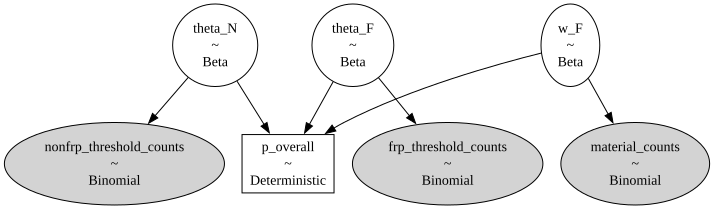

In [32]:
pm.model_to_graphviz(model)

Target event: mu_occ < 0.3
Material data: 25 FRP out of 227 total bridges
Non-FRP data: 13 below threshold out of 15
FRP data:     0 below threshold out of 10

Non-FRP values below threshold:
[0.068 0.067 0.071 0.229 0.096 0.105 0.104 0.126 0.054 0.238 0.18  0.183
 0.274]

FRP values below threshold:
[]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_F, theta_N, theta_F]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 30 seconds.



Posterior summary:
            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
w_F        0.113  0.021     0.074      0.156      0.000    0.000   13838.0   
theta_N    0.825  0.088     0.656      0.978      0.001    0.001   12811.0   
theta_F    0.084  0.077     0.000      0.237      0.001    0.001    9803.0   
p_overall  0.741  0.080     0.580      0.879      0.001    0.001   13169.0   

           ess_tail  r_hat  
w_F         10538.0    1.0  
theta_N      8962.0    1.0  
theta_F      6451.0    1.0  
p_overall    9381.0    1.0  


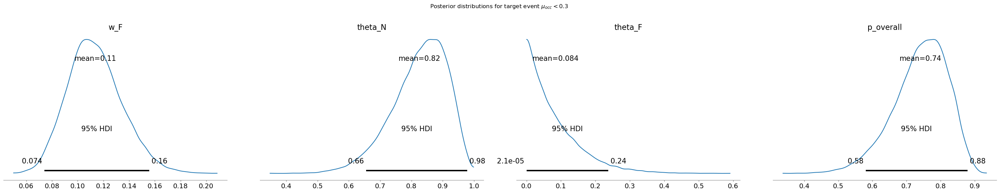

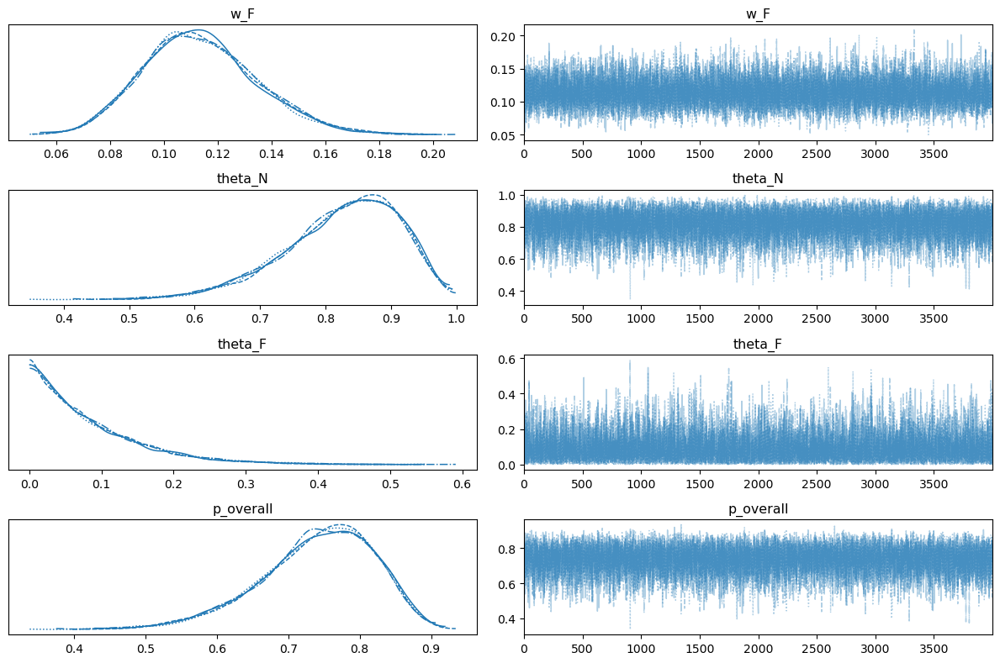

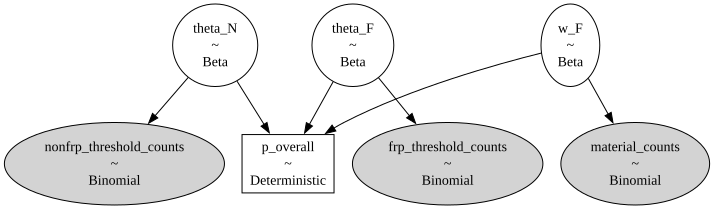

In [33]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

TARGET_THRESHOLD = 0.30   # change this to 0.75, 0.50, etc.
RANDOM_SEED = 42

# ==================================================
# RAW MASS-RATIO DATA AT rho = 1.5 persons/m^2
# ==================================================

mu_nonfrp = np.array([
    0.068,
    0.067,
    0.071,
    0.229,
    0.096,
    0.105,
    0.104,
    0.126,
    0.054,
    0.833,
    0.349,
    0.238,
    0.180,
    0.183,
    0.274,
])

mu_frp = np.array([
    0.7664,
    0.4167,
    0.7000,
    1.0714,
    0.6646,
    0.8898,
    0.3646,
    2.0192,
    1.0938,
    1.5000,
])

# ==================================================
# MATERIAL POPULATION DATA: WEI + GONG
# ==================================================

wei_frp = 14
wei_nonfrp = 118

gong_frp = 11
gong_nonfrp = 84

k_frp_material = wei_frp + gong_frp
n_material_total = wei_frp + wei_nonfrp + gong_frp + gong_nonfrp

# ==================================================
# CONVERT MASS-RATIO DATA INTO THRESHOLD COUNTS
# ==================================================
# Success means: mu_occ < TARGET_THRESHOLD

k_nonfrp_below = np.sum(mu_nonfrp < TARGET_THRESHOLD)
n_nonfrp = len(mu_nonfrp)

k_frp_below = np.sum(mu_frp < TARGET_THRESHOLD)
n_frp = len(mu_frp)

print("==========================================")
print(f"Target event: mu_occ < {TARGET_THRESHOLD}")
print("==========================================")
print(f"Material data: {k_frp_material} FRP out of {n_material_total} total bridges")
print(f"Non-FRP data: {k_nonfrp_below} below threshold out of {n_nonfrp}")
print(f"FRP data:     {k_frp_below} below threshold out of {n_frp}")

print("\nNon-FRP values below threshold:")
print(mu_nonfrp[mu_nonfrp < TARGET_THRESHOLD])

print("\nFRP values below threshold:")
print(mu_frp[mu_frp < TARGET_THRESHOLD])

# ==================================================
# PYMC MODEL
# ==================================================

with pm.Model() as model:

    # --------------------------------------------------
    # PRIORS
    # --------------------------------------------------
    # w_F = P(FRP)
    # probability that a randomly selected bridge is FRP
    w_F = pm.Beta("w_F", alpha=1, beta=1)

    # theta_N = P(mu_occ < threshold | non-FRP)
    # probability that a non-FRP bridge is below the chosen mass-ratio threshold
    theta_N = pm.Beta("theta_N", alpha=1, beta=1)

    # theta_F = P(mu_occ < threshold | FRP)
    # probability that an FRP bridge is below the chosen mass-ratio threshold
    theta_F = pm.Beta("theta_F", alpha=1, beta=1)

    # --------------------------------------------------
    # LIKELIHOODS
    # --------------------------------------------------
    # Material-count likelihood:
    # k_frp_material ~ Binomial(n_material_total, w_F)
    material_counts = pm.Binomial(
        "material_counts",
        n=n_material_total,
        p=w_F,
        observed=k_frp_material
    )

    # Non-FRP threshold likelihood:
    # k_nonfrp_below ~ Binomial(n_nonfrp, theta_N)
    nonfrp_threshold_counts = pm.Binomial(
        "nonfrp_threshold_counts",
        n=n_nonfrp,
        p=theta_N,
        observed=k_nonfrp_below
    )

    # FRP threshold likelihood:
    # k_frp_below ~ Binomial(n_frp, theta_F)
    frp_threshold_counts = pm.Binomial(
        "frp_threshold_counts",
        n=n_frp,
        p=theta_F,
        observed=k_frp_below
    )

    # --------------------------------------------------
    # DERIVED OVERALL PROBABILITY
    # --------------------------------------------------
    # p_overall = P(mu_occ < threshold)
    p_overall = pm.Deterministic(
        "p_overall",
        (1.0 - w_F) * theta_N + w_F * theta_F
    )

    # --------------------------------------------------
    # SAMPLING
    # --------------------------------------------------
    trace = pm.sample(
        draws=4000,
        tune=1000,
        chains=4,
        target_accept=0.95,
        random_seed=RANDOM_SEED
    )

# ==================================================
# SUMMARY
# ==================================================

summary = az.summary(
    trace,
    var_names=["w_F", "theta_N", "theta_F", "p_overall"],
    hdi_prob=0.95
)

print("\nPosterior summary:")
print(summary)

# ==================================================
# PLOT POSTERIORS
# ==================================================

az.plot_posterior(
    trace,
    var_names=["w_F", "theta_N", "theta_F", "p_overall"],
    hdi_prob=0.95
)

plt.suptitle(
    rf"Posterior distributions for target event $\mu_{{occ}} < {TARGET_THRESHOLD}$",
    y=1.02
)

plt.tight_layout()
plt.show()

# ==================================================
# PLOT TRACE DIAGNOSTICS
# ==================================================

az.plot_trace(
    trace,
    var_names=["w_F", "theta_N", "theta_F", "p_overall"]
)

plt.tight_layout()
plt.show()

# ==================================================
# OPTIONAL: MODEL GRAPH
# ==================================================

pm.model_to_graphviz(model)

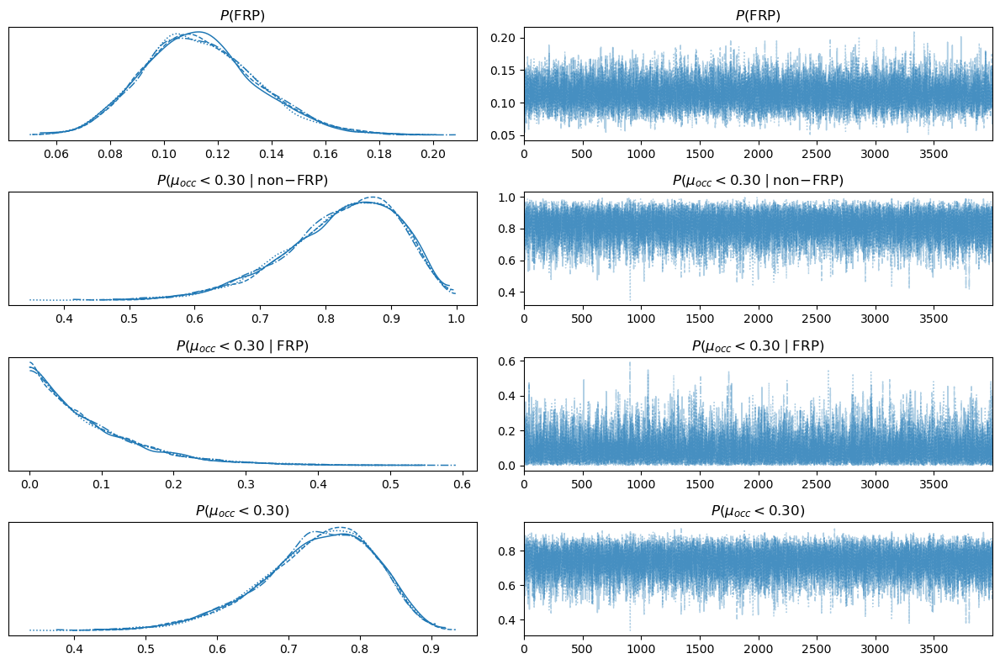

In [34]:
# ==================================================
# PLOT TRACE DIAGNOSTICS WITH PROPER TITLES
# ==================================================

var_names = ["w_F", "theta_N", "theta_F", "p_overall"]

plot_labels = {
    "w_F": r"$P(\mathrm{FRP})$",
    "theta_N": rf"$P(\mu_{{occ}} < {TARGET_THRESHOLD:.2f}\mid \mathrm{{non\!-\!FRP}})$",
    "theta_F": rf"$P(\mu_{{occ}} < {TARGET_THRESHOLD:.2f}\mid \mathrm{{FRP}})$",
    "p_overall": rf"$P(\mu_{{occ}} < {TARGET_THRESHOLD:.2f})$",
}

axes = az.plot_trace(
    trace,
    var_names=var_names,
    figsize=(12, 8)
)

# ArviZ returns axes as [row, column]
# column 0 = posterior density
# column 1 = trace plot
for i, var in enumerate(var_names):
    axes[i, 0].set_title(plot_labels[var], fontsize=12)
    axes[i, 1].set_title(plot_labels[var], fontsize=12)

plt.tight_layout()
plt.show()

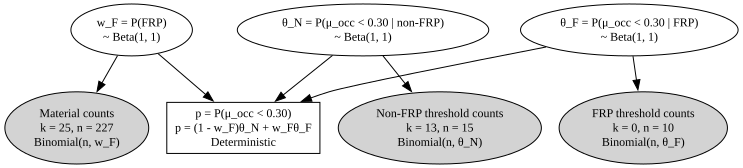

In [35]:
from graphviz import Digraph

# ==================================================
# CUSTOM GRAPHVIZ DAG WITH PROPER NOTATION
# ==================================================

T = TARGET_THRESHOLD  # or THRESHOLD if that is your variable name

dot = Digraph("Bayesian_mass_ratio_model", format="png")

dot.attr(rankdir="TB")
dot.attr("node", fontsize="12", fontname="Times New Roman")
dot.attr("edge", fontsize="10", fontname="Times New Roman")

# --------------------------------------------------
# Prior / parameter nodes
# --------------------------------------------------

dot.node(
    "w_F",
    label=(
        "w_F = P(FRP)\n"
        "~ Beta(1, 1)"
    ),
    shape="ellipse"
)

dot.node(
    "theta_N",
    label=(
        f"θ_N = P(μ_occ < {T:.2f} | non-FRP)\n"
        "~ Beta(1, 1)"
    ),
    shape="ellipse"
)

dot.node(
    "theta_F",
    label=(
        f"θ_F = P(μ_occ < {T:.2f} | FRP)\n"
        "~ Beta(1, 1)"
    ),
    shape="ellipse"
)

# --------------------------------------------------
# Observed likelihood nodes
# --------------------------------------------------

dot.node(
    "material_counts",
    label=(
        "Material counts\n"
        f"k = {k_frp_material}, n = {n_material_total}\n"
        "Binomial(n, w_F)"
    ),
    shape="ellipse",
    style="filled",
    fillcolor="lightgray"
)

dot.node(
    "nonfrp_threshold_counts",
    label=(
        "Non-FRP threshold counts\n"
        f"k = {k_nonfrp_below}, n = {n_nonfrp}\n"
        "Binomial(n, θ_N)"
    ),
    shape="ellipse",
    style="filled",
    fillcolor="lightgray"
)

dot.node(
    "frp_threshold_counts",
    label=(
        "FRP threshold counts\n"
        f"k = {k_frp_below}, n = {n_frp}\n"
        "Binomial(n, θ_F)"
    ),
    shape="ellipse",
    style="filled",
    fillcolor="lightgray"
)

# --------------------------------------------------
# Deterministic final probability
# --------------------------------------------------

dot.node(
    "p_overall",
    label=(
        f"p = P(μ_occ < {T:.2f})\n"
        "p = (1 - w_F)θ_N + w_Fθ_F\n"
        "Deterministic"
    ),
    shape="box"
)

# --------------------------------------------------
# Edges
# --------------------------------------------------

dot.edge("w_F", "material_counts")
dot.edge("theta_N", "nonfrp_threshold_counts")
dot.edge("theta_F", "frp_threshold_counts")

dot.edge("w_F", "p_overall")
dot.edge("theta_N", "p_overall")
dot.edge("theta_F", "p_overall")

# Display in notebook
dot

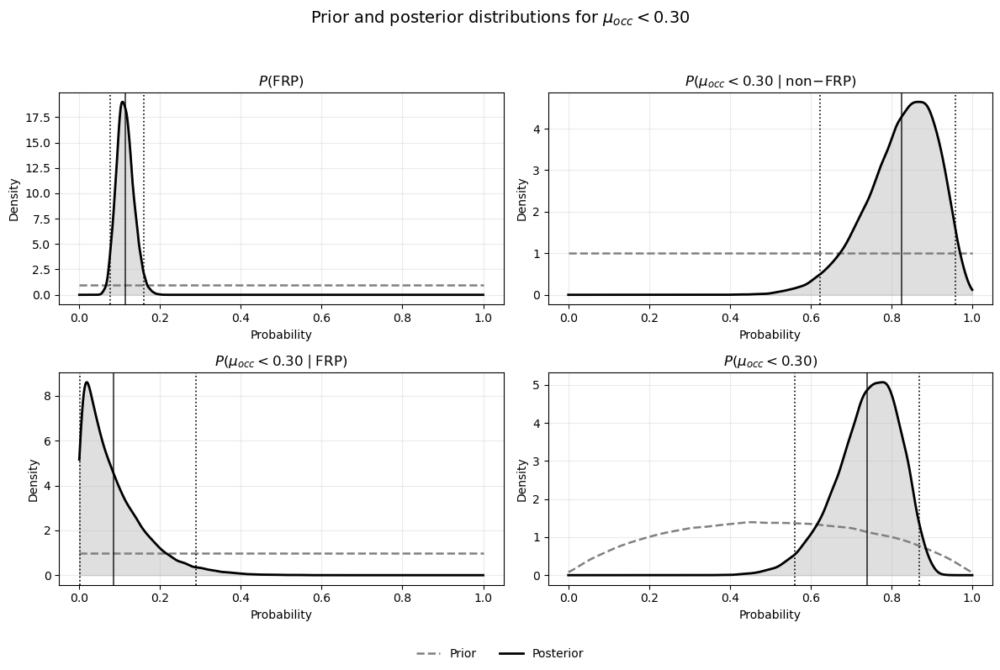

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, gaussian_kde

# ==================================================
# PRIOR VS POSTERIOR PLOTS
# ==================================================

# Number of prior samples for derived prior of p_overall
N_PRIOR_SAMPLES = 200_000
rng = np.random.default_rng(42)

T = TARGET_THRESHOLD

# --------------------------------------------------
# Extract posterior samples from PyMC trace
# --------------------------------------------------

w_F_post = trace.posterior["w_F"].values.ravel()
theta_N_post = trace.posterior["theta_N"].values.ravel()
theta_F_post = trace.posterior["theta_F"].values.ravel()
p_overall_post = trace.posterior["p_overall"].values.ravel()

# --------------------------------------------------
# Prior samples
# --------------------------------------------------
# All three direct priors are Beta(1,1)
# p_overall prior is derived from prior samples:
# p = (1 - w_F) * theta_N + w_F * theta_F

w_F_prior = rng.beta(1, 1, size=N_PRIOR_SAMPLES)
theta_N_prior = rng.beta(1, 1, size=N_PRIOR_SAMPLES)
theta_F_prior = rng.beta(1, 1, size=N_PRIOR_SAMPLES)

p_overall_prior = (
    (1.0 - w_F_prior) * theta_N_prior
    + w_F_prior * theta_F_prior
)

# --------------------------------------------------
# Helper function for KDE plot
# --------------------------------------------------

def kde_curve(samples, x_grid):
    kde = gaussian_kde(samples)
    return kde(x_grid)

# --------------------------------------------------
# X-grid
# --------------------------------------------------

x = np.linspace(0, 1, 1000)

# --------------------------------------------------
# Plot setup
# --------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

plot_info = [
    {
        "title": r"$P(\mathrm{FRP})$",
        "prior_pdf": beta.pdf(x, 1, 1),
        "posterior_samples": w_F_post,
    },
    {
        "title": rf"$P(\mu_{{occ}} < {T:.2f}\mid \mathrm{{non\!-\!FRP}})$",
        "prior_pdf": beta.pdf(x, 1, 1),
        "posterior_samples": theta_N_post,
    },
    {
        "title": rf"$P(\mu_{{occ}} < {T:.2f}\mid \mathrm{{FRP}})$",
        "prior_pdf": beta.pdf(x, 1, 1),
        "posterior_samples": theta_F_post,
    },
    {
        "title": rf"$P(\mu_{{occ}} < {T:.2f})$",
        "prior_pdf": kde_curve(p_overall_prior, x),
        "posterior_samples": p_overall_post,
    },
]

# --------------------------------------------------
# Draw plots
# --------------------------------------------------

for ax, info in zip(axes, plot_info):

    posterior_pdf = kde_curve(info["posterior_samples"], x)

    # prior: dashed line
    ax.plot(
        x,
        info["prior_pdf"],
        linestyle="--",
        linewidth=1.8,
        color="gray",
        label="Prior"
    )

    # posterior: solid line
    ax.plot(
        x,
        posterior_pdf,
        linestyle="-",
        linewidth=2.0,
        color="black",
        label="Posterior"
    )

    # shaded posterior
    ax.fill_between(
        x,
        posterior_pdf,
        alpha=0.25,
        color="gray"
    )

    # posterior mean
    post_mean = np.mean(info["posterior_samples"])
    ax.axvline(
        post_mean,
        linestyle="-",
        linewidth=1.2,
        color="black",
        alpha=0.8
    )

    # posterior 95% credible interval
    q025, q975 = np.quantile(info["posterior_samples"], [0.025, 0.975])
    ax.axvline(q025, linestyle=":", linewidth=1.2, color="black")
    ax.axvline(q975, linestyle=":", linewidth=1.2, color="black")

    ax.set_title(info["title"], fontsize=12)
    ax.set_xlabel("Probability")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.25)

# --------------------------------------------------
# Common legend
# --------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False
)

plt.suptitle(
    rf"Prior and posterior distributions for $\mu_{{occ}} < {T:.2f}$",
    fontsize=14,
    y=0.98
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

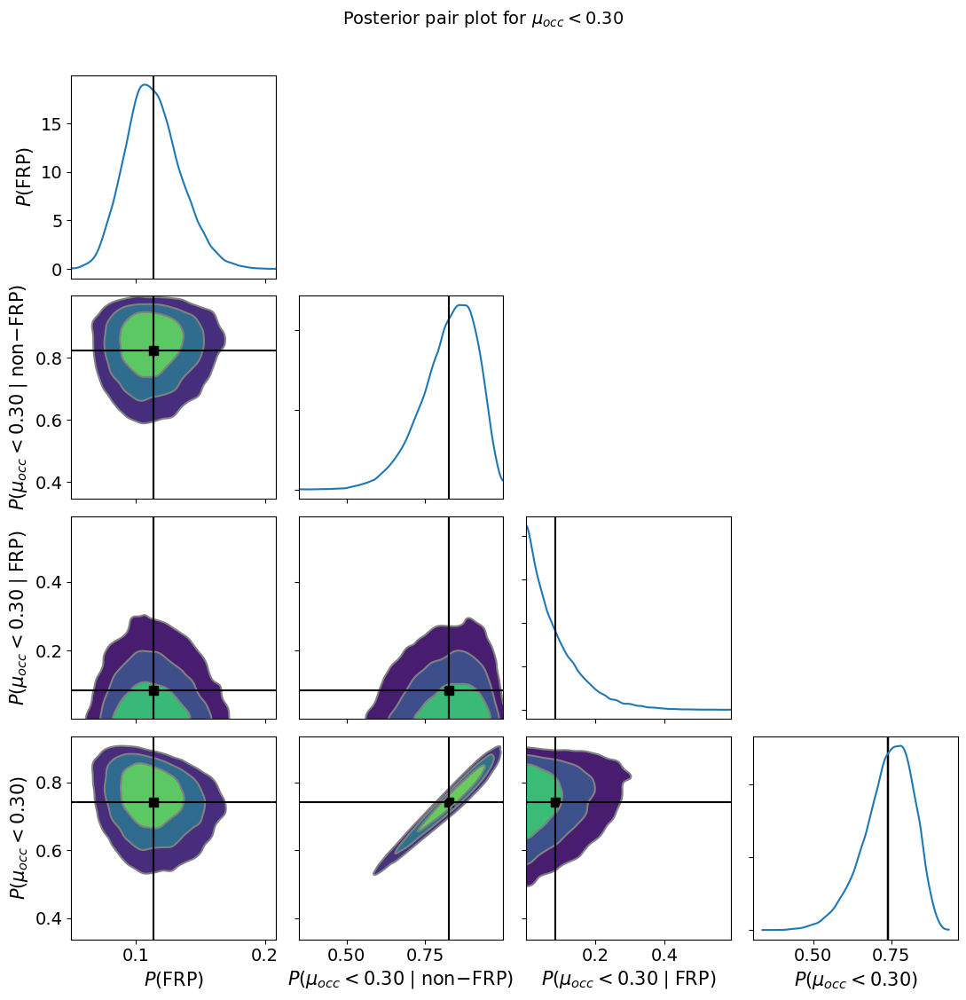

In [ ]:
# ==================================================
# POSTERIOR PAIR PLOT
# ==================================================

import arviz as az
import matplotlib.pyplot as plt

# Use whichever threshold variable exists in your code
try:
    T = TARGET_THRESHOLD
except NameError:
    T = THRESHOLD

var_names = ["w_F", "theta_N", "theta_F", "p_overall"]

label_map = {
    "w_F": r"$P(\mathrm{FRP})$",
    "theta_N": rf"$P(\mu_{{occ}} < {T:.2f}\mid \mathrm{{non\!-\!FRP}})$",
    "theta_F": rf"$P(\mu_{{occ}} < {T:.2f}\mid \mathrm{{FRP}})$",
    "p_overall": rf"$P(\mu_{{occ}} < {T:.2f})$",
}

labeller = az.labels.MapLabeller(var_name_map=label_map)

az.plot_pair(
    trace,
    var_names=var_names,
    kind="kde",          # joint posterior density contours
    marginals=True,      # posterior distributions on the diagonal
    point_estimate="mean",
    labeller=labeller,
    figsize=(11, 11),
)

plt.suptitle(
    rf"Posterior pair plot for $\mu_{{occ}} < {T:.2f}$",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

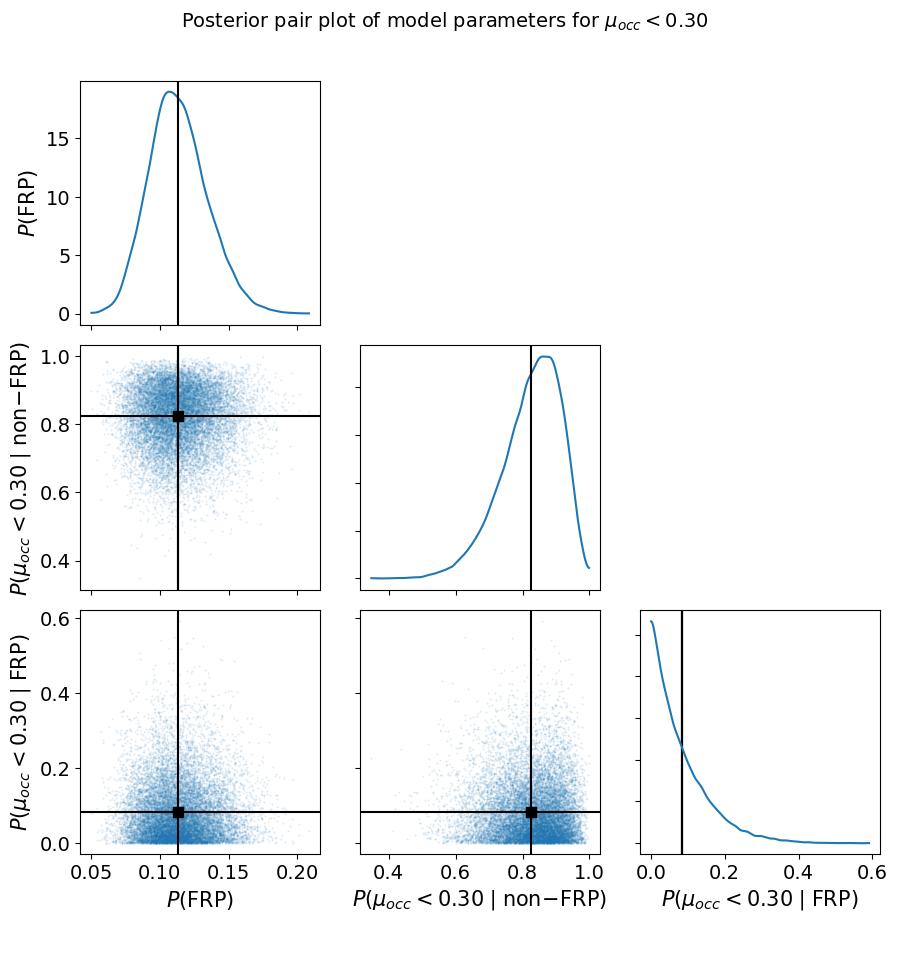

In [39]:
# ==================================================
# PAIR PLOT ONLY FOR STOCHASTIC MODEL PARAMETERS
# ==================================================

import arviz as az
import matplotlib.pyplot as plt

try:
    T = TARGET_THRESHOLD
except NameError:
    T = THRESHOLD

label_map = {
    "w_F": r"$P(\mathrm{FRP})$",
    "theta_N": rf"$P(\mu_{{occ}} < {T:.2f}\mid \mathrm{{non\!-\!FRP}})$",
    "theta_F": rf"$P(\mu_{{occ}} < {T:.2f}\mid \mathrm{{FRP}})$",
}

labeller = az.labels.MapLabeller(var_name_map=label_map)

az.plot_pair(
    trace,
    var_names=["w_F", "theta_N", "theta_F"],
    kind="scatter",          # closer to the example you showed
    marginals=True,
    point_estimate="mean",
    labeller=labeller,
    figsize=(9, 9),
    scatter_kwargs={"alpha": 0.15, "s": 8}
)

plt.suptitle(
    rf"Posterior pair plot of model parameters for $\mu_{{occ}} < {T:.2f}$",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

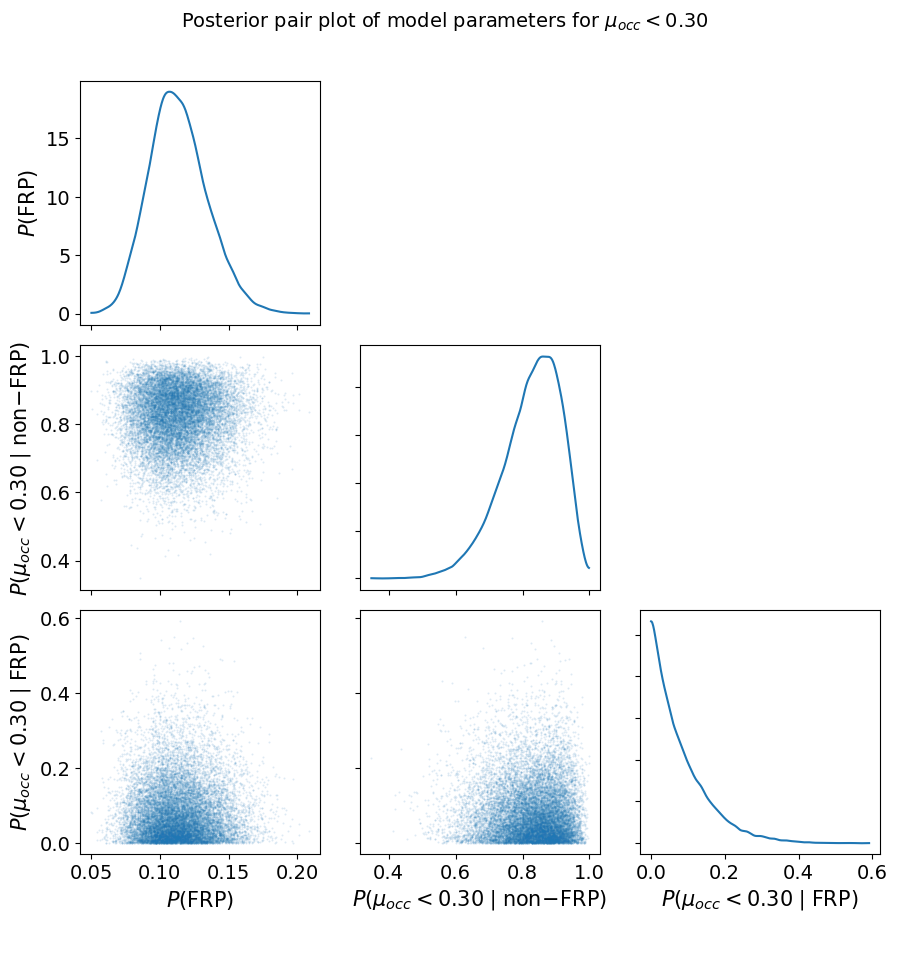


Posterior correlation matrix: stochastic model parameters
                        P(FRP)  P(mu < 0.30 | non-FRP)  P(mu < 0.30 | FRP)
P(FRP)                   1.000                   0.010              -0.001
P(mu < 0.30 | non-FRP)   0.010                   1.000              -0.026
P(mu < 0.30 | FRP)      -0.001                  -0.026               1.000

Posterior correlation matrix: including derived overall probability
                        P(FRP)  P(mu < 0.30 | non-FRP)  P(mu < 0.30 | FRP)  P(mu < 0.30) overall
P(FRP)                   1.000                   0.010              -0.001                -0.187
P(mu < 0.30 | non-FRP)   0.010                   1.000              -0.026                 0.974
P(mu < 0.30 | FRP)      -0.001                  -0.026               1.000                 0.084
P(mu < 0.30) overall    -0.187                   0.974               0.084                 1.000


In [41]:
# ==================================================
# PAIR PLOT ONLY FOR STOCHASTIC MODEL PARAMETERS
# + POSTERIOR CORRELATION MATRIX
# ==================================================

import arviz as az
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    T = TARGET_THRESHOLD
except NameError:
    T = THRESHOLD

# --------------------------------------------------
# Labels for plotting
# --------------------------------------------------

label_map = {
    "w_F": r"$P(\mathrm{FRP})$",
    "theta_N": rf"$P(\mu_{{occ}} < {T:.2f}\mid \mathrm{{non\!-\!FRP}})$",
    "theta_F": rf"$P(\mu_{{occ}} < {T:.2f}\mid \mathrm{{FRP}})$",
}

labeller = az.labels.MapLabeller(var_name_map=label_map)

# --------------------------------------------------
# Pair plot
# --------------------------------------------------

az.plot_pair(
    trace,
    var_names=["w_F", "theta_N", "theta_F"],
    kind="scatter",
    marginals=True,
    labeller=labeller,
    figsize=(9, 9),
    scatter_kwargs={"alpha": 0.15, "s": 8}
)

plt.suptitle(
    rf"Posterior pair plot of model parameters for $\mu_{{occ}} < {T:.2f}$",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

# ==================================================
# POSTERIOR CORRELATION NUMBERS
# ==================================================

# Extract posterior samples and flatten chains/draws
posterior_samples = pd.DataFrame({
    "P(FRP)": trace.posterior["w_F"].values.ravel(),
    f"P(mu < {T:.2f} | non-FRP)": trace.posterior["theta_N"].values.ravel(),
    f"P(mu < {T:.2f} | FRP)": trace.posterior["theta_F"].values.ravel(),
})

# Pearson correlation
corr_matrix = posterior_samples.corr(method="pearson")

print("\nPosterior correlation matrix: stochastic model parameters")
print(corr_matrix.round(3).to_string())

# --------------------------------------------------
# Optional: include derived p_overall too
# --------------------------------------------------

posterior_samples_with_overall = pd.DataFrame({
    "P(FRP)": trace.posterior["w_F"].values.ravel(),
    f"P(mu < {T:.2f} | non-FRP)": trace.posterior["theta_N"].values.ravel(),
    f"P(mu < {T:.2f} | FRP)": trace.posterior["theta_F"].values.ravel(),
    f"P(mu < {T:.2f}) overall": trace.posterior["p_overall"].values.ravel(),
})

corr_matrix_with_overall = posterior_samples_with_overall.corr(method="pearson")

print("\nPosterior correlation matrix: including derived overall probability")
print(corr_matrix_with_overall.round(3).to_string())

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# THRESHOLD SWEEP SETTINGS
# ==================================================

RANDOM_SEED = 42
N_POSTERIOR_SAMPLES = 50000

# Threshold range for the p-box
# You can change this, e.g. 0 to 1.0, or 0 to max observed mu
all_mu = np.concatenate([mu_nonfrp, mu_frp])
T_grid = np.linspace(0.0, all_mu.max() * 1.05, 300)

rng = np.random.default_rng(RANDOM_SEED)

# ==================================================
# MATERIAL POSTERIOR: P(FRP)
# ==================================================
# Prior: w_F ~ Beta(1,1)
# Posterior: w_F | data ~ Beta(1 + k_frp, 1 + n_total - k_frp)

w_F_samples = rng.beta(
    1 + k_frp_material,
    1 + n_material_total - k_frp_material,
    size=N_POSTERIOR_SAMPLES
)

# ==================================================
# RUN THRESHOLD SWEEP
# ==================================================

rows = []

for T in T_grid:

    # Counts below threshold
    k_nonfrp_below = np.sum(mu_nonfrp < T)
    k_frp_below = np.sum(mu_frp < T)

    n_nonfrp = len(mu_nonfrp)
    n_frp = len(mu_frp)

    # --------------------------------------------------
    # Posterior for each threshold
    # --------------------------------------------------
    # theta_N(T) = P(mu_occ < T | non-FRP)
    theta_N_samples = rng.beta(
        1 + k_nonfrp_below,
        1 + n_nonfrp - k_nonfrp_below,
        size=N_POSTERIOR_SAMPLES
    )

    # theta_F(T) = P(mu_occ < T | FRP)
    theta_F_samples = rng.beta(
        1 + k_frp_below,
        1 + n_frp - k_frp_below,
        size=N_POSTERIOR_SAMPLES
    )

    # Overall probability:
    # P(mu_occ < T) = (1 - P(FRP))*theta_N + P(FRP)*theta_F
    p_overall_samples = (
        (1.0 - w_F_samples) * theta_N_samples
        + w_F_samples * theta_F_samples
    )

    rows.append({
        "T": T,

        "k_nonfrp_below": k_nonfrp_below,
        "n_nonfrp": n_nonfrp,

        "k_frp_below": k_frp_below,
        "n_frp": n_frp,

        # Non-FRP CDF posterior
        "theta_N_mean": np.mean(theta_N_samples),
        "theta_N_q05": np.quantile(theta_N_samples, 0.05),
        "theta_N_q50": np.quantile(theta_N_samples, 0.50),
        "theta_N_q95": np.quantile(theta_N_samples, 0.95),

        # FRP CDF posterior
        "theta_F_mean": np.mean(theta_F_samples),
        "theta_F_q05": np.quantile(theta_F_samples, 0.05),
        "theta_F_q50": np.quantile(theta_F_samples, 0.50),
        "theta_F_q95": np.quantile(theta_F_samples, 0.95),

        # Overall CDF posterior
        "p_overall_mean": np.mean(p_overall_samples),
        "p_overall_q05": np.quantile(p_overall_samples, 0.05),
        "p_overall_q50": np.quantile(p_overall_samples, 0.50),
        "p_overall_q95": np.quantile(p_overall_samples, 0.95),
    })

pbox_df = pd.DataFrame(rows)

print(pbox_df.head())
print(pbox_df.tail())

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

RANDOM_SEED = 42
N_POSTERIOR_SAMPLES = 50000

# Number of threshold points used for the p-box
N_T_VALUES = 300

# Prior settings
# Beta(1,1) = uniform prior
A_PRIOR = 1
B_PRIOR = 1

# ==================================================
# RAW MASS-RATIO DATA AT rho = 1.5 persons/m^2
# ==================================================

mu_nonfrp = np.array([
    0.068,
    0.067,
    0.071,
    0.229,
    0.096,
    0.105,
    0.104,
    0.126,
    0.054,
    0.833,
    0.349,
    0.238,
    0.180,
    0.183,
    0.274,
])

mu_frp = np.array([
    0.7664,
    0.4167,
    0.7000,
    1.0714,
    0.6646,
    0.8898,
    0.3646,
    2.0192,
    1.0938,
    1.5000,
])

# ==================================================
# MATERIAL POPULATION DATA: WEI + GONG
# ==================================================

wei_frp = 14
wei_nonfrp = 118

gong_frp = 11
gong_nonfrp = 84

k_frp_material = wei_frp + gong_frp
n_material_total = wei_frp + wei_nonfrp + gong_frp + gong_nonfrp

# ==================================================
# ORGANISE RAW DATA INTO A TABLE
# ==================================================

data_df = pd.DataFrame({
    "bridge_type": (
        ["non-FRP"] * len(mu_nonfrp)
        + ["FRP"] * len(mu_frp)
    ),
    "mu_occ": np.concatenate([mu_nonfrp, mu_frp])
})

print("==========================================")
print("Raw mass-ratio data")
print("==========================================")
print(data_df.to_string(index=False))

print("\n==========================================")
print("Material population data")
print("==========================================")
print(f"Wei:  {wei_frp} FRP, {wei_nonfrp} non-FRP")
print(f"Gong: {gong_frp} FRP, {gong_nonfrp} non-FRP")
print(f"Combined: {k_frp_material} FRP out of {n_material_total} total bridges")

# ==================================================
# THRESHOLD GRID FOR P-BOX
# ==================================================

all_mu = data_df["mu_occ"].values

T_min = 0.0
T_max = all_mu.max() * 1.05

T_grid = np.linspace(T_min, T_max, N_T_VALUES)

print("\n==========================================")
print("Threshold sweep settings")
print("==========================================")
print(f"T_min = {T_grid.min():.5f}")
print(f"T_max = {T_grid.max():.5f}")
print(f"Number of threshold values = {len(T_grid)}")
print(f"Threshold step size = {T_grid[1] - T_grid[0]:.5f}")

# ==================================================
# RANDOM GENERATOR
# ==================================================

rng = np.random.default_rng(RANDOM_SEED)

# ==================================================
# MATERIAL POSTERIOR: P(FRP)
# ==================================================
# w_F = P(FRP)
#
# Prior:
# w_F ~ Beta(1,1)
#
# Likelihood:
# k_frp_material ~ Binomial(n_material_total, w_F)
#
# Posterior:
# w_F | data ~ Beta(1 + k_frp_material,
#                   1 + n_material_total - k_frp_material)

w_F_samples = rng.beta(
    A_PRIOR + k_frp_material,
    B_PRIOR + n_material_total - k_frp_material,
    size=N_POSTERIOR_SAMPLES
)

# ==================================================
# RUN THRESHOLD SWEEP
# ==================================================

rows = []

n_nonfrp = len(mu_nonfrp)
n_frp = len(mu_frp)

for T in T_grid:

    # --------------------------------------------------
    # Count how many mass ratios are below this threshold
    # --------------------------------------------------
    # Success means:
    # mu_occ < T

    k_nonfrp_below = np.sum(mu_nonfrp < T)
    k_frp_below = np.sum(mu_frp < T)

    # --------------------------------------------------
    # Posterior for non-FRP CDF at this threshold
    # --------------------------------------------------
    # theta_N(T) = P(mu_occ < T | non-FRP)
    #
    # theta_N(T) | data ~ Beta(1 + k_nonfrp_below,
    #                          1 + n_nonfrp - k_nonfrp_below)

    theta_N_samples = rng.beta(
        A_PRIOR + k_nonfrp_below,
        B_PRIOR + n_nonfrp - k_nonfrp_below,
        size=N_POSTERIOR_SAMPLES
    )

    # --------------------------------------------------
    # Posterior for FRP CDF at this threshold
    # --------------------------------------------------
    # theta_F(T) = P(mu_occ < T | FRP)

    theta_F_samples = rng.beta(
        A_PRIOR + k_frp_below,
        B_PRIOR + n_frp - k_frp_below,
        size=N_POSTERIOR_SAMPLES
    )

    # --------------------------------------------------
    # Overall posterior CDF at this threshold
    # --------------------------------------------------
    # P(mu_occ < T)
    # =
    # (1 - P(FRP)) * P(mu_occ < T | non-FRP)
    # +
    # P(FRP) * P(mu_occ < T | FRP)

    p_overall_samples = (
        (1.0 - w_F_samples) * theta_N_samples
        + w_F_samples * theta_F_samples
    )

    # --------------------------------------------------
    # Store results
    # --------------------------------------------------

    rows.append({
        "T": T,

        # Raw threshold counts
        "k_nonfrp_below": k_nonfrp_below,
        "n_nonfrp": n_nonfrp,
        "k_frp_below": k_frp_below,
        "n_frp": n_frp,

        # Empirical proportions
        "empirical_nonfrp": k_nonfrp_below / n_nonfrp,
        "empirical_frp": k_frp_below / n_frp,

        # Non-FRP posterior CDF
        "theta_N_mean": np.mean(theta_N_samples),
        "theta_N_q05": np.quantile(theta_N_samples, 0.05),
        "theta_N_q50": np.quantile(theta_N_samples, 0.50),
        "theta_N_q95": np.quantile(theta_N_samples, 0.95),

        # FRP posterior CDF
        "theta_F_mean": np.mean(theta_F_samples),
        "theta_F_q05": np.quantile(theta_F_samples, 0.05),
        "theta_F_q50": np.quantile(theta_F_samples, 0.50),
        "theta_F_q95": np.quantile(theta_F_samples, 0.95),

        # Overall posterior CDF
        "p_overall_mean": np.mean(p_overall_samples),
        "p_overall_q05": np.quantile(p_overall_samples, 0.05),
        "p_overall_q50": np.quantile(p_overall_samples, 0.50),
        "p_overall_q95": np.quantile(p_overall_samples, 0.95),
    })

pbox_df = pd.DataFrame(rows)

print("\n==========================================")
print("P-box dataframe preview")
print("==========================================")
print(pbox_df.head().to_string(index=False))
print("\n...")
print(pbox_df.tail().to_string(index=False))

Raw mass-ratio data
bridge_type  mu_occ
    non-FRP  0.0680
    non-FRP  0.0670
    non-FRP  0.0710
    non-FRP  0.2290
    non-FRP  0.0960
    non-FRP  0.1050
    non-FRP  0.1040
    non-FRP  0.1260
    non-FRP  0.0540
    non-FRP  0.8330
    non-FRP  0.3490
    non-FRP  0.2380
    non-FRP  0.1800
    non-FRP  0.1830
    non-FRP  0.2740
        FRP  0.7664
        FRP  0.4167
        FRP  0.7000
        FRP  1.0714
        FRP  0.6646
        FRP  0.8898
        FRP  0.3646
        FRP  2.0192
        FRP  1.0938
        FRP  1.5000

Material population data
Wei:  14 FRP, 118 non-FRP
Gong: 11 FRP, 84 non-FRP
Combined: 25 FRP out of 227 total bridges

Threshold sweep settings
T_min = 0.00000
T_max = 2.12016
Number of threshold values = 300
Threshold step size = 0.00709

P-box dataframe preview
       T  k_nonfrp_below  n_nonfrp  k_frp_below  n_frp  empirical_nonfrp  empirical_frp  theta_N_mean  theta_N_q05  theta_N_q50  theta_N_q95  theta_F_mean  theta_F_q05  theta_F_q50  theta_F_q95  

At T = 0.30
Posterior median P(mu_occ < T) = 0.7283
Posterior mean   P(mu_occ < T) = 0.7173
90% posterior interval = [0.5564, 0.8405]
As percentage = 72.8%


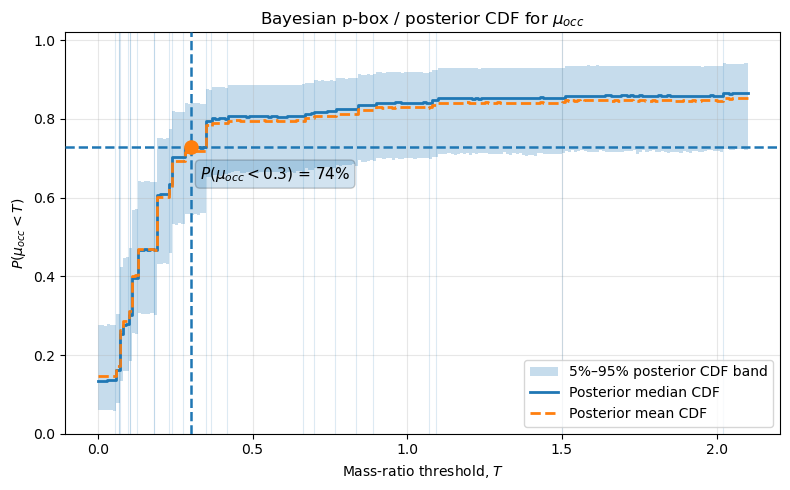

In [ ]:
# ==================================================
# PLOT OVERALL BAYESIAN P-BOX
# ==================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(
    pbox_df["T"],
    pbox_df["p_overall_q05"],
    pbox_df["p_overall_q95"],
    alpha=0.25,
    step="post",
    label="5%–95% posterior CDF band"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_q50"],
    where="post",
    linewidth=2,
    label="Posterior median CDF"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_mean"],
    where="post",
    linestyle="--",
    linewidth=2,
    label="Posterior mean CDF"
)
# ==================================================
# MARK TARGET THRESHOLD ON P-BOX
# ==================================================

TARGET_T = 0.30

# Get posterior median probability at TARGET_T
# Works even if TARGET_T is between two grid values
p_target_median = np.interp(
    TARGET_T,
    pbox_df["T"],
    pbox_df["p_overall_q50"]
)

p_target_mean = np.interp(
    TARGET_T,
    pbox_df["T"],
    pbox_df["p_overall_mean"]
)

p_target_q05 = np.interp(
    TARGET_T,
    pbox_df["T"],
    pbox_df["p_overall_q05"]
)

p_target_q95 = np.interp(
    TARGET_T,
    pbox_df["T"],
    pbox_df["p_overall_q95"]
)

print("==========================================")
print(f"At T = {TARGET_T:.2f}")
print("==========================================")
print(f"Posterior median P(mu_occ < T) = {p_target_median:.4f}")
print(f"Posterior mean   P(mu_occ < T) = {p_target_mean:.4f}")
print(f"90% posterior interval = [{p_target_q05:.4f}, {p_target_q95:.4f}]")
print(f"As percentage = {p_target_median*100:.1f}%")

# Vertical line at T = 0.30
ax.axvline(
    TARGET_T,
    linestyle="--",
    linewidth=1.8,
    zorder=6
)

# Horizontal line at P(mu < 0.30)
ax.axhline(
    p_target_median,
    linestyle="--",
    linewidth=1.8,
    zorder=6
)

# Marker point
ax.scatter(
    [TARGET_T],
    [p_target_median],
    s=90,
    zorder=8
)

# Text label
ax.text(
    TARGET_T + 0.03,
    p_target_median - 0.08,
    rf"$P(\mu_{{occ}} < {TARGET_T})$ = {p_target_median*100:.1f}%",
    fontsize=11,
    bbox=dict(boxstyle="round", alpha=0.20),
    zorder=9
)
# Show raw mass-ratio observations
for x in mu_nonfrp:
    ax.axvline(x, alpha=0.15, linewidth=0.8)

for x in mu_frp:
    ax.axvline(x, alpha=0.15, linewidth=0.8)

ax.set_xlabel(r"Mass-ratio threshold, $T$")
ax.set_ylabel(r"$P(\mu_{occ} < T)$")
ax.set_title(r"Bayesian p-box / posterior CDF for $\mu_{occ}$")

ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

RANDOM_SEED = 42

# Number of threshold values for the p-box
N_T_VALUES = 3

# PyMC sampling settings
DRAWS = 4000
TUNE = 1000
CHAINS = 4
TARGET_ACCEPT = 0.95

# ==================================================
# RAW MASS-RATIO DATA AT rho = 1.5 persons/m^2
# ==================================================

mu_nonfrp = np.array([
    0.068,
    0.067,
    0.071,
    0.229,
    0.096,
    0.105,
    0.104,
    0.126,
    0.054,
    0.833,
    0.349,
    0.238,
    0.180,
    0.183,
    0.274,
])

mu_frp = np.array([
    0.7664,
    0.4167,
    0.7000,
    1.0714,
    0.6646,
    0.8898,
    0.3646,
    2.0192,
    1.0938,
    1.5000,
])

# ==================================================
# MATERIAL POPULATION DATA: WEI + GONG
# ==================================================

wei_frp = 14
wei_nonfrp = 118

gong_frp = 11
gong_nonfrp = 84

k_frp_material = wei_frp + gong_frp
n_material_total = wei_frp + wei_nonfrp + gong_frp + gong_nonfrp

# ==================================================
# DISPLAY DATA
# ==================================================

data_df = pd.DataFrame({
    "bridge_type": ["non-FRP"] * len(mu_nonfrp) + ["FRP"] * len(mu_frp),
    "mu_occ": np.concatenate([mu_nonfrp, mu_frp])
})

print("==========================================")
print("Mass-ratio data")
print("==========================================")
print(data_df.to_string(index=False))

print("\n==========================================")
print("Material population data")
print("==========================================")
print(f"Wei:  {wei_frp} FRP, {wei_nonfrp} non-FRP")
print(f"Gong: {gong_frp} FRP, {gong_nonfrp} non-FRP")
print(f"Combined: {k_frp_material} FRP out of {n_material_total} total bridges")

# ==================================================
# THRESHOLD GRID
# ==================================================

all_mu = np.concatenate([mu_nonfrp, mu_frp])

T_min = 0.0
T_max = all_mu.max() * 1.05

T_grid = np.linspace(T_min, T_max, N_T_VALUES)

print("\n==========================================")
print("Threshold sweep settings")
print("==========================================")
print(f"T_min = {T_grid.min():.5f}")
print(f"T_max = {T_grid.max():.5f}")
print(f"Number of T values = {len(T_grid)}")
print(f"Step size = {T_grid[1] - T_grid[0]:.5f}")

# ==================================================
# FUNCTION: RUN YOUR PYMC MODEL FOR ONE THRESHOLD T
# ==================================================

def run_model_for_threshold(T, random_seed=42):
    """
    Runs the same Bayesian model as your fixed-T model,
    but for one threshold value T.
    """

    # ------------------------------
    # Threshold counts
    # ------------------------------

    k_nonfrp_below = np.sum(mu_nonfrp < T)
    n_nonfrp = len(mu_nonfrp)

    k_frp_below = np.sum(mu_frp < T)
    n_frp = len(mu_frp)

    # ------------------------------
    # PyMC model
    # ------------------------------

    with pm.Model() as model:

        # P(FRP)
        w_F = pm.Beta("w_F", alpha=1, beta=1)

        # P(mu < T | non-FRP)
        theta_N = pm.Beta("theta_N", alpha=1, beta=1)

        # P(mu < T | FRP)
        theta_F = pm.Beta("theta_F", alpha=1, beta=1)

        # Material-count likelihood
        material_counts = pm.Binomial(
            "material_counts",
            n=n_material_total,
            p=w_F,
            observed=k_frp_material
        )

        # Non-FRP threshold-count likelihood
        nonfrp_threshold_counts = pm.Binomial(
            "nonfrp_threshold_counts",
            n=n_nonfrp,
            p=theta_N,
            observed=k_nonfrp_below
        )

        # FRP threshold-count likelihood
        frp_threshold_counts = pm.Binomial(
            "frp_threshold_counts",
            n=n_frp,
            p=theta_F,
            observed=k_frp_below
        )

        # Your model relationship:
        # P(mu < T) = P(FRP)P(mu<T|FRP)
        #           + P(non-FRP)P(mu<T|non-FRP)
        p_overall = pm.Deterministic(
            "p_overall",
            w_F * theta_F + (1.0 - w_F) * theta_N
        )

        trace = pm.sample(
            draws=DRAWS,
            tune=TUNE,
            chains=CHAINS,
            target_accept=TARGET_ACCEPT,
            random_seed=random_seed,
            progressbar=False
        )

    # ------------------------------
    # Extract posterior samples
    # ------------------------------

    w_F_samples = trace.posterior["w_F"].values.ravel()
    theta_N_samples = trace.posterior["theta_N"].values.ravel()
    theta_F_samples = trace.posterior["theta_F"].values.ravel()
    p_overall_samples = trace.posterior["p_overall"].values.ravel()

    # ------------------------------
    # Return one row for p-box
    # ------------------------------

    return {
        "T": T,

        "k_nonfrp_below": k_nonfrp_below,
        "n_nonfrp": n_nonfrp,

        "k_frp_below": k_frp_below,
        "n_frp": n_frp,

        # P(FRP)
        "w_F_mean": np.mean(w_F_samples),
        "w_F_q05": np.quantile(w_F_samples, 0.05),
        "w_F_q50": np.quantile(w_F_samples, 0.50),
        "w_F_q95": np.quantile(w_F_samples, 0.95),

        # P(mu < T | non-FRP)
        "theta_N_mean": np.mean(theta_N_samples),
        "theta_N_q05": np.quantile(theta_N_samples, 0.05),
        "theta_N_q50": np.quantile(theta_N_samples, 0.50),
        "theta_N_q95": np.quantile(theta_N_samples, 0.95),

        # P(mu < T | FRP)
        "theta_F_mean": np.mean(theta_F_samples),
        "theta_F_q05": np.quantile(theta_F_samples, 0.05),
        "theta_F_q50": np.quantile(theta_F_samples, 0.50),
        "theta_F_q95": np.quantile(theta_F_samples, 0.95),

        # P(mu < T)
        "p_overall_mean": np.mean(p_overall_samples),
        "p_overall_q05": np.quantile(p_overall_samples, 0.05),
        "p_overall_q50": np.quantile(p_overall_samples, 0.50),
        "p_overall_q95": np.quantile(p_overall_samples, 0.95),
    }

# ==================================================
# RUN PYMC MODEL FOR ALL THRESHOLDS
# ==================================================

rows = []

for i, T in enumerate(T_grid):

    print(f"Running threshold {i+1}/{len(T_grid)}: T = {T:.5f}")

    row = run_model_for_threshold(
        T=T,
        random_seed=RANDOM_SEED + i
    )

    rows.append(row)

pbox_df = pd.DataFrame(rows)

print("\n==========================================")
print("PyMC p-box dataframe")
print("==========================================")
print(pbox_df.head().to_string(index=False))
print("\n...")
print(pbox_df.tail().to_string(index=False))

Mass-ratio data
bridge_type  mu_occ
    non-FRP  0.0680
    non-FRP  0.0670
    non-FRP  0.0710
    non-FRP  0.2290
    non-FRP  0.0960
    non-FRP  0.1050
    non-FRP  0.1040
    non-FRP  0.1260
    non-FRP  0.0540
    non-FRP  0.8330
    non-FRP  0.3490
    non-FRP  0.2380
    non-FRP  0.1800
    non-FRP  0.1830
    non-FRP  0.2740
        FRP  0.7664
        FRP  0.4167
        FRP  0.7000
        FRP  1.0714
        FRP  0.6646
        FRP  0.8898
        FRP  0.3646
        FRP  2.0192
        FRP  1.0938
        FRP  1.5000

Material population data
Wei:  14 FRP, 118 non-FRP
Gong: 11 FRP, 84 non-FRP
Combined: 25 FRP out of 227 total bridges

Threshold sweep settings
T_min = 0.00000
T_max = 2.12016
Number of T values = 3
Step size = 1.06008
Running threshold 1/3: T = 0.00000


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_F, theta_N, theta_F]
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 40 seconds.


Running threshold 2/3: T = 1.06008


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_F, theta_N, theta_F]
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 26 seconds.


Running threshold 3/3: T = 2.12016


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_F, theta_N, theta_F]
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 30 seconds.



PyMC p-box dataframe
      T  k_nonfrp_below  n_nonfrp  k_frp_below  n_frp  w_F_mean  w_F_q05  w_F_q50  w_F_q95  theta_N_mean  theta_N_q05  theta_N_q50  theta_N_q95  theta_F_mean  theta_F_q05  theta_F_q50  theta_F_q95  p_overall_mean  p_overall_q05  p_overall_q50  p_overall_q95
0.00000               0        15            0     10  0.113513 0.081327 0.112526 0.149632      0.058528     0.002993     0.042425     0.171174      0.082791     0.004121     0.060632     0.239507        0.061291       0.008292       0.048023       0.160945
1.06008              15        15            6     10  0.113350 0.080461 0.112307 0.149957      0.941768     0.831484     0.958096     0.996432      0.584621     0.350170     0.587559     0.803224        0.901333       0.801742       0.913358       0.962387
2.12016              15        15           10     10  0.113404 0.080509 0.112032 0.149948      0.941644     0.828459     0.958442     0.997274      0.916441     0.761987     0.938904     0.995805        

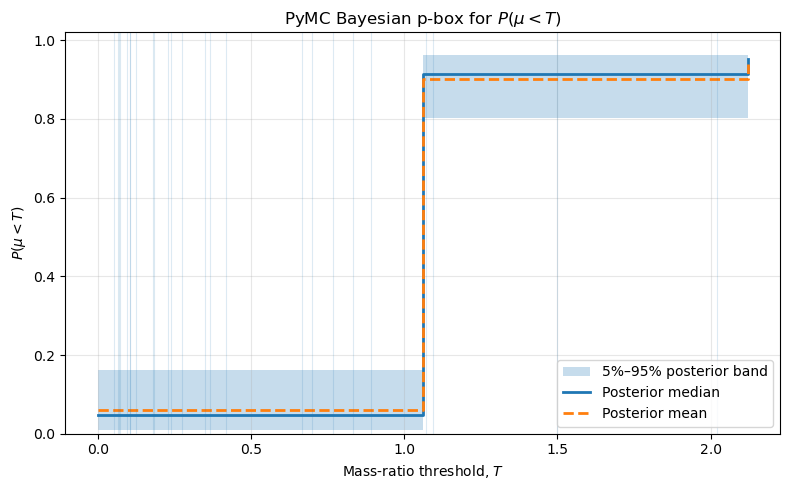

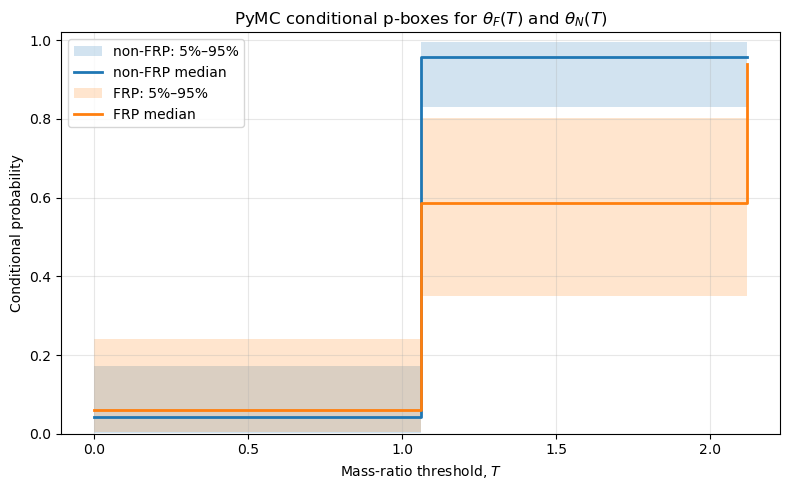

In [45]:
# ==================================================
# PLOT OVERALL PYMC P-BOX
# ==================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(
    pbox_df["T"],
    pbox_df["p_overall_q05"],
    pbox_df["p_overall_q95"],
    alpha=0.25,
    step="post",
    label="5%–95% posterior band"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_q50"],
    where="post",
    linewidth=2,
    label="Posterior median"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_mean"],
    where="post",
    linestyle="--",
    linewidth=2,
    label="Posterior mean"
)

# show raw mass-ratio values
for x in mu_nonfrp:
    ax.axvline(x, alpha=0.15, linewidth=0.8)

for x in mu_frp:
    ax.axvline(x, alpha=0.15, linewidth=0.8)

ax.set_xlabel(r"Mass-ratio threshold, $T$")
ax.set_ylabel(r"$P(\mu < T)$")
ax.set_title(r"PyMC Bayesian p-box for $P(\mu<T)$")

ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# ==================================================
# PLOT CONDITIONAL PYMC P-BOXES
# ==================================================

fig, ax = plt.subplots(figsize=(8, 5))

# non-FRP
ax.fill_between(
    pbox_df["T"],
    pbox_df["theta_N_q05"],
    pbox_df["theta_N_q95"],
    alpha=0.20,
    step="post",
    label=r"non-FRP: 5%–95%"
)

ax.step(
    pbox_df["T"],
    pbox_df["theta_N_q50"],
    where="post",
    linewidth=2,
    label=r"non-FRP median"
)

# FRP
ax.fill_between(
    pbox_df["T"],
    pbox_df["theta_F_q05"],
    pbox_df["theta_F_q95"],
    alpha=0.20,
    step="post",
    label=r"FRP: 5%–95%"
)

ax.step(
    pbox_df["T"],
    pbox_df["theta_F_q50"],
    where="post",
    linewidth=2,
    label=r"FRP median"
)

ax.set_xlabel(r"Mass-ratio threshold, $T$")
ax.set_ylabel(r"Conditional probability")
ax.set_title(r"PyMC conditional p-boxes for $\theta_F(T)$ and $\theta_N(T)$")

ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Mass-ratio data
bridge_type  mu_occ
    non-FRP  0.0680
    non-FRP  0.0670
    non-FRP  0.0710
    non-FRP  0.2290
    non-FRP  0.0960
    non-FRP  0.1050
    non-FRP  0.1040
    non-FRP  0.1260
    non-FRP  0.0540
    non-FRP  0.8330
    non-FRP  0.3490
    non-FRP  0.2380
    non-FRP  0.1800
    non-FRP  0.1830
    non-FRP  0.2740
        FRP  0.7664
        FRP  0.4167
        FRP  0.7000
        FRP  1.0714
        FRP  0.6646
        FRP  0.8898
        FRP  0.3646
        FRP  2.0192
        FRP  1.0938
        FRP  1.5000

Material population data
Wei:  14 FRP, 118 non-FRP
Gong: 11 FRP, 84 non-FRP
Combined: 25 FRP out of 227 total bridges

Threshold sweep settings
T_min = 0.00000
T_max = 2.12016
Number of T values = 300
Step size = 0.00709


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   2 tasks      | elapsed:   17.5s
[Parallel(n_jobs=3)]: Done   7 tasks      | elapsed:   31.8s
[Parallel(n_jobs=3)]: Done  12 tasks      | elapsed:   48.5s
[Parallel(n_jobs=3)]: Done  19 tasks      | elapsed:  1.3min
[Parallel(n_jobs=3)]: Done  26 tasks      | elapsed:  1.5min
[Parallel(n_jobs=3)]: Done  35 tasks      | elapsed:  2.1min
[Parallel(n_jobs=3)]: Done  44 tasks      | elapsed:  2.5min
[Parallel(n_jobs=3)]: Done  55 tasks      | elapsed:  3.1min
[Parallel(n_jobs=3)]: Done  66 tasks      | elapsed:  3.8min
[Parallel(n_jobs=3)]: Done  79 tasks      | elapsed:  4.4min
[Parallel(n_jobs=3)]: Done  92 tasks      | elapsed:  5.2min
[Parallel(n_jobs=3)]: Done 107 tasks      | elapsed:  6.1min
[Parallel(n_jobs=3)]: Done 122 tasks      | elapsed:  7.1min
[Parallel(n_jobs=3)]: Done 139 tasks      | elapsed:  8.1min
[Parallel(n_jobs=3)]: Done 156 tasks      | elapsed:  9.3min
[Parallel(


Parallel PyMC p-box dataframe
       T  k_nonfrp_below  n_nonfrp  k_frp_below  n_frp  w_F_mean  w_F_q05  w_F_q50  w_F_q95  theta_N_mean  theta_N_q05  theta_N_q50  theta_N_q95  theta_F_mean  theta_F_q05  theta_F_q50  theta_F_q95  p_overall_mean  p_overall_q05  p_overall_q50  p_overall_q95
0.000000               0        15            0     10  0.113513 0.081327 0.112526 0.149632      0.058528     0.002993     0.042425     0.171174      0.082791     0.004121     0.060632     0.239507        0.061291       0.008292       0.048023       0.160945
0.007091               0        15            0     10  0.113659 0.081694 0.112622 0.149792      0.058800     0.003595     0.043395     0.168074      0.083404     0.004426     0.060292     0.239634        0.061594       0.008979       0.048701       0.159063
0.014182               0        15            0     10  0.113383 0.080686 0.112451 0.149914      0.058678     0.003123     0.042349     0.168689      0.083865     0.004660     0.062336     0.2

[Parallel(n_jobs=3)]: Done 300 out of 300 | elapsed: 17.2min finished


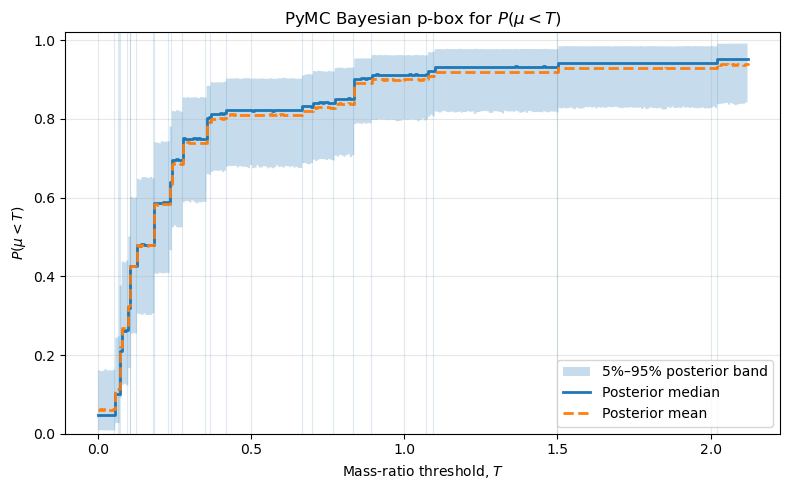

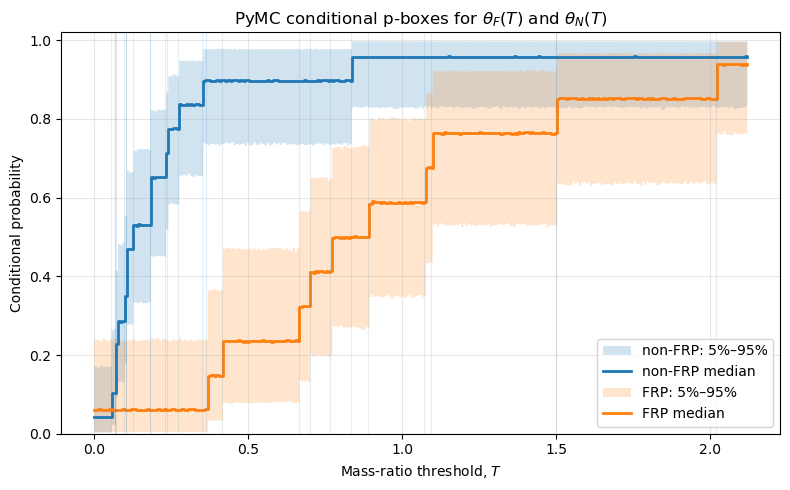

In [47]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

# ==================================================
# SETTINGS
# ==================================================

RANDOM_SEED = 42

# Number of threshold values for the p-box
# Keep 3 for testing. Later change to 300.
N_T_VALUES = 300

# Number of threshold models to run in parallel
# Start with 2. Later you can try 4.
N_JOBS = 3

# PyMC sampling settings
DRAWS = 4000
TUNE = 1000
CHAINS = 4
TARGET_ACCEPT = 0.95

# ==================================================
# RAW MASS-RATIO DATA AT rho = 1.5 persons/m^2
# ==================================================

mu_nonfrp = np.array([
    0.068,
    0.067,
    0.071,
    0.229,
    0.096,
    0.105,
    0.104,
    0.126,
    0.054,
    0.833,
    0.349,
    0.238,
    0.180,
    0.183,
    0.274,
])

mu_frp = np.array([
    0.7664,
    0.4167,
    0.7000,
    1.0714,
    0.6646,
    0.8898,
    0.3646,
    2.0192,
    1.0938,
    1.5000,
])

# ==================================================
# MATERIAL POPULATION DATA: WEI + GONG
# ==================================================

wei_frp = 14
wei_nonfrp = 118

gong_frp = 11
gong_nonfrp = 84

k_frp_material = wei_frp + gong_frp
n_material_total = wei_frp + wei_nonfrp + gong_frp + gong_nonfrp

# ==================================================
# DISPLAY DATA
# ==================================================

data_df = pd.DataFrame({
    "bridge_type": ["non-FRP"] * len(mu_nonfrp) + ["FRP"] * len(mu_frp),
    "mu_occ": np.concatenate([mu_nonfrp, mu_frp])
})

print("==========================================")
print("Mass-ratio data")
print("==========================================")
print(data_df.to_string(index=False))

print("\n==========================================")
print("Material population data")
print("==========================================")
print(f"Wei:  {wei_frp} FRP, {wei_nonfrp} non-FRP")
print(f"Gong: {gong_frp} FRP, {gong_nonfrp} non-FRP")
print(f"Combined: {k_frp_material} FRP out of {n_material_total} total bridges")

# ==================================================
# THRESHOLD GRID
# ==================================================

all_mu = np.concatenate([mu_nonfrp, mu_frp])

T_min = 0.0
T_max = all_mu.max() * 1.05

T_grid = np.linspace(T_min, T_max, N_T_VALUES)

print("\n==========================================")
print("Threshold sweep settings")
print("==========================================")
print(f"T_min = {T_grid.min():.5f}")
print(f"T_max = {T_grid.max():.5f}")
print(f"Number of T values = {len(T_grid)}")
print(f"Step size = {T_grid[1] - T_grid[0]:.5f}")

# ==================================================
# FUNCTION: RUN PYMC MODEL FOR ONE THRESHOLD T
# ==================================================

def run_model_for_threshold(T, random_seed=42):
    """
    Runs the same Bayesian model as your fixed-T model,
    but for one threshold value T.
    """

    # ------------------------------
    # Threshold counts
    # ------------------------------

    k_nonfrp_below = np.sum(mu_nonfrp < T)
    n_nonfrp = len(mu_nonfrp)

    k_frp_below = np.sum(mu_frp < T)
    n_frp = len(mu_frp)

    # ------------------------------
    # PyMC model
    # ------------------------------

    with pm.Model() as model:

        # P(FRP)
        w_F = pm.Beta("w_F", alpha=1, beta=1)

        # P(mu < T | non-FRP)
        theta_N = pm.Beta("theta_N", alpha=1, beta=1)

        # P(mu < T | FRP)
        theta_F = pm.Beta("theta_F", alpha=1, beta=1)

        # Material-count likelihood
        material_counts = pm.Binomial(
            "material_counts",
            n=n_material_total,
            p=w_F,
            observed=k_frp_material
        )

        # Non-FRP threshold-count likelihood
        nonfrp_threshold_counts = pm.Binomial(
            "nonfrp_threshold_counts",
            n=n_nonfrp,
            p=theta_N,
            observed=k_nonfrp_below
        )

        # FRP threshold-count likelihood
        frp_threshold_counts = pm.Binomial(
            "frp_threshold_counts",
            n=n_frp,
            p=theta_F,
            observed=k_frp_below
        )

        # Your model relationship:
        # P(mu < T) = P(FRP)P(mu<T|FRP)
        #           + P(non-FRP)P(mu<T|non-FRP)
        p_overall = pm.Deterministic(
            "p_overall",
            w_F * theta_F + (1.0 - w_F) * theta_N
        )

        trace = pm.sample(
            draws=DRAWS,
            tune=TUNE,
            chains=CHAINS,

            # Important:
            # We are parallelising over threshold values T,
            # so we keep PyMC internal chain parallelisation off.
            cores=1,

            target_accept=TARGET_ACCEPT,
            random_seed=random_seed,
            progressbar=False
        )

    # ------------------------------
    # Extract posterior samples
    # ------------------------------

    w_F_samples = trace.posterior["w_F"].values.ravel()
    theta_N_samples = trace.posterior["theta_N"].values.ravel()
    theta_F_samples = trace.posterior["theta_F"].values.ravel()
    p_overall_samples = trace.posterior["p_overall"].values.ravel()

    # ------------------------------
    # Return one row for p-box
    # ------------------------------

    return {
        "T": float(T),

        "k_nonfrp_below": int(k_nonfrp_below),
        "n_nonfrp": int(n_nonfrp),

        "k_frp_below": int(k_frp_below),
        "n_frp": int(n_frp),

        # P(FRP)
        "w_F_mean": np.mean(w_F_samples),
        "w_F_q05": np.quantile(w_F_samples, 0.05),
        "w_F_q50": np.quantile(w_F_samples, 0.50),
        "w_F_q95": np.quantile(w_F_samples, 0.95),

        # P(mu < T | non-FRP)
        "theta_N_mean": np.mean(theta_N_samples),
        "theta_N_q05": np.quantile(theta_N_samples, 0.05),
        "theta_N_q50": np.quantile(theta_N_samples, 0.50),
        "theta_N_q95": np.quantile(theta_N_samples, 0.95),

        # P(mu < T | FRP)
        "theta_F_mean": np.mean(theta_F_samples),
        "theta_F_q05": np.quantile(theta_F_samples, 0.05),
        "theta_F_q50": np.quantile(theta_F_samples, 0.50),
        "theta_F_q95": np.quantile(theta_F_samples, 0.95),

        # P(mu < T)
        "p_overall_mean": np.mean(p_overall_samples),
        "p_overall_q05": np.quantile(p_overall_samples, 0.05),
        "p_overall_q50": np.quantile(p_overall_samples, 0.50),
        "p_overall_q95": np.quantile(p_overall_samples, 0.95),
    }

# ==================================================
# WRAPPER FUNCTION FOR PARALLEL EXECUTION
# ==================================================

def run_one_threshold(i, T):
    print(f"Running threshold {i+1}/{len(T_grid)}: T = {T:.5f}")

    return run_model_for_threshold(
        T=float(T),
        random_seed=RANDOM_SEED + i
    )

# ==================================================
# RUN PYMC MODEL FOR ALL THRESHOLDS IN PARALLEL
# ==================================================

rows = Parallel(
    n_jobs=N_JOBS,
    backend="loky",
    verbose=10
)(
    delayed(run_one_threshold)(i, T)
    for i, T in enumerate(T_grid)
)

pbox_df = pd.DataFrame(rows)
pbox_df = pbox_df.sort_values("T").reset_index(drop=True)

print("\n==========================================")
print("Parallel PyMC p-box dataframe")
print("==========================================")
print(pbox_df.head().to_string(index=False))
print("\n...")
print(pbox_df.tail().to_string(index=False))

# ==================================================
# PLOT OVERALL PYMC P-BOX
# ==================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(
    pbox_df["T"],
    pbox_df["p_overall_q05"],
    pbox_df["p_overall_q95"],
    alpha=0.25,
    step="post",
    label="5%–95% posterior band"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_q50"],
    where="post",
    linewidth=2,
    label="Posterior median"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_mean"],
    where="post",
    linestyle="--",
    linewidth=2,
    label="Posterior mean"
)

# Show raw mass-ratio observations
for x in mu_nonfrp:
    ax.axvline(x, alpha=0.15, linewidth=0.8)

for x in mu_frp:
    ax.axvline(x, alpha=0.15, linewidth=0.8)

ax.set_xlabel(r"Mass-ratio threshold, $T$")
ax.set_ylabel(r"$P(\mu < T)$")
ax.set_title(r"PyMC Bayesian p-box for $P(\mu<T)$")

ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# ==================================================
# PLOT CONDITIONAL PYMC P-BOXES
# ==================================================

fig, ax = plt.subplots(figsize=(8, 5))

# non-FRP
ax.fill_between(
    pbox_df["T"],
    pbox_df["theta_N_q05"],
    pbox_df["theta_N_q95"],
    alpha=0.20,
    step="post",
    label=r"non-FRP: 5%–95%"
)

ax.step(
    pbox_df["T"],
    pbox_df["theta_N_q50"],
    where="post",
    linewidth=2,
    label=r"non-FRP median"
)

# FRP
ax.fill_between(
    pbox_df["T"],
    pbox_df["theta_F_q05"],
    pbox_df["theta_F_q95"],
    alpha=0.20,
    step="post",
    label=r"FRP: 5%–95%"
)

ax.step(
    pbox_df["T"],
    pbox_df["theta_F_q50"],
    where="post",
    linewidth=2,
    label=r"FRP median"
)

# Show raw mass-ratio observations
for x in mu_nonfrp:
    ax.axvline(x, alpha=0.12, linewidth=0.8)

for x in mu_frp:
    ax.axvline(x, alpha=0.12, linewidth=0.8)

ax.set_xlabel(r"Mass-ratio threshold, $T$")
ax.set_ylabel(r"Conditional probability")
ax.set_title(r"PyMC conditional p-boxes for $\theta_F(T)$ and $\theta_N(T)$")

ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

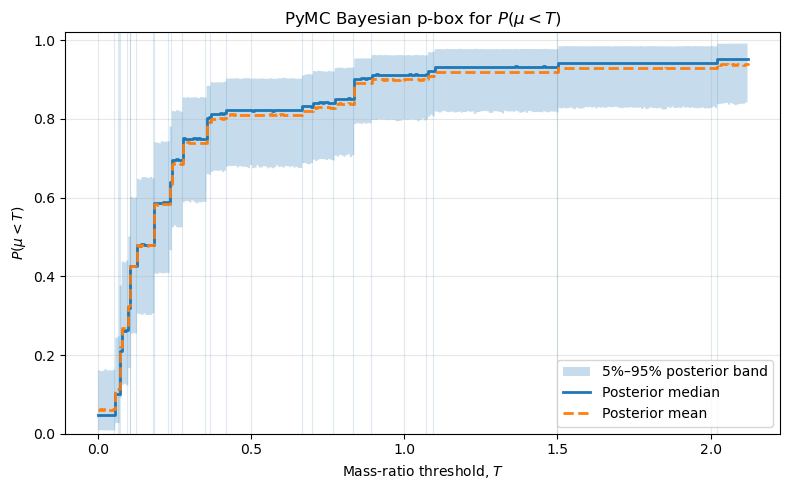

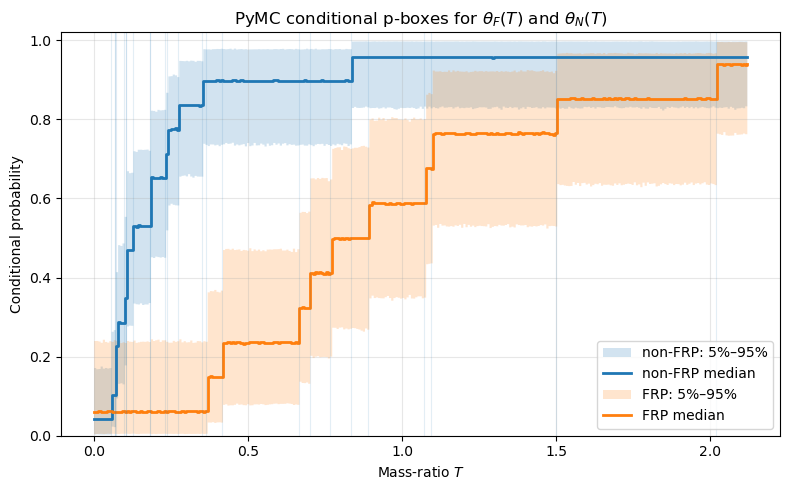

In [58]:
# ==================================================
# PLOT OVERALL PYMC P-BOX
# ==================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(
    pbox_df["T"],
    pbox_df["p_overall_q05"],
    pbox_df["p_overall_q95"],
    alpha=0.25,
    step="post",
    label="5%–95% posterior band"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_q50"],
    where="post",
    linewidth=2,
    label="Posterior median"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_mean"],
    where="post",
    linestyle="--",
    linewidth=2,
    label="Posterior mean"
)

# Show raw mass-ratio observations
for x in mu_nonfrp:
    ax.axvline(x, alpha=0.15, linewidth=0.8)

for x in mu_frp:
    ax.axvline(x, alpha=0.15, linewidth=0.8)

ax.set_xlabel(r"Mass-ratio threshold, $T$")
ax.set_ylabel(r"$P(\mu < T)$")
ax.set_title(r"PyMC Bayesian p-box for $P(\mu<T)$")

ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# ==================================================
# PLOT CONDITIONAL PYMC P-BOXES
# ==================================================

fig, ax = plt.subplots(figsize=(8, 5))

# non-FRP
ax.fill_between(
    pbox_df["T"],
    pbox_df["theta_N_q05"],
    pbox_df["theta_N_q95"],
    alpha=0.20,
    step="post",
    label=r"non-FRP: 5%–95%"
)

ax.step(
    pbox_df["T"],
    pbox_df["theta_N_q50"],
    where="post",
    linewidth=2,
    label=r"non-FRP median"
)

# FRP
ax.fill_between(
    pbox_df["T"],
    pbox_df["theta_F_q05"],
    pbox_df["theta_F_q95"],
    alpha=0.20,
    step="post",
    label=r"FRP: 5%–95%"
)

ax.step(
    pbox_df["T"],
    pbox_df["theta_F_q50"],
    where="post",
    linewidth=2,
    label=r"FRP median"
)

# Show raw mass-ratio observations
for x in mu_nonfrp:
    ax.axvline(x, alpha=0.12, linewidth=0.8)

for x in mu_frp:
    ax.axvline(x, alpha=0.12, linewidth=0.8)

ax.set_xlabel(r"Mass-ratio $T$")
ax.set_ylabel(r"Conditional probability")
ax.set_title(r"PyMC conditional p-boxes for $\theta_F(T)$ and $\theta_N(T)$")

ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Requested T = 0.300
Closest available T in pbox_df = 0.29782
T                 0.297815
p_overall_q05     0.587927
p_overall_mean    0.739826
p_overall_q50     0.749732
p_overall_q95     0.854322
theta_N_q05       0.655740
theta_N_mean      0.823984
theta_N_q95       0.947950
theta_F_q05       0.004466
theta_F_mean      0.082844
theta_F_q95       0.235993
w_F_q05           0.081452
w_F_mean          0.113552
w_F_q95           0.149175
Name: 42, dtype: float64


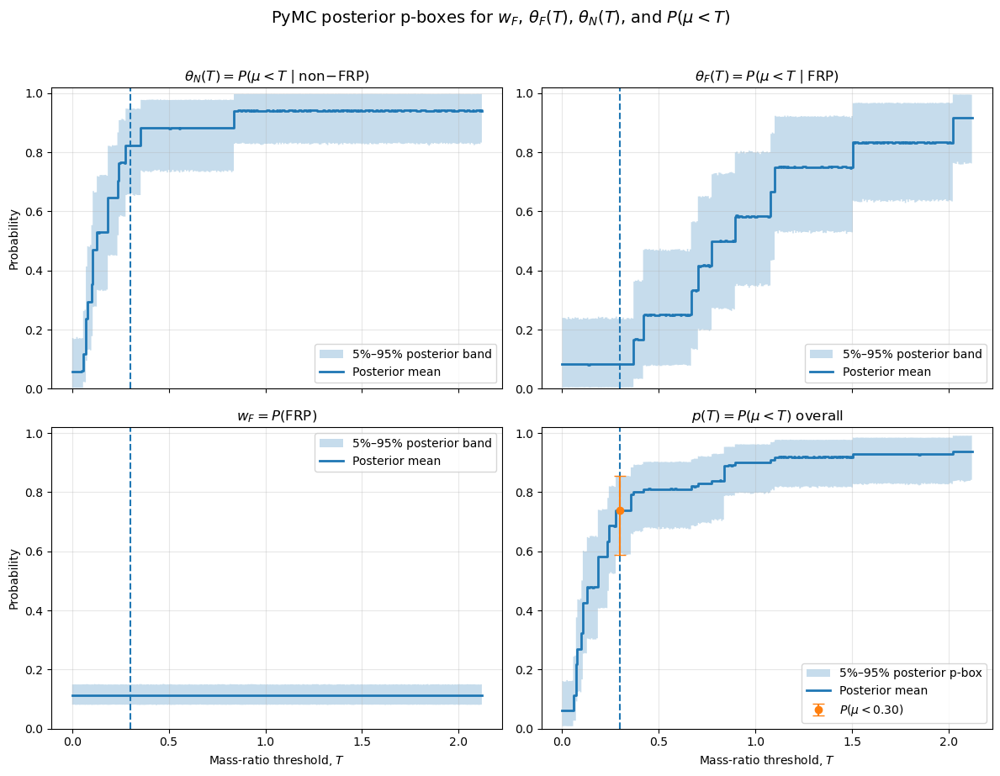

In [48]:
# ==================================================
# PLOT ALL POSTERIOR P-BOXES / BANDS
# theta_N(T), theta_F(T), w_F, and p(T)=P(mu<T)
# ==================================================

T_TARGET = 0.30

# Find the row closest to T = 0.30
idx_target = np.argmin(np.abs(pbox_df["T"].values - T_TARGET))
target_row = pbox_df.iloc[idx_target]
T_used = target_row["T"]

print("==========================================")
print(f"Requested T = {T_TARGET:.3f}")
print(f"Closest available T in pbox_df = {T_used:.5f}")
print("==========================================")
print(target_row[[
    "T",
    "p_overall_q05",
    "p_overall_mean",
    "p_overall_q50",
    "p_overall_q95",
    "theta_N_q05",
    "theta_N_mean",
    "theta_N_q95",
    "theta_F_q05",
    "theta_F_mean",
    "theta_F_q95",
    "w_F_q05",
    "w_F_mean",
    "w_F_q95",
]])

# ==================================================
# 4-PANEL FIGURE
# ==================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

# --------------------------------------------------
# 1) theta_N(T) = P(mu < T | non-FRP)
# --------------------------------------------------

ax = axes[0, 0]

ax.fill_between(
    pbox_df["T"],
    pbox_df["theta_N_q05"],
    pbox_df["theta_N_q95"],
    alpha=0.25,
    step="post",
    label="5%–95% posterior band"
)

ax.step(
    pbox_df["T"],
    pbox_df["theta_N_mean"],
    where="post",
    linewidth=2,
    label="Posterior mean"
)

ax.axvline(T_TARGET, linestyle="--", linewidth=1.5)

ax.set_title(r"$\theta_N(T)=P(\mu<T\mid\mathrm{non\!-\!FRP})$")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

# --------------------------------------------------
# 2) theta_F(T) = P(mu < T | FRP)
# --------------------------------------------------

ax = axes[0, 1]

ax.fill_between(
    pbox_df["T"],
    pbox_df["theta_F_q05"],
    pbox_df["theta_F_q95"],
    alpha=0.25,
    step="post",
    label="5%–95% posterior band"
)

ax.step(
    pbox_df["T"],
    pbox_df["theta_F_mean"],
    where="post",
    linewidth=2,
    label="Posterior mean"
)

ax.axvline(T_TARGET, linestyle="--", linewidth=1.5)

ax.set_title(r"$\theta_F(T)=P(\mu<T\mid\mathrm{FRP})$")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

# --------------------------------------------------
# 3) w_F = P(FRP)
# This does not depend on T, so it is a horizontal band
# --------------------------------------------------

ax = axes[1, 0]

ax.fill_between(
    pbox_df["T"],
    pbox_df["w_F_q05"],
    pbox_df["w_F_q95"],
    alpha=0.25,
    step="post",
    label="5%–95% posterior band"
)

ax.step(
    pbox_df["T"],
    pbox_df["w_F_mean"],
    where="post",
    linewidth=2,
    label="Posterior mean"
)

ax.axvline(T_TARGET, linestyle="--", linewidth=1.5)

ax.set_title(r"$w_F=P(\mathrm{FRP})$")
ax.set_xlabel(r"Mass-ratio threshold, $T$")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

# --------------------------------------------------
# 4) Overall p-box:
# p(T)=P(mu<T)=w_F theta_F(T)+(1-w_F)theta_N(T)
# --------------------------------------------------

ax = axes[1, 1]

ax.fill_between(
    pbox_df["T"],
    pbox_df["p_overall_q05"],
    pbox_df["p_overall_q95"],
    alpha=0.25,
    step="post",
    label="5%–95% posterior p-box"
)

ax.step(
    pbox_df["T"],
    pbox_df["p_overall_mean"],
    where="post",
    linewidth=2,
    label="Posterior mean"
)

# Highlight T = 0.30 result
ax.axvline(T_TARGET, linestyle="--", linewidth=1.5)

ax.errorbar(
    T_used,
    target_row["p_overall_mean"],
    yerr=[
        [target_row["p_overall_mean"] - target_row["p_overall_q05"]],
        [target_row["p_overall_q95"] - target_row["p_overall_mean"]]
    ],
    fmt="o",
    capsize=5,
    label=rf"$P(\mu< {T_TARGET:.2f})$"
)

ax.set_title(r"$p(T)=P(\mu<T)$ overall")
ax.set_xlabel(r"Mass-ratio threshold, $T$")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle(
    r"PyMC posterior p-boxes for $w_F$, $\theta_F(T)$, $\theta_N(T)$, and $P(\mu<T)$",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

Target event: mu_occ < 0.6
Material data: 25 FRP out of 227 total bridges
Non-FRP data: 14 below threshold out of 15
FRP data:     2 below threshold out of 10

Non-FRP values below threshold:
[0.068 0.067 0.071 0.229 0.096 0.105 0.104 0.126 0.054 0.349 0.238 0.18
 0.183 0.274]

FRP values below threshold:
[0.4167 0.3646]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_F, theta_N, theta_F]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 25 seconds.



Posterior summary:
            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  \
w_F        0.114  0.021     0.074      0.155      0.000    0.000   14845.0   
theta_N    0.883  0.075     0.739      0.996      0.001    0.001   13991.0   
theta_F    0.251  0.122     0.037      0.484      0.001    0.001   13621.0   
p_overall  0.811  0.069     0.668      0.922      0.001    0.001   14383.0   

           ess_tail  r_hat  
w_F         10733.0    1.0  
theta_N      9677.0    1.0  
theta_F     10425.0    1.0  
p_overall   10826.0    1.0  


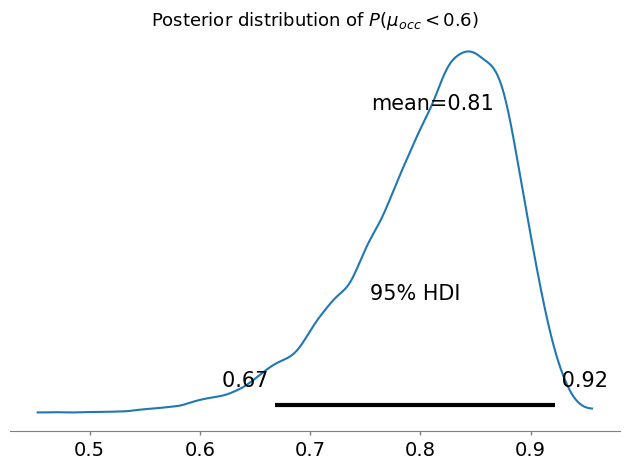

In [57]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

TARGET_THRESHOLD = 0.60   # change this to 0.75, 0.50, etc.
RANDOM_SEED = 42

# ==================================================
# RAW MASS-RATIO DATA AT rho = 1.5 persons/m^2
# ==================================================

mu_nonfrp = np.array([
    0.068,
    0.067,
    0.071,
    0.229,
    0.096,
    0.105,
    0.104,
    0.126,
    0.054,
    0.833,
    0.349,
    0.238,
    0.180,
    0.183,
    0.274,
])

mu_frp = np.array([
    0.7664,
    0.4167,
    0.7000,
    1.0714,
    0.6646,
    0.8898,
    0.3646,
    2.0192,
    1.0938,
    1.5000,
])

# ==================================================
# MATERIAL POPULATION DATA: WEI + GONG
# ==================================================

wei_frp = 14
wei_nonfrp = 118

gong_frp = 11
gong_nonfrp = 84

k_frp_material = wei_frp + gong_frp
n_material_total = wei_frp + wei_nonfrp + gong_frp + gong_nonfrp

# ==================================================
# CONVERT MASS-RATIO DATA INTO THRESHOLD COUNTS
# ==================================================
# Success means: mu_occ < TARGET_THRESHOLD

k_nonfrp_below = np.sum(mu_nonfrp < TARGET_THRESHOLD)
n_nonfrp = len(mu_nonfrp)

k_frp_below = np.sum(mu_frp < TARGET_THRESHOLD)
n_frp = len(mu_frp)

print("==========================================")
print(f"Target event: mu_occ < {TARGET_THRESHOLD}")
print("==========================================")
print(f"Material data: {k_frp_material} FRP out of {n_material_total} total bridges")
print(f"Non-FRP data: {k_nonfrp_below} below threshold out of {n_nonfrp}")
print(f"FRP data:     {k_frp_below} below threshold out of {n_frp}")

print("\nNon-FRP values below threshold:")
print(mu_nonfrp[mu_nonfrp < TARGET_THRESHOLD])

print("\nFRP values below threshold:")
print(mu_frp[mu_frp < TARGET_THRESHOLD])

# ==================================================
# PYMC MODEL
# ==================================================

with pm.Model() as model:

    # --------------------------------------------------
    # PRIORS
    # --------------------------------------------------
    # w_F = P(FRP)
    # probability that a randomly selected bridge is FRP
    w_F = pm.Beta("w_F", alpha=1, beta=1)

    # theta_N = P(mu_occ < threshold | non-FRP)
    # probability that a non-FRP bridge is below the chosen mass-ratio threshold
    theta_N = pm.Beta("theta_N", alpha=1, beta=1)

    # theta_F = P(mu_occ < threshold | FRP)
    # probability that an FRP bridge is below the chosen mass-ratio threshold
    theta_F = pm.Beta("theta_F", alpha=1, beta=1)

    # --------------------------------------------------
    # LIKELIHOODS
    # --------------------------------------------------
    # Material-count likelihood:
    # k_frp_material ~ Binomial(n_material_total, w_F)
    material_counts = pm.Binomial(
        "material_counts",
        n=n_material_total,
        p=w_F,
        observed=k_frp_material
    )

    # Non-FRP threshold likelihood:
    # k_nonfrp_below ~ Binomial(n_nonfrp, theta_N)
    nonfrp_threshold_counts = pm.Binomial(
        "nonfrp_threshold_counts",
        n=n_nonfrp,
        p=theta_N,
        observed=k_nonfrp_below
    )

    # FRP threshold likelihood:
    # k_frp_below ~ Binomial(n_frp, theta_F)
    frp_threshold_counts = pm.Binomial(
        "frp_threshold_counts",
        n=n_frp,
        p=theta_F,
        observed=k_frp_below
    )

    # --------------------------------------------------
    # DERIVED OVERALL PROBABILITY
    # --------------------------------------------------
    # p_overall = P(mu_occ < threshold)
    p_overall = pm.Deterministic(
        "p_overall",
        (1.0 - w_F) * theta_N + w_F * theta_F
    )

    # --------------------------------------------------
    # SAMPLING
    # --------------------------------------------------
    trace = pm.sample(
        draws=4000,
        tune=1000,
        chains=4,
        target_accept=0.95,
        random_seed=RANDOM_SEED
    )

# ==================================================
# SUMMARY
# ==================================================

summary = az.summary(
    trace,
    var_names=["w_F", "theta_N", "theta_F", "p_overall"],
    hdi_prob=0.95
)

print("\nPosterior summary:")
print(summary)

# ==================================================
# PLOT ONLY OVERALL PROBABILITY: P(mu_occ < T)
# ==================================================

az.plot_posterior(
    trace,
    var_names=["p_overall"],
    hdi_prob=0.95,
    ref_val=None
)

plt.title(
    rf"Posterior distribution of $P(\mu_{{occ}} < {TARGET_THRESHOLD})$",
    fontsize=13
)

plt.tight_layout()
plt.show()

Number of usable frequency values:
source
China database         100
Wei et al. appendix     65
Name: count, dtype: int64
Total: 165


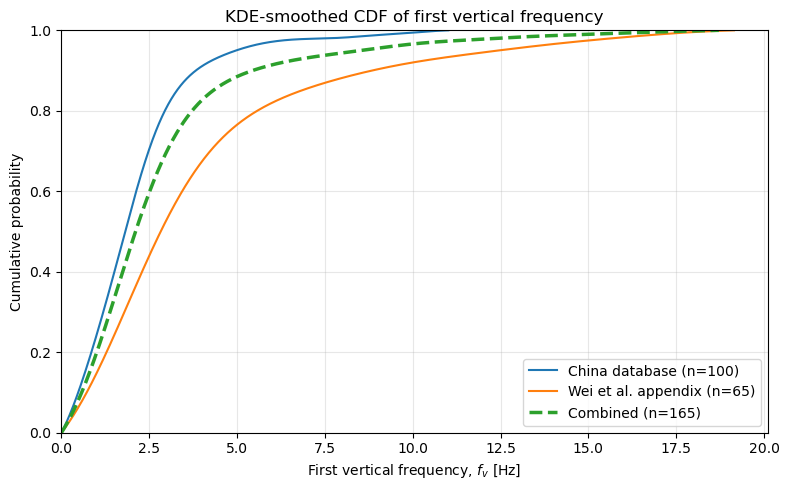

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid

# ==================================================
# FILE PATHS
# ==================================================
china_csv = "Gong Bridge data f and damping.csv"
wei_csv = "wei2019_appendix_dynamic_properties_65_footbridges.csv"

# ==================================================
# LOAD CSV FILES
# ==================================================
china_df = pd.read_csv(china_csv, encoding="utf-8-sig")
wei_df = pd.read_csv(wei_csv, encoding="utf-8-sig")

# ==================================================
# HELPER FUNCTION TO CLEAN FREQUENCY VALUES
# ==================================================
def clean_numeric_column(series):
    """
    Converts values like 'unknown', 'N/A', blanks, or text-containing numbers
    into clean numeric values.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


# ==================================================
# EXTRACT FIRST VERTICAL FREQUENCY FROM EACH DATASET
# ==================================================
china_freq = clean_numeric_column(china_df["vertical_natural_frequency_Hz"])
wei_freq = clean_numeric_column(wei_df["frequency_hz"])

freq_df = pd.DataFrame({
    "first_vertical_frequency_Hz": pd.concat([china_freq, wei_freq], ignore_index=True),
    "source": (
        ["China database"] * len(china_freq)
        + ["Wei et al. appendix"] * len(wei_freq)
    )
})

# Remove missing/non-positive values
freq_df = freq_df.dropna(subset=["first_vertical_frequency_Hz"])
freq_df = freq_df[freq_df["first_vertical_frequency_Hz"] > 0].copy()

print("Number of usable frequency values:")
print(freq_df["source"].value_counts())
print("Total:", len(freq_df))


# ==================================================
# KDE-SMOOTHED CDF FUNCTION
# ==================================================
def kde_smooth_cdf(values, x_grid=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if x_grid is None:
        x_min = max(0.0, values.min() - 0.5 * values.std())
        x_max = values.max() + 0.5 * values.std()
        x_grid = np.linspace(x_min, x_max, 1000)

    kde = gaussian_kde(values)
    pdf = kde(x_grid)

    cdf = cumulative_trapezoid(pdf, x_grid, initial=0)
    cdf = cdf / cdf[-1]   # normalise to finish at 1

    return x_grid, cdf


# ==================================================
# PLOT KDE-SMOOTHED CDFs
# ==================================================
plt.figure(figsize=(8, 5))

# Individual datasets
for source_name, group in freq_df.groupby("source"):
    values = group["first_vertical_frequency_Hz"].values
    x, cdf = kde_smooth_cdf(values)
    plt.plot(x, cdf, label=f"{source_name} (n={len(values)})")

# Combined dataset
combined_values = freq_df["first_vertical_frequency_Hz"].values
x_combined, cdf_combined = kde_smooth_cdf(combined_values)
plt.plot(
    x_combined,
    cdf_combined,
    linewidth=2.5,
    linestyle="--",
    label=f"Combined (n={len(combined_values)})"
)

plt.xlabel(r"First vertical frequency, $f_v$ [Hz]")
plt.ylabel("Cumulative probability")
plt.title("KDE-smoothed CDF of first vertical frequency")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Total usable frequency values = 165
Empirical bridges with f_v < 5 Hz = 149/165
Empirical percentage below 5 Hz = 90.30%
KDE-smoothed CDF percentage below 5 Hz = 88.51%


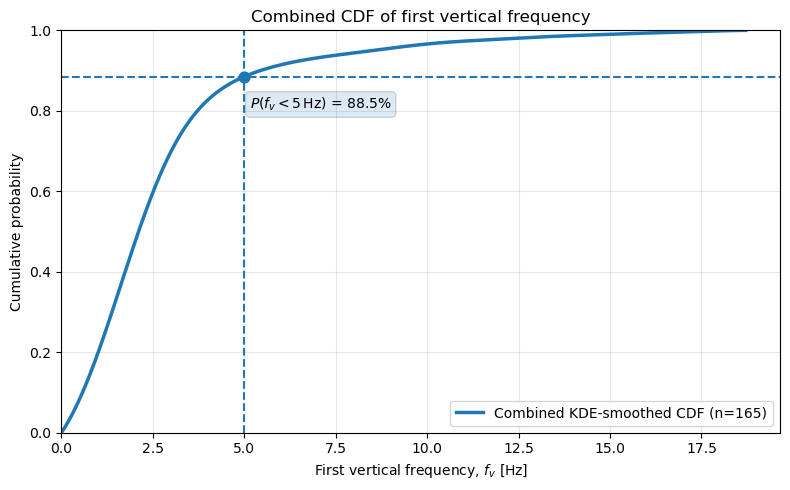

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid

# ==================================================
# FILE PATHS
# ==================================================
china_csv = "Gong Bridge data f and damping.csv"
wei_csv = "wei2019_appendix_dynamic_properties_65_footbridges.csv"

# ==================================================
# LOAD CSV FILES
# ==================================================
china_df = pd.read_csv(china_csv, encoding="utf-8-sig")
wei_df = pd.read_csv(wei_csv, encoding="utf-8-sig")

# ==================================================
# CLEAN NUMERIC VALUES
# ==================================================
def clean_numeric_column(series):
    """
    Converts values such as 'unknown', blanks, or text-containing numbers
    into clean numeric values.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")

# ==================================================
# EXTRACT FIRST VERTICAL FREQUENCIES
# ==================================================
china_freq = clean_numeric_column(china_df["vertical_natural_frequency_Hz"])
wei_freq = clean_numeric_column(wei_df["frequency_hz"])

combined_freq = pd.concat([china_freq, wei_freq], ignore_index=True)
combined_freq = combined_freq.dropna()
combined_freq = combined_freq[combined_freq > 0].to_numpy()

print(f"Total usable frequency values = {len(combined_freq)}")

# ==================================================
# KDE-SMOOTHED CDF
# ==================================================
x_min = 0.0
x_max = combined_freq.max() + 0.5 * combined_freq.std()
x_grid = np.linspace(x_min, x_max, 1500)

kde = gaussian_kde(combined_freq)
pdf = kde(x_grid)

cdf = cumulative_trapezoid(pdf, x_grid, initial=0)
cdf = cdf / cdf[-1]   # normalise to end at 1

# ==================================================
# FIND PERCENTAGE BELOW 5 Hz
# ==================================================
threshold = 5.0

# From KDE-smoothed CDF
cdf_at_5 = np.interp(threshold, x_grid, cdf)
percent_below_5_kde = cdf_at_5 * 100

# Direct empirical percentage from raw data
percent_below_5_empirical = np.mean(combined_freq < threshold) * 100
n_below_5 = np.sum(combined_freq < threshold)

print(f"Empirical bridges with f_v < 5 Hz = {n_below_5}/{len(combined_freq)}")
print(f"Empirical percentage below 5 Hz = {percent_below_5_empirical:.2f}%")
print(f"KDE-smoothed CDF percentage below 5 Hz = {percent_below_5_kde:.2f}%")

# ==================================================
# PLOT COMBINED CDF ONLY
# ==================================================
plt.figure(figsize=(8, 5))

plt.plot(
    x_grid,
    cdf,
    linewidth=2.5,
    label=f"Combined KDE-smoothed CDF (n={len(combined_freq)})"
)

# Mark 5 Hz
plt.axvline(threshold, linestyle="--", linewidth=1.5)
plt.axhline(cdf_at_5, linestyle="--", linewidth=1.5)

plt.scatter([threshold], [cdf_at_5], s=60, zorder=5)

plt.text(
    threshold + 0.15,
    cdf_at_5 - 0.08,
    rf"$P(f_v < 5\,\mathrm{{Hz}})$ = {percent_below_5_kde:.1f}%",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.xlabel(r"First vertical frequency, $f_v$ [Hz]")
plt.ylabel("Cumulative probability")
plt.title("Combined CDF of first vertical frequency")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Removing likely Wei–Oliveira overlap rows:
                source                   bridge_name  \
110  Wei 2019 appendix         Viana Footbridge [53]   
112  Wei 2019 appendix        Guarda Footbridge [56]   
125  Wei 2019 appendix          FEUP Footbridge [48]   
138  Wei 2019 appendix  Pedro e Inês footbridge [75]   

     first_vertical_frequency_Hz  
110                         1.03  
112                         2.19  
125                         0.99  
138                         1.54  

Usable frequency values by source:
source
Gong 2024 China database           100
Oliveira 2014 Portugal database     79
Wei 2019 appendix                   61
Name: count, dtype: int64

Total usable frequency values = 240

Empirical bridges with f_v < 5.0 Hz = 206/240
Empirical percentage below 5.0 Hz = 85.83%
KDE-smoothed CDF percentage below 5.0 Hz = 84.43%


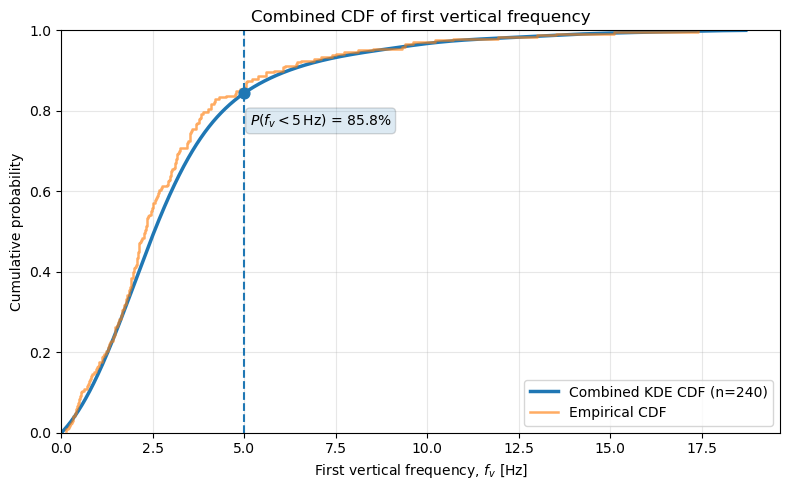

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid

# ==================================================
# SETTINGS
# ==================================================
REMOVE_WEI_OLIVEIRA_OVERLAPS = True

threshold = 5.0

# ==================================================
# FILE PATHS
# ==================================================
china_csv = "Gong Bridge data f and damping.csv"
wei_csv = "wei2019_appendix_dynamic_properties_65_footbridges.csv"
oliveira_csv = "oliveira2014_table1_79_footbridges.csv"

# ==================================================
# LOAD CSV FILES
# ==================================================
china_df = pd.read_csv(china_csv, encoding="utf-8-sig")
wei_df = pd.read_csv(wei_csv, encoding="utf-8-sig")
oliveira_df = pd.read_csv(oliveira_csv, encoding="utf-8-sig")

# ==================================================
# CLEAN NUMERIC VALUES
# ==================================================
def clean_numeric_column(series):
    """
    Converts values such as 'unknown', blanks, or text-containing numbers
    into clean numeric values.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")

# ==================================================
# EXTRACT FIRST VERTICAL FREQUENCIES
# ==================================================
gong_freq = clean_numeric_column(china_df["vertical_natural_frequency_Hz"])

wei_freq = clean_numeric_column(wei_df["frequency_hz"])

oliveira_freq = clean_numeric_column(
    oliveira_df["first_vertical_frequency_Hz"]
)

# ==================================================
# BUILD ONE COMBINED FREQUENCY DATAFRAME
# ==================================================
gong_part = pd.DataFrame({
    "source": "Gong 2024 China database",
    "bridge_name": china_df.get("name", pd.Series([np.nan] * len(china_df))),
    "first_vertical_frequency_Hz": gong_freq
})

wei_part = pd.DataFrame({
    "source": "Wei 2019 appendix",
    "bridge_name": wei_df["name"],
    "first_vertical_frequency_Hz": wei_freq
})

oliveira_part = pd.DataFrame({
    "source": "Oliveira 2014 Portugal database",
    "bridge_name": oliveira_df["name"],
    "first_vertical_frequency_Hz": oliveira_freq
})

freq_df = pd.concat(
    [gong_part, wei_part, oliveira_part],
    ignore_index=True
)

# Remove missing and non-positive frequencies
freq_df = freq_df.dropna(subset=["first_vertical_frequency_Hz"]).copy()
freq_df = freq_df[freq_df["first_vertical_frequency_Hz"] > 0].copy()

# ==================================================
# OPTIONAL: REMOVE KNOWN WEI–OLIVEIRA OVERLAPS
# ==================================================
# These bridges appear in both Wei and Oliveira.
# To avoid double-counting, remove them from Wei and keep Oliveira's row.
known_wei_oliveira_overlaps = [
    "Viana",
    "Guarda",
    "FEUP",
    "Pedro"
]

if REMOVE_WEI_OLIVEIRA_OVERLAPS:
    mask_overlap_in_wei = (
        freq_df["source"].eq("Wei 2019 appendix")
        & freq_df["bridge_name"].astype(str).str.contains(
            "|".join(known_wei_oliveira_overlaps),
            case=False,
            na=False
        )
    )

    print("Removing likely Wei–Oliveira overlap rows:")
    print(freq_df.loc[mask_overlap_in_wei, ["source", "bridge_name", "first_vertical_frequency_Hz"]])

    freq_df = freq_df.loc[~mask_overlap_in_wei].copy()

# ==================================================
# FINAL COMBINED FREQUENCY ARRAY
# ==================================================
combined_freq = freq_df["first_vertical_frequency_Hz"].to_numpy()
# ==================================================
# EMPIRICAL CDF
# ==================================================
freq_sorted = np.sort(combined_freq)
empirical_cdf = np.arange(1, len(freq_sorted) + 1) / len(freq_sorted)
print("\nUsable frequency values by source:")
print(freq_df["source"].value_counts())

print(f"\nTotal usable frequency values = {len(combined_freq)}")

# ==================================================
# EMPIRICAL PROPORTION BELOW 5 Hz
# ==================================================
n_below_5 = np.sum(combined_freq < threshold)
percent_below_5_empirical = n_below_5 / len(combined_freq) * 100

print(f"\nEmpirical bridges with f_v < {threshold:.1f} Hz = {n_below_5}/{len(combined_freq)}")
print(f"Empirical percentage below {threshold:.1f} Hz = {percent_below_5_empirical:.2f}%")

# ==================================================
# KDE-SMOOTHED CDF
# ==================================================
x_min = 0.0
x_max = combined_freq.max() + 0.5 * combined_freq.std()
x_grid = np.linspace(x_min, x_max, 1500)

kde = gaussian_kde(combined_freq)
pdf = kde(x_grid)

cdf = cumulative_trapezoid(pdf, x_grid, initial=0)
cdf = cdf / cdf[-1]

cdf_at_5_kde = np.interp(threshold, x_grid, cdf)
percent_below_5_kde = cdf_at_5_kde * 100

print(f"KDE-smoothed CDF percentage below {threshold:.1f} Hz = {percent_below_5_kde:.2f}%")

# ==================================================
# PLOT COMBINED CDF ONLY
# ==================================================
plt.figure(figsize=(8, 5))

plt.plot(
    x_grid,
    cdf,
    linewidth=2.5,
    label=f"Combined KDE CDF (n={len(combined_freq)})"
)
plt.step(
    freq_sorted,
    empirical_cdf,
    where="post",
    linewidth=1.8,
    alpha=0.65,
    label="Empirical CDF"
)
# Mark 5 Hz
plt.axvline(threshold, linestyle="--", linewidth=1.5)

# Mark KDE CDF value at 5 Hz on the curve
plt.scatter([threshold], [cdf_at_5_kde], s=60, zorder=5)

plt.text(
    threshold + 0.15,
    cdf_at_5_kde - 0.08,
    rf"$P(f_v < 5\,\mathrm{{Hz}})$ = {percent_below_5_empirical:.1f}%",
    
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.xlabel(r"First vertical frequency, $f_v$ [Hz]")
plt.ylabel("Cumulative probability")
plt.title("Combined CDF of first vertical frequency")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Available first vertical damping values:
source
Wei 2019     58
Gong 2024    41
Name: count, dtype: int64
Total available damping values = 99

Damping summary, ratio:
count    99.000000
mean      0.012738
std       0.012319
min       0.001400
25%       0.005000
50%       0.009000
75%       0.018500
max       0.079000
dtype: float64

Damping summary, percent:
count    99.000000
mean      1.273758
std       1.231903
min       0.140000
25%       0.500000
50%       0.900000
75%       1.850000
max       7.900000
dtype: float64


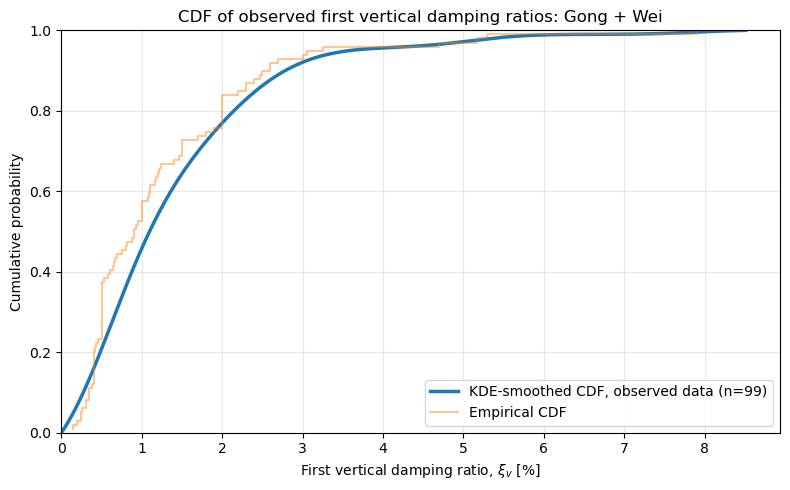

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid

# ==================================================
# FILE PATHS
# ==================================================
gong_csv = "Gong Bridge data f and damping.csv"
wei_csv = "wei2019_appendix_dynamic_properties_65_footbridges.csv"

# ==================================================
# LOAD CSV FILES
# ==================================================
gong_df = pd.read_csv(gong_csv, encoding="utf-8-sig")
wei_df = pd.read_csv(wei_csv, encoding="utf-8-sig")

# ==================================================
# CLEAN NUMERIC VALUES
# ==================================================
def clean_numeric_column(series):
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")

# ==================================================
# EXTRACT FIRST VERTICAL DAMPING RATIOS
# ==================================================
# Gong: already ratio, e.g. 0.005 = 0.5%
gong_zeta = clean_numeric_column(gong_df["vertical_damping_ratio"])

# Wei: percent, e.g. 0.43 = 0.43%, so convert to ratio
wei_zeta_percent = clean_numeric_column(wei_df["damping_ratio_percent"])
wei_zeta = wei_zeta_percent / 100.0

# ==================================================
# COMBINE OBSERVED DAMPING DATA ONLY
# ==================================================
damping_df = pd.DataFrame({
    "damping_ratio": pd.concat([gong_zeta, wei_zeta], ignore_index=True),
    "source": (
        ["Gong 2024"] * len(gong_zeta)
        + ["Wei 2019"] * len(wei_zeta)
    )
})

# Remove missing and invalid values
damping_df = damping_df.dropna(subset=["damping_ratio"]).copy()
damping_df = damping_df[damping_df["damping_ratio"] > 0].copy()

combined_zeta = damping_df["damping_ratio"].to_numpy()

print("Available first vertical damping values:")
print(damping_df["source"].value_counts())
print(f"Total available damping values = {len(combined_zeta)}")

# ==================================================
# EMPIRICAL CDF
# ==================================================
zeta_sorted = np.sort(combined_zeta)
empirical_cdf = np.arange(1, len(zeta_sorted) + 1) / len(zeta_sorted)

# ==================================================
# KDE-SMOOTHED CDF
# ==================================================
x_min = 0.0
x_max = combined_zeta.max() + 0.5 * combined_zeta.std()
x_grid = np.linspace(x_min, x_max, 1500)

kde = gaussian_kde(combined_zeta)
pdf = kde(x_grid)

cdf = cumulative_trapezoid(pdf, x_grid, initial=0)
cdf = cdf / cdf[-1]

# ==================================================
# SUMMARY STATISTICS
# ==================================================
print("\nDamping summary, ratio:")
print(pd.Series(combined_zeta).describe())

print("\nDamping summary, percent:")
print((pd.Series(combined_zeta) * 100).describe())

# ==================================================
# PLOT CDF
# ==================================================
plt.figure(figsize=(8, 5))

# KDE-smoothed CDF
plt.plot(
    x_grid * 100,
    cdf,
    linewidth=2.5,
    label=f"KDE-smoothed CDF, observed data (n={len(combined_zeta)})"
)

# Empirical CDF as reference
plt.step(
    zeta_sorted * 100,
    empirical_cdf,
    where="post",
    alpha=0.45,
    label="Empirical CDF"
)

plt.xlabel(r"First vertical damping ratio, $\xi_v$ [%]")
plt.ylabel("Cumulative probability")
plt.title("CDF of observed first vertical damping ratios: Gong + Wei")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Available damping values:
source
Wei     58
Gong    41
Name: count, dtype: int64
Total available damping values = 99

Damping summary in percent:
count    99.000000
mean      1.273758
std       1.231903
min       0.140000
25%       0.500000
50%       0.900000
75%       1.850000
max       7.900000
dtype: float64


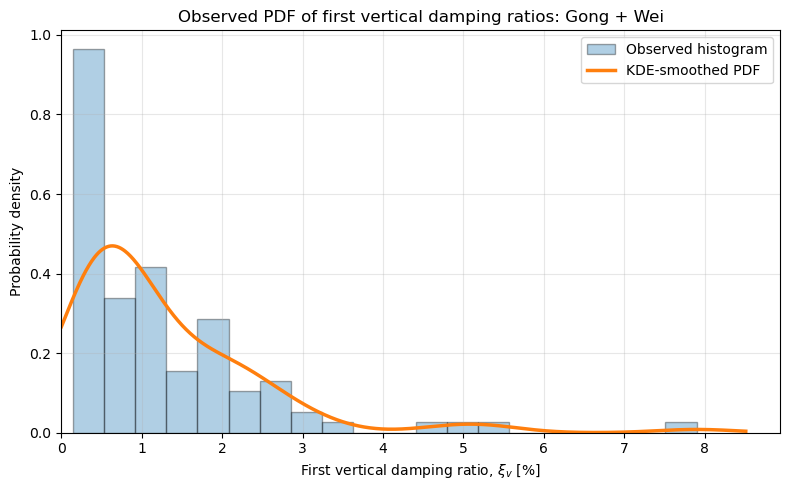

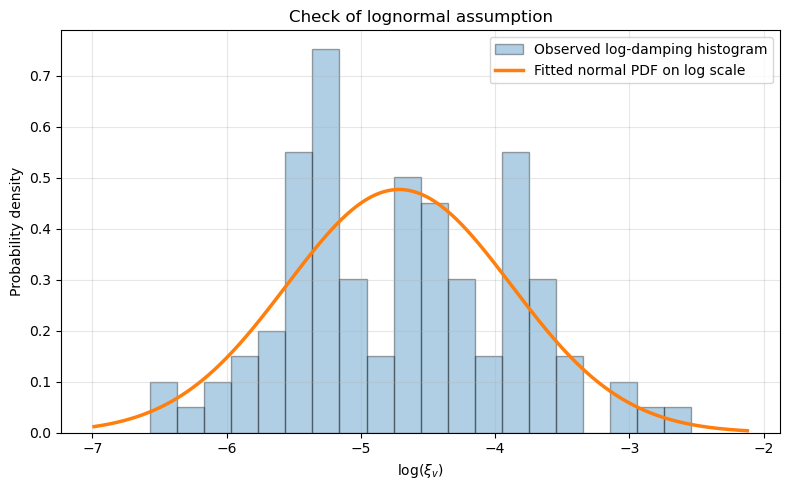

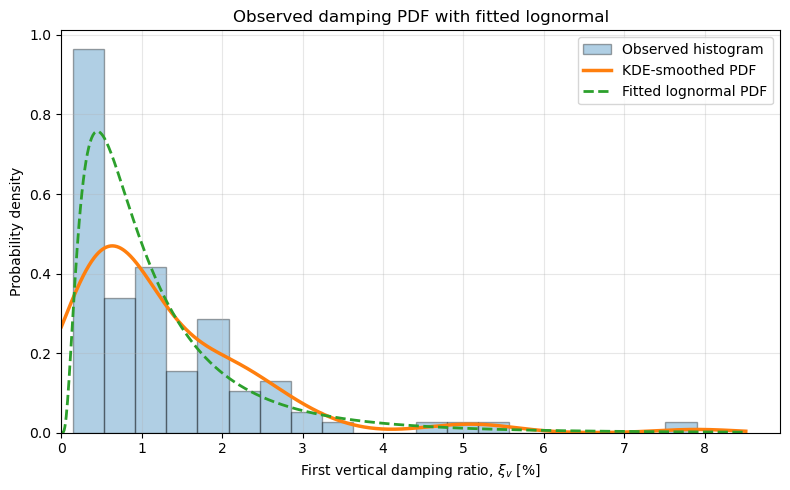

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, lognorm, norm

# ==================================================
# FILE PATHS
# ==================================================
gong_csv = "Gong Bridge data f and damping.csv"
wei_csv = "wei2019_appendix_dynamic_properties_65_footbridges.csv"

# ==================================================
# LOAD DATA
# ==================================================
gong_df = pd.read_csv(gong_csv, encoding="utf-8-sig")
wei_df = pd.read_csv(wei_csv, encoding="utf-8-sig")

# ==================================================
# CLEAN NUMERIC VALUES
# ==================================================
def clean_numeric_column(series):
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")

# ==================================================
# EXTRACT AVAILABLE FIRST VERTICAL DAMPING RATIOS
# ==================================================
# Gong: already ratio, e.g. 0.005 = 0.5%
gong_zeta = clean_numeric_column(gong_df["vertical_damping_ratio"])

# Wei: percent, e.g. 0.43 = 0.43%, convert to ratio
wei_zeta = clean_numeric_column(wei_df["damping_ratio_percent"]) / 100.0

damping_df = pd.DataFrame({
    "damping_ratio": pd.concat([gong_zeta, wei_zeta], ignore_index=True),
    "source": (
        ["Gong"] * len(gong_zeta)
        + ["Wei"] * len(wei_zeta)
    )
})

# Keep observed valid damping values only
damping_df = damping_df.dropna(subset=["damping_ratio"]).copy()
damping_df = damping_df[damping_df["damping_ratio"] > 0].copy()

zeta = damping_df["damping_ratio"].to_numpy()
zeta_percent = zeta * 100

print("Available damping values:")
print(damping_df["source"].value_counts())
print(f"Total available damping values = {len(zeta)}")

print("\nDamping summary in percent:")
print(pd.Series(zeta_percent).describe())

# ==================================================
# PDF OF RAW DAMPING DATA
# ==================================================
x_min = 0.0
x_max = zeta_percent.max() + 0.5 * zeta_percent.std()
x_grid = np.linspace(x_min, x_max, 1000)

kde_raw = gaussian_kde(zeta_percent)
pdf_raw = kde_raw(x_grid)

plt.figure(figsize=(8, 5))

plt.hist(
    zeta_percent,
    bins=20,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="Observed histogram"
)

plt.plot(
    x_grid,
    pdf_raw,
    linewidth=2.5,
    label="KDE-smoothed PDF"
)

plt.xlabel(r"First vertical damping ratio, $\xi_v$ [%]")
plt.ylabel("Probability density")
plt.title("Observed PDF of first vertical damping ratios: Gong + Wei")
plt.xlim(left=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# CHECK LOGNORMAL ASSUMPTION
# If damping is lognormal, log(damping) should look roughly normal.
# ==================================================
log_zeta = np.log(zeta)

log_mean = log_zeta.mean()
log_sd = log_zeta.std(ddof=1)

x_log_grid = np.linspace(
    log_zeta.min() - 0.5 * log_zeta.std(),
    log_zeta.max() + 0.5 * log_zeta.std(),
    1000
)

normal_pdf_on_log_scale = norm.pdf(x_log_grid, loc=log_mean, scale=log_sd)

plt.figure(figsize=(8, 5))

plt.hist(
    log_zeta,
    bins=20,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="Observed log-damping histogram"
)

plt.plot(
    x_log_grid,
    normal_pdf_on_log_scale,
    linewidth=2.5,
    label="Fitted normal PDF on log scale"
)

plt.xlabel(r"$\log(\xi_v)$")
plt.ylabel("Probability density")
plt.title("Check of lognormal assumption")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# OPTIONAL: OVERLAY FITTED LOGNORMAL ON RAW PDF
# ==================================================
shape, loc, scale = lognorm.fit(zeta_percent, floc=0)
lognormal_pdf = lognorm.pdf(x_grid, shape, loc=loc, scale=scale)

plt.figure(figsize=(8, 5))

plt.hist(
    zeta_percent,
    bins=20,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="Observed histogram"
)

plt.plot(
    x_grid,
    pdf_raw,
    linewidth=2.5,
    label="KDE-smoothed PDF"
)

plt.plot(
    x_grid,
    lognormal_pdf,
    linewidth=2.0,
    linestyle="--",
    label="Fitted lognormal PDF"
)

plt.xlabel(r"First vertical damping ratio, $\xi_v$ [%]")
plt.ylabel("Probability density")
plt.title("Observed damping PDF with fitted lognormal")
plt.xlim(left=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Gong columns:
['No', 'cross_section', 'span_m', 'width_m', 'bridge_type', 'girder_material', 'deck_material', 'lateral_natural_frequency_Hz', 'vertical_natural_frequency_Hz', 'lateral_damping_ratio', 'vertical_damping_ratio']

Wei columns:
['no', 'source_section', 'name', 'country_or_place', 'description_for_form', 'construction_year', 'girder_material', 'main_span_m', 'modal_mass_t', 'frequency_hz', 'damping_ratio_percent', 'test_method']
Rows by source:
source
Gong    100
Wei      65
Name: count, dtype: int64

Damping availability:
vertical_damping_ratio
True     99
False    66
Name: count, dtype: int64

First few rows:
  source  bridge_id bridge_name  span_m  first_vertical_frequency_Hz  \
0   Gong          1           1    25.0                        2.440   
1   Gong          2           2    18.0                        8.500   
2   Gong          3           3    60.0                        2.670   
3   Gong          4           4    71.4                        1.968   
4   Gong  

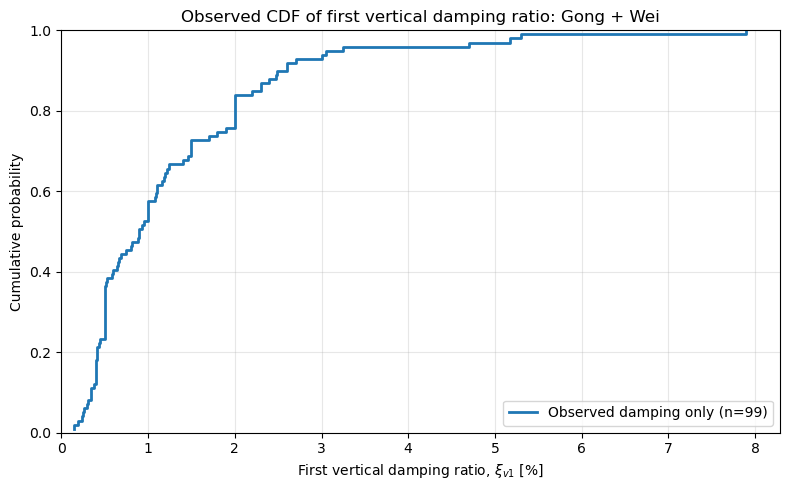


Model data prepared.
Observed indices: 99
Missing indices: 66


Initializing NUTS using jitter+adapt_diag...
c:\Users\slok0019\AppData\Local\miniconda3\envs\sfhsi\lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_log_f, beta_log_L, beta_wei, sigma, log_zeta_missing]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 41 seconds.



Model parameter summary:
              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha      -4.6899  0.1245 -4.9164  -4.4541     0.0018   0.0012  4877.0579   
beta_log_f  0.1486  0.1416 -0.1105   0.4218     0.0019   0.0014  5681.7310   
beta_log_L -0.1716  0.1302 -0.4264   0.0673     0.0017   0.0013  5987.9563   
beta_wei   -0.1079  0.1696 -0.4217   0.2161     0.0023   0.0016  5291.3037   
sigma       0.7984  0.0576  0.6960   0.9078     0.0008   0.0006  5470.6062   

             ess_tail   r_hat  
alpha       5625.1470  1.0001  
beta_log_f  5890.7312  1.0009  
beta_log_L  6599.5631  1.0009  
beta_wei    6102.9830  1.0004  
sigma       5980.5929  1.0000  


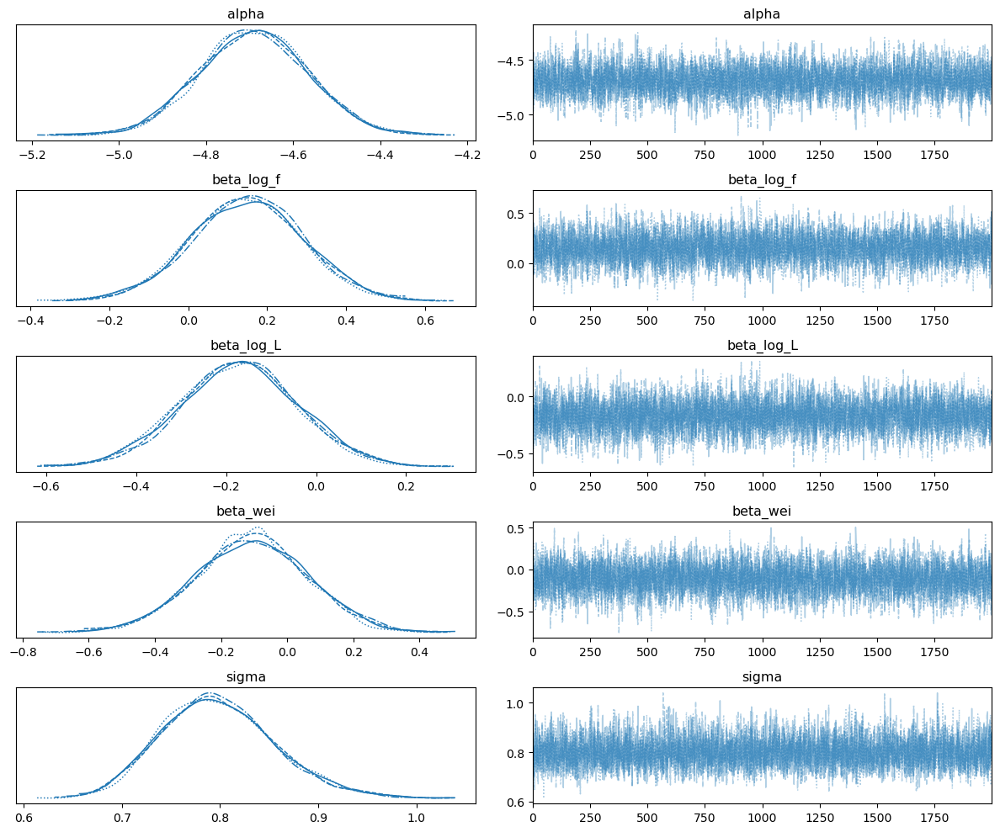


First few imputed damping summaries:
  source bridge_name  span_m  first_vertical_frequency_Hz  \
0   Gong           1    25.0                        2.440   
1   Gong           2    18.0                        8.500   
2   Gong           3    60.0                        2.670   
3   Gong           4    71.4                        1.968   
4   Gong           5    45.0                        1.550   

   zeta_imputed_median  zeta_imputed_lower_95  zeta_imputed_upper_95  \
0             0.011437               0.002295               0.056526   
1             0.015039               0.003072               0.077685   
2             0.009939               0.001963               0.048912   
3             0.008974               0.001772               0.045976   
4             0.009648               0.001873               0.048579   

   zeta_imputed_median_percent  zeta_imputed_lower_95_percent  \
0                     1.143707                       0.229483   
1                     1.503906  

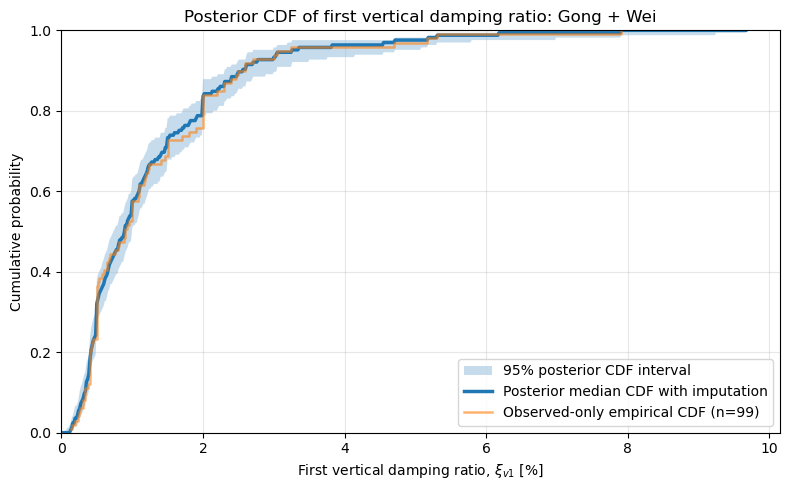

Sampling: [log_zeta_obs]


Output()

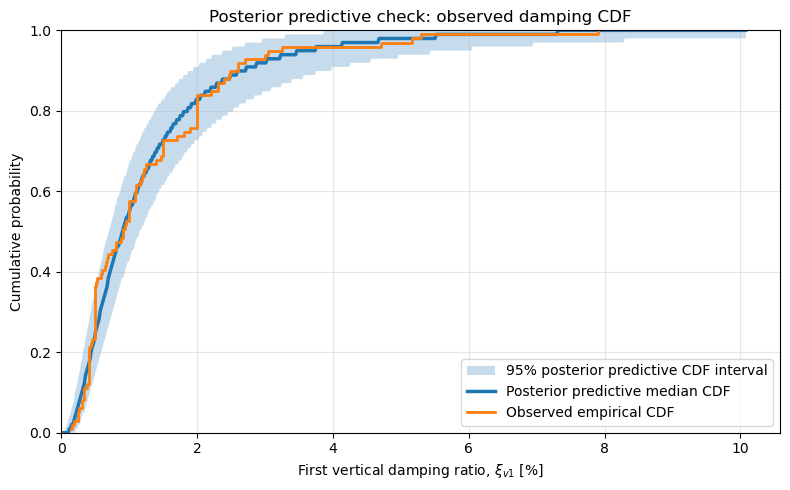


Saved: master_gong_wei_damping_with_bayesian_imputation_summary.csv


In [72]:
# ==================================================
# BAYESIAN IMPUTATION OF FIRST VERTICAL DAMPING RATIO
# DATASETS: GONG + WEI ONLY
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

# ==================================================
# 1. FILE PATHS
# ==================================================
gong_csv = "Gong Bridge data f and damping.csv"
wei_csv = "wei2019_appendix_dynamic_properties_65_footbridges.csv"

# ==================================================
# 2. LOAD DATA
# ==================================================
gong_df = pd.read_csv(gong_csv, encoding="utf-8-sig")
wei_df = pd.read_csv(wei_csv, encoding="utf-8-sig")

print("Gong columns:")
print(gong_df.columns.tolist())

print("\nWei columns:")
print(wei_df.columns.tolist())


# ==================================================
# 3. HELPER FUNCTIONS
# ==================================================
def clean_numeric_column(series):
    """
    Converts values such as 'unknown', blanks, or text-containing numbers
    into clean numeric values.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def get_first_existing_column(df, possible_names):
    """
    Finds the first available column from a list of possible names.
    """
    for col in possible_names:
        if col in df.columns:
            return col
    raise KeyError(f"None of these columns were found: {possible_names}")

'''
# ==================================================
# 4. IDENTIFY COLUMNS
# ==================================================
gong_name_col = "name" if "name" in gong_df.columns else None

gong_span_col = get_first_existing_column(
    gong_df,
    ["span_m", "span", "largest_span_m", "largest_span"]
)

gong_freq_col = get_first_existing_column(
    gong_df,
    ["vertical_natural_frequency_Hz", "first_vertical_frequency_Hz", "frequency_hz"]
)

gong_damp_col = get_first_existing_column(
    gong_df,
    ["vertical_damping_ratio", "first_vertical_damping_ratio", "damping_ratio"]
)

wei_name_col = get_first_existing_column(
    wei_df,
    ["name", "bridge_name"]
)

wei_span_col = get_first_existing_column(
    wei_df,
    ["span_m", "span", "largest_span_m", "largest_span"]
)

wei_freq_col = get_first_existing_column(
    wei_df,
    ["frequency_hz", "first_vertical_frequency_Hz", "vertical_natural_frequency_Hz"]
)

wei_damp_col = get_first_existing_column(
    wei_df,
    ["damping_ratio_percent", "damping_percent", "damping_ratio"]
)

print("\nUsing columns:")
print("Gong span:", gong_span_col)
print("Gong frequency:", gong_freq_col)
print("Gong damping:", gong_damp_col)
print("Wei span:", wei_span_col)
print("Wei frequency:", wei_freq_col)
print("Wei damping:", wei_damp_col)'''


# ==================================================
# 4. BUILD MASTER DATAFRAME DIRECTLY FROM YOUR COLUMNS
# ==================================================

# Gong: damping already ratio, e.g. 0.005 = 0.5%
gong_part = pd.DataFrame({
    "source": "Gong",
    "bridge_id": gong_df["No"],
    "bridge_name": gong_df["No"].astype(str),   # Gong has no name column
    "span_m": clean_numeric_column(gong_df["span_m"]),
    "first_vertical_frequency_Hz": clean_numeric_column(
        gong_df["vertical_natural_frequency_Hz"]
    ),
    "vertical_damping_ratio": clean_numeric_column(
        gong_df["vertical_damping_ratio"]
    )
})

# Wei: damping is percent, e.g. 0.43 = 0.43%
# Convert to ratio: 0.43 / 100 = 0.0043
wei_part = pd.DataFrame({
    "source": "Wei",
    "bridge_id": wei_df["no"],
    "bridge_name": wei_df["name"],
    "span_m": clean_numeric_column(wei_df["main_span_m"]),
    "first_vertical_frequency_Hz": clean_numeric_column(
        wei_df["frequency_hz"]
    ),
    "vertical_damping_ratio": clean_numeric_column(
        wei_df["damping_ratio_percent"]
    ) / 100.0
})

# Combine Gong + Wei
master_df = pd.concat([gong_part, wei_part], ignore_index=True)

# Keep rows with usable span and frequency
master_df = master_df.dropna(
    subset=["span_m", "first_vertical_frequency_Hz"]
).copy()

master_df = master_df[
    (master_df["span_m"] > 0)
    & (master_df["first_vertical_frequency_Hz"] > 0)
].copy()

# Keep missing damping as NaN, but remove impossible observed values
bad_damping_mask = (
    master_df["vertical_damping_ratio"].notna()
    & (
        (master_df["vertical_damping_ratio"] <= 0)
        | (master_df["vertical_damping_ratio"] > 0.20)
    )
)

master_df.loc[bad_damping_mask, "vertical_damping_ratio"] = np.nan

master_df = master_df.reset_index(drop=True)

print("Rows by source:")
print(master_df["source"].value_counts())

print("\nDamping availability:")
print(master_df["vertical_damping_ratio"].notna().value_counts())

print("\nFirst few rows:")
print(master_df.head())


# ==================================================
# 6. OBSERVED-ONLY CDF
# ==================================================
observed_zeta = master_df.loc[
    master_df["vertical_damping_ratio"].notna(),
    "vertical_damping_ratio"
].to_numpy()

obs_sorted = np.sort(observed_zeta)
obs_cdf = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)

plt.figure(figsize=(8, 5))
plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label=f"Observed damping only (n={len(observed_zeta)})"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Observed CDF of first vertical damping ratio: Gong + Wei")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# 7. PREPARE BAYESIAN MODEL VARIABLES
# ==================================================
obs_mask = master_df["vertical_damping_ratio"].notna().to_numpy()
miss_mask = ~obs_mask

obs_idx = np.where(obs_mask)[0]
miss_idx = np.where(miss_mask)[0]

# Target on log scale
y_obs = np.log(master_df.loc[obs_idx, "vertical_damping_ratio"].to_numpy())

# Predictors
log_f_raw = np.log(master_df["first_vertical_frequency_Hz"].to_numpy())
log_L_raw = np.log(master_df["span_m"].to_numpy())

# Standardise predictors
log_f_mean = log_f_raw.mean()
log_f_std = log_f_raw.std()

log_L_mean = log_L_raw.mean()
log_L_std = log_L_raw.std()

x_log_f = (log_f_raw - log_f_mean) / log_f_std
x_log_L = (log_L_raw - log_L_mean) / log_L_std

# Source indicator:
# Gong = 0, Wei = 1
source_is_wei = (master_df["source"].to_numpy() == "Wei").astype(int)

print("\nModel data prepared.")
print("Observed indices:", len(obs_idx))
print("Missing indices:", len(miss_idx))


# ==================================================
# 8. BAYESIAN IMPUTATION MODEL
# ==================================================
with pm.Model() as damping_model:

    # ------------------------------
    # Priors
    # ------------------------------

    # Average damping level around 1% on ratio scale:
    # log(0.01)
    alpha = pm.Normal(
        "alpha",
        mu=np.log(0.01),
        sigma=1.0
    )

    # Effect of first vertical frequency
    beta_log_f = pm.Normal(
        "beta_log_f",
        mu=0.0,
        sigma=0.5
    )

    # Effect of span
    beta_log_L = pm.Normal(
        "beta_log_L",
        mu=0.0,
        sigma=0.5
    )

    # Dataset/source effect:
    # Gong baseline, Wei offset
    beta_wei = pm.Normal(
        "beta_wei",
        mu=0.0,
        sigma=0.5
    )

    # Scatter in log damping
    sigma = pm.Exponential(
        "sigma",
        lam=2.0
    )

    # ------------------------------
    # Linear predictor for all bridges
    # ------------------------------
    mu_all = (
        alpha
        + beta_log_f * x_log_f
        + beta_log_L * x_log_L
        + beta_wei * source_is_wei
    )

    # ------------------------------
    # Likelihood for observed damping
    # ------------------------------
    log_zeta_obs = pm.Normal(
        "log_zeta_obs",
        mu=mu_all[obs_idx],
        sigma=sigma,
        observed=y_obs
    )

    # ------------------------------
    # Latent missing damping values
    # ------------------------------
    log_zeta_missing = pm.Normal(
        "log_zeta_missing",
        mu=mu_all[miss_idx],
        sigma=sigma,
        shape=len(miss_idx)
    )

    zeta_missing = pm.Deterministic(
        "zeta_missing",
        pm.math.exp(log_zeta_missing)
    )

    # Typical fitted damping for all bridges
    zeta_typical_all = pm.Deterministic(
        "zeta_typical_all",
        pm.math.exp(mu_all)
    )

    # ------------------------------
    # Sampling
    # ------------------------------
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.90,
        random_seed=42
    )


# ==================================================
# 9. DIAGNOSTICS
# ==================================================
summary = az.summary(
    trace,
    var_names=["alpha", "beta_log_f", "beta_log_L", "beta_wei", "sigma"],
    round_to=4
)

print("\nModel parameter summary:")
print(summary)

az.plot_trace(
    trace,
    var_names=["alpha", "beta_log_f", "beta_log_L", "beta_wei", "sigma"]
)

plt.tight_layout()
plt.show()


# ==================================================
# 10. EXTRACT IMPUTED DAMPING VALUES
# ==================================================
if len(miss_idx) > 0:

    missing_samples = (
        trace.posterior["zeta_missing"]
        .stack(sample=("chain", "draw"))
        .transpose("zeta_missing_dim_0", "sample")
        .values
    )

    # missing_samples shape = [n_missing, n_posterior_samples]

    imputed_summary = master_df.loc[miss_idx, [
        "source",
        "bridge_name",
        "span_m",
        "first_vertical_frequency_Hz"
    ]].copy()

    imputed_summary["zeta_imputed_median"] = np.percentile(missing_samples, 50, axis=1)
    imputed_summary["zeta_imputed_lower_95"] = np.percentile(missing_samples, 2.5, axis=1)
    imputed_summary["zeta_imputed_upper_95"] = np.percentile(missing_samples, 97.5, axis=1)

    imputed_summary["zeta_imputed_median_percent"] = imputed_summary["zeta_imputed_median"] * 100
    imputed_summary["zeta_imputed_lower_95_percent"] = imputed_summary["zeta_imputed_lower_95"] * 100
    imputed_summary["zeta_imputed_upper_95_percent"] = imputed_summary["zeta_imputed_upper_95"] * 100

    print("\nFirst few imputed damping summaries:")
    print(imputed_summary.head())

    imputed_summary.to_csv(
        "bayesian_imputed_missing_damping_gong_wei.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\nSaved: bayesian_imputed_missing_damping_gong_wei.csv")

else:
    missing_samples = np.empty((0, 0))
    print("\nNo missing damping values to impute.")


# ==================================================
# 11. POSTERIOR CDF INCLUDING IMPUTED VALUES
# ==================================================
if len(miss_idx) > 0:

    n_draws = missing_samples.shape[1]

    all_values_for_grid = np.concatenate([
        observed_zeta,
        missing_samples.ravel()
    ])

    # Use 99.5 percentile to avoid extreme tail stretching the x-axis too much
    x_max = np.percentile(all_values_for_grid, 99.5) * 1.20
    x_max = max(x_max, observed_zeta.max() * 1.10)

    x_grid = np.linspace(0, x_max, 600)

    cdf_samples = np.zeros((n_draws, len(x_grid)))

    for j in range(n_draws):
        full_zeta_j = np.concatenate([
            observed_zeta,
            missing_samples[:, j]
        ])

        cdf_samples[j, :] = np.mean(
            full_zeta_j[:, None] <= x_grid[None, :],
            axis=0
        )

    cdf_median = np.percentile(cdf_samples, 50, axis=0)
    cdf_lower = np.percentile(cdf_samples, 2.5, axis=0)
    cdf_upper = np.percentile(cdf_samples, 97.5, axis=0)

    plt.figure(figsize=(8, 5))

    plt.fill_between(
        x_grid * 100,
        cdf_lower,
        cdf_upper,
        alpha=0.25,
        label="95% posterior CDF interval"
    )

    plt.plot(
        x_grid * 100,
        cdf_median,
        linewidth=2.5,
        label="Posterior median CDF with imputation"
    )

    plt.step(
        obs_sorted * 100,
        obs_cdf,
        where="post",
        linewidth=1.8,
        alpha=0.6,
        label=f"Observed-only empirical CDF (n={len(observed_zeta)})"
    )

    plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
    plt.ylabel("Cumulative probability")
    plt.title("Posterior CDF of first vertical damping ratio: Gong + Wei")
    plt.xlim(left=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==================================================
# 12. POSTERIOR PREDICTIVE CHECK
# ==================================================
with damping_model:
    ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["log_zeta_obs"],
        random_seed=42
    )

ppc_log = (
    ppc.posterior_predictive["log_zeta_obs"]
    .stack(sample=("chain", "draw"))
    .transpose("log_zeta_obs_dim_0", "sample")
    .values
)

ppc_zeta = np.exp(ppc_log)

n_ppc_draws = ppc_zeta.shape[1]

x_grid_ppc = np.linspace(
    0,
    np.percentile(np.concatenate([observed_zeta, ppc_zeta.ravel()]), 99.5) * 1.2,
    600
)

ppc_cdf_samples = np.zeros((n_ppc_draws, len(x_grid_ppc)))

for j in range(n_ppc_draws):
    ppc_cdf_samples[j, :] = np.mean(
        ppc_zeta[:, j][:, None] <= x_grid_ppc[None, :],
        axis=0
    )

ppc_cdf_median = np.percentile(ppc_cdf_samples, 50, axis=0)
ppc_cdf_lower = np.percentile(ppc_cdf_samples, 2.5, axis=0)
ppc_cdf_upper = np.percentile(ppc_cdf_samples, 97.5, axis=0)

plt.figure(figsize=(8, 5))

plt.fill_between(
    x_grid_ppc * 100,
    ppc_cdf_lower,
    ppc_cdf_upper,
    alpha=0.25,
    label="95% posterior predictive CDF interval"
)

plt.plot(
    x_grid_ppc * 100,
    ppc_cdf_median,
    linewidth=2.5,
    label="Posterior predictive median CDF"
)

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label="Observed empirical CDF"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Posterior predictive check: observed damping CDF")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# 13. SAVE MASTER DATA WITH OBSERVED/IMPUTED STATUS
# ==================================================
master_out = master_df.copy()
master_out["damping_observed"] = master_out["vertical_damping_ratio"].notna()

if len(miss_idx) > 0:
    master_out.loc[miss_idx, "zeta_imputed_median"] = imputed_summary["zeta_imputed_median"].values
    master_out.loc[miss_idx, "zeta_imputed_lower_95"] = imputed_summary["zeta_imputed_lower_95"].values
    master_out.loc[miss_idx, "zeta_imputed_upper_95"] = imputed_summary["zeta_imputed_upper_95"].values

master_out.to_csv(
    "master_gong_wei_damping_with_bayesian_imputation_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved: master_gong_wei_damping_with_bayesian_imputation_summary.csv")

Sampling: [alpha, beta_log_L, beta_log_f, beta_wei, sigma]


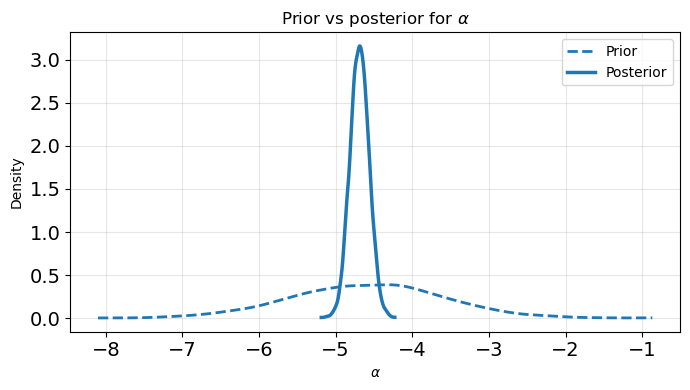

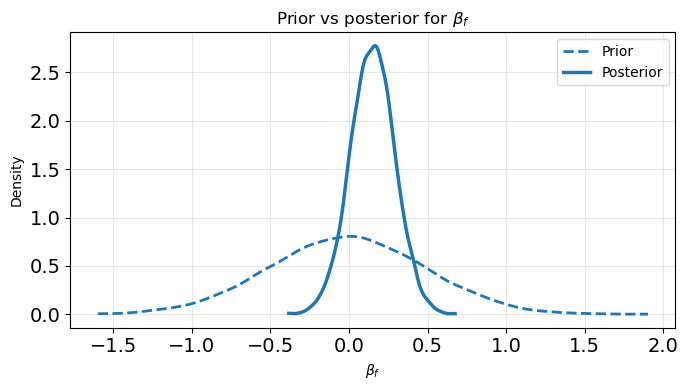

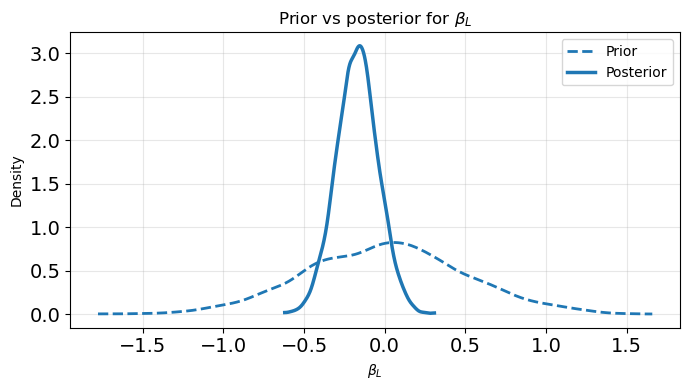

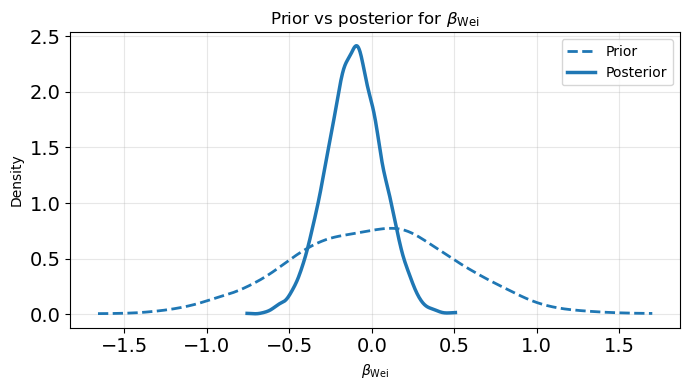

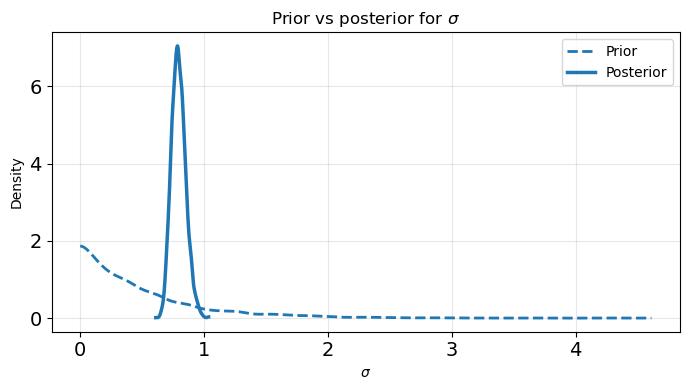

In [73]:
# ==================================================
# PRIOR VS POSTERIOR PLOTS FOR MODEL PARAMETERS
# ==================================================

import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# Main unknown model parameters
param_names = [
    "alpha",
    "beta_log_f",
    "beta_log_L",
    "beta_wei",
    "sigma"
]

label_map = {
    "alpha": r"$\alpha$",
    "beta_log_f": r"$\beta_f$",
    "beta_log_L": r"$\beta_L$",
    "beta_wei": r"$\beta_{\mathrm{Wei}}$",
    "sigma": r"$\sigma$"
}

# ==================================================
# SAMPLE FROM PRIORS
# ==================================================
with damping_model:
    prior = pm.sample_prior_predictive(
        samples=5000,
        var_names=param_names,
        random_seed=42
    )

# ==================================================
# HELPER TO FLATTEN PRIOR/POSTERIOR SAMPLES
# ==================================================
def flatten_prior(idata, var_name):
    return idata.prior[var_name].values.reshape(-1)

def flatten_posterior(idata, var_name):
    return idata.posterior[var_name].values.reshape(-1)

# ==================================================
# PLOT PRIOR AND POSTERIOR FOR EACH PARAMETER
# ==================================================
for var in param_names:
    prior_samples = flatten_prior(prior, var)
    posterior_samples = flatten_posterior(trace, var)

    plt.figure(figsize=(7, 4))

    az.plot_kde(
        prior_samples,
        label="Prior",
        plot_kwargs={"linewidth": 2, "linestyle": "--"}
    )

    az.plot_kde(
        posterior_samples,
        label="Posterior",
        plot_kwargs={"linewidth": 2.5}
    )

    plt.xlabel(label_map[var])
    plt.ylabel("Density")
    plt.title(f"Prior vs posterior for {label_map[var]}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

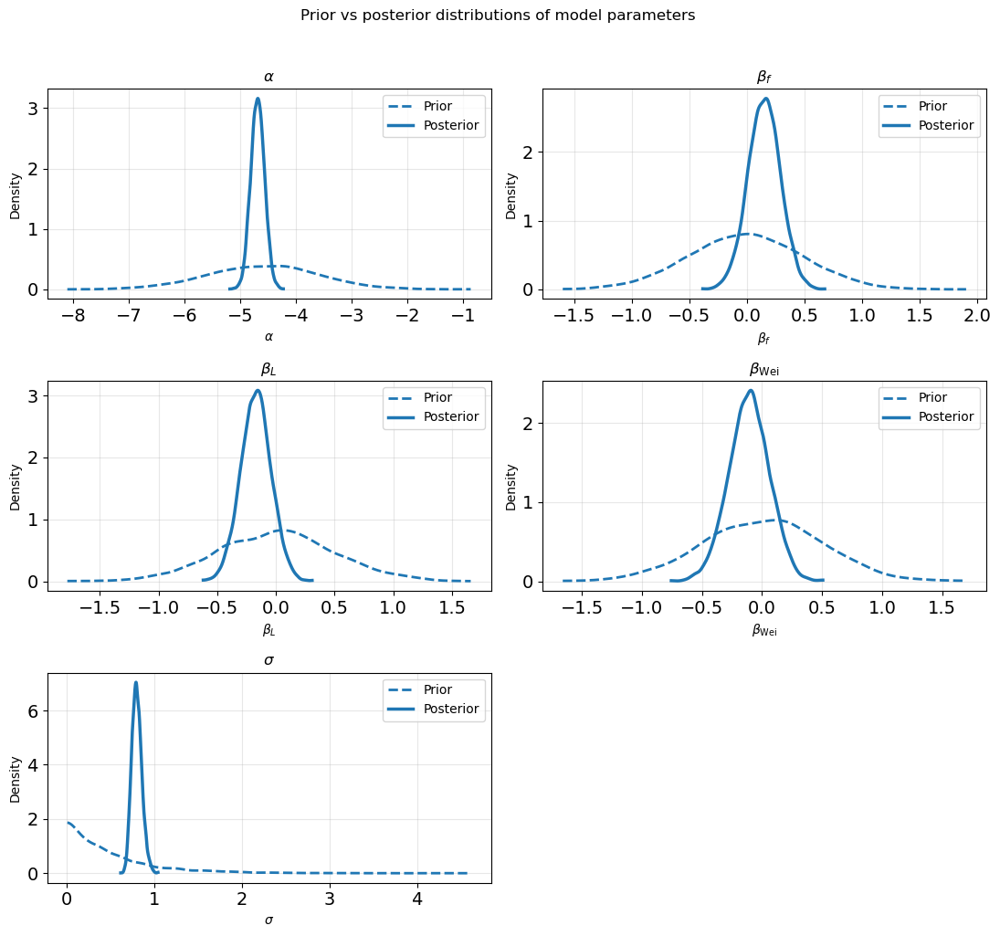

In [74]:
# ==================================================
# PRIOR VS POSTERIOR IN ONE COMBINED FIGURE
# ==================================================

fig, axes = plt.subplots(3, 2, figsize=(11, 10))
axes = axes.flatten()

for ax, var in zip(axes, param_names):
    prior_samples = flatten_prior(prior, var)
    posterior_samples = flatten_posterior(trace, var)

    az.plot_kde(
        prior_samples,
        ax=ax,
        label="Prior",
        plot_kwargs={"linewidth": 2, "linestyle": "--"}
    )

    az.plot_kde(
        posterior_samples,
        ax=ax,
        label="Posterior",
        plot_kwargs={"linewidth": 2.5}
    )

    ax.set_title(label_map[var])
    ax.set_xlabel(label_map[var])
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

# Remove unused subplot
fig.delaxes(axes[-1])

plt.suptitle("Prior vs posterior distributions of model parameters", y=1.02)
plt.tight_layout()
plt.show()

Columns in master CSV:
['No', 'span_m', 'width_m', 'vertical_natural_frequency_Hz', 'vertical_damping_ratio', 'cross_section', 'bridge_type', 'girder_material', 'deck_material', 'lateral_natural_frequency_Hz', 'lateral_damping_ratio']

Rows kept for Bayesian model: 244

Damping availability:
vertical_damping_ratio
missing      146
available     98
Name: count, dtype: int64

First few rows:
   bridge_id  span_m  first_vertical_frequency_Hz  vertical_damping_ratio
0          1    25.0                        2.440                     NaN
1          2    18.0                        8.500                     NaN
2          3    60.0                        2.670                     NaN
3          4    71.4                        1.968                     NaN
4          5    45.0                        1.550                     NaN


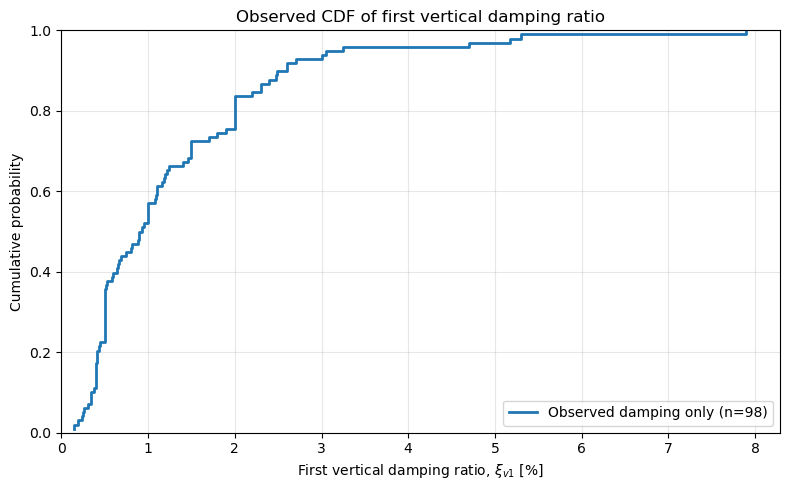


Model data prepared.
Observed damping rows: 98
Missing damping rows: 146


Sampling: [alpha, beta_log_L, beta_log_f, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_log_f, beta_log_L, sigma, log_zeta_missing]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 45 seconds.



Model parameter summary:
              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha      -4.6725  0.0826 -4.8265  -4.5185     0.0012   0.0008  4389.8177   
beta_log_f  0.1409  0.1363 -0.1152   0.4051     0.0025   0.0015  3068.9134   
beta_log_L -0.1356  0.1215 -0.3691   0.0869     0.0020   0.0012  3822.8803   
sigma       0.7970  0.0585  0.6901   0.9056     0.0011   0.0006  2756.7189   

             ess_tail   r_hat  
alpha       5207.8240  1.0003  
beta_log_f  4629.6395  1.0014  
beta_log_L  4820.6138  1.0007  
sigma       4980.5296  1.0017  


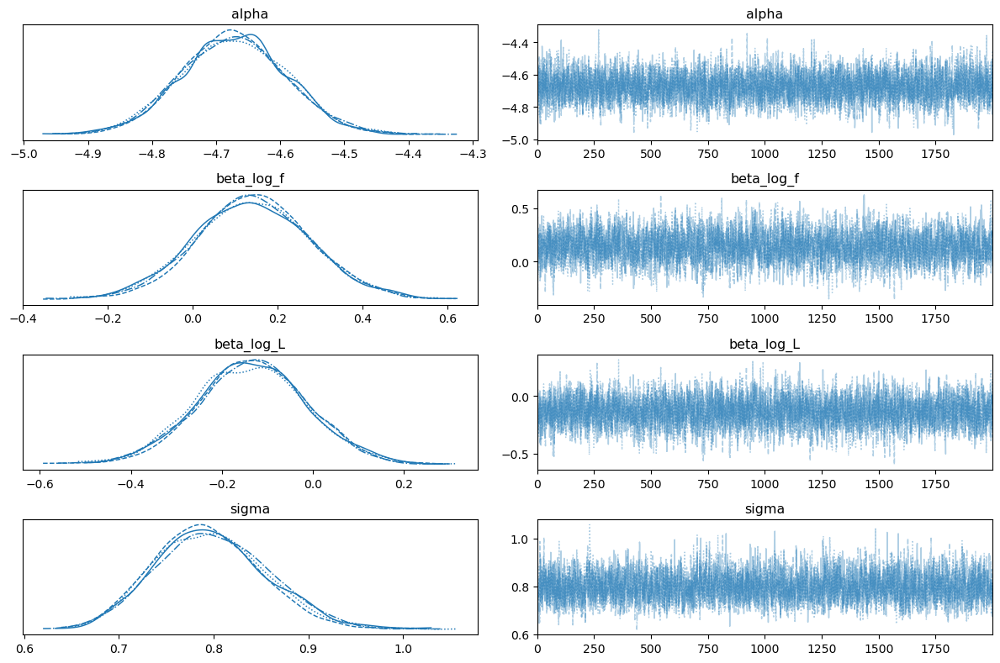

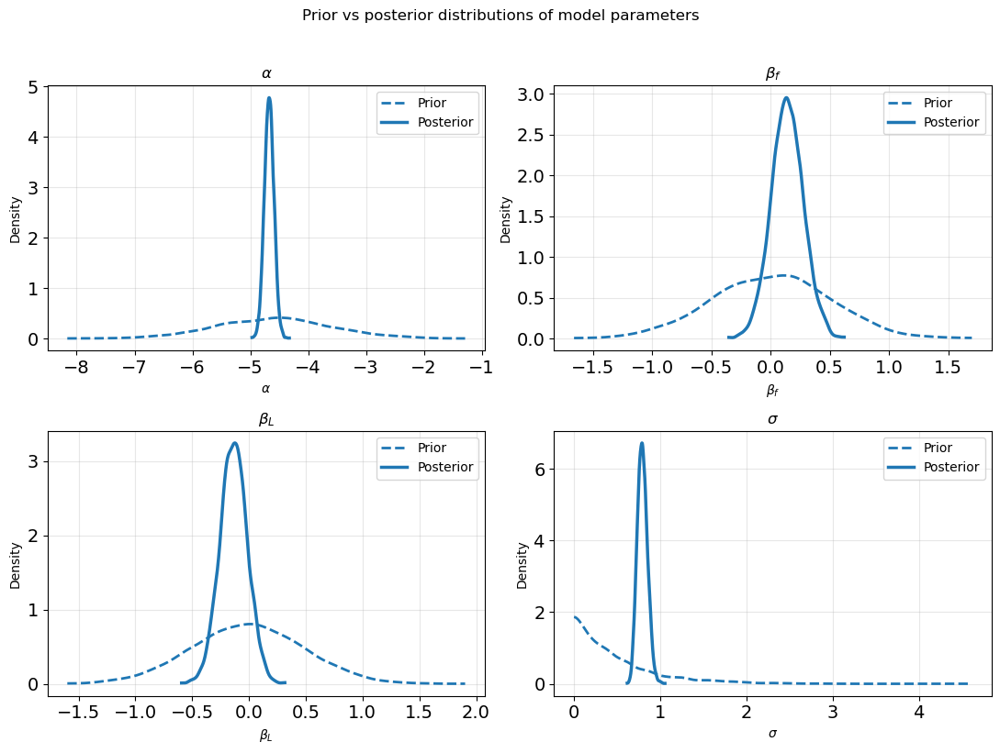


First few imputed damping summaries:
   bridge_id  span_m  first_vertical_frequency_Hz  zeta_imputed_median  \
0          1    25.0                        2.440             0.010670   
1          2    18.0                        8.500             0.013844   
2          3    60.0                        2.670             0.009363   
3          4    71.4                        1.968             0.008608   
4          5    45.0                        1.550             0.009010   

   zeta_imputed_lower_95  zeta_imputed_upper_95  zeta_imputed_median_percent  \
0               0.002204               0.052088                     1.067034   
1               0.002793               0.071676                     1.384363   
2               0.001978               0.043849                     0.936303   
3               0.001757               0.040294                     0.860780   
4               0.001790               0.043978                     0.900989   

   zeta_imputed_lower_95_percent  ze

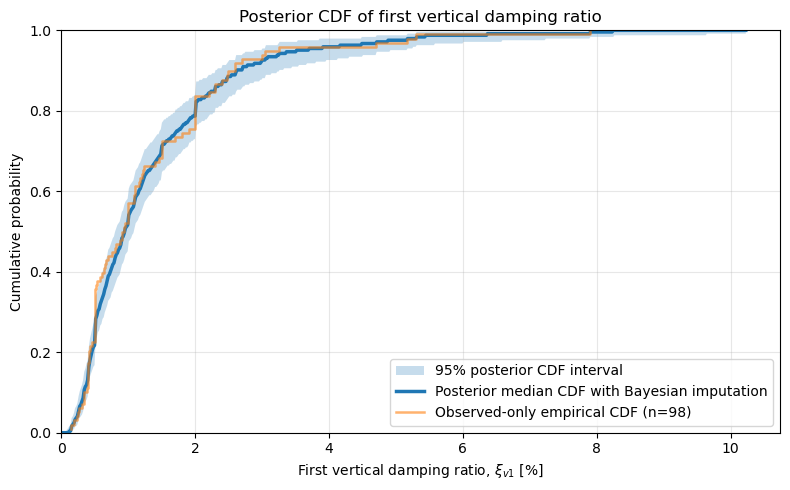

Sampling: [log_zeta_obs]


Output()

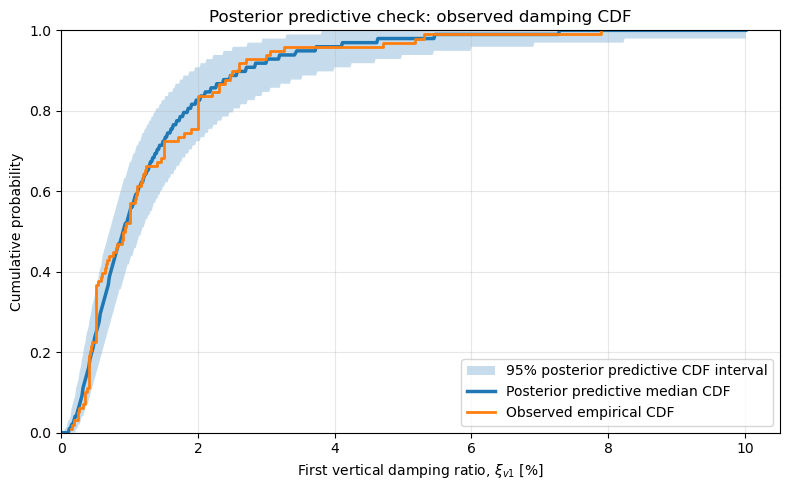


Saved: master_all_bridges_vertical_damping_span_frequency_only.csv


In [76]:
# ==================================================
# BAYESIAN IMPUTATION OF FIRST VERTICAL DAMPING RATIO
# MASTER CSV: GONG + WEI + OLIVEIRA IN ONE FILE
# SIMPLE MODEL: ONLY SPAN + FIRST VERTICAL FREQUENCY
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

# ==================================================
# 1. FILE PATH
# ==================================================
data_csv = "data gong wei olivieri.csv"

# ==================================================
# 2. LOAD MASTER DATA
# ==================================================
master_df = pd.read_csv(data_csv, encoding="utf-8-sig")

print("Columns in master CSV:")
print(master_df.columns.tolist())

# ==================================================
# 3. HELPER FUNCTIONS
# ==================================================
def clean_numeric_column(series):
    """
    Converts values such as blanks, unknown, percentages,
    or text-containing numbers into clean numeric values.
    For normal numeric columns, it extracts the first number.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("–", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def clean_damping_ratio(series):
    """
    Cleans damping ratio.

    Final expected unit:
        0.005 = 0.5%

    Handles:
        0.005       -> 0.005
        0.43        -> 0.0043, treated as 0.43%
        0.3-0.5     -> 0.004, treated as midpoint 0.4%
        #VALUE!     -> NaN
    """
    raw = series.astype(str)
    raw = raw.str.replace("−", "-", regex=False)
    raw = raw.str.replace("–", "-", regex=False)
    raw = raw.str.replace("%", "", regex=False)

    cleaned_values = []

    for item in raw:
        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", item)

        if len(nums) == 0:
            cleaned_values.append(np.nan)

        elif len(nums) >= 2 and "-" in item:
            # If value is a range like 0.3-0.5, take midpoint
            vals = [float(nums[0]), float(nums[1])]
            cleaned_values.append(np.mean(vals))

        else:
            cleaned_values.append(float(nums[0]))

    z = pd.Series(cleaned_values, index=series.index, dtype=float)

    # Convert percent-like values to ratio
    # Example: 0.43 means 0.43%, so convert to 0.0043
    percent_like = z.notna() & (z > 0.20) & (z <= 20)

    if percent_like.any():
        print(f"\nConverting {percent_like.sum()} damping values from percent to ratio.")
        z.loc[percent_like] = z.loc[percent_like] / 100.0

    # Remove impossible values
    impossible = z.notna() & ((z <= 0) | (z > 0.20))

    if impossible.any():
        print(f"\nSetting {impossible.sum()} impossible damping values to NaN.")
        z.loc[impossible] = np.nan

    return z


# Needed for clean_damping_ratio
import re

# ==================================================
# 4. CLEAN REQUIRED COLUMNS
# ==================================================

# Bridge ID
if "No" in master_df.columns:
    master_df["bridge_id"] = master_df["No"]
else:
    master_df["bridge_id"] = np.arange(1, len(master_df) + 1)

# Required predictors
master_df["span_m"] = clean_numeric_column(master_df["span_m"])

master_df["first_vertical_frequency_Hz"] = clean_numeric_column(
    master_df["vertical_natural_frequency_Hz"]
)

# Target variable: damping
master_df["vertical_damping_ratio"] = clean_damping_ratio(
    master_df["vertical_damping_ratio"]
)

# ==================================================
# 5. KEEP ROWS WITH REQUIRED PREDICTORS
# ==================================================
# We need span and first vertical frequency.
# Damping is allowed to be missing.
master_df = master_df.dropna(
    subset=["span_m", "first_vertical_frequency_Hz"]
).copy()

master_df = master_df[
    (master_df["span_m"] > 0)
    & (master_df["first_vertical_frequency_Hz"] > 0)
].copy()

master_df = master_df.reset_index(drop=True)

print("\nRows kept for Bayesian model:", len(master_df))

print("\nDamping availability:")
print(
    master_df["vertical_damping_ratio"]
    .notna()
    .value_counts()
    .rename(index={True: "available", False: "missing"})
)

print("\nFirst few rows:")
print(master_df[[
    "bridge_id",
    "span_m",
    "first_vertical_frequency_Hz",
    "vertical_damping_ratio"
]].head())

# ==================================================
# 6. OBSERVED-ONLY CDF
# ==================================================
observed_zeta = master_df.loc[
    master_df["vertical_damping_ratio"].notna(),
    "vertical_damping_ratio"
].to_numpy()

obs_sorted = np.sort(observed_zeta)
obs_cdf = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)

plt.figure(figsize=(8, 5))

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label=f"Observed damping only (n={len(observed_zeta)})"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Observed CDF of first vertical damping ratio")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# 7. PREPARE BAYESIAN MODEL VARIABLES
# ==================================================
obs_mask = master_df["vertical_damping_ratio"].notna().to_numpy()
miss_mask = ~obs_mask

obs_idx = np.where(obs_mask)[0]
miss_idx = np.where(miss_mask)[0]

# Observed damping on log scale
y_obs = np.log(master_df.loc[obs_idx, "vertical_damping_ratio"].to_numpy())

# Predictors
log_f_raw = np.log(master_df["first_vertical_frequency_Hz"].to_numpy())
log_L_raw = np.log(master_df["span_m"].to_numpy())

# Store scaling values for interpretation later
log_f_mean = log_f_raw.mean()
log_f_std = log_f_raw.std()

log_L_mean = log_L_raw.mean()
log_L_std = log_L_raw.std()

# Standardised predictors
x_log_f = (log_f_raw - log_f_mean) / log_f_std
x_log_L = (log_L_raw - log_L_mean) / log_L_std

print("\nModel data prepared.")
print("Observed damping rows:", len(obs_idx))
print("Missing damping rows:", len(miss_idx))

# ==================================================
# 8. BAYESIAN IMPUTATION MODEL
# ==================================================
with pm.Model() as damping_model:

    # ------------------------------
    # Priors
    # ------------------------------
    alpha = pm.Normal(
        "alpha",
        mu=np.log(0.01),
        sigma=1.0
    )

    beta_log_f = pm.Normal(
        "beta_log_f",
        mu=0.0,
        sigma=0.5
    )

    beta_log_L = pm.Normal(
        "beta_log_L",
        mu=0.0,
        sigma=0.5
    )

    sigma = pm.Exponential(
        "sigma",
        lam=2.0
    )

    # ------------------------------
    # Linear predictor
    # ------------------------------
    mu_all = (
        alpha
        + beta_log_f * x_log_f
        + beta_log_L * x_log_L
    )

    # ------------------------------
    # Likelihood for observed damping
    # ------------------------------
    log_zeta_obs = pm.Normal(
        "log_zeta_obs",
        mu=mu_all[obs_idx],
        sigma=sigma,
        observed=y_obs
    )

    # ------------------------------
    # Missing damping values as latent variables
    # ------------------------------
    log_zeta_missing = pm.Normal(
        "log_zeta_missing",
        mu=mu_all[miss_idx],
        sigma=sigma,
        shape=len(miss_idx)
    )

    zeta_missing = pm.Deterministic(
        "zeta_missing",
        pm.math.exp(log_zeta_missing)
    )

    zeta_typical_all = pm.Deterministic(
        "zeta_typical_all",
        pm.math.exp(mu_all)
    )

    # ------------------------------
    # Prior predictive samples
    # ------------------------------
    param_names = [
        "alpha",
        "beta_log_f",
        "beta_log_L",
        "sigma"
    ]

    prior = pm.sample_prior_predictive(
        samples=5000,
        var_names=param_names,
        random_seed=42
    )

    # ------------------------------
    # Posterior sampling
    # ------------------------------
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.90,
        random_seed=42
    )

# ==================================================
# 9. DIAGNOSTICS
# ==================================================
summary = az.summary(
    trace,
    var_names=param_names,
    round_to=4
)

print("\nModel parameter summary:")
print(summary)

az.plot_trace(
    trace,
    var_names=param_names
)

plt.tight_layout()
plt.show()

# ==================================================
# 10. PRIOR VS POSTERIOR PARAMETER PLOTS
# ==================================================
label_map = {
    "alpha": r"$\alpha$",
    "beta_log_f": r"$\beta_f$",
    "beta_log_L": r"$\beta_L$",
    "sigma": r"$\sigma$",
}

def flatten_prior(idata, var_name):
    return idata.prior[var_name].values.reshape(-1)

def flatten_posterior(idata, var_name):
    return idata.posterior[var_name].values.reshape(-1)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, var in zip(axes, param_names):

    prior_samples = flatten_prior(prior, var)
    posterior_samples = flatten_posterior(trace, var)

    az.plot_kde(
        prior_samples,
        ax=ax,
        label="Prior",
        plot_kwargs={"linewidth": 2, "linestyle": "--"}
    )

    az.plot_kde(
        posterior_samples,
        ax=ax,
        label="Posterior",
        plot_kwargs={"linewidth": 2.5}
    )

    ax.set_title(label_map[var])
    ax.set_xlabel(label_map[var])
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Prior vs posterior distributions of model parameters", y=1.02)
plt.tight_layout()
plt.show()

# ==================================================
# 11. EXTRACT IMPUTED DAMPING VALUES
# ==================================================
if len(miss_idx) > 0:

    missing_samples = (
        trace.posterior["zeta_missing"]
        .stack(sample=("chain", "draw"))
        .transpose("zeta_missing_dim_0", "sample")
        .values
    )

    imputed_summary = master_df.loc[miss_idx, [
        "bridge_id",
        "span_m",
        "first_vertical_frequency_Hz"
    ]].copy()

    imputed_summary["zeta_imputed_median"] = np.percentile(
        missing_samples, 50, axis=1
    )
    imputed_summary["zeta_imputed_lower_95"] = np.percentile(
        missing_samples, 2.5, axis=1
    )
    imputed_summary["zeta_imputed_upper_95"] = np.percentile(
        missing_samples, 97.5, axis=1
    )

    imputed_summary["zeta_imputed_median_percent"] = (
        imputed_summary["zeta_imputed_median"] * 100
    )
    imputed_summary["zeta_imputed_lower_95_percent"] = (
        imputed_summary["zeta_imputed_lower_95"] * 100
    )
    imputed_summary["zeta_imputed_upper_95_percent"] = (
        imputed_summary["zeta_imputed_upper_95"] * 100
    )

    print("\nFirst few imputed damping summaries:")
    print(imputed_summary.head())

    imputed_summary.to_csv(
        "bayesian_imputed_missing_vertical_damping_span_frequency_only.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\nSaved: bayesian_imputed_missing_vertical_damping_span_frequency_only.csv")

else:
    missing_samples = np.empty((0, 0))
    print("\nNo missing damping values to impute.")

# ==================================================
# 12. POSTERIOR CDF INCLUDING IMPUTED VALUES
# ==================================================
if len(miss_idx) > 0:

    n_draws = missing_samples.shape[1]

    all_values_for_grid = np.concatenate([
        observed_zeta,
        missing_samples.ravel()
    ])

    x_max = np.percentile(all_values_for_grid, 99.5) * 1.20
    x_max = max(x_max, observed_zeta.max() * 1.10)

    x_grid = np.linspace(0, x_max, 600)

    cdf_samples = np.zeros((n_draws, len(x_grid)))

    for j in range(n_draws):

        full_zeta_j = np.concatenate([
            observed_zeta,
            missing_samples[:, j]
        ])

        cdf_samples[j, :] = np.mean(
            full_zeta_j[:, None] <= x_grid[None, :],
            axis=0
        )

    cdf_median = np.percentile(cdf_samples, 50, axis=0)
    cdf_lower = np.percentile(cdf_samples, 2.5, axis=0)
    cdf_upper = np.percentile(cdf_samples, 97.5, axis=0)

    plt.figure(figsize=(8, 5))

    plt.fill_between(
        x_grid * 100,
        cdf_lower,
        cdf_upper,
        alpha=0.25,
        label="95% posterior CDF interval"
    )

    plt.plot(
        x_grid * 100,
        cdf_median,
        linewidth=2.5,
        label="Posterior median CDF with Bayesian imputation"
    )

    plt.step(
        obs_sorted * 100,
        obs_cdf,
        where="post",
        linewidth=1.8,
        alpha=0.6,
        label=f"Observed-only empirical CDF (n={len(observed_zeta)})"
    )

    plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
    plt.ylabel("Cumulative probability")
    plt.title("Posterior CDF of first vertical damping ratio")
    plt.xlim(left=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==================================================
# 13. POSTERIOR PREDICTIVE CHECK
# ==================================================
with damping_model:
    ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["log_zeta_obs"],
        random_seed=42
    )

ppc_log = (
    ppc.posterior_predictive["log_zeta_obs"]
    .stack(sample=("chain", "draw"))
    .transpose("log_zeta_obs_dim_0", "sample")
    .values
)

ppc_zeta = np.exp(ppc_log)

n_ppc_draws = ppc_zeta.shape[1]

x_grid_ppc = np.linspace(
    0,
    np.percentile(np.concatenate([observed_zeta, ppc_zeta.ravel()]), 99.5) * 1.2,
    600
)

ppc_cdf_samples = np.zeros((n_ppc_draws, len(x_grid_ppc)))

for j in range(n_ppc_draws):
    ppc_cdf_samples[j, :] = np.mean(
        ppc_zeta[:, j][:, None] <= x_grid_ppc[None, :],
        axis=0
    )

ppc_cdf_median = np.percentile(ppc_cdf_samples, 50, axis=0)
ppc_cdf_lower = np.percentile(ppc_cdf_samples, 2.5, axis=0)
ppc_cdf_upper = np.percentile(ppc_cdf_samples, 97.5, axis=0)

plt.figure(figsize=(8, 5))

plt.fill_between(
    x_grid_ppc * 100,
    ppc_cdf_lower,
    ppc_cdf_upper,
    alpha=0.25,
    label="95% posterior predictive CDF interval"
)

plt.plot(
    x_grid_ppc * 100,
    ppc_cdf_median,
    linewidth=2.5,
    label="Posterior predictive median CDF"
)

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label="Observed empirical CDF"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Posterior predictive check: observed damping CDF")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# 14. SAVE MASTER DATA WITH OBSERVED/IMPUTED STATUS
# ==================================================
master_out = master_df.copy()
master_out["damping_observed"] = master_out["vertical_damping_ratio"].notna()

if len(miss_idx) > 0:
    master_out.loc[miss_idx, "zeta_imputed_median"] = (
        imputed_summary["zeta_imputed_median"].values
    )
    master_out.loc[miss_idx, "zeta_imputed_lower_95"] = (
        imputed_summary["zeta_imputed_lower_95"].values
    )
    master_out.loc[miss_idx, "zeta_imputed_upper_95"] = (
        imputed_summary["zeta_imputed_upper_95"].values
    )

master_out.to_csv(
    "master_all_bridges_vertical_damping_span_frequency_only.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved: master_all_bridges_vertical_damping_span_frequency_only.csv")

Columns in master CSV:
['No', 'span_m', 'width_m', 'vertical_natural_frequency_Hz', 'vertical_damping_ratio', 'cross_section', 'bridge_type', 'girder_material', 'deck_material', 'lateral_natural_frequency_Hz', 'lateral_damping_ratio']

Rows kept for Bayesian model: 250

Damping availability:
vertical_damping_ratio
missing      150
available    100
Name: count, dtype: int64

Material counts:
material_used
Steel                        152
Concrete                      43
Steel -concrete composite     24
FRP                           17
Timber                         7
Unknown                        5
Aluminium                      2
Name: count, dtype: int64

Observed damping count by material:
material_used
Steel                        51
Steel -concrete composite    16
FRP                          14
Concrete                     12
Timber                        4
Unknown                       2
Aluminium                     1
Name: vertical_damping_ratio, dtype: int64

First few rows u

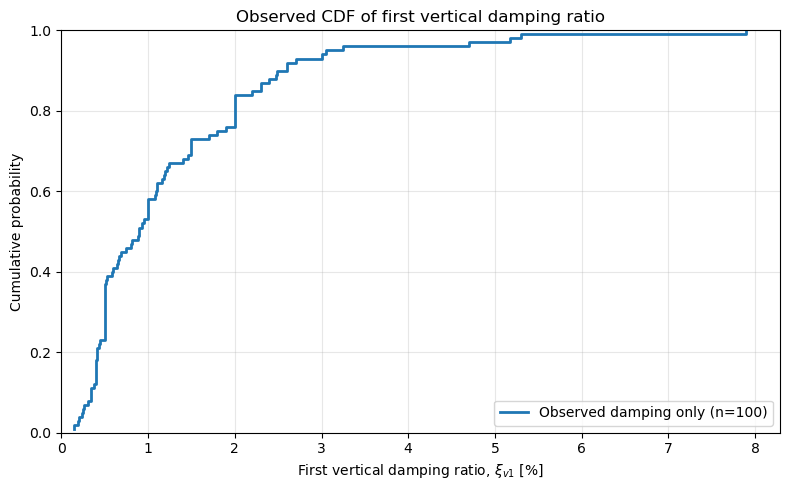

Sampling: [alpha, beta_log_L, beta_log_f, sigma, sigma_material]



Material categories used in model:
0: Steel | total = 152, observed damping = 51
1: FRP | total = 17, observed damping = 14
2: Steel -concrete composite | total = 24, observed damping = 16
3: Concrete | total = 43, observed damping = 12
4: Timber | total = 7, observed damping = 4
5: Unknown | total = 5, observed damping = 2
6: Aluminium | total = 2, observed damping = 1

Model data prepared.
Observed damping rows: 100
Missing damping rows: 150


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_log_f, beta_log_L, sigma_material, a_material_raw, sigma, log_zeta_missing]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 35 seconds.



Model parameter summary:
                  mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
alpha          -4.5040  0.1156 -4.7182  -4.2853     0.0017   0.0011   
beta_log_f      0.0735  0.1265 -0.1526   0.3220     0.0023   0.0015   
beta_log_L     -0.1195  0.1111 -0.3202   0.1002     0.0019   0.0012   
sigma_material  0.3529  0.1505  0.1055   0.6446     0.0029   0.0021   
sigma           0.7406  0.0557  0.6402   0.8478     0.0012   0.0007   

                 ess_bulk   ess_tail   r_hat  
alpha           4399.9994  4988.4523  1.0012  
beta_log_f      2987.1774  4268.8821  1.0007  
beta_log_L      3575.0608  5193.2079  1.0008  
sigma_material  2348.0032  3256.4546  1.0013  
sigma           2328.5794  3546.5067  1.0011  


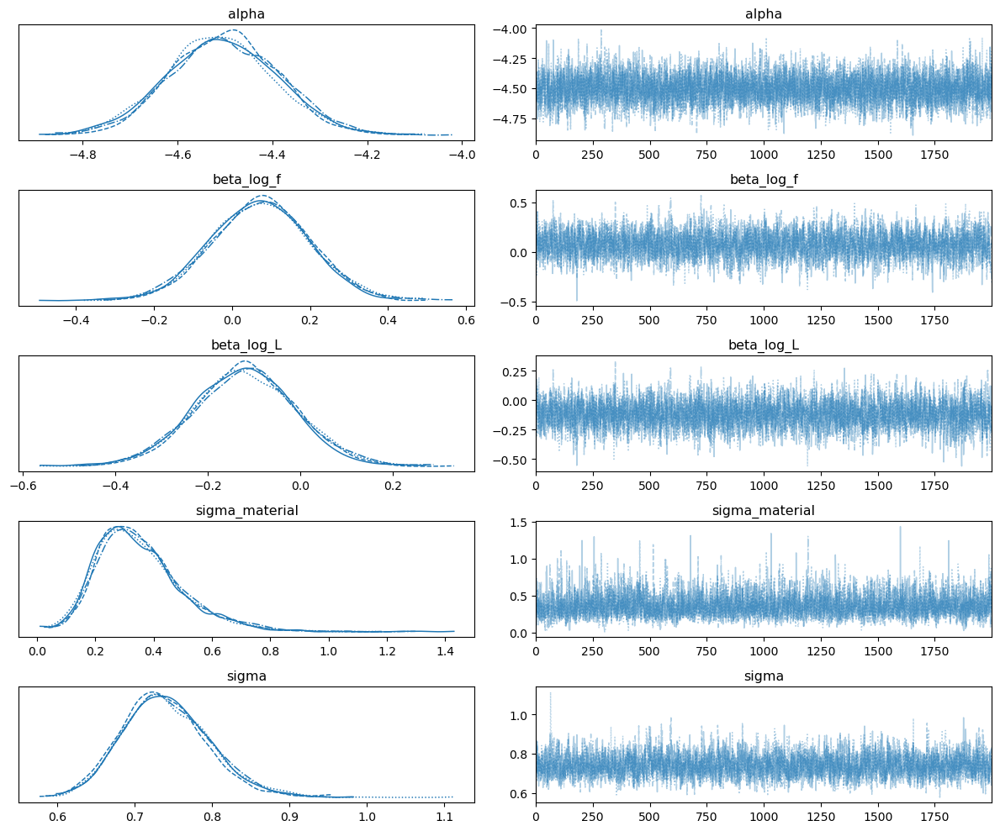

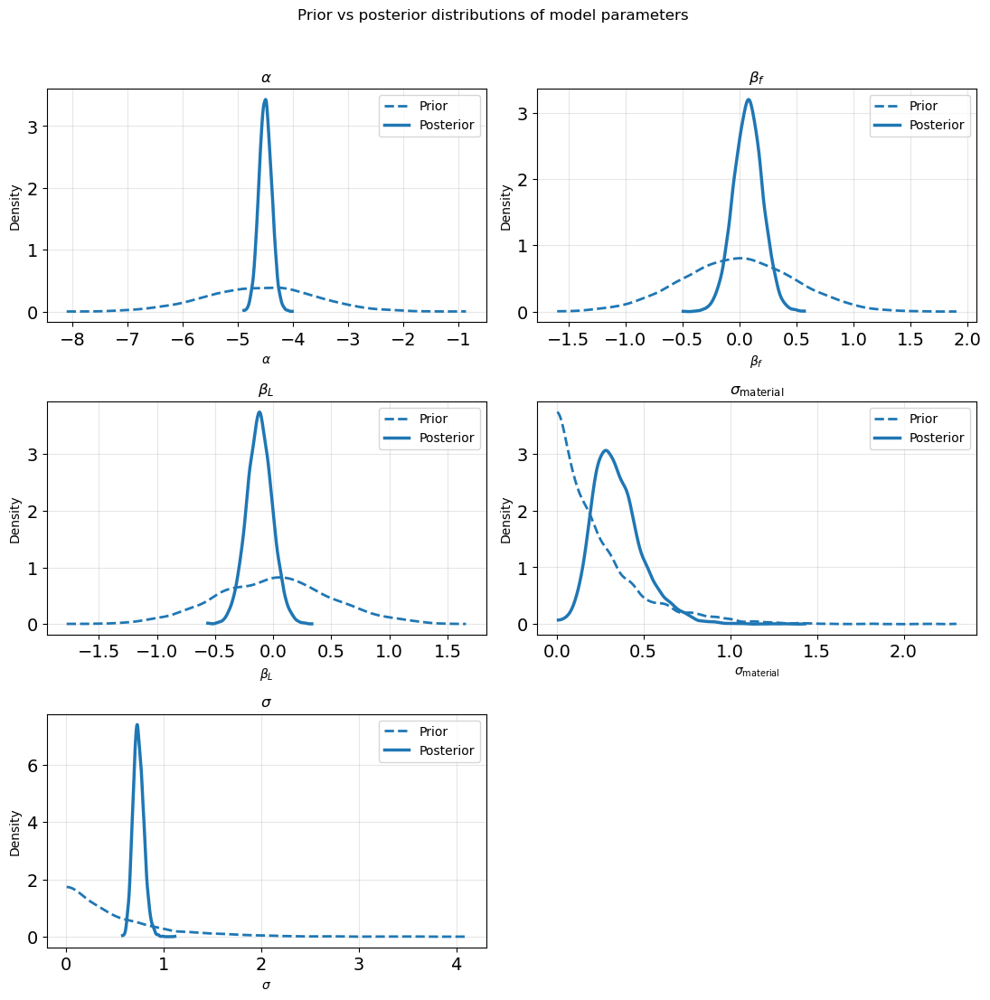


Material effect summary:
                    material  n_total  n_observed_damping  \
0                      Steel      152                  51   
1                        FRP       17                  14   
2  Steel -concrete composite       24                  16   
3                   Concrete       43                  12   
4                     Timber        7                   4   
5                    Unknown        5                   2   
6                  Aluminium        2                   1   

   a_material_median_log_scale  a_material_lower_95_log_scale  \
0                    -0.433061                      -0.741390   
1                     0.233448                      -0.112790   
2                    -0.083470                      -0.454489   
3                    -0.078724                      -0.452041   
4                     0.336726                      -0.090621   
5                     0.012147                      -0.497939   
6                     0.002813

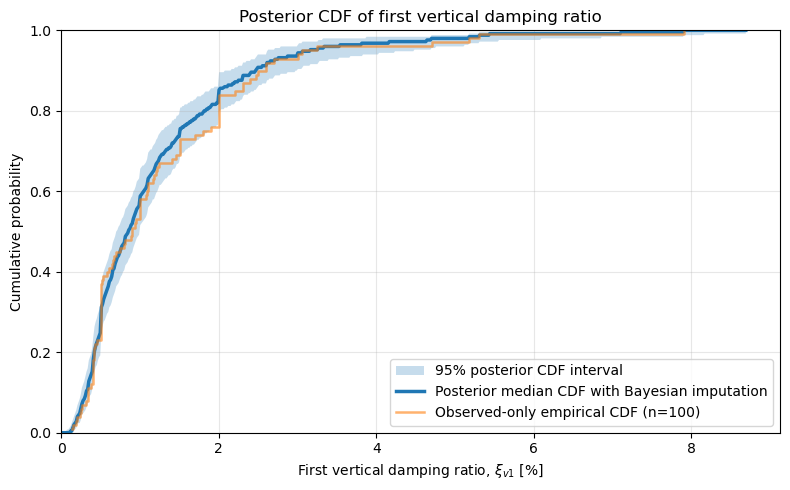

Sampling: [log_zeta_obs]


Output()

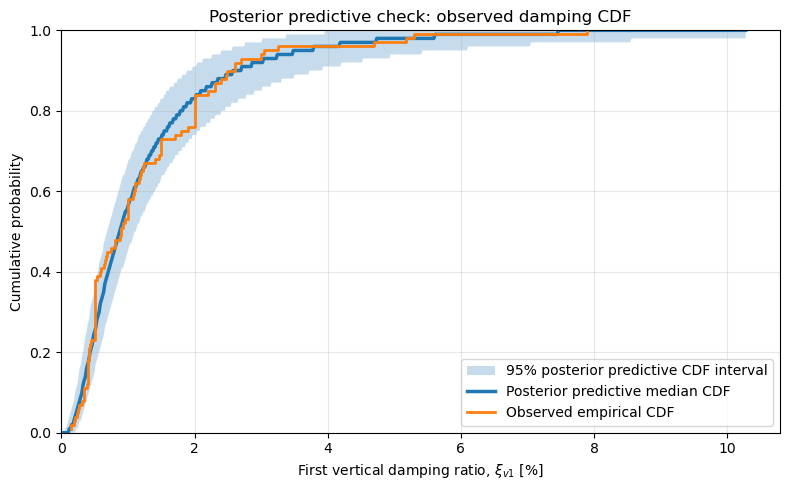


Saved: master_all_bridges_vertical_damping_frequency_span_material.csv


In [85]:
# ==================================================
# BAYESIAN IMPUTATION OF FIRST VERTICAL DAMPING RATIO
# MASTER CSV: GONG + WEI + OLIVEIRA IN ONE FILE
# MODEL: SPAN + FIRST VERTICAL FREQUENCY + MATERIAL
# ==================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import pytensor.tensor as pt

# ==================================================
# 1. FILE PATH
# ==================================================
data_csv = "data gong wei olivieri.csv"

# Choose material column
# Your CSV has girder_material and deck_material.
# Start with girder_material because it is more structural.
MATERIAL_COL = "girder_material"

# ==================================================
# 2. LOAD MASTER DATA
# ==================================================
master_df = pd.read_csv(data_csv, encoding="utf-8-sig")

print("Columns in master CSV:")
print(master_df.columns.tolist())

# ==================================================
# 3. HELPER FUNCTIONS
# ==================================================
def clean_numeric_column(series):
    """
    Converts values such as blanks, unknown, percentages,
    or text-containing numbers into clean numeric values.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("–", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def clean_damping_ratio(series):
    """
    Cleans damping ratio.

    Final expected unit:
        0.005 = 0.5%

    Handles:
        0.005       -> 0.005
        0.43        -> 0.0043, treated as 0.43%
        0.3-0.5     -> 0.004, treated as midpoint 0.4%
        #VALUE!     -> NaN
    """
    raw = series.astype(str)
    raw = raw.str.replace("−", "-", regex=False)
    raw = raw.str.replace("–", "-", regex=False)
    raw = raw.str.replace("%", "", regex=False)

    cleaned_values = []

    for item in raw:
        # For damping, negative values are not physical, so extract unsigned numbers
        nums = re.findall(r"\d*\.?\d+(?:[eE][-+]?\d+)?", item)

        if len(nums) == 0:
            cleaned_values.append(np.nan)

        elif len(nums) >= 2 and ("-" in item or "to" in item.lower()):
            vals = [float(nums[0]), float(nums[1])]
            cleaned_values.append(np.mean(vals))

        else:
            cleaned_values.append(float(nums[0]))

    z = pd.Series(cleaned_values, index=series.index, dtype=float)

    # Convert percent-like values to ratio
    # Example: 0.43 means 0.43%, so convert to 0.0043
    percent_like = z.notna() & (z > 0.20) & (z <= 20)

    if percent_like.any():
        print(f"\nConverting {percent_like.sum()} damping values from percent to ratio.")
        print("Example: 0.43 becomes 0.0043")
        z.loc[percent_like] = z.loc[percent_like] / 100.0

    # Remove impossible values
    impossible = z.notna() & ((z <= 0) | (z > 0.20))

    if impossible.any():
        print(f"\nSetting {impossible.sum()} impossible damping values to NaN.")
        z.loc[impossible] = np.nan

    return z


def clean_material_column(series):
    """
    Cleans material labels and replaces missing values with 'unknown'.
    """
    s = series.astype(str).str.strip()

    replacements = {
        "": "unknown",
        "nan": "unknown",
        "NaN": "unknown",
        "None": "unknown",
        "none": "unknown",
        "-": "unknown",
    }

    s = s.replace(replacements)
    s = s.fillna("unknown")

    # Optional: make labels more consistent
    s = s.str.replace("steel-concrete", "steel-concrete composite", case=False, regex=False)
    s = s.str.replace("steel concrete", "steel-concrete composite", case=False, regex=False)
    s = s.str.replace("FRP composite", "FRP", case=False, regex=False)
    s = s.str.replace("fibre-glass", "FRP", case=False, regex=False)
    s = s.str.replace("fiber-glass", "FRP", case=False, regex=False)
    s = s.str.replace("GFRP", "FRP", case=False, regex=False)

    return s


# ==================================================
# 4. CLEAN REQUIRED COLUMNS
# ==================================================

# Bridge ID
if "No" in master_df.columns:
    master_df["bridge_id"] = master_df["No"]
else:
    master_df["bridge_id"] = np.arange(1, len(master_df) + 1)

# Required predictors
master_df["span_m"] = clean_numeric_column(master_df["span_m"])

master_df["first_vertical_frequency_Hz"] = clean_numeric_column(
    master_df["vertical_natural_frequency_Hz"]
)

# Target variable
master_df["vertical_damping_ratio"] = clean_damping_ratio(
    master_df["vertical_damping_ratio"]
)

# Material predictor
if MATERIAL_COL not in master_df.columns:
    raise KeyError(f"Material column '{MATERIAL_COL}' not found in CSV.")

master_df["material_used"] = clean_material_column(master_df[MATERIAL_COL])

# ==================================================
# 5. KEEP ROWS WITH REQUIRED PREDICTORS
# ==================================================
# We need span, first vertical frequency, and material.
# Damping is allowed to be missing.
master_df = master_df.dropna(
    subset=["span_m", "first_vertical_frequency_Hz"]
).copy()

master_df = master_df[
    (master_df["span_m"] > 0)
    & (master_df["first_vertical_frequency_Hz"] > 0)
].copy()

master_df = master_df.reset_index(drop=True)

print("\nRows kept for Bayesian model:", len(master_df))

print("\nDamping availability:")
print(
    master_df["vertical_damping_ratio"]
    .notna()
    .value_counts()
    .rename(index={True: "available", False: "missing"})
)

print("\nMaterial counts:")
print(master_df["material_used"].value_counts())

print("\nObserved damping count by material:")
print(
    master_df.groupby("material_used")["vertical_damping_ratio"]
    .apply(lambda x: x.notna().sum())
    .sort_values(ascending=False)
)

print("\nFirst few rows used:")
print(master_df[[
    "bridge_id",
    "span_m",
    "first_vertical_frequency_Hz",
    "vertical_damping_ratio",
    "material_used"
]].head())

# ==================================================
# 6. OBSERVED-ONLY CDF
# ==================================================
observed_zeta = master_df.loc[
    master_df["vertical_damping_ratio"].notna(),
    "vertical_damping_ratio"
].to_numpy()

obs_sorted = np.sort(observed_zeta)
obs_cdf = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)

plt.figure(figsize=(8, 5))

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label=f"Observed damping only (n={len(observed_zeta)})"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Observed CDF of first vertical damping ratio")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# 7. PREPARE BAYESIAN MODEL VARIABLES
# ==================================================
obs_mask = master_df["vertical_damping_ratio"].notna().to_numpy()
miss_mask = ~obs_mask

obs_idx = np.where(obs_mask)[0]
miss_idx = np.where(miss_mask)[0]

# Observed damping on log scale
y_obs = np.log(master_df.loc[obs_idx, "vertical_damping_ratio"].to_numpy())

# Numerical predictors
log_f_raw = np.log(master_df["first_vertical_frequency_Hz"].to_numpy())
log_L_raw = np.log(master_df["span_m"].to_numpy())

# Store scaling values for interpretation later
log_f_mean = log_f_raw.mean()
log_f_std = log_f_raw.std()

log_L_mean = log_L_raw.mean()
log_L_std = log_L_raw.std()

# Standardised predictors
x_log_f = (log_f_raw - log_f_mean) / log_f_std
x_log_L = (log_L_raw - log_L_mean) / log_L_std

# Material coding
material_idx, material_names = pd.factorize(master_df["material_used"])
material_idx = material_idx.astype("int32")
n_materials = len(material_names)

print("\nMaterial categories used in model:")
for k, name in enumerate(material_names):
    total_k = np.sum(material_idx == k)
    obs_k = np.sum(obs_mask & (material_idx == k))
    print(f"{k}: {name} | total = {total_k}, observed damping = {obs_k}")

print("\nModel data prepared.")
print("Observed damping rows:", len(obs_idx))
print("Missing damping rows:", len(miss_idx))

# ==================================================
# 8. BAYESIAN IMPUTATION MODEL
# ==================================================
with pm.Model() as damping_model:

    # ------------------------------
    # Priors
    # ------------------------------

    # Baseline log damping
    alpha = pm.Normal(
        "alpha",
        mu=np.log(0.01),
        sigma=1.0
    )

    # Frequency effect
    beta_log_f = pm.Normal(
        "beta_log_f",
        mu=0.0,
        sigma=0.5
    )

    # Span effect
    beta_log_L = pm.Normal(
        "beta_log_L",
        mu=0.0,
        sigma=0.5
    )

    # Material variation
    # Partial pooling: material effects are pulled toward zero
    sigma_material = pm.Exponential(
        "sigma_material",
        lam=4.0
    )

    a_material_raw = pm.Normal(
        "a_material_raw",
        mu=0.0,
        sigma=1.0,
        shape=n_materials
    )

    # Sum-to-zero material effects for better identifiability with alpha
    a_material = pm.Deterministic(
        "a_material",
        sigma_material * (a_material_raw - pt.mean(a_material_raw))
    )

    # Scatter in log damping
    sigma = pm.Exponential(
        "sigma",
        lam=2.0
    )

    # ------------------------------
    # Linear predictor
    # ------------------------------
    mu_all = (
        alpha
        + beta_log_f * x_log_f
        + beta_log_L * x_log_L
        + a_material[material_idx]
    )

    # ------------------------------
    # Likelihood for observed damping
    # ------------------------------
    log_zeta_obs = pm.Normal(
        "log_zeta_obs",
        mu=mu_all[obs_idx],
        sigma=sigma,
        observed=y_obs
    )

    # ------------------------------
    # Missing damping values as latent variables
    # ------------------------------
    log_zeta_missing = pm.Normal(
        "log_zeta_missing",
        mu=mu_all[miss_idx],
        sigma=sigma,
        shape=len(miss_idx)
    )

    zeta_missing = pm.Deterministic(
        "zeta_missing",
        pm.math.exp(log_zeta_missing)
    )

    zeta_typical_all = pm.Deterministic(
        "zeta_typical_all",
        pm.math.exp(mu_all)
    )

    # ------------------------------
    # Prior predictive samples
    # ------------------------------
    param_names = [
        "alpha",
        "beta_log_f",
        "beta_log_L",
        "sigma_material",
        "sigma"
    ]

    prior = pm.sample_prior_predictive(
        samples=5000,
        var_names=param_names,
        random_seed=42
    )

    # ------------------------------
    # Posterior sampling
    # ------------------------------
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        init="jitter+adapt_diag",
        random_seed=42
    )

# ==================================================
# 9. DIAGNOSTICS
# ==================================================
summary = az.summary(
    trace,
    var_names=param_names,
    round_to=4
)

print("\nModel parameter summary:")
print(summary)

az.plot_trace(
    trace,
    var_names=param_names
)

plt.tight_layout()
plt.show()

# ==================================================
# 10. PRIOR VS POSTERIOR PARAMETER PLOTS
# ==================================================
label_map = {
    "alpha": r"$\alpha$",
    "beta_log_f": r"$\beta_f$",
    "beta_log_L": r"$\beta_L$",
    "sigma_material": r"$\sigma_{\mathrm{material}}$",
    "sigma": r"$\sigma$",
}

def flatten_prior(idata, var_name):
    return idata.prior[var_name].values.reshape(-1)

def flatten_posterior(idata, var_name):
    return idata.posterior[var_name].values.reshape(-1)

n_params = len(param_names)
n_cols = 2
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 3.6 * n_rows))
axes = np.asarray(axes).flatten()

for ax, var in zip(axes, param_names):

    prior_samples = flatten_prior(prior, var)
    posterior_samples = flatten_posterior(trace, var)

    az.plot_kde(
        prior_samples,
        ax=ax,
        label="Prior",
        plot_kwargs={"linewidth": 2, "linestyle": "--"}
    )

    az.plot_kde(
        posterior_samples,
        ax=ax,
        label="Posterior",
        plot_kwargs={"linewidth": 2.5}
    )

    ax.set_title(label_map[var])
    ax.set_xlabel(label_map[var])
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[n_params:]:
    fig.delaxes(ax)

plt.suptitle("Prior vs posterior distributions of model parameters", y=1.02)
plt.tight_layout()
plt.show()

# ==================================================
# 11. MATERIAL EFFECT SUMMARY
# ==================================================
a_material_samples = (
    trace.posterior["a_material"]
    .stack(sample=("chain", "draw"))
    .transpose("a_material_dim_0", "sample")
    .values
)

material_summary = pd.DataFrame({
    "material": list(material_names),
    "n_total": [np.sum(material_idx == k) for k in range(n_materials)],
    "n_observed_damping": [
        np.sum(obs_mask & (material_idx == k)) for k in range(n_materials)
    ],
    "a_material_median_log_scale": np.percentile(a_material_samples, 50, axis=1),
    "a_material_lower_95_log_scale": np.percentile(a_material_samples, 2.5, axis=1),
    "a_material_upper_95_log_scale": np.percentile(a_material_samples, 97.5, axis=1),
})

# Convert log-scale material effect to damping multiplier
material_summary["damping_multiplier_median"] = np.exp(
    material_summary["a_material_median_log_scale"]
)
material_summary["damping_multiplier_lower_95"] = np.exp(
    material_summary["a_material_lower_95_log_scale"]
)
material_summary["damping_multiplier_upper_95"] = np.exp(
    material_summary["a_material_upper_95_log_scale"]
)

print("\nMaterial effect summary:")
print(material_summary)

material_summary.to_csv(
    "material_effect_summary_vertical_damping.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved: material_effect_summary_vertical_damping.csv")

# ==================================================
# 12. EXTRACT IMPUTED DAMPING VALUES
# ==================================================
if len(miss_idx) > 0:

    missing_samples = (
        trace.posterior["zeta_missing"]
        .stack(sample=("chain", "draw"))
        .transpose("zeta_missing_dim_0", "sample")
        .values
    )

    imputed_summary = master_df.loc[miss_idx, [
        "bridge_id",
        "span_m",
        "first_vertical_frequency_Hz",
        "material_used"
    ]].copy()

    imputed_summary["zeta_imputed_median"] = np.percentile(
        missing_samples, 50, axis=1
    )
    imputed_summary["zeta_imputed_lower_95"] = np.percentile(
        missing_samples, 2.5, axis=1
    )
    imputed_summary["zeta_imputed_upper_95"] = np.percentile(
        missing_samples, 97.5, axis=1
    )

    imputed_summary["zeta_imputed_median_percent"] = (
        imputed_summary["zeta_imputed_median"] * 100
    )
    imputed_summary["zeta_imputed_lower_95_percent"] = (
        imputed_summary["zeta_imputed_lower_95"] * 100
    )
    imputed_summary["zeta_imputed_upper_95_percent"] = (
        imputed_summary["zeta_imputed_upper_95"] * 100
    )

    print("\nFirst few imputed damping summaries:")
    print(imputed_summary.head())

    imputed_summary.to_csv(
        "bayesian_imputed_missing_vertical_damping_frequency_span_material.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\nSaved: bayesian_imputed_missing_vertical_damping_frequency_span_material.csv")

else:
    missing_samples = np.empty((0, 0))
    print("\nNo missing damping values to impute.")

# ==================================================
# 13. POSTERIOR CDF INCLUDING IMPUTED VALUES
# ==================================================
if len(miss_idx) > 0:

    n_draws = missing_samples.shape[1]

    all_values_for_grid = np.concatenate([
        observed_zeta,
        missing_samples.ravel()
    ])

    x_max = np.percentile(all_values_for_grid, 99.5) * 1.20
    x_max = max(x_max, observed_zeta.max() * 1.10)

    x_grid = np.linspace(0, x_max, 600)

    cdf_samples = np.zeros((n_draws, len(x_grid)))

    for j in range(n_draws):

        full_zeta_j = np.concatenate([
            observed_zeta,
            missing_samples[:, j]
        ])

        cdf_samples[j, :] = np.mean(
            full_zeta_j[:, None] <= x_grid[None, :],
            axis=0
        )

    cdf_median = np.percentile(cdf_samples, 50, axis=0)
    cdf_lower = np.percentile(cdf_samples, 2.5, axis=0)
    cdf_upper = np.percentile(cdf_samples, 97.5, axis=0)

    plt.figure(figsize=(8, 5))

    plt.fill_between(
        x_grid * 100,
        cdf_lower,
        cdf_upper,
        alpha=0.25,
        label="95% posterior CDF interval"
    )

    plt.plot(
        x_grid * 100,
        cdf_median,
        linewidth=2.5,
        label="Posterior median CDF with Bayesian imputation"
    )

    plt.step(
        obs_sorted * 100,
        obs_cdf,
        where="post",
        linewidth=1.8,
        alpha=0.6,
        label=f"Observed-only empirical CDF (n={len(observed_zeta)})"
    )

    plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
    plt.ylabel("Cumulative probability")
    plt.title("Posterior CDF of first vertical damping ratio")
    plt.xlim(left=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==================================================
# 14. POSTERIOR PREDICTIVE CHECK
# ==================================================
with damping_model:
    ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["log_zeta_obs"],
        random_seed=42
    )

ppc_log = (
    ppc.posterior_predictive["log_zeta_obs"]
    .stack(sample=("chain", "draw"))
    .transpose("log_zeta_obs_dim_0", "sample")
    .values
)

ppc_zeta = np.exp(ppc_log)

n_ppc_draws = ppc_zeta.shape[1]

x_grid_ppc = np.linspace(
    0,
    np.percentile(np.concatenate([observed_zeta, ppc_zeta.ravel()]), 99.5) * 1.2,
    600
)

ppc_cdf_samples = np.zeros((n_ppc_draws, len(x_grid_ppc)))

for j in range(n_ppc_draws):
    ppc_cdf_samples[j, :] = np.mean(
        ppc_zeta[:, j][:, None] <= x_grid_ppc[None, :],
        axis=0
    )

ppc_cdf_median = np.percentile(ppc_cdf_samples, 50, axis=0)
ppc_cdf_lower = np.percentile(ppc_cdf_samples, 2.5, axis=0)
ppc_cdf_upper = np.percentile(ppc_cdf_samples, 97.5, axis=0)

plt.figure(figsize=(8, 5))

plt.fill_between(
    x_grid_ppc * 100,
    ppc_cdf_lower,
    ppc_cdf_upper,
    alpha=0.25,
    label="95% posterior predictive CDF interval"
)

plt.plot(
    x_grid_ppc * 100,
    ppc_cdf_median,
    linewidth=2.5,
    label="Posterior predictive median CDF"
)

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label="Observed empirical CDF"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Posterior predictive check: observed damping CDF")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# 15. SAVE MASTER DATA WITH OBSERVED/IMPUTED STATUS
# ==================================================
master_out = master_df.copy()
master_out["damping_observed"] = master_out["vertical_damping_ratio"].notna()

if len(miss_idx) > 0:
    master_out.loc[miss_idx, "zeta_imputed_median"] = (
        imputed_summary["zeta_imputed_median"].values
    )
    master_out.loc[miss_idx, "zeta_imputed_lower_95"] = (
        imputed_summary["zeta_imputed_lower_95"].values
    )
    master_out.loc[miss_idx, "zeta_imputed_upper_95"] = (
        imputed_summary["zeta_imputed_upper_95"].values
    )

master_out.to_csv(
    "master_all_bridges_vertical_damping_frequency_span_material.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved: master_all_bridges_vertical_damping_frequency_span_material.csv")

Columns in CSV:
['No', 'span_m', 'width_m', 'vertical_natural_frequency_Hz', 'vertical_damping_ratio', 'cross_section', 'bridge_type', 'girder_material', 'deck_material', 'lateral_natural_frequency_Hz', 'lateral_damping_ratio']

Total usable first vertical frequency values = 250

Empirical bridges with f_v < 5 Hz = 216/250
Empirical percentage below 5 Hz = 86.40%
KDE-smoothed CDF percentage below 5 Hz = 85.15%


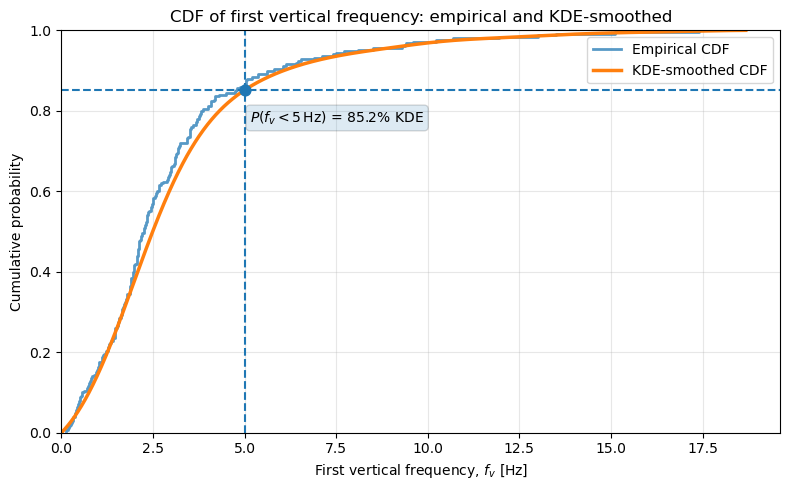

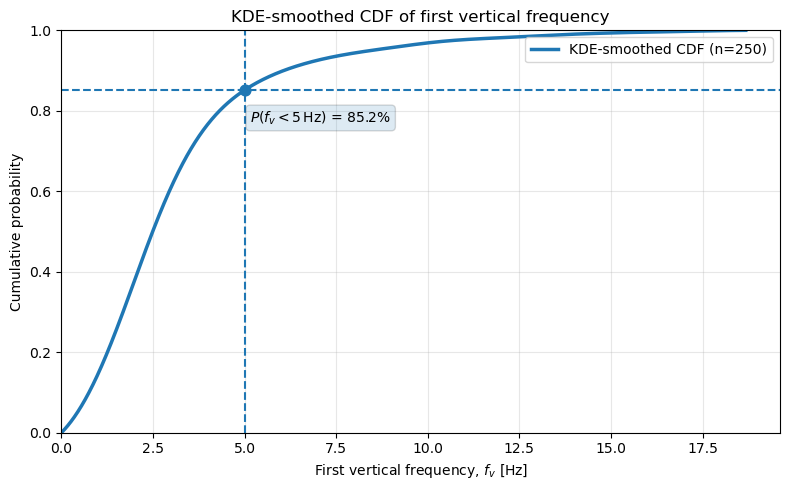

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import cumulative_trapezoid

# ==================================================
# FILE PATH
# ==================================================
data_csv = "data gong wei olivieri.csv"

# ==================================================
# LOAD COMBINED CSV
# ==================================================
df = pd.read_csv(data_csv, encoding="utf-8-sig")

print("Columns in CSV:")
print(df.columns.tolist())

# ==================================================
# CLEAN NUMERIC VALUES
# ==================================================
def clean_numeric_column(series):
    """
    Converts values such as 'unknown', blanks, N/A,
    or text-containing numbers into clean numeric values.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")

# ==================================================
# EXTRACT FIRST VERTICAL FREQUENCIES
# ==================================================
freq = clean_numeric_column(df["vertical_natural_frequency_Hz"])

freq = freq.dropna()
freq = freq[freq > 0].to_numpy()

print(f"\nTotal usable first vertical frequency values = {len(freq)}")

# ==================================================
# EMPIRICAL CDF
# ==================================================
freq_sorted = np.sort(freq)
empirical_cdf = np.arange(1, len(freq_sorted) + 1) / len(freq_sorted)

# ==================================================
# KDE-SMOOTHED CDF
# ==================================================
x_min = 0.0
x_max = freq.max() + 0.5 * freq.std()
x_grid = np.linspace(x_min, x_max, 1500)

kde = gaussian_kde(freq)
pdf = kde(x_grid)

cdf_kde = cumulative_trapezoid(pdf, x_grid, initial=0)
cdf_kde = cdf_kde / cdf_kde[-1]   # normalise to end at 1

# ==================================================
# FIND PERCENTAGE BELOW 5 Hz
# ==================================================
threshold = 5.0

# KDE-smoothed percentage
cdf_at_5_kde = np.interp(threshold, x_grid, cdf_kde)
percent_below_5_kde = cdf_at_5_kde * 100

# Empirical percentage
percent_below_5_empirical = np.mean(freq < threshold) * 100
n_below_5 = np.sum(freq < threshold)

print(f"\nEmpirical bridges with f_v < 5 Hz = {n_below_5}/{len(freq)}")
print(f"Empirical percentage below 5 Hz = {percent_below_5_empirical:.2f}%")
print(f"KDE-smoothed CDF percentage below 5 Hz = {percent_below_5_kde:.2f}%")

# ==================================================
# GRAPH 1: EMPIRICAL CDF + KDE-SMOOTHED CDF
# ==================================================
plt.figure(figsize=(8, 5))

plt.step(
    freq_sorted,
    empirical_cdf,
    where="post",
    linewidth=2,
    alpha=0.75,
    label=f"Empirical CDF"
)

plt.plot(
    x_grid,
    cdf_kde,
    linewidth=2.5,
    label="KDE-smoothed CDF"
)

# Mark 5 Hz
plt.axvline(threshold, linestyle="--", linewidth=1.5)
plt.axhline(cdf_at_5_kde, linestyle="--", linewidth=1.5)
plt.scatter([threshold], [cdf_at_5_kde], s=60, zorder=5)

plt.text(
    threshold + 0.15,
    cdf_at_5_kde - 0.08,
    rf"$P(f_v < 5\,\mathrm{{Hz}})$ = {percent_below_5_kde:.1f}% KDE",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.xlabel(r"First vertical frequency, $f_v$ [Hz]")
plt.ylabel("Cumulative probability")
plt.title("CDF of first vertical frequency: empirical and KDE-smoothed")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# GRAPH 2: KDE-SMOOTHED CDF ONLY
# ==================================================
plt.figure(figsize=(8, 5))

plt.plot(
    x_grid,
    cdf_kde,
    linewidth=2.5,
    label=f"KDE-smoothed CDF (n={len(freq)})"
)

# Mark 5 Hz
plt.axvline(threshold, linestyle="--", linewidth=1.5)
plt.axhline(cdf_at_5_kde, linestyle="--", linewidth=1.5)
plt.scatter([threshold], [cdf_at_5_kde], s=60, zorder=5)

plt.text(
    threshold + 0.15,
    cdf_at_5_kde - 0.08,
    rf"$P(f_v < 5\,\mathrm{{Hz}})$ = {percent_below_5_kde:.1f}%",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.xlabel(r"First vertical frequency, $f_v$ [Hz]")
plt.ylabel("Cumulative probability")
plt.title("KDE-smoothed CDF of first vertical frequency")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
# ==================================================
# POPULATION SHARES IN FREQUENCY BANDS
# Conditional on f_v < 5 Hz
# ==================================================

frequency_bands = [
    (1.7, 2.25),
    (2.25, 2.75),
    (2.75, 3.25),
    (3.25, 3.75),
]

# Ensure the KDE grid extends beyond 5 Hz
if x_grid[-1] < threshold:
    raise ValueError(
        "The KDE grid does not extend to 5 Hz. "
        "Increase x_max to at least 5.0 Hz."
    )

def kde_cdf_at(x):
    """Interpolate the KDE-smoothed CDF."""
    return np.interp(
        x,
        x_grid,
        cdf_kde,
        left=0.0,
        right=1.0
    )

n_below_5 = np.sum(freq < threshold)
F5_kde = kde_cdf_at(threshold)

band_results = []

for lower, upper in frequency_bands:

    # ----------------------------------------------
    # Empirical estimates
    # ----------------------------------------------
    n_in_band = np.sum(
        (freq >= lower) &
        (freq < upper)
    )

    empirical_unconditional = n_in_band / len(freq)
    empirical_conditional = (
        n_in_band / n_below_5
        if n_below_5 > 0 else np.nan
    )

    # ----------------------------------------------
    # KDE-smoothed estimates
    # ----------------------------------------------
    kde_band_probability = (
        kde_cdf_at(upper) -
        kde_cdf_at(lower)
    )

    kde_conditional = (
        kde_band_probability / F5_kde
        if F5_kde > 0 else np.nan
    )

    band_results.append({
        "Frequency band [Hz]": f"{lower:.2f}–{upper:.2f}",
        "Number of bridges": n_in_band,
        "% of complete dataset, empirical":
            100 * empirical_unconditional,
        "% among bridges below 5 Hz, empirical":
            100 * empirical_conditional,
        "% among bridges below 5 Hz, KDE":
            100 * kde_conditional,
    })

band_results_df = pd.DataFrame(band_results)

print("\nPopulation shares in selected frequency bands:")
print(
    band_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)

# Percentage below 5 Hz not contained in either selected band
selected_empirical_count = sum(
    np.sum((freq >= lower) & (freq < upper))
    for lower, upper in frequency_bands
)

remaining_empirical_percent = (
    100 * (n_below_5 - selected_empirical_count) / n_below_5
)

selected_kde_probability = sum(
    kde_cdf_at(upper) - kde_cdf_at(lower)
    for lower, upper in frequency_bands
)

remaining_kde_percent = (
    100 * (F5_kde - selected_kde_probability) / F5_kde
)

print(
    "\nAmong bridges with f_v < 5 Hz, percentage outside "
    "the two selected bands:"
)
print(
    f"Empirical = {remaining_empirical_percent:.2f}%"
)
print(
    f"KDE-smoothed = {remaining_kde_percent:.2f}%"
)


Population shares in selected frequency bands:
Frequency band [Hz]  Number of bridges  % of complete dataset, empirical  % among bridges below 5 Hz, empirical  % among bridges below 5 Hz, KDE
          1.70–2.25                 46                             18.40                                  21.30                            16.11
          2.25–2.75                 31                             12.40                                  14.35                            13.77
          2.75–3.25                 24                              9.60                                  11.11                            11.67
          3.25–3.75                 16                              6.40                                   7.41                             9.14

Among bridges with f_v < 5 Hz, percentage outside the two selected bands:
Empirical = 45.83%
KDE-smoothed = 49.30%


Columns in master CSV:
['No', 'span_m', 'width_m', 'vertical_natural_frequency_Hz', 'vertical_damping_ratio', 'cross_section', 'bridge_type', 'girder_material', 'deck_material', 'lateral_natural_frequency_Hz', 'lateral_damping_ratio']

Rows kept for Bayesian model: 250

Damping availability:
vertical_damping_ratio
missing      150
available    100
Name: count, dtype: int64

Material counts:
material_used
Steel                        152
Concrete                      43
Steel -concrete composite     24
FRP                           17
Timber                         7
Unknown                        5
Aluminium                      2
Name: count, dtype: int64

Observed damping count by material:
material_used
Steel                        51
Steel -concrete composite    16
FRP                          14
Concrete                     12
Timber                        4
Unknown                       2
Aluminium                     1
Name: vertical_damping_ratio, dtype: int64

First few rows u

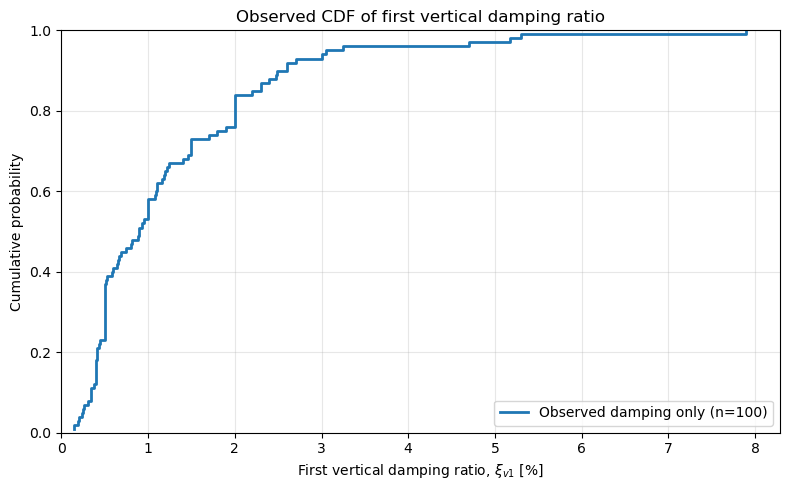

Sampling: [a_material_raw, alpha, beta_log_L, beta_log_f, sigma, sigma_material]



Material categories used in model:
0: Steel | total = 152, observed damping = 51
1: FRP | total = 17, observed damping = 14
2: Steel -concrete composite | total = 24, observed damping = 16
3: Concrete | total = 43, observed damping = 12
4: Timber | total = 7, observed damping = 4
5: Unknown | total = 5, observed damping = 2
6: Aluminium | total = 2, observed damping = 1

Model data prepared.
Observed damping rows: 100
Missing damping rows: 150


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_log_f, beta_log_L, sigma_material, a_material_raw, sigma, log_zeta_missing]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 62 seconds.



Creating Graphviz model diagram...


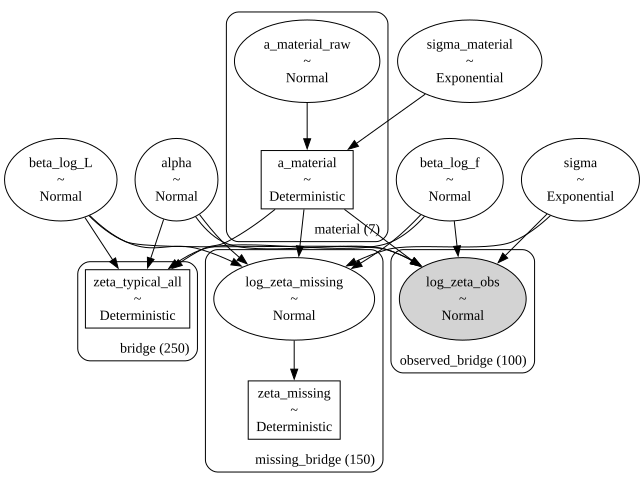


Saved: bayesian_damping_model_graphviz.png

Full model parameter summary:
                                         mean      sd  hdi_3%  hdi_97%  \
alpha                                 -4.5030  0.1146 -4.7117  -4.2774   
beta_log_f                             0.0777  0.1265 -0.1595   0.3142   
beta_log_L                            -0.1157  0.1123 -0.3271   0.0966   
sigma_material                         0.3556  0.1545  0.0959   0.6382   
sigma                                  0.7406  0.0550  0.6385   0.8430   
a_material[Steel]                     -0.4349  0.1554 -0.7252  -0.1429   
a_material[FRP]                        0.2378  0.1858 -0.1061   0.5878   
a_material[Steel -concrete composite] -0.0921  0.1731 -0.4253   0.2315   
a_material[Concrete]                  -0.0896  0.1785 -0.4397   0.2270   
a_material[Timber]                     0.3609  0.2629 -0.1109   0.8512   
a_material[Unknown]                    0.0212  0.2580 -0.4588   0.5218   
a_material[Aluminium]                

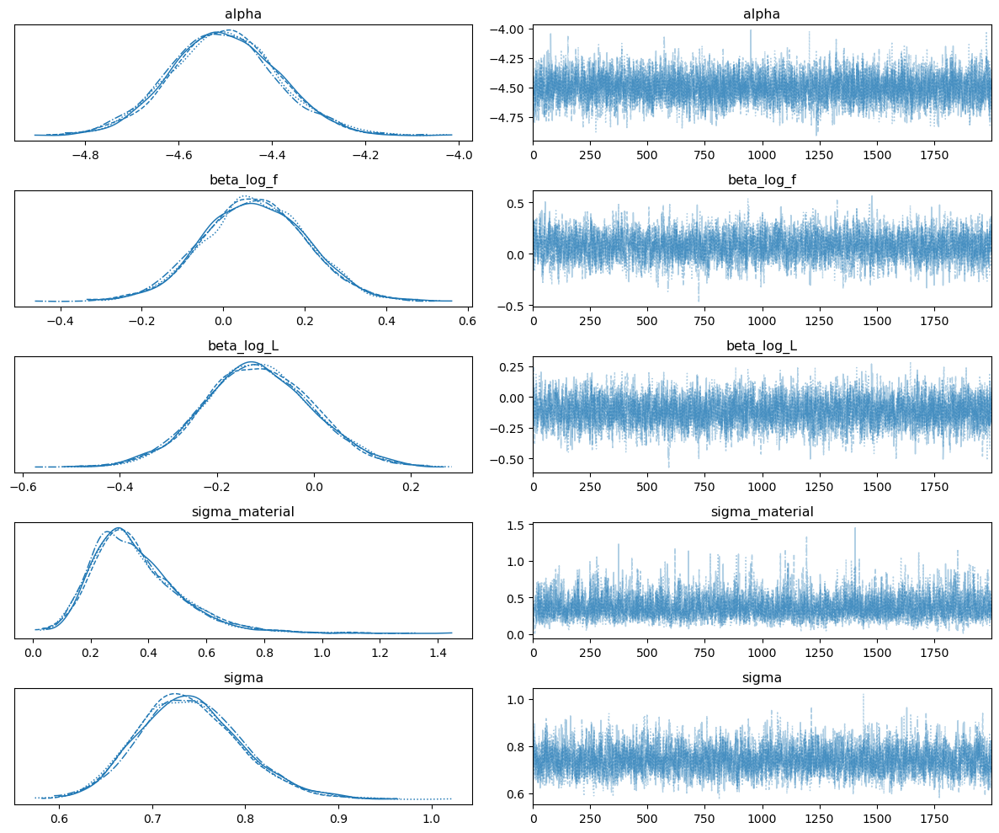

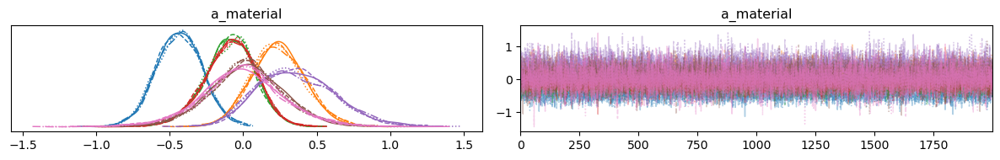

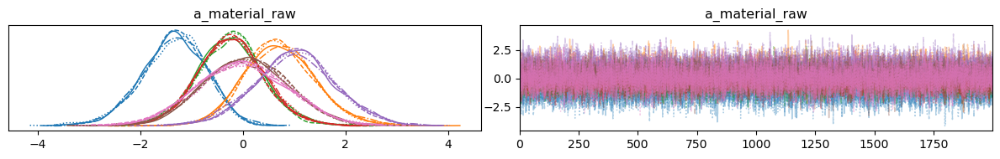

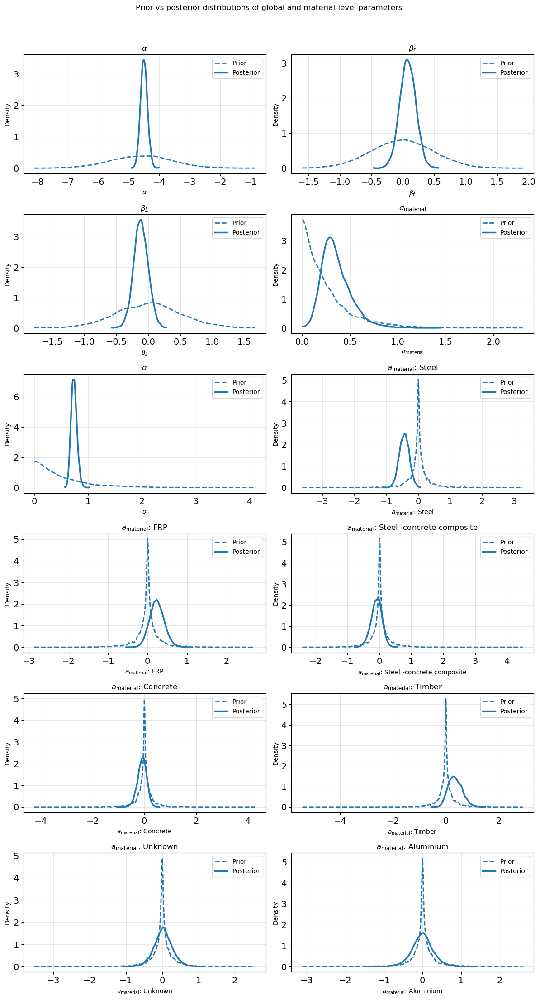


Material effect summary:
                    material  n_total  n_observed_damping  \
0                      Steel      152                  51   
1                        FRP       17                  14   
2  Steel -concrete composite       24                  16   
3                   Concrete       43                  12   
4                     Timber        7                   4   
5                    Unknown        5                   2   
6                  Aluminium        2                   1   

   a_material_median_log_scale  a_material_lower_95_log_scale  \
0                    -0.433957                      -0.739529   
1                     0.232777                      -0.107807   
2                    -0.084345                      -0.456481   
3                    -0.080833                      -0.465363   
4                     0.340663                      -0.095666   
5                     0.020948                      -0.488762   
6                    -0.001494

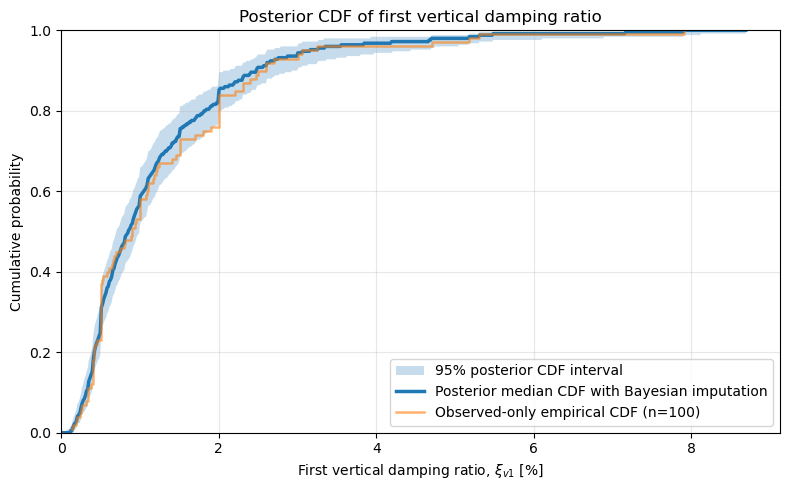

Sampling: [log_zeta_obs]


Output()

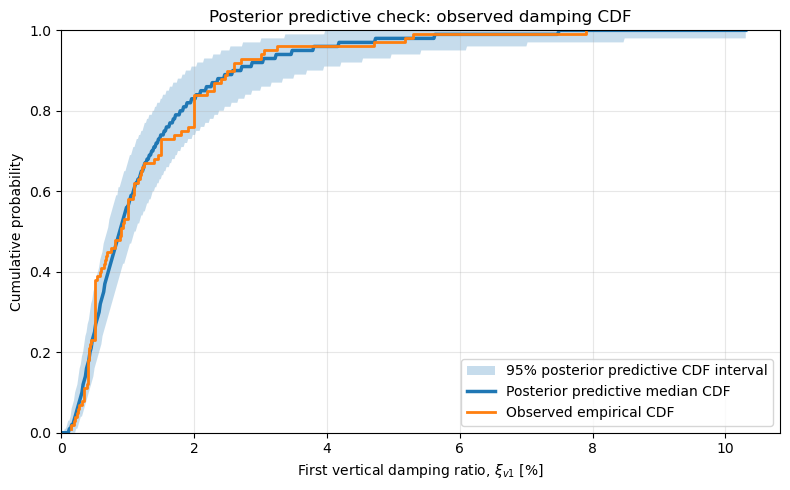


Saved: master_all_bridges_vertical_damping_frequency_span_material.csv


In [130]:
# ==================================================
# BAYESIAN IMPUTATION OF FIRST VERTICAL DAMPING RATIO
# MASTER CSV: GONG + WEI + OLIVEIRA IN ONE FILE
# MODEL: SPAN + FIRST VERTICAL FREQUENCY + MATERIAL
# WITH GRAPHVIZ + FULL TRACEPLOTS + FULL PRIOR VS POSTERIOR
# ==================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import pytensor.tensor as pt

# For Graphviz display in Jupyter
try:
    from IPython.display import display
except ImportError:
    display = None


# ==================================================
# 1. FILE PATH
# ==================================================
data_csv = "data gong wei olivieri.csv"

# Choose material column
# Your CSV has girder_material and deck_material.
# Start with girder_material because it is more structural.
MATERIAL_COL = "girder_material"


# ==================================================
# 2. LOAD MASTER DATA
# ==================================================
master_df = pd.read_csv(data_csv, encoding="utf-8-sig")

print("Columns in master CSV:")
print(master_df.columns.tolist())


# ==================================================
# 3. HELPER FUNCTIONS
# ==================================================
def clean_numeric_column(series):
    """
    Converts values such as blanks, unknown, percentages,
    or text-containing numbers into clean numeric values.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("–", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def clean_damping_ratio(series):
    """
    Cleans damping ratio.

    Final expected unit:
        0.005 = 0.5%

    Handles:
        0.005       -> 0.005
        0.43        -> 0.0043, treated as 0.43%
        0.3-0.5     -> 0.004, treated as midpoint 0.4%
        #VALUE!     -> NaN
    """
    raw = series.astype(str)
    raw = raw.str.replace("−", "-", regex=False)
    raw = raw.str.replace("–", "-", regex=False)
    raw = raw.str.replace("%", "", regex=False)

    cleaned_values = []

    for item in raw:
        # For damping, negative values are not physical, so extract unsigned numbers
        nums = re.findall(r"\d*\.?\d+(?:[eE][-+]?\d+)?", item)

        if len(nums) == 0:
            cleaned_values.append(np.nan)

        elif len(nums) >= 2 and ("-" in item or "to" in item.lower()):
            vals = [float(nums[0]), float(nums[1])]
            cleaned_values.append(np.mean(vals))

        else:
            cleaned_values.append(float(nums[0]))

    z = pd.Series(cleaned_values, index=series.index, dtype=float)

    # Convert percent-like values to ratio.
    # Example: 0.43 means 0.43%, so convert to 0.0043.
    percent_like = z.notna() & (z > 0.20) & (z <= 20)

    if percent_like.any():
        print(f"\nConverting {percent_like.sum()} damping values from percent to ratio.")
        print("Example: 0.43 becomes 0.0043")
        z.loc[percent_like] = z.loc[percent_like] / 100.0

    # Remove impossible values
    impossible = z.notna() & ((z <= 0) | (z > 0.20))

    if impossible.any():
        print(f"\nSetting {impossible.sum()} impossible damping values to NaN.")
        z.loc[impossible] = np.nan

    return z


def clean_material_column(series):
    """
    Cleans material labels and replaces missing values with 'unknown'.
    """
    s = series.astype(str).str.strip()

    replacements = {
        "": "unknown",
        "nan": "unknown",
        "NaN": "unknown",
        "None": "unknown",
        "none": "unknown",
        "-": "unknown",
    }

    s = s.replace(replacements)
    s = s.fillna("unknown")

    # Optional: make labels more consistent
    s = s.str.replace("steel-concrete", "steel-concrete composite", case=False, regex=False)
    s = s.str.replace("steel concrete", "steel-concrete composite", case=False, regex=False)
    s = s.str.replace("FRP composite", "FRP", case=False, regex=False)
    s = s.str.replace("fibre-glass", "FRP", case=False, regex=False)
    s = s.str.replace("fiber-glass", "FRP", case=False, regex=False)
    s = s.str.replace("GFRP", "FRP", case=False, regex=False)

    return s


# ==================================================
# 4. CLEAN REQUIRED COLUMNS
# ==================================================

# Bridge ID
if "No" in master_df.columns:
    master_df["bridge_id"] = master_df["No"]
else:
    master_df["bridge_id"] = np.arange(1, len(master_df) + 1)

# Required predictors
master_df["span_m"] = clean_numeric_column(master_df["span_m"])

master_df["first_vertical_frequency_Hz"] = clean_numeric_column(
    master_df["vertical_natural_frequency_Hz"]
)

# Target variable
master_df["vertical_damping_ratio"] = clean_damping_ratio(
    master_df["vertical_damping_ratio"]
)

# Material predictor
if MATERIAL_COL not in master_df.columns:
    raise KeyError(f"Material column '{MATERIAL_COL}' not found in CSV.")

master_df["material_used"] = clean_material_column(master_df[MATERIAL_COL])


# ==================================================
# 5. KEEP ROWS WITH REQUIRED PREDICTORS
# ==================================================
# We need span, first vertical frequency, and material.
# Damping is allowed to be missing.
master_df = master_df.dropna(
    subset=["span_m", "first_vertical_frequency_Hz"]
).copy()

master_df = master_df[
    (master_df["span_m"] > 0)
    & (master_df["first_vertical_frequency_Hz"] > 0)
].copy()

master_df = master_df.reset_index(drop=True)

print("\nRows kept for Bayesian model:", len(master_df))

print("\nDamping availability:")
print(
    master_df["vertical_damping_ratio"]
    .notna()
    .value_counts()
    .rename(index={True: "available", False: "missing"})
)

print("\nMaterial counts:")
print(master_df["material_used"].value_counts())

print("\nObserved damping count by material:")
print(
    master_df.groupby("material_used")["vertical_damping_ratio"]
    .apply(lambda x: x.notna().sum())
    .sort_values(ascending=False)
)

print("\nFirst few rows used:")
print(master_df[[
    "bridge_id",
    "span_m",
    "first_vertical_frequency_Hz",
    "vertical_damping_ratio",
    "material_used"
]].head())


# ==================================================
# 6. OBSERVED-ONLY CDF
# ==================================================
observed_zeta = master_df.loc[
    master_df["vertical_damping_ratio"].notna(),
    "vertical_damping_ratio"
].to_numpy()

obs_sorted = np.sort(observed_zeta)
obs_cdf = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)

plt.figure(figsize=(8, 5))

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label=f"Observed damping only (n={len(observed_zeta)})"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Observed CDF of first vertical damping ratio")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# 7. PREPARE BAYESIAN MODEL VARIABLES
# ==================================================
obs_mask = master_df["vertical_damping_ratio"].notna().to_numpy()
miss_mask = ~obs_mask

obs_idx = np.where(obs_mask)[0]
miss_idx = np.where(miss_mask)[0]

# Observed damping on log scale
y_obs = np.log(master_df.loc[obs_idx, "vertical_damping_ratio"].to_numpy())

# Numerical predictors
log_f_raw = np.log(master_df["first_vertical_frequency_Hz"].to_numpy())
log_L_raw = np.log(master_df["span_m"].to_numpy())

# Store scaling values for interpretation later
log_f_mean = log_f_raw.mean()
log_f_std = log_f_raw.std()

log_L_mean = log_L_raw.mean()
log_L_std = log_L_raw.std()

# Standardised predictors
x_log_f = (log_f_raw - log_f_mean) / log_f_std
x_log_L = (log_L_raw - log_L_mean) / log_L_std

# Material coding
material_idx, material_names = pd.factorize(master_df["material_used"])
material_idx = material_idx.astype("int32")
material_names_clean = [str(m) for m in material_names]
n_materials = len(material_names_clean)

print("\nMaterial categories used in model:")
for k, name in enumerate(material_names_clean):
    total_k = np.sum(material_idx == k)
    obs_k = np.sum(obs_mask & (material_idx == k))
    print(f"{k}: {name} | total = {total_k}, observed damping = {obs_k}")

print("\nModel data prepared.")
print("Observed damping rows:", len(obs_idx))
print("Missing damping rows:", len(miss_idx))


# ==================================================
# 8. BAYESIAN IMPUTATION MODEL
# ==================================================

coords = {
    "bridge": np.arange(len(master_df)),
    "observed_bridge": np.arange(len(obs_idx)),
    "missing_bridge": np.arange(len(miss_idx)),
    "material": material_names_clean,
}

with pm.Model(coords=coords) as damping_model:

    # ------------------------------
    # Priors: global parameters
    # ------------------------------

    # Baseline log damping
    alpha = pm.Normal(
        "alpha",
        mu=np.log(0.01),
        sigma=1.0
    )

    # Frequency effect: global slope
    beta_log_f = pm.Normal(
        "beta_log_f",
        mu=0.0,
        sigma=0.5
    )

    # Span effect: global slope
    beta_log_L = pm.Normal(
        "beta_log_L",
        mu=0.0,
        sigma=0.5
    )

    # ------------------------------
    # Hyperparameter: material variation
    # ------------------------------
    # Partial pooling: material effects are pulled toward zero
    sigma_material = pm.Exponential(
        "sigma_material",
        lam=4.0
    )

    # ------------------------------
    # Group-level material effects
    # ------------------------------
    a_material_raw = pm.Normal(
        "a_material_raw",
        mu=0.0,
        sigma=1.0,
        dims="material"
    )

    # Sum-to-zero material effects for better identifiability with alpha
    a_material = pm.Deterministic(
        "a_material",
        sigma_material * (a_material_raw - pt.mean(a_material_raw)),
        dims="material"
    )

    # ------------------------------
    # Global residual scatter
    # ------------------------------
    sigma = pm.Exponential(
        "sigma",
        lam=2.0
    )

    # ------------------------------
    # Linear predictor
    # ------------------------------
    mu_all = (
        alpha
        + beta_log_f * x_log_f
        + beta_log_L * x_log_L
        + a_material[material_idx]
    )

    zeta_typical_all = pm.Deterministic(
        "zeta_typical_all",
        pm.math.exp(mu_all),
        dims="bridge"
    )

    # ------------------------------
    # Likelihood for observed damping
    # ------------------------------
    log_zeta_obs = pm.Normal(
        "log_zeta_obs",
        mu=mu_all[obs_idx],
        sigma=sigma,
        observed=y_obs,
        dims="observed_bridge"
    )

    # ------------------------------
    # Missing damping values as latent variables
    # ------------------------------
    if len(miss_idx) > 0:
        log_zeta_missing = pm.Normal(
            "log_zeta_missing",
            mu=mu_all[miss_idx],
            sigma=sigma,
            dims="missing_bridge"
        )

        zeta_missing = pm.Deterministic(
            "zeta_missing",
            pm.math.exp(log_zeta_missing),
            dims="missing_bridge"
        )

    # ------------------------------
    # Parameter names for plotting/summaries
    # ------------------------------
    global_param_names = [
        "alpha",
        "beta_log_f",
        "beta_log_L",
        "sigma_material",
        "sigma"
    ]

    full_param_names = [
        "alpha",
        "beta_log_f",
        "beta_log_L",
        "sigma_material",
        "sigma",
        "a_material"
    ]

    raw_param_names = [
        "a_material_raw"
    ]

    prior_var_names = full_param_names + raw_param_names

    # ------------------------------
    # Prior predictive samples
    # ------------------------------
    prior = pm.sample_prior_predictive(
        samples=5000,
        var_names=prior_var_names,
        random_seed=42
    )

    # ------------------------------
    # Posterior sampling
    # ------------------------------
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        init="jitter+adapt_diag",
        random_seed=42
    )


# ==================================================
# 8B. GRAPHVIZ MODEL STRUCTURE
# ==================================================
print("\nCreating Graphviz model diagram...")

try:
    graph = pm.model_to_graphviz(damping_model)

    if display is not None:
        display(graph)
    else:
        print(graph)

    graph.render(
        "bayesian_damping_model_graphviz",
        format="png",
        cleanup=True
    )

    print("\nSaved: bayesian_damping_model_graphviz.png")

except Exception as e:
    print("\nGraphviz plot could not be created.")
    print("Error:")
    print(e)
    print("\nIf needed, install Graphviz using one of these:")
    print("conda install -c conda-forge python-graphviz graphviz")
    print("or")
    print("pip install graphviz")


# ==================================================
# 9. DIAGNOSTICS FOR FULL PARAMETER SET
# ==================================================

summary = az.summary(
    trace,
    var_names=full_param_names,
    round_to=4
)

print("\nFull model parameter summary:")
print(summary)

summary.to_csv(
    "full_model_parameter_summary.csv",
    encoding="utf-8-sig"
)

print("\nSaved: full_model_parameter_summary.csv")


# ------------------------------
# Trace plot: global parameters
# ------------------------------
az.plot_trace(
    trace,
    var_names=global_param_names
)

plt.tight_layout()
plt.show()


# ------------------------------
# Trace plot: material effects
# ------------------------------
az.plot_trace(
    trace,
    var_names=["a_material"]
)

plt.tight_layout()
plt.show()


# ------------------------------
# Optional trace plot: raw material effects
# ------------------------------
az.plot_trace(
    trace,
    var_names=["a_material_raw"]
)

plt.tight_layout()
plt.show()


# ==================================================
# 10. PRIOR VS POSTERIOR PARAMETER PLOTS
#     GLOBAL PARAMETERS + EACH MATERIAL EFFECT
# ==================================================

label_map = {
    "alpha": r"$\alpha$",
    "beta_log_f": r"$\beta_f$",
    "beta_log_L": r"$\beta_L$",
    "sigma_material": r"$\sigma_{\mathrm{material}}$",
    "sigma": r"$\sigma$",
}


def get_prior_samples(idata, var_name, material_name=None):
    """
    Extract prior samples.
    If material_name is provided, select one material effect.
    """
    if material_name is None:
        return idata.prior[var_name].values.reshape(-1)
    else:
        return (
            idata.prior[var_name]
            .sel(material=material_name)
            .values
            .reshape(-1)
        )


def get_posterior_samples(idata, var_name, material_name=None):
    """
    Extract posterior samples.
    If material_name is provided, select one material effect.
    """
    if material_name is None:
        return idata.posterior[var_name].values.reshape(-1)
    else:
        return (
            idata.posterior[var_name]
            .sel(material=material_name)
            .values
            .reshape(-1)
        )


# Build plot list:
# first global parameters, then each material effect
plot_specs = []

for var in global_param_names:
    plot_specs.append({
        "var": var,
        "material": None,
        "label": label_map[var]
    })

for mat in material_names_clean:
    plot_specs.append({
        "var": "a_material",
        "material": mat,
        "label": rf"$a_{{\mathrm{{material}}}}$: {mat}"
    })


n_params = len(plot_specs)
n_cols = 2
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 3.6 * n_rows)
)

axes = np.asarray(axes).flatten()

for ax, spec in zip(axes, plot_specs):

    var = spec["var"]
    material = spec["material"]
    label = spec["label"]

    prior_samples = get_prior_samples(
        prior,
        var,
        material_name=material
    )

    posterior_samples = get_posterior_samples(
        trace,
        var,
        material_name=material
    )

    az.plot_kde(
        prior_samples,
        ax=ax,
        label="Prior",
        plot_kwargs={"linewidth": 2, "linestyle": "--"}
    )

    az.plot_kde(
        posterior_samples,
        ax=ax,
        label="Posterior",
        plot_kwargs={"linewidth": 2.5}
    )

    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[n_params:]:
    fig.delaxes(ax)

plt.suptitle(
    "Prior vs posterior distributions of global and material-level parameters",
    y=1.02
)

plt.tight_layout()
plt.show()


# ==================================================
# 11. MATERIAL EFFECT SUMMARY
# ==================================================
a_material_samples = (
    trace.posterior["a_material"]
    .stack(sample=("chain", "draw"))
    .transpose("material", "sample")
    .values
)

material_summary = pd.DataFrame({
    "material": material_names_clean,
    "n_total": [np.sum(material_idx == k) for k in range(n_materials)],
    "n_observed_damping": [
        np.sum(obs_mask & (material_idx == k)) for k in range(n_materials)
    ],
    "a_material_median_log_scale": np.percentile(a_material_samples, 50, axis=1),
    "a_material_lower_95_log_scale": np.percentile(a_material_samples, 2.5, axis=1),
    "a_material_upper_95_log_scale": np.percentile(a_material_samples, 97.5, axis=1),
})

# Convert log-scale material effect to damping multiplier
material_summary["damping_multiplier_median"] = np.exp(
    material_summary["a_material_median_log_scale"]
)
material_summary["damping_multiplier_lower_95"] = np.exp(
    material_summary["a_material_lower_95_log_scale"]
)
material_summary["damping_multiplier_upper_95"] = np.exp(
    material_summary["a_material_upper_95_log_scale"]
)

print("\nMaterial effect summary:")
print(material_summary)

material_summary.to_csv(
    "material_effect_summary_vertical_damping.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved: material_effect_summary_vertical_damping.csv")


# ==================================================
# 12. EXTRACT IMPUTED DAMPING VALUES
# ==================================================
if len(miss_idx) > 0:

    missing_samples = (
        trace.posterior["zeta_missing"]
        .stack(sample=("chain", "draw"))
        .transpose("missing_bridge", "sample")
        .values
    )

    imputed_summary = master_df.loc[miss_idx, [
        "bridge_id",
        "span_m",
        "first_vertical_frequency_Hz",
        "material_used"
    ]].copy()

    imputed_summary["zeta_imputed_median"] = np.percentile(
        missing_samples, 50, axis=1
    )
    imputed_summary["zeta_imputed_lower_95"] = np.percentile(
        missing_samples, 2.5, axis=1
    )
    imputed_summary["zeta_imputed_upper_95"] = np.percentile(
        missing_samples, 97.5, axis=1
    )

    imputed_summary["zeta_imputed_median_percent"] = (
        imputed_summary["zeta_imputed_median"] * 100
    )
    imputed_summary["zeta_imputed_lower_95_percent"] = (
        imputed_summary["zeta_imputed_lower_95"] * 100
    )
    imputed_summary["zeta_imputed_upper_95_percent"] = (
        imputed_summary["zeta_imputed_upper_95"] * 100
    )

    print("\nFirst few imputed damping summaries:")
    print(imputed_summary.head())

    imputed_summary.to_csv(
        "bayesian_imputed_missing_vertical_damping_frequency_span_material.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\nSaved: bayesian_imputed_missing_vertical_damping_frequency_span_material.csv")

else:
    missing_samples = np.empty((0, 0))
    print("\nNo missing damping values to impute.")


# ==================================================
# 13. POSTERIOR CDF INCLUDING IMPUTED VALUES
# ==================================================
if len(miss_idx) > 0:

    n_draws = missing_samples.shape[1]

    all_values_for_grid = np.concatenate([
        observed_zeta,
        missing_samples.ravel()
    ])

    x_max = np.percentile(all_values_for_grid, 99.5) * 1.20
    x_max = max(x_max, observed_zeta.max() * 1.10)

    x_grid = np.linspace(0, x_max, 600)

    cdf_samples = np.zeros((n_draws, len(x_grid)))

    for j in range(n_draws):

        full_zeta_j = np.concatenate([
            observed_zeta,
            missing_samples[:, j]
        ])

        cdf_samples[j, :] = np.mean(
            full_zeta_j[:, None] <= x_grid[None, :],
            axis=0
        )

    cdf_median = np.percentile(cdf_samples, 50, axis=0)
    cdf_lower = np.percentile(cdf_samples, 2.5, axis=0)
    cdf_upper = np.percentile(cdf_samples, 97.5, axis=0)

    plt.figure(figsize=(8, 5))

    plt.fill_between(
        x_grid * 100,
        cdf_lower,
        cdf_upper,
        alpha=0.25,
        label="95% posterior CDF interval"
    )

    plt.plot(
        x_grid * 100,
        cdf_median,
        linewidth=2.5,
        label="Posterior median CDF with Bayesian imputation"
    )

    plt.step(
        obs_sorted * 100,
        obs_cdf,
        where="post",
        linewidth=1.8,
        alpha=0.6,
        label=f"Observed-only empirical CDF (n={len(observed_zeta)})"
    )

    plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
    plt.ylabel("Cumulative probability")
    plt.title("Posterior CDF of first vertical damping ratio")
    plt.xlim(left=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==================================================
# 14. POSTERIOR PREDICTIVE CHECK
# ==================================================
with damping_model:
    ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["log_zeta_obs"],
        random_seed=42
    )

ppc_log = (
    ppc.posterior_predictive["log_zeta_obs"]
    .stack(sample=("chain", "draw"))
    .transpose("observed_bridge", "sample")
    .values
)

ppc_zeta = np.exp(ppc_log)

n_ppc_draws = ppc_zeta.shape[1]

x_grid_ppc = np.linspace(
    0,
    np.percentile(np.concatenate([observed_zeta, ppc_zeta.ravel()]), 99.5) * 1.2,
    600
)

ppc_cdf_samples = np.zeros((n_ppc_draws, len(x_grid_ppc)))

for j in range(n_ppc_draws):
    ppc_cdf_samples[j, :] = np.mean(
        ppc_zeta[:, j][:, None] <= x_grid_ppc[None, :],
        axis=0
    )

ppc_cdf_median = np.percentile(ppc_cdf_samples, 50, axis=0)
ppc_cdf_lower = np.percentile(ppc_cdf_samples, 2.5, axis=0)
ppc_cdf_upper = np.percentile(ppc_cdf_samples, 97.5, axis=0)

plt.figure(figsize=(8, 5))

plt.fill_between(
    x_grid_ppc * 100,
    ppc_cdf_lower,
    ppc_cdf_upper,
    alpha=0.25,
    label="95% posterior predictive CDF interval"
)

plt.plot(
    x_grid_ppc * 100,
    ppc_cdf_median,
    linewidth=2.5,
    label="Posterior predictive median CDF"
)

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label="Observed empirical CDF"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Posterior predictive check: observed damping CDF")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# 15. SAVE MASTER DATA WITH OBSERVED/IMPUTED STATUS
# ==================================================
master_out = master_df.copy()
master_out["damping_observed"] = master_out["vertical_damping_ratio"].notna()

if len(miss_idx) > 0:
    master_out.loc[miss_idx, "zeta_imputed_median"] = (
        imputed_summary["zeta_imputed_median"].values
    )
    master_out.loc[miss_idx, "zeta_imputed_lower_95"] = (
        imputed_summary["zeta_imputed_lower_95"].values
    )
    master_out.loc[miss_idx, "zeta_imputed_upper_95"] = (
        imputed_summary["zeta_imputed_upper_95"].values
    )

master_out.to_csv(
    "master_all_bridges_vertical_damping_frequency_span_material.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved: master_all_bridges_vertical_damping_frequency_span_material.csv")

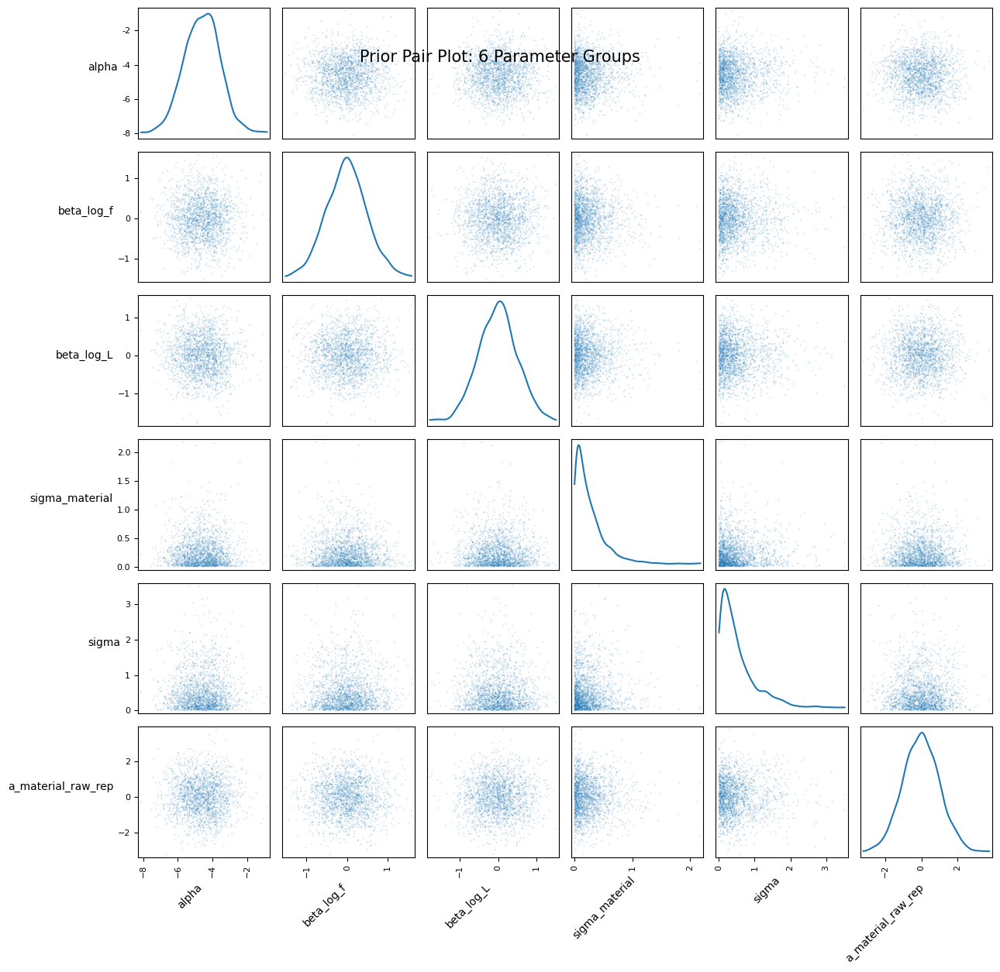

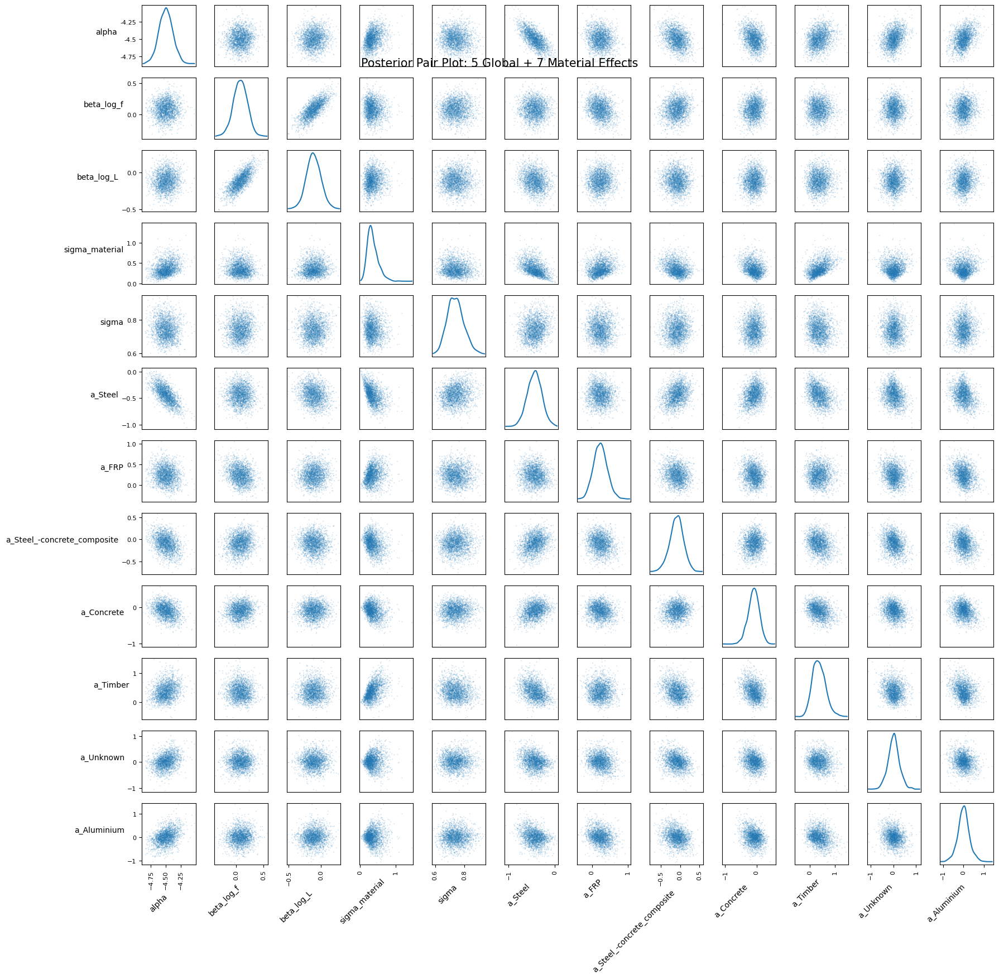

In [132]:
# ==================================================
# PAIR PLOTS WITHOUT SEABORN
# Prior: 6 parameter groups
# Posterior: 5 global + 7 material effects = 12 parameters
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


# ==================================================
# HELPER
# ==================================================

def flat_values(x):
    return np.asarray(x).reshape(-1)


def make_pair_plot(df, title, max_samples=2000, figsize=(16, 16)):
    """
    Simple pair plot using pandas scatter_matrix.
    """
    df_plot = df.dropna().copy()

    if len(df_plot) > max_samples:
        df_plot = df_plot.sample(max_samples, random_state=42)

    axes = scatter_matrix(
        df_plot,
        figsize=figsize,
        diagonal="kde",
        alpha=0.20,
        s=8,
        color="tab:blue"
    )

    plt.suptitle(title, y=0.92, fontsize=15)

    # Rotate labels for readability
    for ax in axes.flatten():
        ax.xaxis.label.set_rotation(45)
        ax.xaxis.label.set_ha("right")
        ax.yaxis.label.set_rotation(0)
        ax.yaxis.label.set_ha("right")

    plt.tight_layout()
    plt.show()


# ==================================================
# 1. PRIOR PAIR PLOT: 6 PRIOR GROUPS
# ==================================================
# 5 global priors:
# alpha, beta_log_f, beta_log_L, sigma_material, sigma
#
# plus one representative a_material_raw prior.
# All a_material_raw priors are exchangeable before seeing data.

prior_df = pd.DataFrame({
    "alpha": flat_values(prior.prior["alpha"]),
    "beta_log_f": flat_values(prior.prior["beta_log_f"]),
    "beta_log_L": flat_values(prior.prior["beta_log_L"]),
    "sigma_material": flat_values(prior.prior["sigma_material"]),
    "sigma": flat_values(prior.prior["sigma"]),
    "a_material_raw_rep": flat_values(
        prior.prior["a_material_raw"].isel(material=0)
    ),
})

make_pair_plot(
    prior_df,
    "Prior Pair Plot: 6 Parameter Groups",
    max_samples=2000,
    figsize=(13, 13)
)


# ==================================================
# 2. POSTERIOR PAIR PLOT: 12 POSTERIOR PARAMETERS
# ==================================================
# 5 global posterior parameters + 7 material effects

posterior_df = pd.DataFrame({
    "alpha": flat_values(trace.posterior["alpha"]),
    "beta_log_f": flat_values(trace.posterior["beta_log_f"]),
    "beta_log_L": flat_values(trace.posterior["beta_log_L"]),
    "sigma_material": flat_values(trace.posterior["sigma_material"]),
    "sigma": flat_values(trace.posterior["sigma"]),
})

# If material_names_clean exists, use real material names.
# Otherwise use material indices.
try:
    material_labels = list(material_names_clean)
except NameError:
    n_mat = trace.posterior["a_material"].sizes["material"]
    material_labels = [f"material_{i}" for i in range(n_mat)]

for i, mat_name in enumerate(material_labels):
    clean_name = str(mat_name).replace(" ", "_")
    posterior_df[f"a_{clean_name}"] = flat_values(
        trace.posterior["a_material"].isel(material=i)
    )

make_pair_plot(
    posterior_df,
    "Posterior Pair Plot: 5 Global + 7 Material Effects",
    max_samples=2500,
    figsize=(18, 18)
)


Posterior probability:
P(xi_v1 < 3%) = 93.97%
95% credible interval = [90.18%, 96.18%]


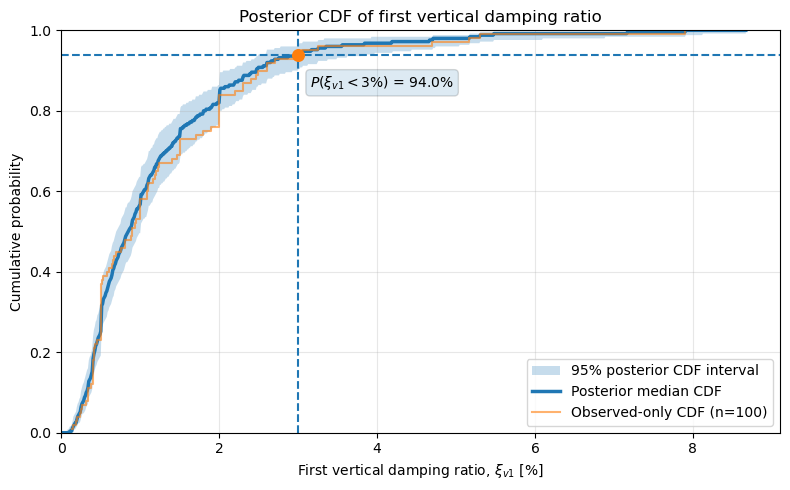

In [89]:
# ==================================================
# PLOT POSTERIOR CDF AND MARK P(xi_v1 < 3%)
# ==================================================

import numpy as np
import matplotlib.pyplot as plt

threshold = 0.03   # 3% damping ratio

# Observed damping values
observed_zeta = master_df.loc[
    master_df["vertical_damping_ratio"].notna(),
    "vertical_damping_ratio"
].to_numpy()

# If missing_samples is not already available, extract it from trace
try:
    missing_samples
except NameError:
    missing_samples = (
        trace.posterior["zeta_missing"]
        .stack(sample=("chain", "draw"))
        .transpose("zeta_missing_dim_0", "sample")
        .values
    )

n_draws = missing_samples.shape[1]

# Grid for CDF
all_values_for_grid = np.concatenate([
    observed_zeta,
    missing_samples.ravel()
])

x_max = np.percentile(all_values_for_grid, 99.5) * 1.20
x_grid = np.linspace(0, x_max, 800)

# Posterior CDF samples
cdf_samples = np.zeros((n_draws, len(x_grid)))

for j in range(n_draws):
    full_zeta_j = np.concatenate([
        observed_zeta,
        missing_samples[:, j]
    ])

    cdf_samples[j, :] = np.mean(
        full_zeta_j[:, None] <= x_grid[None, :],
        axis=0
    )

# Posterior CDF summary
cdf_median = np.percentile(cdf_samples, 50, axis=0)
cdf_lower = np.percentile(cdf_samples, 2.5, axis=0)
cdf_upper = np.percentile(cdf_samples, 97.5, axis=0)

# Probability below 3%
p_below_3_samples = np.array([
    np.interp(threshold, x_grid, cdf_samples[j, :])
    for j in range(n_draws)
])

p_below_3_median = np.percentile(p_below_3_samples, 50)
p_below_3_lower = np.percentile(p_below_3_samples, 2.5)
p_below_3_upper = np.percentile(p_below_3_samples, 97.5)

print("\nPosterior probability:")
print(f"P(xi_v1 < 3%) = {p_below_3_median*100:.2f}%")
print(f"95% credible interval = [{p_below_3_lower*100:.2f}%, {p_below_3_upper*100:.2f}%]")

# Observed-only empirical CDF for comparison
obs_sorted = np.sort(observed_zeta)
obs_cdf = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)

# Plot
plt.figure(figsize=(8, 5))

plt.fill_between(
    x_grid * 100,
    cdf_lower,
    cdf_upper,
    alpha=0.25,
    label="95% posterior CDF interval"
)

plt.plot(
    x_grid * 100,
    cdf_median,
    linewidth=2.5,
    label="Posterior median CDF"
)

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=1.5,
    alpha=0.6,
    label=f"Observed-only CDF (n={len(observed_zeta)})"
)

plt.axvline(threshold * 100, linestyle="--", linewidth=1.5)
plt.axhline(p_below_3_median, linestyle="--", linewidth=1.5)

plt.scatter(
    [threshold * 100],
    [p_below_3_median],
    s=70,
    zorder=5
)

plt.text(
    threshold * 100 + 0.15,
    p_below_3_median - 0.08,
    rf"$P(\xi_{{v1}} < 3\%)$ = {p_below_3_median*100:.1f}%",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Posterior CDF of first vertical damping ratio")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [133]:
# ==================================================
# PREDICT MISSING DAMPING RATIOS IN 25-BRIDGE MASS-RATIO CSV
# Run AFTER the Bayesian damping model has sampled.
# Requires:
#   trace
#   log_f_mean, log_f_std
#   log_L_mean, log_L_std
#   material_names_clean
# ==================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# FILE
# --------------------------------------------------
mass_csv = "Data Bridges and mass ratios.csv"

mass_df = pd.read_csv(mass_csv, encoding="utf-8-sig")


# --------------------------------------------------
# CLEANING HELPERS
# --------------------------------------------------
def clean_numeric_column(series):
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("–", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def clean_material_for_model(series):
    """
    Convert mass-ratio CSV material/type names into the material groups
    used in the Bayesian damping model.
    """
    s = series.astype(str).str.strip()

    out = []

    for item in s:
        x = item.lower()

        if "frp" in x:
            out.append("FRP")

        elif "concrete" in x and ("steel" in x or "composite" in x):
            out.append("Steel -concrete composite")

        elif "steel" in x or "warren" in x or "bow-string" in x or "suspended" in x:
            out.append("Steel")

        elif "concrete" in x:
            out.append("Concrete")

        elif "timber" in x:
            out.append("Timber")

        elif "aluminium" in x or "aluminum" in x:
            out.append("Aluminium")

        else:
            out.append("Unknown")

    return pd.Series(out, index=series.index)


# --------------------------------------------------
# PREPARE 25-BRIDGE DATA
# --------------------------------------------------
mass_df["first_vertical_frequency_Hz"] = clean_numeric_column(
    mass_df["First vertical frequency Hz"]
)

mass_df["span_for_model_m"] = clean_numeric_column(
    mass_df["Total length m"]
)

mass_df["observed_damping_ratio"] = clean_numeric_column(
    mass_df["First vertical damping ratio"]
)

mass_df["material_used"] = clean_material_for_model(
    mass_df["Material / type"]
)

missing_mask = mass_df["observed_damping_ratio"].isna()

print("Missing damping bridges:")
print(mass_df.loc[
    missing_mask,
    ["No.", "Bridge name", "Material / type", "material_used",
     "span_for_model_m", "first_vertical_frequency_Hz"]
].to_string(index=False))


# --------------------------------------------------
# CHECK MATERIALS EXIST IN MODEL
# --------------------------------------------------
model_materials = list(material_names_clean)

print("\nMaterial names in Bayesian model:")
print(model_materials)

# If a predicted material is not in the model, use Unknown if available.
# Otherwise use the first material as fallback.
fallback_material = "Unknown" if "Unknown" in model_materials else model_materials[0]

mass_df["material_used_for_prediction"] = mass_df["material_used"].where(
    mass_df["material_used"].isin(model_materials),
    fallback_material
)

material_to_idx = {m: i for i, m in enumerate(model_materials)}

pred_material_idx = mass_df["material_used_for_prediction"].map(material_to_idx).to_numpy()


# --------------------------------------------------
# STANDARDISE PREDICTORS USING ORIGINAL MODEL SCALING
# --------------------------------------------------
log_f_new = np.log(mass_df["first_vertical_frequency_Hz"].to_numpy())
log_L_new = np.log(mass_df["span_for_model_m"].to_numpy())

x_log_f_new = (log_f_new - log_f_mean) / log_f_std
x_log_L_new = (log_L_new - log_L_mean) / log_L_std


# --------------------------------------------------
# EXTRACT POSTERIOR SAMPLES
# --------------------------------------------------
alpha_s = trace.posterior["alpha"].values.reshape(-1)
beta_f_s = trace.posterior["beta_log_f"].values.reshape(-1)
beta_L_s = trace.posterior["beta_log_L"].values.reshape(-1)
sigma_s = trace.posterior["sigma"].values.reshape(-1)

a_mat_s = trace.posterior["a_material"].values
a_mat_s = a_mat_s.reshape(-1, a_mat_s.shape[-1])

n_samples = len(alpha_s)
n_bridges = len(mass_df)


# --------------------------------------------------
# POSTERIOR PREDICTION
# --------------------------------------------------
# mu_log gives the typical damping for each bridge.
# pred_log includes residual scatter, so it is better for imputing actual missing damping.

mu_log = np.zeros((n_samples, n_bridges))

for j in range(n_bridges):
    k = pred_material_idx[j]

    mu_log[:, j] = (
        alpha_s
        + beta_f_s * x_log_f_new[j]
        + beta_L_s * x_log_L_new[j]
        + a_mat_s[:, k]
    )

zeta_typical_samples = np.exp(mu_log)

rng = np.random.default_rng(42)
zeta_pred_samples = np.exp(
    rng.normal(loc=mu_log, scale=sigma_s[:, None])
)


# --------------------------------------------------
# SUMMARISE ONLY MISSING DAMPING VALUES
# --------------------------------------------------
rows = []

for j, row in mass_df.iterrows():
    if not missing_mask.iloc[j]:
        continue

    samples = zeta_pred_samples[:, j]

    rows.append({
        "No.": row["No."],
        "Bridge name": row["Bridge name"],
        "material_used": row["material_used_for_prediction"],
        "frequency_Hz": row["first_vertical_frequency_Hz"],
        "span_m": row["span_for_model_m"],
        "pred_median": np.percentile(samples, 50),
        "pred_mean": np.mean(samples),
        "pred_p05": np.percentile(samples, 5),
        "pred_p95": np.percentile(samples, 95),
        "P_xi_less_3_percent": np.mean(samples < 0.03),
    })

pred_missing_df = pd.DataFrame(rows)

print("\nPredicted missing damping ratios:")
print(pred_missing_df.to_string(index=False))


# --------------------------------------------------
# FILL CSV WITH POSTERIOR MEDIAN IMPUTATION
# --------------------------------------------------
mass_df["damping_ratio_completed_median"] = mass_df["observed_damping_ratio"]

for j in np.where(missing_mask.to_numpy())[0]:
    mass_df.loc[j, "damping_ratio_completed_median"] = np.percentile(
        zeta_pred_samples[:, j],
        50
    )

mass_df.to_csv(
    "Data Bridges and mass ratios_with_predicted_damping.csv",
    index=False,
    encoding="utf-8-sig"
)

pred_missing_df.to_csv(
    "predicted_missing_damping_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print("Data Bridges and mass ratios_with_predicted_damping.csv")
print("predicted_missing_damping_summary.csv")

Missing damping bridges:
 No.                           Bridge name            Material / type             material_used  span_for_model_m  first_vertical_frequency_Hz
   2                      Cekov Footbridge                   Concrete                  Concrete              80.0                         2.12
   9             Noisy-le-Grand Footbridge       Concrete ribbed slab                  Concrete              88.0                         1.65
  10                  Cavaillon Footbridge  Warren-type lateral beams                     Steel              99.4                         1.95
  12    Montigny-lès-Cormeilles Footbridge      Bow-string steel arch                     Steel              55.0                         2.51
  13 Footbridge over the Aisne at Soissons Suspended steel box girder                     Steel              60.0                         3.10
  15          Mont-Saint-Martin Footbridge  Mixed steel–concrete beam Steel -concrete composite              23.0    

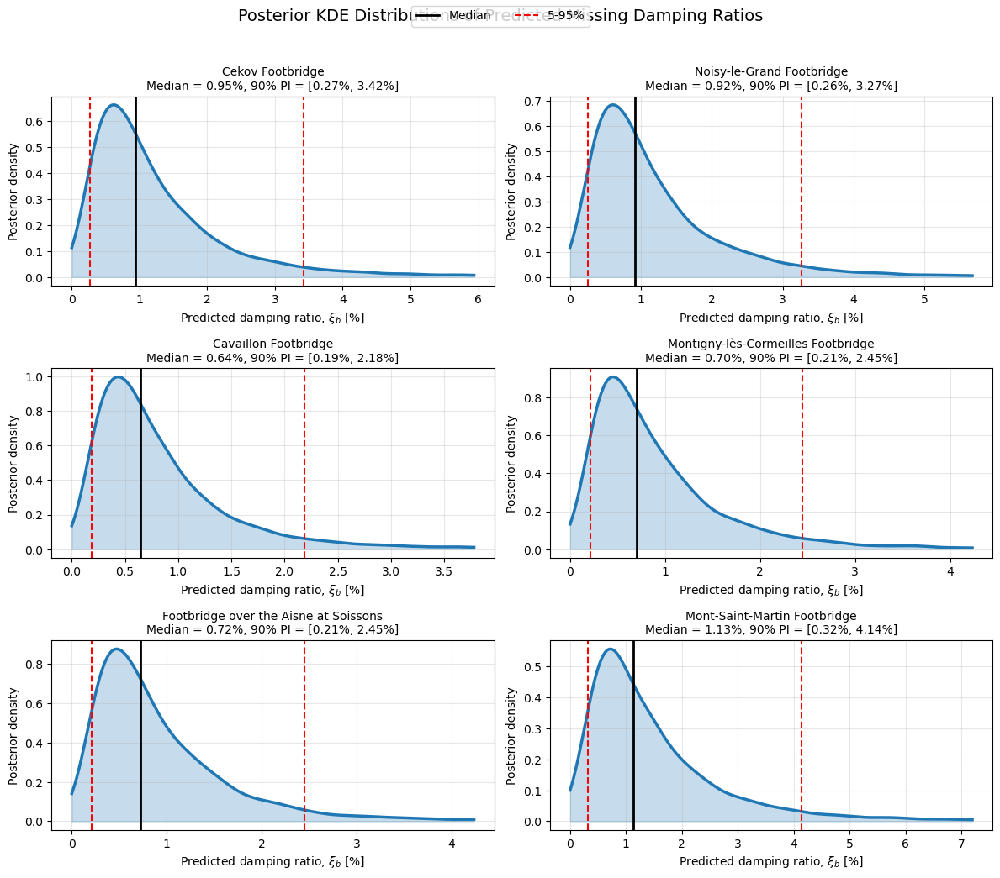

In [137]:
# ==================================================
# KDE POSTERIOR PLOTS OF PREDICTED MISSING DAMPING RATIOS
# ==================================================

import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import gaussian_kde

# Missing bridge indices
missing_indices = np.where(missing_mask.to_numpy())[0]
n_missing = len(missing_indices)

ncols = 2
nrows = math.ceil(n_missing / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(12, 3.4 * nrows),
    sharex=False
)

axes = np.asarray(axes).reshape(-1)

for ax, j in zip(axes, missing_indices):

    # Convert damping ratio to percentage
    samples = zeta_pred_samples[:, j] * 100

    q05, q50, q95 = np.percentile(samples, [5, 50, 95])

    bridge_name = mass_df.loc[j, "Bridge name"]

    # KDE
    kde = gaussian_kde(samples)

    x_min = max(0, q05 - 0.8 * (q95 - q05))
    x_max = q95 + 0.8 * (q95 - q05)

    x_grid = np.linspace(x_min, x_max, 500)
    y_kde = kde(x_grid)

    ax.plot(
        x_grid,
        y_kde,
        color="tab:blue",
        linewidth=2.5
    )

    ax.fill_between(
        x_grid,
        y_kde,
        color="tab:blue",
        alpha=0.25
    )

    ax.axvline(q50, color="black", linewidth=2, label="Median")
    ax.axvline(q05, color="red", linestyle="--", linewidth=1.5, label="5-95%")
    ax.axvline(q95, color="red", linestyle="--", linewidth=1.5)

    
    ax.set_title(
        f"{bridge_name}\n"
        rf"Median = {q50:.2f}%, 90% PI = [{q05:.2f}%, {q95:.2f}%]",
        fontsize=10
    )

    ax.set_xlabel(r"Predicted damping ratio, $\xi_b$ [%]")
    ax.set_ylabel("Posterior density")
    ax.grid(True, alpha=0.3)

# Remove unused axes
for ax in axes[n_missing:]:
    ax.axis("off")

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=True
)

plt.suptitle(
    "Posterior KDE Distributions of Predicted Missing Damping Ratios",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

Material population data from 250 bridges
                material  N_population  weight
                   Steel           152   0.608
                Concrete            43   0.172
Steel-concrete composite            24   0.096
                     FRP            17   0.068
                  Timber             7   0.028
                   Other             7   0.028

Known occupancy mass-ratio data
                          n_known  min_mu  median_mu  max_mu
material_group                                              
Steel                         7.0   0.068     0.1800   0.349
Concrete                      5.0   0.054     0.0710   0.229
Steel-concrete composite      2.0   0.105     0.1895   0.274
FRP                          10.0   0.365     0.8280   2.019
Timber                        0.0   0.000     0.0000   0.000
Other                         1.0   0.833     0.8330   0.833

Material-specific result for T = 0.3
                material  N_population  n_known_mass_ratio  k_below_T 

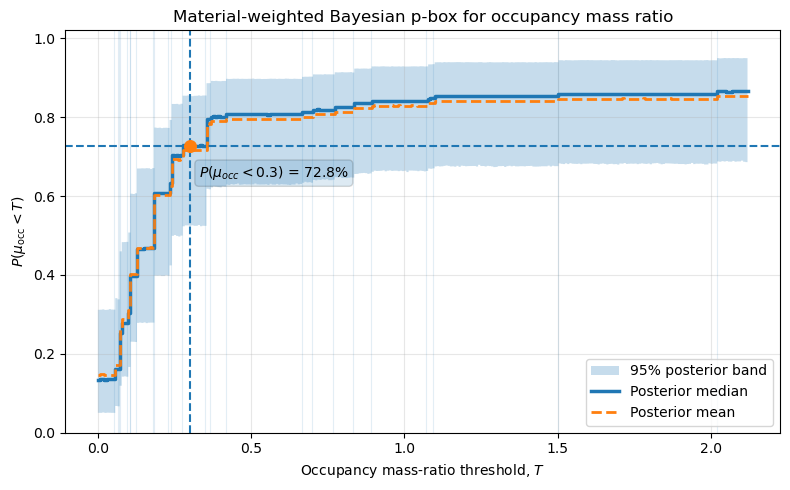

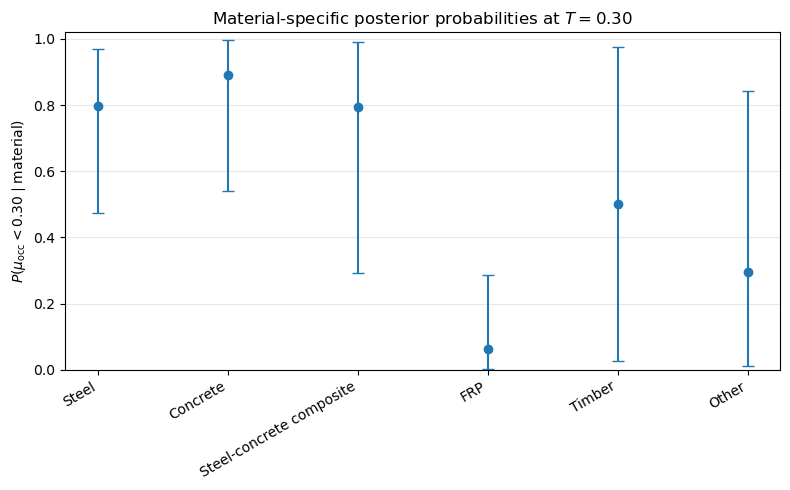

In [91]:
# ==================================================
# BAYESIAN MATERIAL-WEIGHTED P(mu_occ < T)
# Using 250-bridge material database + known mass-ratio data
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

MASTER_CSV = "data gong wei olivieri.csv"

RANDOM_SEED = 42
N_POSTERIOR_SAMPLES = 100_000

TARGET_THRESHOLD = 0.30

N_T_VALUES = 300

MATERIAL_ORDER = [
    "Steel",
    "Concrete",
    "Steel-concrete composite",
    "FRP",
    "Timber",
    "Other",
]

# ==================================================
# MATERIAL CLEANING FUNCTION
# ==================================================

def clean_material_group(x):
    """
    Converts raw material descriptions into final groups:
    Steel, Concrete, Steel-concrete composite, FRP, Timber, Other
    """
    s = str(x).strip().lower()

    if s in ["", "nan", "none", "-", "unknown", "other", "other types"]:
        return "Other"

    # FRP first
    if (
        "frp" in s
        or "gfrp" in s
        or "fiber" in s
        or "fibre" in s
        or "fiberglass" in s
        or "fibreglass" in s
        or "glass fibre" in s
        or "glass fiber" in s
    ):
        return "FRP"

    # Timber
    if "timber" in s or "wood" in s or "wooden" in s:
        return "Timber"

    # Steel-concrete composite
    # Check before plain steel/concrete
    if (
        ("steel" in s and "concrete" in s)
        or "steel-concrete" in s
        or "steel concrete" in s
        or "composite" in s
    ):
        return "Steel-concrete composite"

    # Concrete
    if "concrete" in s or "reinforced concrete" in s or s == "rc":
        return "Concrete"

    # Steel
    if "steel" in s:
        return "Steel"

    # Aluminium and unclear types go to Other
    return "Other"


# ==================================================
# LOAD 250-BRIDGE POPULATION MATERIAL DATA
# ==================================================

master_df = pd.read_csv(MASTER_CSV, encoding="utf-8-sig")
master_df = master_df.dropna(how="all").copy()

master_df["material_group"] = master_df["girder_material"].apply(clean_material_group)

population_counts = (
    master_df["material_group"]
    .value_counts()
    .reindex(MATERIAL_ORDER, fill_value=0)
)

n_population = population_counts.sum()

population_weights_empirical = population_counts / n_population

print("==========================================")
print("Material population data from 250 bridges")
print("==========================================")
print(pd.DataFrame({
    "material": MATERIAL_ORDER,
    "N_population": population_counts.values,
    "weight": population_weights_empirical.values
}).to_string(index=False))


# ==================================================
# KNOWN OCCUPANCY MASS-RATIO DATA
# ==================================================
# These are the values from your two mass-ratio tables.
# If you later make this an Excel/CSV file, replace this block with pd.read_csv.

mass_ratio_df = pd.DataFrame({
    "material_group": (
        ["Steel"] * 7
        + ["Concrete"] * 5
        + ["Steel-concrete composite"] * 2
        + ["FRP"] * 10
        + ["Other"] * 1
    ),
    "mu_occ": np.array([
        # Steel, n = 7
        0.068,
        0.104,
        0.126,
        0.349,
        0.238,
        0.180,
        0.183,

        # Concrete, n = 5
        0.067,
        0.071,
        0.229,
        0.096,
        0.054,

        # Steel-concrete composite, n = 2
        0.105,
        0.274,

        # FRP, n = 10
        0.766,
        0.417,
        0.700,
        1.071,
        0.665,
        0.890,
        0.365,
        2.019,
        1.094,
        1.500,

        # Other, n = 1
        # Cavaillon Footbridge / Warren-type lateral beams
        0.833,
    ])
})

# Make sure all materials are in final categories
mass_ratio_df["material_group"] = mass_ratio_df["material_group"].apply(clean_material_group)

print("\n==========================================")
print("Known occupancy mass-ratio data")
print("==========================================")
print(
    mass_ratio_df.groupby("material_group")["mu_occ"]
    .agg(n_known="size", min_mu="min", median_mu="median", max_mu="max")
    .reindex(MATERIAL_ORDER)
    .fillna(0)
)


# ==================================================
# BAYESIAN MODEL BY CONJUGATE SAMPLING
# ==================================================
# Material population proportions:
#     w ~ Dirichlet(1 + population_counts)
#
# Conditional probability for each material:
#     theta_m(T) = P(mu_occ < T | material m)
#     theta_m ~ Beta(1 + k_m, 1 + n_m - k_m)
#
# Overall:
#     p_overall(T) = sum_m w_m * theta_m(T)
# ==================================================

rng = np.random.default_rng(RANDOM_SEED)

# Posterior for material population weights
alpha_material = population_counts.values + 1.0

w_material_samples = rng.dirichlet(
    alpha_material,
    size=N_POSTERIOR_SAMPLES
)


def posterior_for_threshold(T):
    """
    Returns posterior samples and material summary for P(mu_occ < T).
    """

    theta_samples = np.zeros((N_POSTERIOR_SAMPLES, len(MATERIAL_ORDER)))

    material_rows = []

    for j, mat in enumerate(MATERIAL_ORDER):

        vals = mass_ratio_df.loc[
            mass_ratio_df["material_group"] == mat,
            "mu_occ"
        ].to_numpy()

        n_m = len(vals)
        k_m = np.sum(vals < T)

        # Beta-binomial update
        # If n_m = 0, this becomes Beta(1,1), i.e. very uncertain.
        theta_samples[:, j] = rng.beta(
            1 + k_m,
            1 + n_m - k_m,
            size=N_POSTERIOR_SAMPLES
        )

        material_rows.append({
            "material": mat,
            "N_population": int(population_counts.loc[mat]),
            "n_known_mass_ratio": int(n_m),
            "k_below_T": int(k_m),
            "empirical_k_over_n": np.nan if n_m == 0 else k_m / n_m,
            "theta_q025": np.quantile(theta_samples[:, j], 0.025),
            "theta_q50": np.quantile(theta_samples[:, j], 0.500),
            "theta_q975": np.quantile(theta_samples[:, j], 0.975),
        })

    # Law of total probability
    p_overall_samples = np.sum(
        w_material_samples * theta_samples,
        axis=1
    )

    material_summary = pd.DataFrame(material_rows)

    return p_overall_samples, theta_samples, material_summary


# ==================================================
# RESULT AT T = 0.30
# ==================================================

p_samples_030, theta_samples_030, material_summary_030 = posterior_for_threshold(
    TARGET_THRESHOLD
)

print("\n==========================================")
print(f"Material-specific result for T = {TARGET_THRESHOLD}")
print("==========================================")
print(material_summary_030.to_string(index=False))

print("\n==========================================")
print(f"Overall probability P(mu_occ < {TARGET_THRESHOLD})")
print("==========================================")
print(f"Posterior mean   = {np.mean(p_samples_030):.4f}")
print(f"Posterior median = {np.quantile(p_samples_030, 0.50):.4f}")
print(
    "95% credible interval = "
    f"[{np.quantile(p_samples_030, 0.025):.4f}, "
    f"{np.quantile(p_samples_030, 0.975):.4f}]"
)

print(
    f"\nAs percentage: P(mu_occ < {TARGET_THRESHOLD}) "
    f"= {np.quantile(p_samples_030, 0.50)*100:.1f}% "
    f"[{np.quantile(p_samples_030, 0.025)*100:.1f}%, "
    f"{np.quantile(p_samples_030, 0.975)*100:.1f}%]"
)


# ==================================================
# P-BOX / CDF OVER MANY THRESHOLDS
# ==================================================

all_mu = mass_ratio_df["mu_occ"].to_numpy()

T_grid = np.linspace(
    0.0,
    all_mu.max() * 1.05,
    N_T_VALUES
)

pbox_rows = []

for T in T_grid:

    p_samples, _, _ = posterior_for_threshold(T)

    pbox_rows.append({
        "T": T,
        "p_q025": np.quantile(p_samples, 0.025),
        "p_q05": np.quantile(p_samples, 0.05),
        "p_q50": np.quantile(p_samples, 0.50),
        "p_mean": np.mean(p_samples),
        "p_q95": np.quantile(p_samples, 0.95),
        "p_q975": np.quantile(p_samples, 0.975),
    })

pbox_df = pd.DataFrame(pbox_rows)

# Save results
material_summary_030.to_csv(
    "material_specific_probability_mu_less_than_0p30.csv",
    index=False,
    encoding="utf-8-sig"
)

pbox_df.to_csv(
    "material_weighted_bayesian_pbox_mu_occ.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print("material_specific_probability_mu_less_than_0p30.csv")
print("material_weighted_bayesian_pbox_mu_occ.csv")


# ==================================================
# PLOT OVERALL MATERIAL-WEIGHTED P-BOX
# ==================================================

plt.figure(figsize=(8, 5))

plt.fill_between(
    pbox_df["T"],
    pbox_df["p_q025"],
    pbox_df["p_q975"],
    alpha=0.25,
    step="post",
    label="95% posterior band"
)

plt.step(
    pbox_df["T"],
    pbox_df["p_q50"],
    where="post",
    linewidth=2.5,
    label="Posterior median"
)

plt.step(
    pbox_df["T"],
    pbox_df["p_mean"],
    where="post",
    linestyle="--",
    linewidth=2,
    label="Posterior mean"
)

# Mark target threshold T = 0.30
p030_med = np.quantile(p_samples_030, 0.50)

plt.axvline(TARGET_THRESHOLD, linestyle="--", linewidth=1.5)
plt.axhline(p030_med, linestyle="--", linewidth=1.5)

plt.scatter(
    [TARGET_THRESHOLD],
    [p030_med],
    s=70,
    zorder=5
)

plt.text(
    TARGET_THRESHOLD + 0.03,
    p030_med - 0.08,
    rf"$P(\mu_{{occ}} < {TARGET_THRESHOLD})$ = {p030_med*100:.1f}%",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

# Raw observations
for x in all_mu:
    plt.axvline(x, alpha=0.12, linewidth=0.8)

plt.xlabel(r"Occupancy mass-ratio threshold, $T$")
plt.ylabel(r"$P(\mu_{\mathrm{occ}} < T)$")
plt.title(r"Material-weighted Bayesian p-box for occupancy mass ratio")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT MATERIAL-SPECIFIC CONDITIONAL PROBABILITIES AT T=0.30
# ==================================================

plot_df = material_summary_030.copy()

plt.figure(figsize=(8, 5))

x = np.arange(len(plot_df))

plt.errorbar(
    x,
    plot_df["theta_q50"],
    yerr=[
        plot_df["theta_q50"] - plot_df["theta_q025"],
        plot_df["theta_q975"] - plot_df["theta_q50"]
    ],
    fmt="o",
    capsize=4,
    linewidth=1.5
)

plt.xticks(x, plot_df["material"], rotation=30, ha="right")
plt.ylabel(r"$P(\mu_{\mathrm{occ}} < 0.30 \mid \mathrm{material})$")
plt.title(r"Material-specific posterior probabilities at $T=0.30$")
plt.ylim(0, 1.02)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Population material counts from full database
                material  N_population  weight_empirical
                   Steel           152             0.608
                Concrete            43             0.172
Steel-concrete composite            24             0.096
                     FRP            17             0.068
                  Timber             7             0.028
                   Other             7             0.028

Total bridges in material population = 250

Known occupancy mass-ratio data
                          n_known  min_mu  median_mu  max_mu
material_group                                              
Steel                         7.0   0.068     0.1800   0.349
Concrete                      5.0   0.054     0.0710   0.229
Steel-concrete composite      2.0   0.105     0.1895   0.274
FRP                          10.0   0.365     0.8280   2.019
Timber                        0.0   0.000     0.0000   0.000
Other                         1.0   0.833     0.833

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [w_material, theta_material]
Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 13 seconds.



Fixed threshold result:
  T  p_overall_mean  p_overall_q025  p_overall_q50  p_overall_q975
0.3        0.717407        0.524486       0.728135        0.853059

P(mu_occ < 0.3) = 72.8% [52.4%, 85.3%]

Running threshold sweep in parallel
N_JOBS = 3
CHAINS = 4
CORES_PER_MODEL = 1
Approx active workers = 3


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   2 tasks      | elapsed:   14.6s
[Parallel(n_jobs=3)]: Done   7 tasks      | elapsed:   44.9s
[Parallel(n_jobs=3)]: Done  12 tasks      | elapsed:  1.1min
[Parallel(n_jobs=3)]: Done  19 tasks      | elapsed:  1.8min
[Parallel(n_jobs=3)]: Done  26 tasks      | elapsed:  2.4min
[Parallel(n_jobs=3)]: Done  35 tasks      | elapsed:  3.2min
[Parallel(n_jobs=3)]: Done  44 tasks      | elapsed:  4.0min
[Parallel(n_jobs=3)]: Done  55 tasks      | elapsed:  5.2min
[Parallel(n_jobs=3)]: Done  66 tasks      | elapsed:  6.2min
[Parallel(n_jobs=3)]: Done  79 tasks      | elapsed:  7.4min
[Parallel(n_jobs=3)]: Done  92 tasks      | elapsed:  8.5min
[Parallel(n_jobs=3)]: Done 107 tasks      | elapsed: 10.0min
[Parallel(n_jobs=3)]: Done 122 tasks      | elapsed: 11.5min
[Parallel(n_jobs=3)]: Done 139 tasks      | elapsed: 13.3min
[Parallel(n_jobs=3)]: Done 156 tasks      | elapsed: 15.1min
[Parallel(


PyMC material-weighted p-box dataframe
   T  p_overall_mean  p_overall_q025  p_overall_q50  p_overall_q975
0.00        0.146833        0.051122       0.134439        0.309524
0.01        0.146712        0.049977       0.134254        0.313828
0.02        0.147360        0.051293       0.135152        0.309606
0.03        0.147824        0.050225       0.135923        0.315285
0.04        0.147771        0.051511       0.135541        0.311661
0.05        0.147467        0.049218       0.135317        0.313317
0.06        0.171869        0.068158       0.161169        0.341957
0.07        0.262313        0.118500       0.253314        0.457652
0.08        0.287253        0.141816       0.277519        0.483371
0.09        0.287461        0.142723       0.277789        0.484661
0.10        0.311673        0.167163       0.302658        0.507269
0.11        0.402021        0.234064       0.395560        0.603072
0.12        0.402902        0.231812       0.396561        0.603911
0.13    

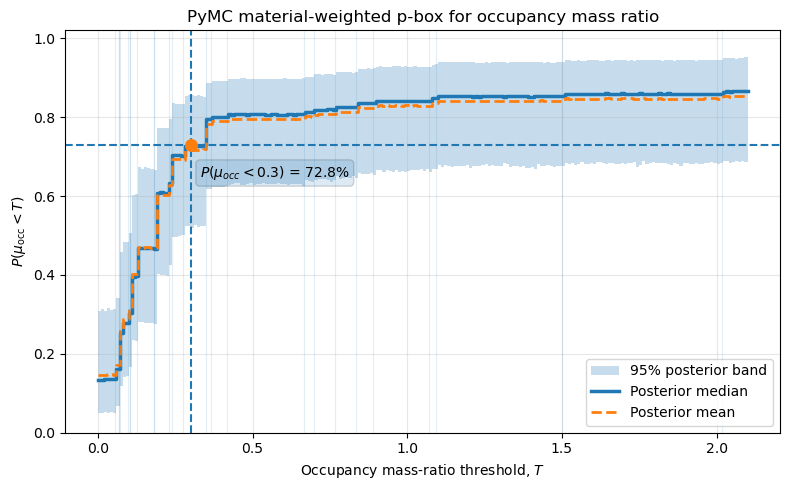


Material-specific probabilities at T = 0.3
                material  N_population  n_known  k_below  theta_q025  theta_q50  theta_q975
                   Steel           152        7        6    0.471943   0.799689    0.966481
                Concrete            43        5        5    0.540238   0.889688    0.995262
Steel-concrete composite            24        2        2    0.285335   0.792008    0.991203
                     FRP            17       10        0    0.002435   0.060482    0.276797
                  Timber             7        0        0    0.024565   0.500863    0.974832
                   Other             7        1        0    0.012545   0.295508    0.841893


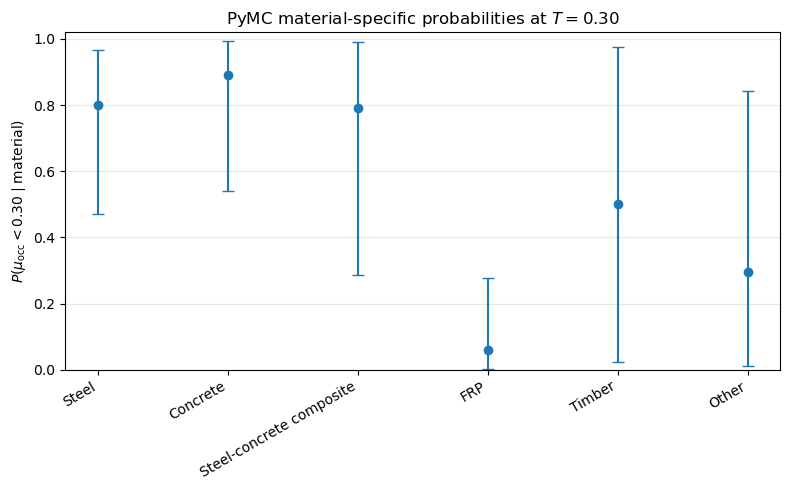

In [95]:
# ==================================================
# MATERIAL-WEIGHTED BAYESIAN MASS-RATIO MODEL IN PyMC
# P(mu_occ < T) using 6 material groups
# Parallel over threshold values
# ==================================================

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

# ==================================================
# SETTINGS
# ==================================================

RANDOM_SEED = 42

MASTER_CSV = "data gong wei olivieri.csv"

# Threshold grid settings
T_STEP = 0.01

# Parallel settings
N_JOBS = 3              # number of threshold models running at same time
CHAINS = 4              # chains per PyMC model
CORES_PER_MODEL = 1     # safer: chain parallelisation off inside each job

# If you want 3 jobs x 4 chain cores = about 12 workers, change:
# CORES_PER_MODEL = 4

# PyMC sampling settings
DRAWS = 4000
TUNE = 1000
TARGET_ACCEPT = 0.95

TARGET_THRESHOLD = 0.30

MATERIAL_ORDER = [
    "Steel",
    "Concrete",
    "Steel-concrete composite",
    "FRP",
    "Timber",
    "Other",
]

# ==================================================
# MATERIAL CLEANING FUNCTION
# ==================================================

def clean_material_group(x):
    """
    Converts raw material descriptions into final groups:
    Steel, Concrete, Steel-concrete composite, FRP, Timber, Other
    """
    s = str(x).strip().lower()

    if s in ["", "nan", "none", "-", "unknown", "other", "other types"]:
        return "Other"

    # FRP first
    if (
        "frp" in s
        or "gfrp" in s
        or "fiber" in s
        or "fibre" in s
        or "fiberglass" in s
        or "fibreglass" in s
        or "glass fibre" in s
        or "glass fiber" in s
    ):
        return "FRP"

    # Timber
    if "timber" in s or "wood" in s or "wooden" in s:
        return "Timber"

    # Steel-concrete composite
    # Important: check before plain steel/concrete
    if (
        ("steel" in s and "concrete" in s)
        or "steel-concrete" in s
        or "steel concrete" in s
        or "composite" in s
        or "mixed steel" in s
    ):
        return "Steel-concrete composite"

    # Concrete
    if "concrete" in s or "reinforced concrete" in s or s == "rc":
        return "Concrete"

    # Steel
    if "steel" in s:
        return "Steel"

    return "Other"


# ==================================================
# LOAD FULL 250-BRIDGE MATERIAL DATABASE
# ==================================================

master_df = pd.read_csv(MASTER_CSV, encoding="utf-8-sig")
master_df = master_df.dropna(how="all").copy()

# Use girder material column
master_df["material_group"] = master_df["girder_material"].apply(clean_material_group)

population_counts = (
    master_df["material_group"]
    .value_counts()
    .reindex(MATERIAL_ORDER, fill_value=0)
)

n_population = int(population_counts.sum())

print("==========================================")
print("Population material counts from full database")
print("==========================================")
print(pd.DataFrame({
    "material": MATERIAL_ORDER,
    "N_population": population_counts.values,
    "weight_empirical": population_counts.values / n_population,
}).to_string(index=False))

print(f"\nTotal bridges in material population = {n_population}")


# ==================================================
# KNOWN OCCUPANCY MASS-RATIO DATA
# ==================================================
# Replace this block with your final mass-ratio table if needed.
# Required columns:
#     material_group
#     mu_occ

mass_ratio_df = pd.DataFrame({
    "material_group": (
        ["Steel"] * 7
        + ["Concrete"] * 5
        + ["Steel-concrete composite"] * 2
        + ["FRP"] * 10
        + ["Other"] * 1
    ),
    "mu_occ": np.array([
        # Steel, n = 7
        0.068,
        0.104,
        0.126,
        0.349,
        0.238,
        0.180,
        0.183,

        # Concrete, n = 5
        0.067,
        0.071,
        0.229,
        0.096,
        0.054,

        # Steel-concrete composite, n = 2
        0.105,
        0.274,

        # FRP, n = 10
        0.766,
        0.417,
        0.700,
        1.071,
        0.665,
        0.890,
        0.365,
        2.019,
        1.094,
        1.500,

        # Other, n = 1
        0.833,
    ])
})

mass_ratio_df["material_group"] = mass_ratio_df["material_group"].apply(clean_material_group)

print("\n==========================================")
print("Known occupancy mass-ratio data")
print("==========================================")
print(
    mass_ratio_df.groupby("material_group")["mu_occ"]
    .agg(n_known="size", min_mu="min", median_mu="median", max_mu="max")
    .reindex(MATERIAL_ORDER)
    .fillna(0)
)

# ==================================================
# THRESHOLD GRID AT 0.1 INTERVALS
# ==================================================

all_mu = mass_ratio_df["mu_occ"].to_numpy()

T_min = 0.0
T_max = np.ceil(all_mu.max() * 10) / 10
T_grid = np.arange(T_min, T_max + T_STEP, T_STEP)

print("\n==========================================")
print("Threshold grid")
print("==========================================")
print(f"T_min = {T_grid.min():.2f}")
print(f"T_max = {T_grid.max():.2f}")
print(f"T_step = {T_STEP:.2f}")
print(f"Number of thresholds = {len(T_grid)}")
print(T_grid)


# ==================================================
# FUNCTION: RUN PyMC MODEL FOR ONE THRESHOLD
# ==================================================

def run_model_for_threshold(T, random_seed=42):
    """
    For one threshold T, estimate:

        P(mu_occ < T)

    using material-weighted law of total probability:

        P(mu_occ < T) = sum_m w_m * theta_m(T)

    where:
        w_m       = P(material = m)
        theta_m   = P(mu_occ < T | material = m)
    """

    # ------------------------------
    # Material population counts
    # ------------------------------
    material_count_obs = population_counts.values.astype("int64")
    n_material_total = int(material_count_obs.sum())

    # ------------------------------
    # Threshold counts by material
    # ------------------------------
    n_known = []
    k_below = []

    for mat in MATERIAL_ORDER:
        vals = mass_ratio_df.loc[
            mass_ratio_df["material_group"] == mat,
            "mu_occ"
        ].to_numpy()

        n_m = len(vals)
        k_m = int(np.sum(vals < T))

        n_known.append(n_m)
        k_below.append(k_m)

    n_known = np.array(n_known, dtype="int64")
    k_below = np.array(k_below, dtype="int64")

    # ------------------------------
    # PyMC model
    # ------------------------------
    with pm.Model() as model:

        # Material proportions in full bridge population
        # w_material has 6 components that sum to 1
        w_material = pm.Dirichlet(
            "w_material",
            a=np.ones(len(MATERIAL_ORDER))
        )

        # Likelihood for material counts in 250-bridge database
        material_counts = pm.Multinomial(
            "material_counts",
            n=n_material_total,
            p=w_material,
            observed=material_count_obs
        )

        # Conditional probability:
        # theta_m(T) = P(mu_occ < T | material m)
        theta_material = pm.Beta(
            "theta_material",
            alpha=np.ones(len(MATERIAL_ORDER)),
            beta=np.ones(len(MATERIAL_ORDER)),
            shape=len(MATERIAL_ORDER)
        )

        # Threshold-count likelihood by material
        threshold_counts = pm.Binomial(
            "threshold_counts",
            n=n_known,
            p=theta_material,
            observed=k_below
        )

        # Overall probability using law of total probability
        p_overall = pm.Deterministic(
            "p_overall",
            pm.math.sum(w_material * theta_material)
        )

        trace = pm.sample(
            draws=DRAWS,
            tune=TUNE,
            chains=CHAINS,
            cores=CORES_PER_MODEL,
            target_accept=TARGET_ACCEPT,
            random_seed=random_seed,
            progressbar=False
        )

    # ------------------------------
    # Extract posterior samples
    # ------------------------------
    w_samples = trace.posterior["w_material"].values
    theta_samples = trace.posterior["theta_material"].values
    p_samples = trace.posterior["p_overall"].values.ravel()

    # reshape:
    # w_samples: chains, draws, material
    # theta_samples: chains, draws, material
    w_flat = w_samples.reshape(-1, len(MATERIAL_ORDER))
    theta_flat = theta_samples.reshape(-1, len(MATERIAL_ORDER))

    row = {
        "T": float(T),
        "p_overall_mean": np.mean(p_samples),
        "p_overall_q025": np.quantile(p_samples, 0.025),
        "p_overall_q05": np.quantile(p_samples, 0.05),
        "p_overall_q50": np.quantile(p_samples, 0.50),
        "p_overall_q95": np.quantile(p_samples, 0.95),
        "p_overall_q975": np.quantile(p_samples, 0.975),
    }

    # Add material-specific results
    for j, mat in enumerate(MATERIAL_ORDER):
        safe_mat = (
            mat.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        theta_j = theta_flat[:, j]
        w_j = w_flat[:, j]

        row[f"{safe_mat}_N_population"] = int(material_count_obs[j])
        row[f"{safe_mat}_n_known"] = int(n_known[j])
        row[f"{safe_mat}_k_below"] = int(k_below[j])

        row[f"{safe_mat}_w_mean"] = np.mean(w_j)
        row[f"{safe_mat}_w_q50"] = np.quantile(w_j, 0.50)

        row[f"{safe_mat}_theta_mean"] = np.mean(theta_j)
        row[f"{safe_mat}_theta_q025"] = np.quantile(theta_j, 0.025)
        row[f"{safe_mat}_theta_q50"] = np.quantile(theta_j, 0.50)
        row[f"{safe_mat}_theta_q975"] = np.quantile(theta_j, 0.975)

    return row


# ==================================================
# RUN ONE FIXED THRESHOLD T = 0.30
# ==================================================

print("\n==========================================")
print(f"Running fixed threshold T = {TARGET_THRESHOLD}")
print("==========================================")

fixed_row = run_model_for_threshold(
    T=TARGET_THRESHOLD,
    random_seed=RANDOM_SEED
)

fixed_df = pd.DataFrame([fixed_row])

print("\nFixed threshold result:")
print(fixed_df[[
    "T",
    "p_overall_mean",
    "p_overall_q025",
    "p_overall_q50",
    "p_overall_q975"
]].to_string(index=False))

print(
    f"\nP(mu_occ < {TARGET_THRESHOLD}) = "
    f"{fixed_row['p_overall_q50']*100:.1f}% "
    f"[{fixed_row['p_overall_q025']*100:.1f}%, "
    f"{fixed_row['p_overall_q975']*100:.1f}%]"
)


# ==================================================
# WRAPPER FUNCTION FOR PARALLEL THRESHOLD SWEEP
# ==================================================

def run_one_threshold(i, T):
    print(f"Running threshold {i+1}/{len(T_grid)}: T = {T:.2f}")

    return run_model_for_threshold(
        T=float(T),
        random_seed=RANDOM_SEED + i + 1000
    )


# ==================================================
# RUN ALL THRESHOLDS IN PARALLEL
# ==================================================

print("\n==========================================")
print("Running threshold sweep in parallel")
print("==========================================")
print(f"N_JOBS = {N_JOBS}")
print(f"CHAINS = {CHAINS}")
print(f"CORES_PER_MODEL = {CORES_PER_MODEL}")
print(f"Approx active workers = {N_JOBS * CORES_PER_MODEL}")

rows = Parallel(
    n_jobs=N_JOBS,
    backend="loky",
    verbose=10
)(
    delayed(run_one_threshold)(i, T)
    for i, T in enumerate(T_grid)
)

pbox_df = pd.DataFrame(rows)
pbox_df = pbox_df.sort_values("T").reset_index(drop=True)

print("\n==========================================")
print("PyMC material-weighted p-box dataframe")
print("==========================================")
print(pbox_df[[
    "T",
    "p_overall_mean",
    "p_overall_q025",
    "p_overall_q50",
    "p_overall_q975"
]].to_string(index=False))


# ==================================================
# SAVE RESULTS
# ==================================================

fixed_df.to_csv(
    "fixed_threshold_pymc_material_weighted_mu_less_than_0p30.csv",
    index=False,
    encoding="utf-8-sig"
)

pbox_df.to_csv(
    "pbox_pymc_material_weighted_mass_ratio.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print("fixed_threshold_pymc_material_weighted_mu_less_than_0p30.csv")
print("pbox_pymc_material_weighted_mass_ratio.csv")


# ==================================================
# PLOT OVERALL P-BOX
# ==================================================

plt.figure(figsize=(8, 5))

plt.fill_between(
    pbox_df["T"],
    pbox_df["p_overall_q025"],
    pbox_df["p_overall_q975"],
    alpha=0.25,
    step="post",
    label="95% posterior band"
)

plt.step(
    pbox_df["T"],
    pbox_df["p_overall_q50"],
    where="post",
    linewidth=2.5,
    label="Posterior median"
)

plt.step(
    pbox_df["T"],
    pbox_df["p_overall_mean"],
    where="post",
    linestyle="--",
    linewidth=2,
    label="Posterior mean"
)

# Mark T = 0.30
p030_med = fixed_row["p_overall_q50"]

plt.axvline(TARGET_THRESHOLD, linestyle="--", linewidth=1.5)
plt.axhline(p030_med, linestyle="--", linewidth=1.5)

plt.scatter(
    [TARGET_THRESHOLD],
    [p030_med],
    s=70,
    zorder=5
)

plt.text(
    TARGET_THRESHOLD + 0.03,
    p030_med - 0.08,
    rf"$P(\mu_{{occ}} < {TARGET_THRESHOLD})$ = {p030_med*100:.1f}%",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

# Raw observations
for x in all_mu:
    plt.axvline(x, alpha=0.12, linewidth=0.8)

plt.xlabel(r"Occupancy mass-ratio threshold, $T$")
plt.ylabel(r"$P(\mu_{\mathrm{occ}} < T)$")
plt.title(r"PyMC material-weighted p-box for occupancy mass ratio")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# PLOT MATERIAL-SPECIFIC PROBABILITIES AT T = 0.30
# ==================================================

material_rows = []

for mat in MATERIAL_ORDER:
    safe_mat = (
        mat.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    material_rows.append({
        "material": mat,
        "N_population": fixed_row[f"{safe_mat}_N_population"],
        "n_known": fixed_row[f"{safe_mat}_n_known"],
        "k_below": fixed_row[f"{safe_mat}_k_below"],
        "theta_q025": fixed_row[f"{safe_mat}_theta_q025"],
        "theta_q50": fixed_row[f"{safe_mat}_theta_q50"],
        "theta_q975": fixed_row[f"{safe_mat}_theta_q975"],
    })

material_fixed_df = pd.DataFrame(material_rows)

print("\n==========================================")
print(f"Material-specific probabilities at T = {TARGET_THRESHOLD}")
print("==========================================")
print(material_fixed_df.to_string(index=False))

material_fixed_df.to_csv(
    "material_specific_pymc_mu_less_than_0p30.csv",
    index=False,
    encoding="utf-8-sig"
)

plt.figure(figsize=(8, 5))

x = np.arange(len(material_fixed_df))

plt.errorbar(
    x,
    material_fixed_df["theta_q50"],
    yerr=[
        material_fixed_df["theta_q50"] - material_fixed_df["theta_q025"],
        material_fixed_df["theta_q975"] - material_fixed_df["theta_q50"]
    ],
    fmt="o",
    capsize=4,
    linewidth=1.5
)

plt.xticks(x, material_fixed_df["material"], rotation=30, ha="right")
plt.ylabel(r"$P(\mu_{\mathrm{occ}} < 0.30 \mid \mathrm{material})$")
plt.title(r"PyMC material-specific probabilities at $T=0.30$")
plt.ylim(0, 1.02)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

P(mu_occ < 0.25) = 70.3% [49.5%, 83.3%]


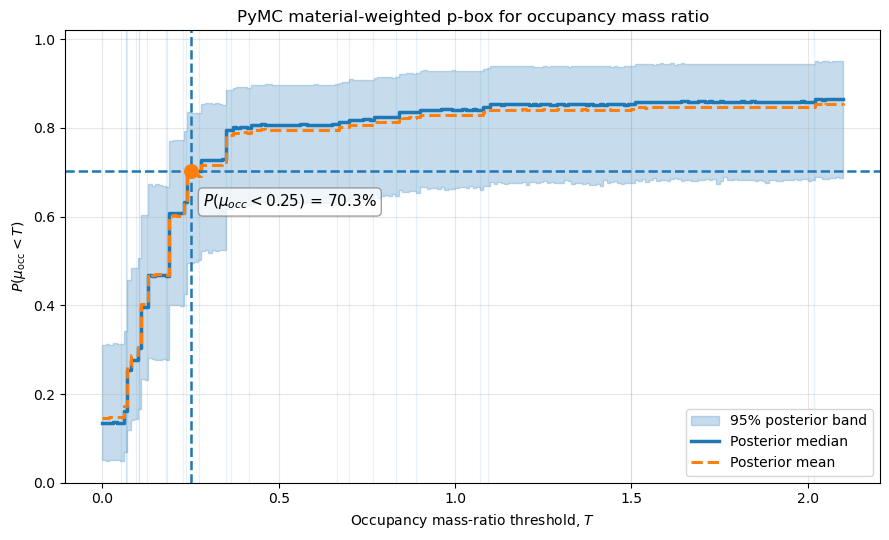

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# P-BOX PLOT WITH TARGET THRESHOLD T = 0.25
# ==================================================

TARGET_T = 0.25

# If pbox_df is not in memory, load it
if "pbox_df" not in globals():
    pbox_df = pd.read_csv("pbox_pymc_material_weighted_mass_ratio.csv")

required_cols = [
    "T",
    "p_overall_mean",
    "p_overall_q025",
    "p_overall_q50",
    "p_overall_q975",
]

missing_cols = [c for c in required_cols if c not in pbox_df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in pbox_df: {missing_cols}")

plot_df = pbox_df.copy()

for col in required_cols:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=required_cols).sort_values("T").copy()

# Find closest available threshold to TARGET_T
idx = np.argmin(np.abs(plot_df["T"].to_numpy() - TARGET_T))
target_row = plot_df.iloc[idx]

T_plot = target_row["T"]
p_med = target_row["p_overall_q50"]
p_mean = target_row["p_overall_mean"]
p_low = target_row["p_overall_q025"]
p_high = target_row["p_overall_q975"]

print(
    f"P(mu_occ < {T_plot:.2f}) = "
    f"{p_med*100:.1f}% "
    f"[{p_low*100:.1f}%, {p_high*100:.1f}%]"
)

# ==================================================
# PLOT
# ==================================================

fig, ax = plt.subplots(figsize=(9, 5.5))

# 95% posterior band
ax.fill_between(
    plot_df["T"],
    plot_df["p_overall_q025"],
    plot_df["p_overall_q975"],
    step="post",
    alpha=0.25,
    color="tab:blue",
    label="95% posterior band"
)

# Posterior median
ax.step(
    plot_df["T"],
    plot_df["p_overall_q50"],
    where="post",
    linewidth=2.5,
    color="tab:blue",
    label="Posterior median"
)

# Posterior mean
ax.step(
    plot_df["T"],
    plot_df["p_overall_mean"],
    where="post",
    linestyle="--",
    linewidth=2.2,
    color="tab:orange",
    label="Posterior mean"
)

# Raw observations, if available
if "all_mu" in globals():
    for x in all_mu:
        ax.axvline(
            x,
            color="tab:blue",
            alpha=0.10,
            linewidth=0.9
        )

# Highlight T = 0.25
ax.axvline(
    T_plot,
    linestyle="--",
    linewidth=1.8,
    color="tab:blue"
)

ax.axhline(
    p_med,
    linestyle="--",
    linewidth=1.8,
    color="tab:blue"
)

ax.scatter(
    [T_plot],
    [p_med],
    s=95,
    color="tab:orange",
    edgecolor="tab:orange",
    zorder=5
)

ax.text(
    T_plot + 0.035,
    p_med - 0.08,
    rf"$P(\mu_{{occ}} < {T_plot:.2f})$ = {p_med*100:.1f}%",
    fontsize=11,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.75
    )
)

ax.set_xlabel(r"Occupancy mass-ratio threshold, $T$")
ax.set_ylabel(r"$P(\mu_{\mathrm{occ}} < T)$")
ax.set_title("PyMC material-weighted p-box for occupancy mass ratio")

ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.30)
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

In [123]:
# ==================================================
# DIAGNOSTIC MODEL FOR ONE FIXED THRESHOLD
# Trace plot, Graphviz, Prior vs Posterior
# ==================================================

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# --------------------------------------------------
# Fixed threshold for diagnostics
# --------------------------------------------------
T_DIAG = 0.50

# Use 4 cores here because this is only ONE model, not parallel threshold sweep
CORES_FOR_DIAGNOSTIC = 4

# --------------------------------------------------
# Prepare observed counts for this threshold
# --------------------------------------------------
material_count_obs = population_counts.values.astype("int64")
n_material_total = int(material_count_obs.sum())

n_known = []
k_below = []

for mat in MATERIAL_ORDER:
    vals = mass_ratio_df.loc[
        mass_ratio_df["material_group"] == mat,
        "mu_occ"
    ].to_numpy()

    n_m = len(vals)
    k_m = int(np.sum(vals < T_DIAG))

    n_known.append(n_m)
    k_below.append(k_m)

n_known = np.array(n_known, dtype="int64")
k_below = np.array(k_below, dtype="int64")

diagnostic_counts_df = pd.DataFrame({
    "material": MATERIAL_ORDER,
    "N_population": material_count_obs,
    "n_known_mass_ratio": n_known,
    "k_mu_below_T": k_below,
})

print("==========================================")
print(f"Diagnostic threshold T = {T_DIAG}")
print("==========================================")
print(diagnostic_counts_df.to_string(index=False))


# ==================================================
# BUILD PyMC MODEL
# ==================================================

coords = {
    "material": MATERIAL_ORDER
}

with pm.Model(coords=coords) as mass_ratio_model:

    # --------------------------------------------------
    # Prior for material proportions in full population
    # w_m = P(material = m)
    # --------------------------------------------------
    w_material = pm.Dirichlet(
        "w_material",
        a=np.ones(len(MATERIAL_ORDER)),
        dims="material"
    )

    # --------------------------------------------------
    # Likelihood for material counts in full bridge database
    # N_material ~ Multinomial(N, w)
    # --------------------------------------------------
    material_counts = pm.Multinomial(
        "material_counts",
        n=n_material_total,
        p=w_material,
        observed=material_count_obs,
        dims="material"
    )

    # --------------------------------------------------
    # Prior for material-specific threshold probability
    # theta_m(T) = P(mu_occ < T | material m)
    # --------------------------------------------------
    theta_material = pm.Beta(
        "theta_material",
        alpha=np.ones(len(MATERIAL_ORDER)),
        beta=np.ones(len(MATERIAL_ORDER)),
        dims="material"
    )

    # --------------------------------------------------
    # Likelihood for known mass-ratio threshold counts
    # k_m(T) ~ Binomial(n_m, theta_m)
    # --------------------------------------------------
    threshold_counts = pm.Binomial(
        "threshold_counts",
        n=n_known,
        p=theta_material,
        observed=k_below,
        dims="material"
    )

    # --------------------------------------------------
    # Deterministic overall probability
    # P(mu_occ < T) = sum_m w_m * theta_m(T)
    # --------------------------------------------------
    p_overall = pm.Deterministic(
        "p_overall",
        pm.math.sum(w_material * theta_material)
    )

    # --------------------------------------------------
    # Prior predictive samples
    # --------------------------------------------------
    prior = pm.sample_prior_predictive(
        samples=5000,
        var_names=[
            "w_material",
            "theta_material",
            "p_overall"
        ],
        random_seed=42
    )

    # --------------------------------------------------
    # Posterior sampling
    # --------------------------------------------------
    trace = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=CORES_FOR_DIAGNOSTIC,
        target_accept=TARGET_ACCEPT,
        random_seed=42
    )

Sampling: [theta_material, w_material]


Diagnostic threshold T = 0.5
                material  N_population  n_known_mass_ratio  k_mu_below_T
                   Steel           152                   7             7
                Concrete            43                   5             5
Steel-concrete composite            24                   2             2
                     FRP            17                  10             2
                  Timber             7                   0             0
                   Other             7                   1             0


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_material, theta_material]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 29 seconds.


Posterior for P(mu_occ < 0.5)
Mean   = 0.7952
Median = 0.8063
95% credible interval = [0.6299, 0.8970]
As percentage = 80.6% [63.0%, 89.7%]


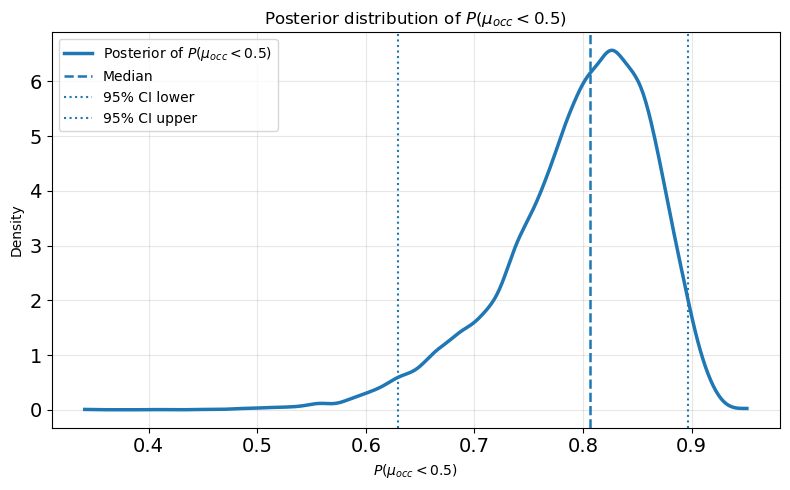

In [124]:
# ==================================================
# PLOT POSTERIOR DISTRIBUTION OF p_overall
# ==================================================

import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# Extract posterior samples of p_overall
p_overall_samples = trace.posterior["p_overall"].values.reshape(-1)

# Summary statistics
p_mean = np.mean(p_overall_samples)
p_median = np.quantile(p_overall_samples, 0.50)
p_lower = np.quantile(p_overall_samples, 0.025)
p_upper = np.quantile(p_overall_samples, 0.975)

print("==========================================")
print(f"Posterior for P(mu_occ < {T_DIAG})")
print("==========================================")
print(f"Mean   = {p_mean:.4f}")
print(f"Median = {p_median:.4f}")
print(f"95% credible interval = [{p_lower:.4f}, {p_upper:.4f}]")
print(f"As percentage = {p_median*100:.1f}% [{p_lower*100:.1f}%, {p_upper*100:.1f}%]")

# Plot posterior PDF
plt.figure(figsize=(8, 5))

az.plot_kde(
    p_overall_samples,
    label=rf"Posterior of $P(\mu_{{occ}} < {T_DIAG})$",
    plot_kwargs={"linewidth": 2.5}
)

plt.axvline(p_median, linestyle="--", linewidth=1.8, label="Median")
plt.axvline(p_lower, linestyle=":", linewidth=1.5, label="95% CI lower")
plt.axvline(p_upper, linestyle=":", linewidth=1.5, label="95% CI upper")

plt.xlabel(rf"$P(\mu_{{occ}} < {T_DIAG})$")
plt.ylabel("Density")
plt.title(rf"Posterior distribution of $P(\mu_{{occ}} < {T_DIAG})$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

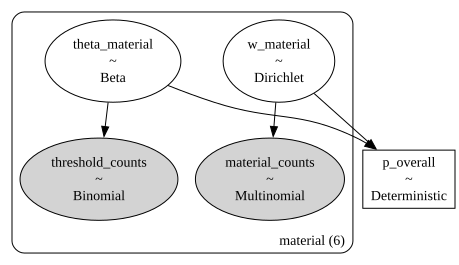

Graphviz model saved.


In [ ]:
# ==================================================
# GRAPHVIZ MODEL DIAGRAM
# ==================================================

try:
    graph = pm.model_to_graphviz(mass_ratio_model)
    display(graph)

    # Optional: save as file
    graph.render(
        filename=f"mass_ratio_graphviz_T_{T_DIAG:.2f}".replace(".", "p"),
        format="png",
        cleanup=True
    )

    print("Graphviz model saved.")

except Exception as e:
    print("Graphviz failed.")
    print("You may need to install graphviz:")
    print("conda install python-graphviz graphviz")
    print("Error message:")
    print(e)

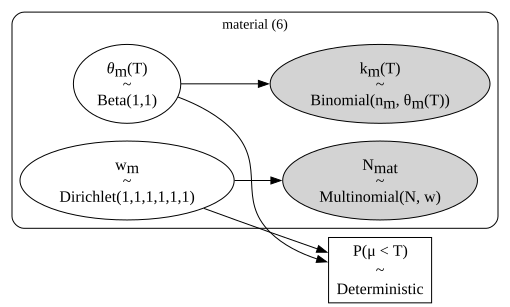

Saved: mass_ratio_symbolic_graphviz.png


In [111]:
from graphviz import Digraph
from IPython.display import display

# ==================================================
# ORIGINAL-STYLE GRAPHVIZ MODEL WITH SYMBOLS
# ==================================================

g = Digraph("mass_ratio_symbolic", format="png")

g.attr(rankdir="LR")
g.attr("node", fontname="Times New Roman", fontsize="16")
g.attr("edge", fontname="Times New Roman", fontsize="12")

# --------------------------------------------------
# Plate: material (6)
# --------------------------------------------------
with g.subgraph(name="cluster_material") as c:
    c.attr(
        label="material (6)",
        style="rounded",
        color="black",
        fontname="Times New Roman",
        fontsize="14"
    )

    # theta_material  ->  θ_m(T)
    c.node(
        "theta_material",
        label=(
            "<<I>&theta;</I><SUB>m</SUB>(T)"
            "<BR/>~"
            "<BR/>Beta(1,1)>"
        ),
        shape="ellipse"
    )

    # w_material  ->  w_m
    # keep it inside the plate to match the original PyMC-style layout
    c.node(
        "w_material",
        label=(
            "<w<SUB>m</SUB>"
            "<BR/>~"
            "<BR/>Dirichlet(1,1,1,1,1,1)>"
        ),
        shape="ellipse"
    )

    # threshold_counts -> k_m(T)
    c.node(
        "threshold_counts",
        label=(
            "<k<SUB>m</SUB>(T)"
            "<BR/>~"
            "<BR/>Binomial(n<SUB>m</SUB>, &theta;<SUB>m</SUB>(T))>"
        ),
        shape="ellipse",
        style="filled",
        fillcolor="lightgray"
    )

    # material_counts -> N_mat
    c.node(
        "material_counts",
        label=(
            "<N<SUB>mat</SUB>"
            "<BR/>~"
            "<BR/>Multinomial(N, w)>"
        ),
        shape="ellipse",
        style="filled",
        fillcolor="lightgray"
    )

# --------------------------------------------------
# Deterministic node outside the plate
# --------------------------------------------------
g.node(
    "p_overall",
    label=(
        "<P(&mu; &lt; T)"
        "<BR/>~"
        "<BR/>Deterministic>"
    ),
    shape="box"
)

# --------------------------------------------------
# Edges exactly like the original layout
# --------------------------------------------------
g.edge("theta_material", "threshold_counts")
g.edge("w_material", "material_counts")
g.edge("theta_material", "p_overall")
g.edge("w_material", "p_overall")

# --------------------------------------------------
# Display and save
# --------------------------------------------------
display(g)

g.render("mass_ratio_symbolic_graphviz", cleanup=True)
print("Saved: mass_ratio_symbolic_graphviz.png")

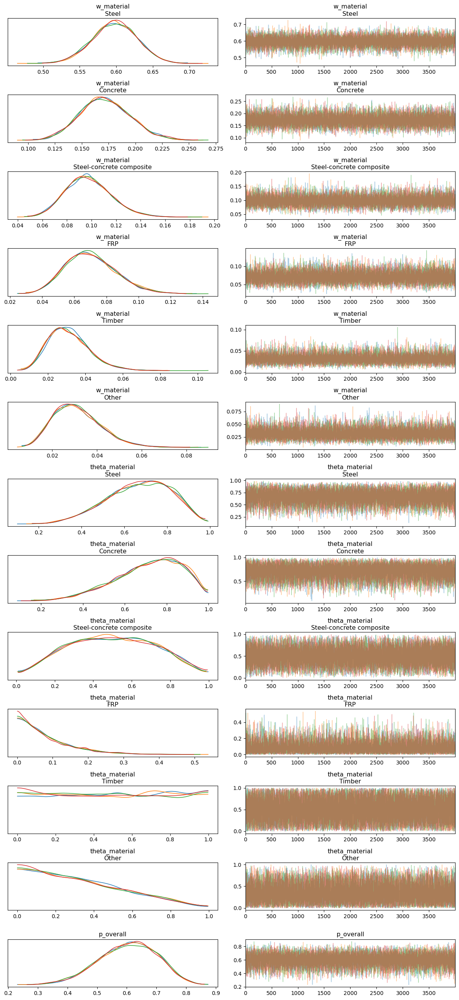

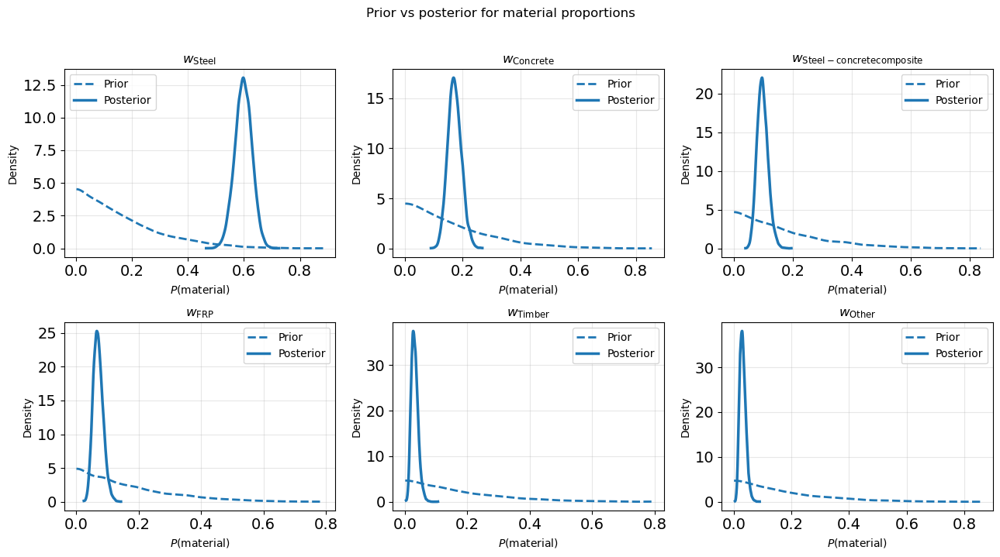

In [112]:
# ==================================================
# TRACE PLOTS FOR ALL MODEL PARAMETERS
# ==================================================

az.plot_trace(
    trace,
    var_names=[
        "w_material",
        "theta_material",
        "p_overall"
    ],
    compact=False
)

plt.tight_layout()
plt.show()

# ==================================================
# PRIOR VS POSTERIOR FOR MATERIAL PROPORTIONS w_m
# ==================================================

w_prior = (
    prior.prior["w_material"]
    .stack(sample=("chain", "draw"))
    .transpose("material", "sample")
    .values
)

w_post = (
    trace.posterior["w_material"]
    .stack(sample=("chain", "draw"))
    .transpose("material", "sample")
    .values
)

n_mat = len(MATERIAL_ORDER)
n_cols = 3
n_rows = int(np.ceil(n_mat / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.5 * n_rows))
axes = np.asarray(axes).flatten()

for j, mat in enumerate(MATERIAL_ORDER):

    ax = axes[j]

    az.plot_kde(
        w_prior[j, :],
        ax=ax,
        label="Prior",
        plot_kwargs={"linewidth": 2, "linestyle": "--"}
    )

    az.plot_kde(
        w_post[j, :],
        ax=ax,
        label="Posterior",
        plot_kwargs={"linewidth": 2.5}
    )

    ax.set_title(rf"$w_{{\mathrm{{{mat}}}}}$")
    ax.set_xlabel(r"$P(\mathrm{material})$")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[n_mat:]:
    fig.delaxes(ax)

plt.suptitle("Prior vs posterior for material proportions", y=1.02)
plt.tight_layout()
plt.show()

c:\Users\slok0019\AppData\Local\miniconda3\envs\sfhsi\lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


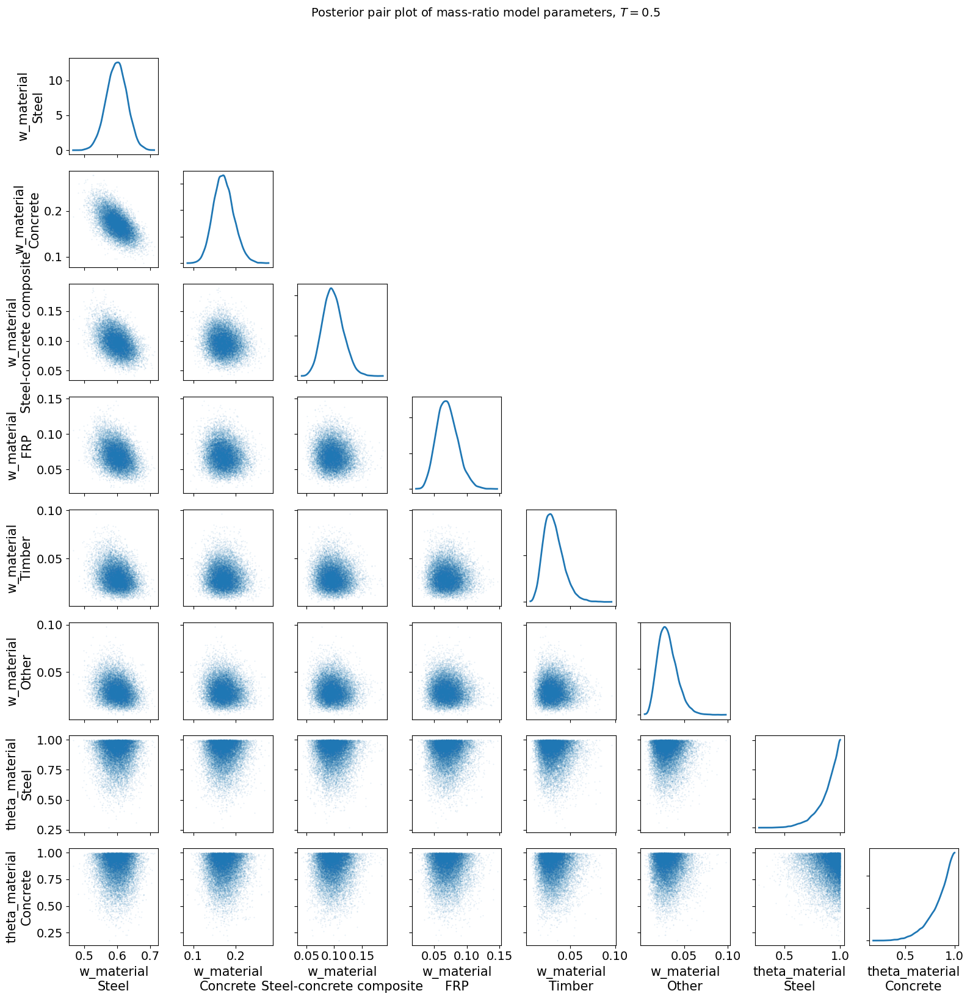

In [128]:
# ==================================================
# PAIR PLOT FOR ALL MASS-RATIO MODEL PARAMETERS
# ==================================================

import arviz as az
import matplotlib.pyplot as plt

az.plot_pair(
    trace,
    var_names=[
        "w_material",
        "theta_material",
        "p_overall"
    ],
    kind="scatter",
    marginals=True,
    divergences=True,
    figsize=(16, 16),
    scatter_kwargs={
        "alpha": 0.12,
        "s": 8
    },
    marginal_kwargs={
        "plot_kwargs": {"linewidth": 2}
    }
)

plt.suptitle(
    rf"Posterior pair plot of mass-ratio model parameters, $T={T_DIAG}$",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()

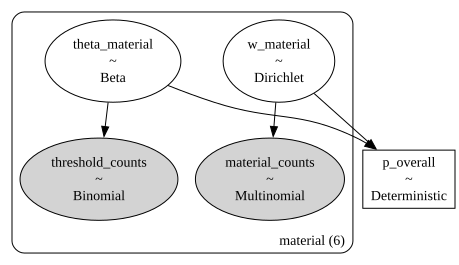

Graphviz model saved.


In [113]:
# ==================================================
# GRAPHVIZ MODEL DIAGRAM
# ==================================================

try:
    graph = pm.model_to_graphviz(mass_ratio_model)
    display(graph)

    # Optional: save as file
    graph.render(
        filename=f"mass_ratio_graphviz_T_{T_DIAG:.2f}".replace(".", "p"),
        format="png",
        cleanup=True
    )

    print("Graphviz model saved.")

except Exception as e:
    print("Graphviz failed.")
    print("You may need to install graphviz:")
    print("conda install python-graphviz graphviz")
    print("Error message:")
    print(e)

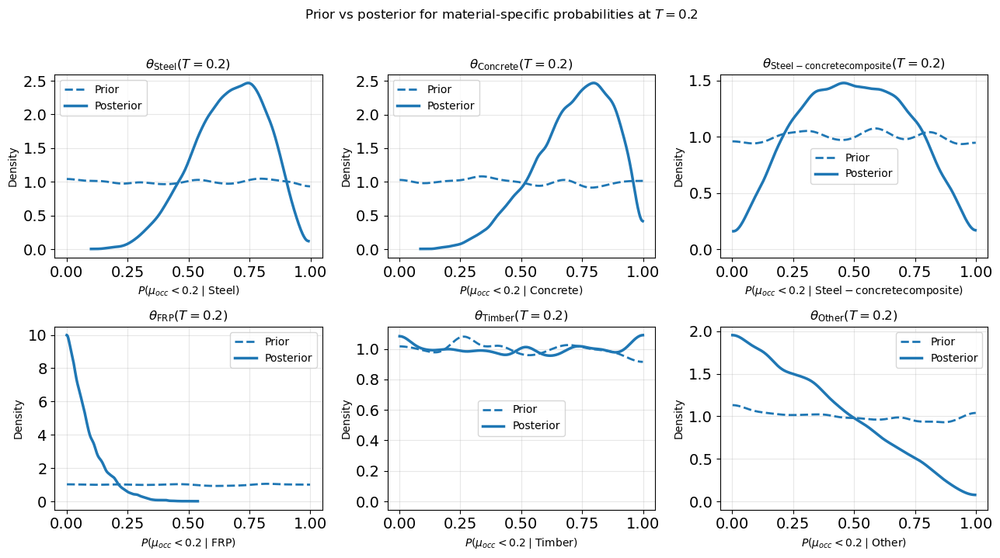

In [114]:
# ==================================================
# PRIOR VS POSTERIOR FOR MATERIAL-SPECIFIC theta_m(T)
# ==================================================

theta_prior = (
    prior.prior["theta_material"]
    .stack(sample=("chain", "draw"))
    .transpose("material", "sample")
    .values
)

theta_post = (
    trace.posterior["theta_material"]
    .stack(sample=("chain", "draw"))
    .transpose("material", "sample")
    .values
)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.5 * n_rows))
axes = np.asarray(axes).flatten()

for j, mat in enumerate(MATERIAL_ORDER):

    ax = axes[j]

    az.plot_kde(
        theta_prior[j, :],
        ax=ax,
        label="Prior",
        plot_kwargs={"linewidth": 2, "linestyle": "--"}
    )

    az.plot_kde(
        theta_post[j, :],
        ax=ax,
        label="Posterior",
        plot_kwargs={"linewidth": 2.5}
    )

    ax.set_title(rf"$\theta_{{\mathrm{{{mat}}}}}(T={T_DIAG})$")
    ax.set_xlabel(rf"$P(\mu_{{occ}} < {T_DIAG} \mid \mathrm{{{mat}}})$")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[n_mat:]:
    fig.delaxes(ax)

plt.suptitle(
    rf"Prior vs posterior for material-specific probabilities at $T={T_DIAG}$",
    y=1.02
)
plt.tight_layout()
plt.show()

In [139]:
import re
import numpy as np
import pandas as pd

# ==================================================
# SETTINGS
# ==================================================

POP_CSV = "data gong wei olivieri.csv"
MU_CSV = "Data Bridges and mass ratios.csv"

F_LIMIT = 5.0
XI_LIMIT = 0.03
MU_LIMIT = 0.25


# ==================================================
# HELPER FUNCTIONS
# ==================================================

def clean_numeric_column(series):
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("–", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def clean_damping_ratio(series):
    raw = series.astype(str)
    raw = raw.str.replace("−", "-", regex=False)
    raw = raw.str.replace("–", "-", regex=False)
    raw = raw.str.replace("%", "", regex=False)

    values = []

    for item in raw:
        nums = re.findall(r"\d*\.?\d+(?:[eE][-+]?\d+)?", item)

        if len(nums) == 0:
            values.append(np.nan)

        elif len(nums) >= 2 and ("-" in item or "to" in item.lower()):
            values.append(np.mean([float(nums[0]), float(nums[1])]))

        else:
            values.append(float(nums[0]))

    z = pd.Series(values, index=series.index, dtype=float)

    # Convert percent-like values to ratio
    # Example: 0.43 means 0.43%, so becomes 0.0043
    percent_like = z.notna() & (z > 0.20) & (z <= 20)
    z.loc[percent_like] = z.loc[percent_like] / 100.0

    impossible = z.notna() & ((z <= 0) | (z > 0.20))
    z.loc[impossible] = np.nan

    return z


# ==================================================
# 1. LOAD 250-BRIDGE POPULATION DATA
# ==================================================

pop_df = pd.read_csv(POP_CSV, encoding="utf-8-sig")
pop_df = pop_df.dropna(how="all").copy()

pop_df["frequency"] = clean_numeric_column(
    pop_df["vertical_natural_frequency_Hz"]
)

pop_df["damping"] = clean_damping_ratio(
    pop_df["vertical_damping_ratio"]
)

# IMPORTANT:
# If you have already saved a completed damping column from Bayesian imputation,
# replace this line with that completed column.
#
# Example:
# pop_df["damping"] = pop_df["vertical_damping_ratio"].fillna(pop_df["zeta_imputed_median"])

pop_valid = pop_df.dropna(subset=["frequency", "damping"]).copy()

A_pop = pop_valid["frequency"] < F_LIMIT
B_pop = pop_valid["damping"] < XI_LIMIT

p_AB = (A_pop & B_pop).mean()

n_AB_pop = int((A_pop & B_pop).sum())
n_pop_used = len(pop_valid)


# ==================================================
# 2. LOAD 25-BRIDGE MASS-RATIO DATA
# ==================================================

mu_df = pd.read_csv(MU_CSV, encoding="utf-8-sig")
mu_df = mu_df.dropna(how="all").copy()

mu_df["frequency"] = clean_numeric_column(
    mu_df["First vertical frequency Hz"]
)

mu_df["damping"] = clean_damping_ratio(
    mu_df["First vertical damping ratio"]
)

mu_df["mass_ratio"] = clean_numeric_column(
    mu_df["Occupancy mass ratio"]
)

mu_valid = mu_df.dropna(
    subset=["frequency", "damping", "mass_ratio"]
).copy()

A_mu = mu_valid["frequency"] < F_LIMIT
B_mu = mu_valid["damping"] < XI_LIMIT
C_mu = mu_valid["mass_ratio"] < MU_LIMIT

AB_mu = A_mu & B_mu

p_C_given_AB = C_mu[AB_mu].mean()

n_AB_mu = int(AB_mu.sum())
n_ABC_mu = int((AB_mu & C_mu).sum())


# ==================================================
# 3. COMBINED PROBABILITY
# ==================================================

p_ABC = p_AB * p_C_given_AB


# ==================================================
# 4. PRINT RESULTS
# ==================================================

print("==========================================")
print("Frequency-damping probability from population data")
print("==========================================")
print(f"Population rows used = {n_pop_used}")
print(f"Number satisfying f < {F_LIMIT} and xi < {XI_LIMIT} = {n_AB_pop}")
print(f"P(A,B) = P(f < {F_LIMIT}, xi < {XI_LIMIT}) = {p_AB:.4f}")
print(f"P(A,B) [%] = {100*p_AB:.1f}%")

print("\n==========================================")
print("Mass-ratio conditional probability from 25-bridge data")
print("==========================================")
print(f"Mass-ratio rows with f, xi, mu available = {len(mu_valid)}")
print(f"Number satisfying A,B = {n_AB_mu}")
print(f"Number satisfying A,B,C = {n_ABC_mu}")
print(f"P(C | A,B) = P(mu < {MU_LIMIT} | f < {F_LIMIT}, xi < {XI_LIMIT}) = {p_C_given_AB:.4f}")
print(f"P(C | A,B) [%] = {100*p_C_given_AB:.1f}%")

print("\n==========================================")
print("Combined probability")
print("==========================================")
print(f"P(A,B,C) = P(A,B) * P(C | A,B)")
print(f"P(A,B,C) = {p_AB:.4f} * {p_C_given_AB:.4f} = {p_ABC:.4f}")
print(f"P(A,B,C) [%] = {100*p_ABC:.1f}%")


# ==================================================
# 5. SHOW WHICH 25 BRIDGES WERE USED
# ==================================================

check_table = mu_valid[[
    "Bridge name",
    "frequency",
    "damping",
    "mass_ratio",
]].copy()

check_table["A_f_less_limit"] = check_table["frequency"] < F_LIMIT
check_table["B_xi_less_limit"] = check_table["damping"] < XI_LIMIT
check_table["C_mu_less_limit"] = check_table["mass_ratio"] < MU_LIMIT
check_table["AB"] = check_table["A_f_less_limit"] & check_table["B_xi_less_limit"]
check_table["ABC"] = check_table["AB"] & check_table["C_mu_less_limit"]

print("\n==========================================")
print("25-bridge check table")
print("==========================================")
print(check_table.to_string(index=False))

Frequency-damping probability from population data
Population rows used = 100
Number satisfying f < 5.0 and xi < 0.03 = 85
P(A,B) = P(f < 5.0, xi < 0.03) = 0.8500
P(A,B) [%] = 85.0%

Mass-ratio conditional probability from 25-bridge data
Mass-ratio rows with f, xi, mu available = 19
Number satisfying A,B = 14
Number satisfying A,B,C = 8
P(C | A,B) = P(mu < 0.25 | f < 5.0, xi < 0.03) = 0.5714
P(C | A,B) [%] = 57.1%

Combined probability
P(A,B,C) = P(A,B) * P(C | A,B)
P(A,B,C) = 0.8500 * 0.5714 = 0.4857
P(A,B,C) [%] = 48.6%

25-bridge check table
               Bridge name  frequency  damping  mass_ratio  A_f_less_limit  B_xi_less_limit  C_mu_less_limit    AB   ABC
   Changi Mezzanine Bridge       1.12   0.0040       0.068            True             True             True  True  True
         Krakow Footbridge       2.44   0.0081       0.071            True             True             True  True  True
              Baker Bridge       0.94   0.0034       0.229            True            

Columns in master CSV:
['No', 'span_m', 'width_m', 'vertical_natural_frequency_Hz', 'vertical_damping_ratio', 'cross_section', 'bridge_type', 'girder_material', 'deck_material', 'lateral_natural_frequency_Hz', 'lateral_damping_ratio']

Rows kept for Bayesian model: 250

Damping availability:
vertical_damping_ratio
missing      150
available    100
Name: count, dtype: int64

Material counts:
material_used
Steel                        152
Concrete                      43
Steel -concrete composite     24
FRP                           17
Timber                         7
Unknown                        5
Aluminium                      2
Name: count, dtype: int64

Observed damping count by material:
material_used
Steel                        51
Steel -concrete composite    16
FRP                          14
Concrete                     12
Timber                        4
Unknown                       2
Aluminium                     1
Name: vertical_damping_ratio, dtype: int64

First few rows u

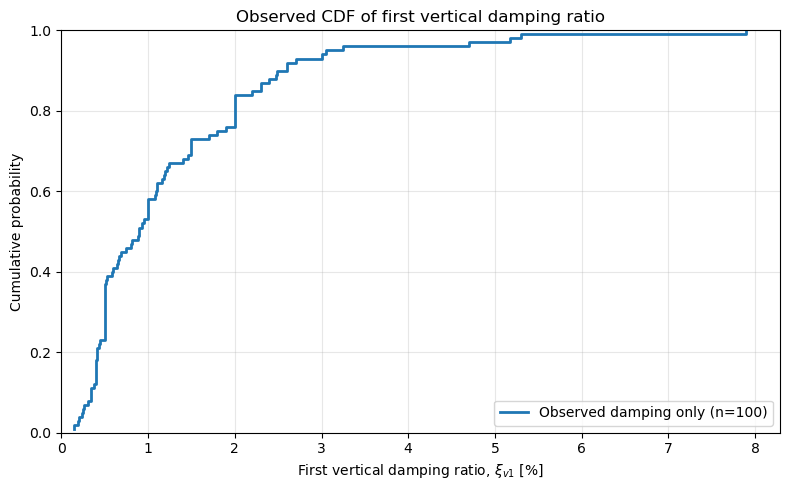

Sampling: [a_material_raw, alpha, beta_log_L, beta_log_f, sigma, sigma_material]



Material categories used in model:
0: Steel | total = 152, observed damping = 51
1: FRP | total = 17, observed damping = 14
2: Steel -concrete composite | total = 24, observed damping = 16
3: Concrete | total = 43, observed damping = 12
4: Timber | total = 7, observed damping = 4
5: Unknown | total = 5, observed damping = 2
6: Aluminium | total = 2, observed damping = 1

Model data prepared.
Observed damping rows: 100
Missing damping rows: 150


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_log_f, beta_log_L, sigma_material, a_material_raw, sigma, log_zeta_missing]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 58 seconds.



Creating Graphviz model diagram...


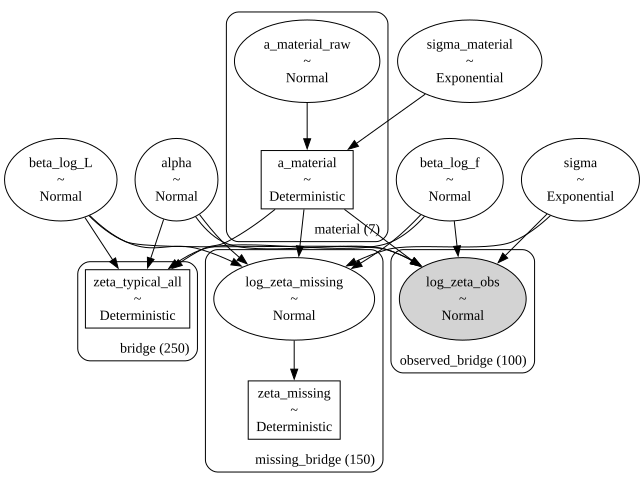


Saved: bayesian_damping_model_graphviz.png

Full model parameter summary:
                                         mean      sd  hdi_3%  hdi_97%  \
alpha                                 -4.5030  0.1146 -4.7117  -4.2774   
beta_log_f                             0.0777  0.1265 -0.1595   0.3142   
beta_log_L                            -0.1157  0.1123 -0.3271   0.0966   
sigma_material                         0.3556  0.1545  0.0959   0.6382   
sigma                                  0.7406  0.0550  0.6385   0.8430   
a_material[Steel]                     -0.4349  0.1554 -0.7252  -0.1429   
a_material[FRP]                        0.2378  0.1858 -0.1061   0.5878   
a_material[Steel -concrete composite] -0.0921  0.1731 -0.4253   0.2315   
a_material[Concrete]                  -0.0896  0.1785 -0.4397   0.2270   
a_material[Timber]                     0.3609  0.2629 -0.1109   0.8512   
a_material[Unknown]                    0.0212  0.2580 -0.4588   0.5218   
a_material[Aluminium]                

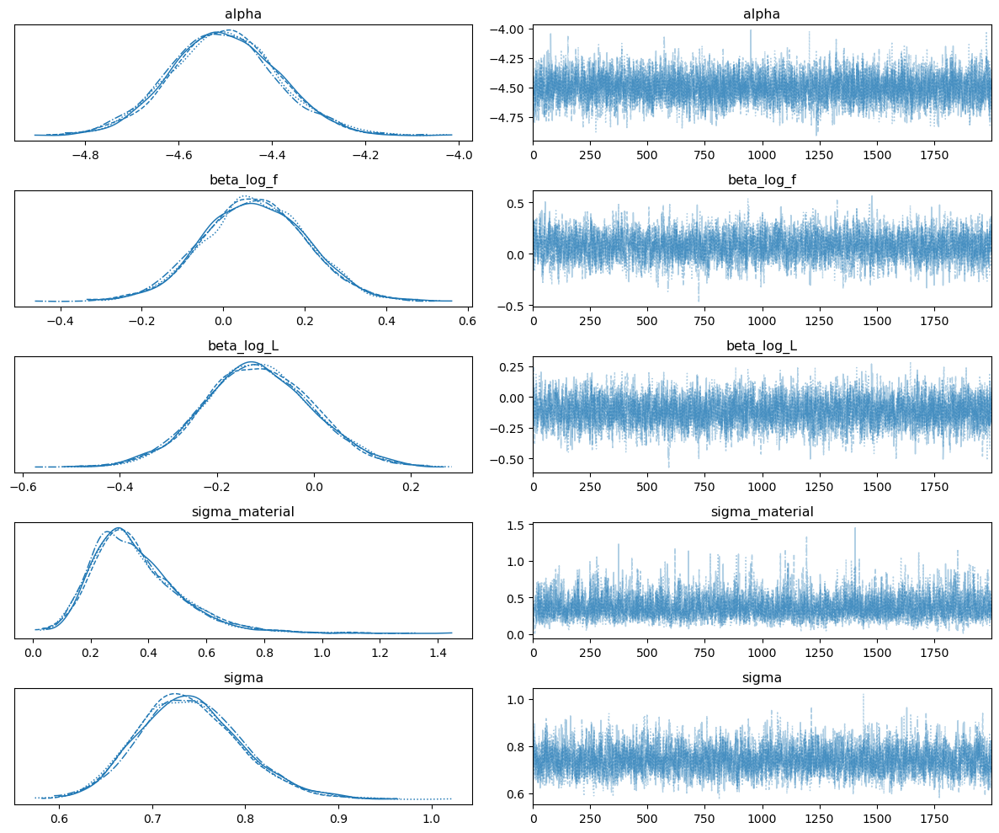

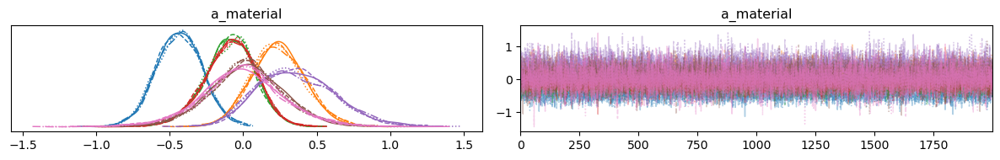

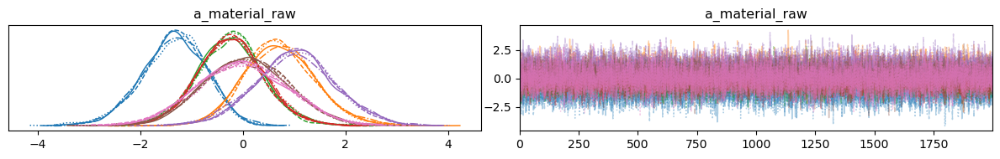

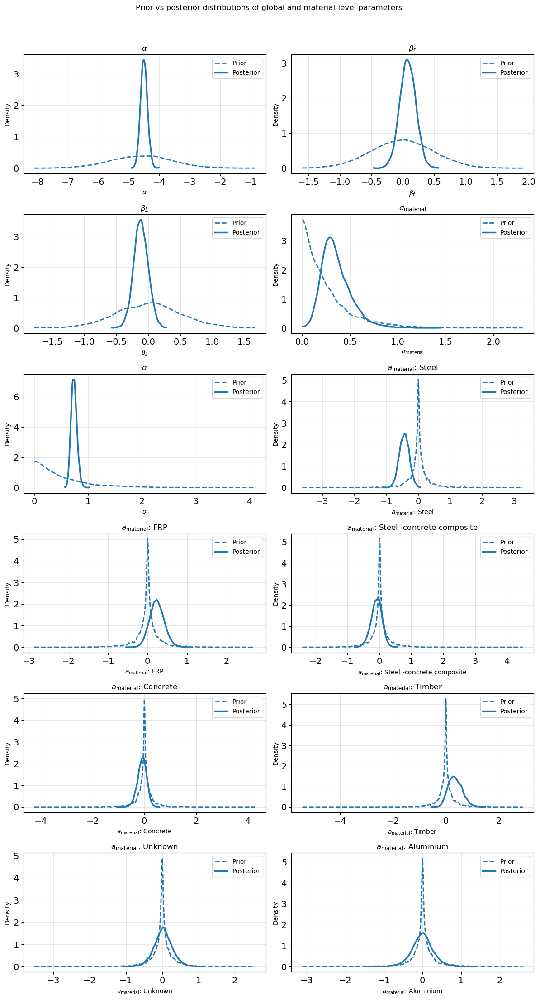


Material effect summary:
                    material  n_total  n_observed_damping  \
0                      Steel      152                  51   
1                        FRP       17                  14   
2  Steel -concrete composite       24                  16   
3                   Concrete       43                  12   
4                     Timber        7                   4   
5                    Unknown        5                   2   
6                  Aluminium        2                   1   

   a_material_median_log_scale  a_material_lower_95_log_scale  \
0                    -0.433957                      -0.739529   
1                     0.232777                      -0.107807   
2                    -0.084345                      -0.456481   
3                    -0.080833                      -0.465363   
4                     0.340663                      -0.095666   
5                     0.020948                      -0.488762   
6                    -0.001494

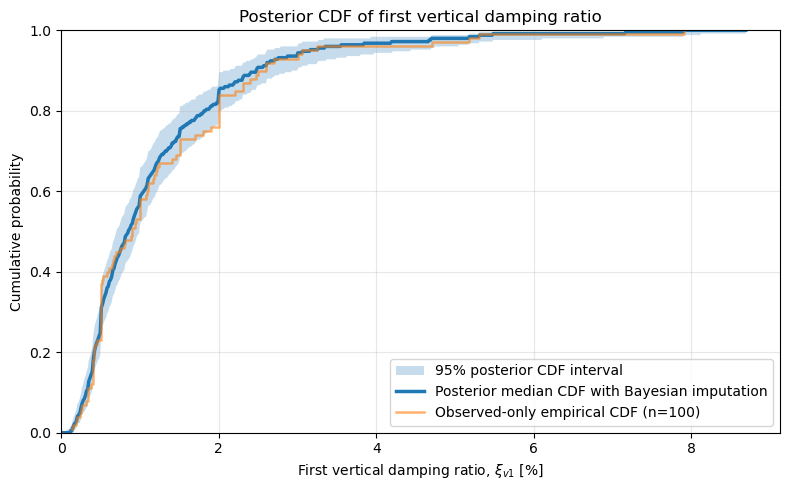

Sampling: [log_zeta_obs]


Output()

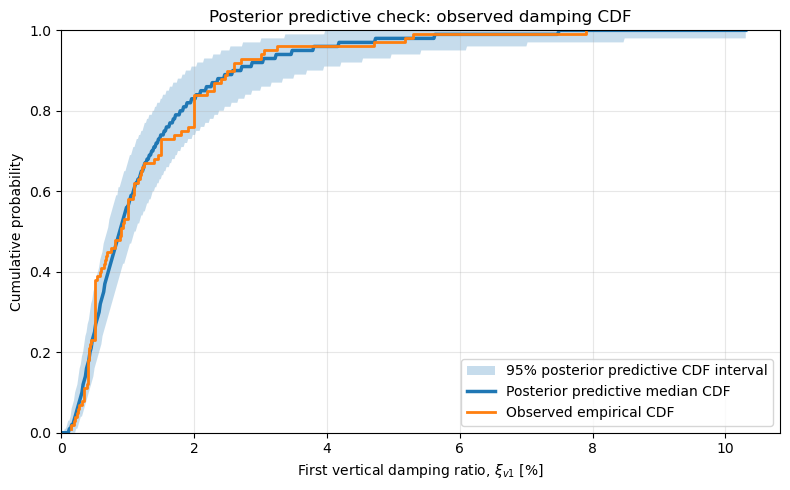


Saved: master_all_bridges_vertical_damping_frequency_span_material.csv


In [140]:
# ==================================================
# BAYESIAN IMPUTATION OF FIRST VERTICAL DAMPING RATIO
# MASTER CSV: GONG + WEI + OLIVEIRA IN ONE FILE
# MODEL: SPAN + FIRST VERTICAL FREQUENCY + MATERIAL
# WITH GRAPHVIZ + FULL TRACEPLOTS + FULL PRIOR VS POSTERIOR
# ==================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import pytensor.tensor as pt

# For Graphviz display in Jupyter
try:
    from IPython.display import display
except ImportError:
    display = None


# ==================================================
# 1. FILE PATH
# ==================================================
data_csv = "data gong wei olivieri.csv"

# Choose material column
# Your CSV has girder_material and deck_material.
# Start with girder_material because it is more structural.
MATERIAL_COL = "girder_material"


# ==================================================
# 2. LOAD MASTER DATA
# ==================================================
master_df = pd.read_csv(data_csv, encoding="utf-8-sig")

print("Columns in master CSV:")
print(master_df.columns.tolist())


# ==================================================
# 3. HELPER FUNCTIONS
# ==================================================
def clean_numeric_column(series):
    """
    Converts values such as blanks, unknown, percentages,
    or text-containing numbers into clean numeric values.
    """
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("–", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def clean_damping_ratio(series):
    """
    Cleans damping ratio.

    Final expected unit:
        0.005 = 0.5%

    Handles:
        0.005       -> 0.005
        0.43        -> 0.0043, treated as 0.43%
        0.3-0.5     -> 0.004, treated as midpoint 0.4%
        #VALUE!     -> NaN
    """
    raw = series.astype(str)
    raw = raw.str.replace("−", "-", regex=False)
    raw = raw.str.replace("–", "-", regex=False)
    raw = raw.str.replace("%", "", regex=False)

    cleaned_values = []

    for item in raw:
        # For damping, negative values are not physical, so extract unsigned numbers
        nums = re.findall(r"\d*\.?\d+(?:[eE][-+]?\d+)?", item)

        if len(nums) == 0:
            cleaned_values.append(np.nan)

        elif len(nums) >= 2 and ("-" in item or "to" in item.lower()):
            vals = [float(nums[0]), float(nums[1])]
            cleaned_values.append(np.mean(vals))

        else:
            cleaned_values.append(float(nums[0]))

    z = pd.Series(cleaned_values, index=series.index, dtype=float)

    # Convert percent-like values to ratio.
    # Example: 0.43 means 0.43%, so convert to 0.0043.
    percent_like = z.notna() & (z > 0.20) & (z <= 20)

    if percent_like.any():
        print(f"\nConverting {percent_like.sum()} damping values from percent to ratio.")
        print("Example: 0.43 becomes 0.0043")
        z.loc[percent_like] = z.loc[percent_like] / 100.0

    # Remove impossible values
    impossible = z.notna() & ((z <= 0) | (z > 0.20))

    if impossible.any():
        print(f"\nSetting {impossible.sum()} impossible damping values to NaN.")
        z.loc[impossible] = np.nan

    return z


def clean_material_column(series):
    """
    Cleans material labels and replaces missing values with 'unknown'.
    """
    s = series.astype(str).str.strip()

    replacements = {
        "": "unknown",
        "nan": "unknown",
        "NaN": "unknown",
        "None": "unknown",
        "none": "unknown",
        "-": "unknown",
    }

    s = s.replace(replacements)
    s = s.fillna("unknown")

    # Optional: make labels more consistent
    s = s.str.replace("steel-concrete", "steel-concrete composite", case=False, regex=False)
    s = s.str.replace("steel concrete", "steel-concrete composite", case=False, regex=False)
    s = s.str.replace("FRP composite", "FRP", case=False, regex=False)
    s = s.str.replace("fibre-glass", "FRP", case=False, regex=False)
    s = s.str.replace("fiber-glass", "FRP", case=False, regex=False)
    s = s.str.replace("GFRP", "FRP", case=False, regex=False)

    return s


# ==================================================
# 4. CLEAN REQUIRED COLUMNS
# ==================================================

# Bridge ID
if "No" in master_df.columns:
    master_df["bridge_id"] = master_df["No"]
else:
    master_df["bridge_id"] = np.arange(1, len(master_df) + 1)

# Required predictors
master_df["span_m"] = clean_numeric_column(master_df["span_m"])

master_df["first_vertical_frequency_Hz"] = clean_numeric_column(
    master_df["vertical_natural_frequency_Hz"]
)

# Target variable
master_df["vertical_damping_ratio"] = clean_damping_ratio(
    master_df["vertical_damping_ratio"]
)

# Material predictor
if MATERIAL_COL not in master_df.columns:
    raise KeyError(f"Material column '{MATERIAL_COL}' not found in CSV.")

master_df["material_used"] = clean_material_column(master_df[MATERIAL_COL])


# ==================================================
# 5. KEEP ROWS WITH REQUIRED PREDICTORS
# ==================================================
# We need span, first vertical frequency, and material.
# Damping is allowed to be missing.
master_df = master_df.dropna(
    subset=["span_m", "first_vertical_frequency_Hz"]
).copy()

master_df = master_df[
    (master_df["span_m"] > 0)
    & (master_df["first_vertical_frequency_Hz"] > 0)
].copy()

master_df = master_df.reset_index(drop=True)

print("\nRows kept for Bayesian model:", len(master_df))

print("\nDamping availability:")
print(
    master_df["vertical_damping_ratio"]
    .notna()
    .value_counts()
    .rename(index={True: "available", False: "missing"})
)

print("\nMaterial counts:")
print(master_df["material_used"].value_counts())

print("\nObserved damping count by material:")
print(
    master_df.groupby("material_used")["vertical_damping_ratio"]
    .apply(lambda x: x.notna().sum())
    .sort_values(ascending=False)
)

print("\nFirst few rows used:")
print(master_df[[
    "bridge_id",
    "span_m",
    "first_vertical_frequency_Hz",
    "vertical_damping_ratio",
    "material_used"
]].head())


# ==================================================
# 6. OBSERVED-ONLY CDF
# ==================================================
observed_zeta = master_df.loc[
    master_df["vertical_damping_ratio"].notna(),
    "vertical_damping_ratio"
].to_numpy()

obs_sorted = np.sort(observed_zeta)
obs_cdf = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)

plt.figure(figsize=(8, 5))

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label=f"Observed damping only (n={len(observed_zeta)})"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Observed CDF of first vertical damping ratio")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# 7. PREPARE BAYESIAN MODEL VARIABLES
# ==================================================
obs_mask = master_df["vertical_damping_ratio"].notna().to_numpy()
miss_mask = ~obs_mask

obs_idx = np.where(obs_mask)[0]
miss_idx = np.where(miss_mask)[0]

# Observed damping on log scale
y_obs = np.log(master_df.loc[obs_idx, "vertical_damping_ratio"].to_numpy())

# Numerical predictors
log_f_raw = np.log(master_df["first_vertical_frequency_Hz"].to_numpy())
log_L_raw = np.log(master_df["span_m"].to_numpy())

# Store scaling values for interpretation later
log_f_mean = log_f_raw.mean()
log_f_std = log_f_raw.std()

log_L_mean = log_L_raw.mean()
log_L_std = log_L_raw.std()

# Standardised predictors
x_log_f = (log_f_raw - log_f_mean) / log_f_std
x_log_L = (log_L_raw - log_L_mean) / log_L_std

# Material coding
material_idx, material_names = pd.factorize(master_df["material_used"])
material_idx = material_idx.astype("int32")
material_names_clean = [str(m) for m in material_names]
n_materials = len(material_names_clean)

print("\nMaterial categories used in model:")
for k, name in enumerate(material_names_clean):
    total_k = np.sum(material_idx == k)
    obs_k = np.sum(obs_mask & (material_idx == k))
    print(f"{k}: {name} | total = {total_k}, observed damping = {obs_k}")

print("\nModel data prepared.")
print("Observed damping rows:", len(obs_idx))
print("Missing damping rows:", len(miss_idx))


# ==================================================
# 8. BAYESIAN IMPUTATION MODEL
# ==================================================

coords = {
    "bridge": np.arange(len(master_df)),
    "observed_bridge": np.arange(len(obs_idx)),
    "missing_bridge": np.arange(len(miss_idx)),
    "material": material_names_clean,
}

with pm.Model(coords=coords) as damping_model:

    # ------------------------------
    # Priors: global parameters
    # ------------------------------

    # Baseline log damping
    alpha = pm.Normal(
        "alpha",
        mu=np.log(0.01),
        sigma=1.0
    )

    # Frequency effect: global slope
    beta_log_f = pm.Normal(
        "beta_log_f",
        mu=0.0,
        sigma=0.5
    )

    # Span effect: global slope
    beta_log_L = pm.Normal(
        "beta_log_L",
        mu=0.0,
        sigma=0.5
    )

    # ------------------------------
    # Hyperparameter: material variation
    # ------------------------------
    # Partial pooling: material effects are pulled toward zero
    sigma_material = pm.Exponential(
        "sigma_material",
        lam=4.0
    )

    # ------------------------------
    # Group-level material effects
    # ------------------------------
    a_material_raw = pm.Normal(
        "a_material_raw",
        mu=0.0,
        sigma=1.0,
        dims="material"
    )

    # Sum-to-zero material effects for better identifiability with alpha
    a_material = pm.Deterministic(
        "a_material",
        sigma_material * (a_material_raw - pt.mean(a_material_raw)),
        dims="material"
    )

    # ------------------------------
    # Global residual scatter
    # ------------------------------
    sigma = pm.Exponential(
        "sigma",
        lam=2.0
    )

    # ------------------------------
    # Linear predictor
    # ------------------------------
    mu_all = (
        alpha
        + beta_log_f * x_log_f
        + beta_log_L * x_log_L
        + a_material[material_idx]
    )

    zeta_typical_all = pm.Deterministic(
        "zeta_typical_all",
        pm.math.exp(mu_all),
        dims="bridge"
    )

    # ------------------------------
    # Likelihood for observed damping
    # ------------------------------
    log_zeta_obs = pm.Normal(
        "log_zeta_obs",
        mu=mu_all[obs_idx],
        sigma=sigma,
        observed=y_obs,
        dims="observed_bridge"
    )

    # ------------------------------
    # Missing damping values as latent variables
    # ------------------------------
    if len(miss_idx) > 0:
        log_zeta_missing = pm.Normal(
            "log_zeta_missing",
            mu=mu_all[miss_idx],
            sigma=sigma,
            dims="missing_bridge"
        )

        zeta_missing = pm.Deterministic(
            "zeta_missing",
            pm.math.exp(log_zeta_missing),
            dims="missing_bridge"
        )

    # ------------------------------
    # Parameter names for plotting/summaries
    # ------------------------------
    global_param_names = [
        "alpha",
        "beta_log_f",
        "beta_log_L",
        "sigma_material",
        "sigma"
    ]

    full_param_names = [
        "alpha",
        "beta_log_f",
        "beta_log_L",
        "sigma_material",
        "sigma",
        "a_material"
    ]

    raw_param_names = [
        "a_material_raw"
    ]

    prior_var_names = full_param_names + raw_param_names

    # ------------------------------
    # Prior predictive samples
    # ------------------------------
    prior = pm.sample_prior_predictive(
        samples=5000,
        var_names=prior_var_names,
        random_seed=42
    )

    # ------------------------------
    # Posterior sampling
    # ------------------------------
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        init="jitter+adapt_diag",
        random_seed=42
    )


# ==================================================
# 8B. GRAPHVIZ MODEL STRUCTURE
# ==================================================
print("\nCreating Graphviz model diagram...")

try:
    graph = pm.model_to_graphviz(damping_model)

    if display is not None:
        display(graph)
    else:
        print(graph)

    graph.render(
        "bayesian_damping_model_graphviz",
        format="png",
        cleanup=True
    )

    print("\nSaved: bayesian_damping_model_graphviz.png")

except Exception as e:
    print("\nGraphviz plot could not be created.")
    print("Error:")
    print(e)
    print("\nIf needed, install Graphviz using one of these:")
    print("conda install -c conda-forge python-graphviz graphviz")
    print("or")
    print("pip install graphviz")


# ==================================================
# 9. DIAGNOSTICS FOR FULL PARAMETER SET
# ==================================================

summary = az.summary(
    trace,
    var_names=full_param_names,
    round_to=4
)

print("\nFull model parameter summary:")
print(summary)

summary.to_csv(
    "full_model_parameter_summary.csv",
    encoding="utf-8-sig"
)

print("\nSaved: full_model_parameter_summary.csv")


# ------------------------------
# Trace plot: global parameters
# ------------------------------
az.plot_trace(
    trace,
    var_names=global_param_names
)

plt.tight_layout()
plt.show()


# ------------------------------
# Trace plot: material effects
# ------------------------------
az.plot_trace(
    trace,
    var_names=["a_material"]
)

plt.tight_layout()
plt.show()


# ------------------------------
# Optional trace plot: raw material effects
# ------------------------------
az.plot_trace(
    trace,
    var_names=["a_material_raw"]
)

plt.tight_layout()
plt.show()


# ==================================================
# 10. PRIOR VS POSTERIOR PARAMETER PLOTS
#     GLOBAL PARAMETERS + EACH MATERIAL EFFECT
# ==================================================

label_map = {
    "alpha": r"$\alpha$",
    "beta_log_f": r"$\beta_f$",
    "beta_log_L": r"$\beta_L$",
    "sigma_material": r"$\sigma_{\mathrm{material}}$",
    "sigma": r"$\sigma$",
}


def get_prior_samples(idata, var_name, material_name=None):
    """
    Extract prior samples.
    If material_name is provided, select one material effect.
    """
    if material_name is None:
        return idata.prior[var_name].values.reshape(-1)
    else:
        return (
            idata.prior[var_name]
            .sel(material=material_name)
            .values
            .reshape(-1)
        )


def get_posterior_samples(idata, var_name, material_name=None):
    """
    Extract posterior samples.
    If material_name is provided, select one material effect.
    """
    if material_name is None:
        return idata.posterior[var_name].values.reshape(-1)
    else:
        return (
            idata.posterior[var_name]
            .sel(material=material_name)
            .values
            .reshape(-1)
        )


# Build plot list:
# first global parameters, then each material effect
plot_specs = []

for var in global_param_names:
    plot_specs.append({
        "var": var,
        "material": None,
        "label": label_map[var]
    })

for mat in material_names_clean:
    plot_specs.append({
        "var": "a_material",
        "material": mat,
        "label": rf"$a_{{\mathrm{{material}}}}$: {mat}"
    })


n_params = len(plot_specs)
n_cols = 2
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 3.6 * n_rows)
)

axes = np.asarray(axes).flatten()

for ax, spec in zip(axes, plot_specs):

    var = spec["var"]
    material = spec["material"]
    label = spec["label"]

    prior_samples = get_prior_samples(
        prior,
        var,
        material_name=material
    )

    posterior_samples = get_posterior_samples(
        trace,
        var,
        material_name=material
    )

    az.plot_kde(
        prior_samples,
        ax=ax,
        label="Prior",
        plot_kwargs={"linewidth": 2, "linestyle": "--"}
    )

    az.plot_kde(
        posterior_samples,
        ax=ax,
        label="Posterior",
        plot_kwargs={"linewidth": 2.5}
    )

    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[n_params:]:
    fig.delaxes(ax)

plt.suptitle(
    "Prior vs posterior distributions of global and material-level parameters",
    y=1.02
)

plt.tight_layout()
plt.show()


# ==================================================
# 11. MATERIAL EFFECT SUMMARY
# ==================================================
a_material_samples = (
    trace.posterior["a_material"]
    .stack(sample=("chain", "draw"))
    .transpose("material", "sample")
    .values
)

material_summary = pd.DataFrame({
    "material": material_names_clean,
    "n_total": [np.sum(material_idx == k) for k in range(n_materials)],
    "n_observed_damping": [
        np.sum(obs_mask & (material_idx == k)) for k in range(n_materials)
    ],
    "a_material_median_log_scale": np.percentile(a_material_samples, 50, axis=1),
    "a_material_lower_95_log_scale": np.percentile(a_material_samples, 2.5, axis=1),
    "a_material_upper_95_log_scale": np.percentile(a_material_samples, 97.5, axis=1),
})

# Convert log-scale material effect to damping multiplier
material_summary["damping_multiplier_median"] = np.exp(
    material_summary["a_material_median_log_scale"]
)
material_summary["damping_multiplier_lower_95"] = np.exp(
    material_summary["a_material_lower_95_log_scale"]
)
material_summary["damping_multiplier_upper_95"] = np.exp(
    material_summary["a_material_upper_95_log_scale"]
)

print("\nMaterial effect summary:")
print(material_summary)

material_summary.to_csv(
    "material_effect_summary_vertical_damping.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved: material_effect_summary_vertical_damping.csv")


# ==================================================
# 12. EXTRACT IMPUTED DAMPING VALUES
#     Now includes mean and standard deviation
# ==================================================
if len(miss_idx) > 0:

    missing_samples = (
        trace.posterior["zeta_missing"]
        .stack(sample=("chain", "draw"))
        .transpose("missing_bridge", "sample")
        .values
    )

    imputed_summary = master_df.loc[miss_idx, [
        "bridge_id",
        "span_m",
        "first_vertical_frequency_Hz",
        "material_used"
    ]].copy()

    # ------------------------------
    # Posterior summaries: ratio form
    # ------------------------------
    imputed_summary["zeta_imputed_mean"] = np.mean(
        missing_samples, axis=1
    )

    imputed_summary["zeta_imputed_sd"] = np.std(
        missing_samples, axis=1, ddof=1
    )

    imputed_summary["zeta_imputed_median"] = np.percentile(
        missing_samples, 50, axis=1
    )

    imputed_summary["zeta_imputed_lower_95"] = np.percentile(
        missing_samples, 2.5, axis=1
    )

    imputed_summary["zeta_imputed_upper_95"] = np.percentile(
        missing_samples, 97.5, axis=1
    )

    # ------------------------------
    # Posterior summaries: percent form
    # ------------------------------
    imputed_summary["zeta_imputed_mean_percent"] = (
        imputed_summary["zeta_imputed_mean"] * 100
    )

    imputed_summary["zeta_imputed_sd_percent"] = (
        imputed_summary["zeta_imputed_sd"] * 100
    )

    imputed_summary["zeta_imputed_median_percent"] = (
        imputed_summary["zeta_imputed_median"] * 100
    )

    imputed_summary["zeta_imputed_lower_95_percent"] = (
        imputed_summary["zeta_imputed_lower_95"] * 100
    )

    imputed_summary["zeta_imputed_upper_95_percent"] = (
        imputed_summary["zeta_imputed_upper_95"] * 100
    )

    print("\nFirst few imputed damping summaries:")
    print(imputed_summary.head())

    imputed_summary.to_csv(
        "bayesian_imputed_missing_vertical_damping_frequency_span_material.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("\nSaved: bayesian_imputed_missing_vertical_damping_frequency_span_material.csv")

else:
    missing_samples = np.empty((0, 0))
    print("\nNo missing damping values to impute.")

# ==================================================
# 13. POSTERIOR CDF INCLUDING IMPUTED VALUES
# ==================================================
if len(miss_idx) > 0:

    n_draws = missing_samples.shape[1]

    all_values_for_grid = np.concatenate([
        observed_zeta,
        missing_samples.ravel()
    ])

    x_max = np.percentile(all_values_for_grid, 99.5) * 1.20
    x_max = max(x_max, observed_zeta.max() * 1.10)

    x_grid = np.linspace(0, x_max, 600)

    cdf_samples = np.zeros((n_draws, len(x_grid)))

    for j in range(n_draws):

        full_zeta_j = np.concatenate([
            observed_zeta,
            missing_samples[:, j]
        ])

        cdf_samples[j, :] = np.mean(
            full_zeta_j[:, None] <= x_grid[None, :],
            axis=0
        )

    cdf_median = np.percentile(cdf_samples, 50, axis=0)
    cdf_lower = np.percentile(cdf_samples, 2.5, axis=0)
    cdf_upper = np.percentile(cdf_samples, 97.5, axis=0)

    plt.figure(figsize=(8, 5))

    plt.fill_between(
        x_grid * 100,
        cdf_lower,
        cdf_upper,
        alpha=0.25,
        label="95% posterior CDF interval"
    )

    plt.plot(
        x_grid * 100,
        cdf_median,
        linewidth=2.5,
        label="Posterior median CDF with Bayesian imputation"
    )

    plt.step(
        obs_sorted * 100,
        obs_cdf,
        where="post",
        linewidth=1.8,
        alpha=0.6,
        label=f"Observed-only empirical CDF (n={len(observed_zeta)})"
    )

    plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
    plt.ylabel("Cumulative probability")
    plt.title("Posterior CDF of first vertical damping ratio")
    plt.xlim(left=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==================================================
# 14. POSTERIOR PREDICTIVE CHECK
# ==================================================
with damping_model:
    ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["log_zeta_obs"],
        random_seed=42
    )

ppc_log = (
    ppc.posterior_predictive["log_zeta_obs"]
    .stack(sample=("chain", "draw"))
    .transpose("observed_bridge", "sample")
    .values
)

ppc_zeta = np.exp(ppc_log)

n_ppc_draws = ppc_zeta.shape[1]

x_grid_ppc = np.linspace(
    0,
    np.percentile(np.concatenate([observed_zeta, ppc_zeta.ravel()]), 99.5) * 1.2,
    600
)

ppc_cdf_samples = np.zeros((n_ppc_draws, len(x_grid_ppc)))

for j in range(n_ppc_draws):
    ppc_cdf_samples[j, :] = np.mean(
        ppc_zeta[:, j][:, None] <= x_grid_ppc[None, :],
        axis=0
    )

ppc_cdf_median = np.percentile(ppc_cdf_samples, 50, axis=0)
ppc_cdf_lower = np.percentile(ppc_cdf_samples, 2.5, axis=0)
ppc_cdf_upper = np.percentile(ppc_cdf_samples, 97.5, axis=0)

plt.figure(figsize=(8, 5))

plt.fill_between(
    x_grid_ppc * 100,
    ppc_cdf_lower,
    ppc_cdf_upper,
    alpha=0.25,
    label="95% posterior predictive CDF interval"
)

plt.plot(
    x_grid_ppc * 100,
    ppc_cdf_median,
    linewidth=2.5,
    label="Posterior predictive median CDF"
)

plt.step(
    obs_sorted * 100,
    obs_cdf,
    where="post",
    linewidth=2,
    label="Observed empirical CDF"
)

plt.xlabel(r"First vertical damping ratio, $\xi_{v1}$ [%]")
plt.ylabel("Cumulative probability")
plt.title("Posterior predictive check: observed damping CDF")
plt.xlim(left=0)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ==================================================
# 15. SAVE MASTER DATA WITH OBSERVED/IMPUTED STATUS
#     Now includes mean and SD of imputed damping
# ==================================================

master_out = master_df.copy()

master_out["damping_observed"] = master_out["vertical_damping_ratio"].notna()

# This is the final single-value damping column for simple plug-in calculations:
# observed damping where available, imputed mean where missing.
master_out["zeta_completed_mean"] = master_out["vertical_damping_ratio"]

# This is another completed column using posterior median.
master_out["zeta_completed_median"] = master_out["vertical_damping_ratio"]

if len(miss_idx) > 0:

    master_out.loc[miss_idx, "zeta_imputed_mean"] = (
        imputed_summary["zeta_imputed_mean"].values
    )

    master_out.loc[miss_idx, "zeta_imputed_sd"] = (
        imputed_summary["zeta_imputed_sd"].values
    )

    master_out.loc[miss_idx, "zeta_imputed_median"] = (
        imputed_summary["zeta_imputed_median"].values
    )

    master_out.loc[miss_idx, "zeta_imputed_lower_95"] = (
        imputed_summary["zeta_imputed_lower_95"].values
    )

    master_out.loc[miss_idx, "zeta_imputed_upper_95"] = (
        imputed_summary["zeta_imputed_upper_95"].values
    )

    # Percent versions
    master_out.loc[miss_idx, "zeta_imputed_mean_percent"] = (
        imputed_summary["zeta_imputed_mean_percent"].values
    )

    master_out.loc[miss_idx, "zeta_imputed_sd_percent"] = (
        imputed_summary["zeta_imputed_sd_percent"].values
    )

    master_out.loc[miss_idx, "zeta_imputed_median_percent"] = (
        imputed_summary["zeta_imputed_median_percent"].values
    )

    master_out.loc[miss_idx, "zeta_imputed_lower_95_percent"] = (
        imputed_summary["zeta_imputed_lower_95_percent"].values
    )

    master_out.loc[miss_idx, "zeta_imputed_upper_95_percent"] = (
        imputed_summary["zeta_imputed_upper_95_percent"].values
    )

    # Completed damping columns
    master_out.loc[miss_idx, "zeta_completed_mean"] = (
        imputed_summary["zeta_imputed_mean"].values
    )

    master_out.loc[miss_idx, "zeta_completed_median"] = (
        imputed_summary["zeta_imputed_median"].values
    )

master_out["zeta_completed_mean_percent"] = (
    master_out["zeta_completed_mean"] * 100
)

master_out["zeta_completed_median_percent"] = (
    master_out["zeta_completed_median"] * 100
)

master_out.to_csv(
    "master_all_bridges_vertical_damping_frequency_span_material.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved: master_all_bridges_vertical_damping_frequency_span_material.csv")

Population damping file
Rows used = 250
material_group_clean
Steel                       152
Concrete                     43
Steel-concrete composite     24
FRP                          17
Timber                        7
Other                         7
Name: count, dtype: int64

Mass-ratio file
Rows used = 25
material_group_clean
Steel                        8
Concrete                     5
Steel-concrete composite     2
FRP                         10
Timber                       0
Other                        0
Name: count, dtype: int64

Mass-ratio threshold counts:
                material  n_mu_known  k_mu_below
                   Steel           8           6
                Concrete           5           5
Steel-concrete composite           2           1
                     FRP          10           0
                  Timber           0           0
                   Other           0           0

Material-level summary
                material  N_population  n_mu_known  k_mu_be

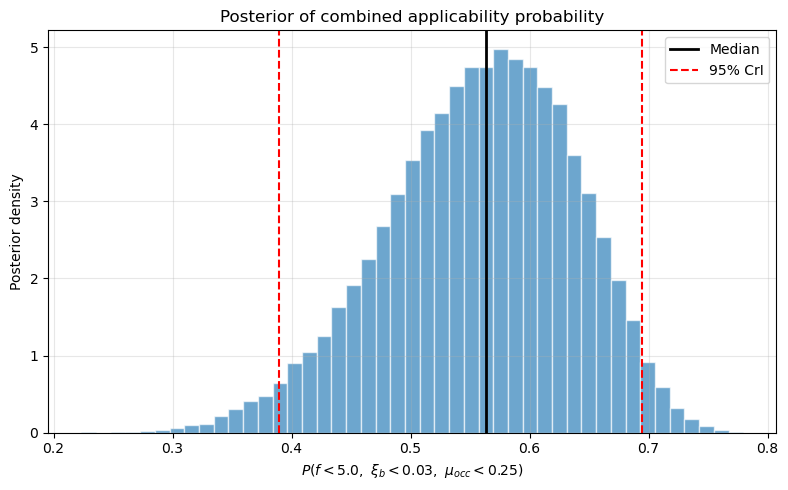

In [141]:
# ==================================================
# COMBINED PROBABILITY WITH IMPUTED DAMPING UNCERTAINTY
#
# A = f < 5 Hz
# B = xi_b < 3%
# C = mu_occ < 0.25
#
# Uses:
#   master_all_bridges_vertical_damping_frequency_span_material.csv
#   Data Bridges and mass ratios.csv
#
# Model:
# P(A,B,C) ≈ sum_m P(M=m) P(A,B | M=m) P(C | M=m)
# with assumption:
# P(C | A,B,M=m) ≈ P(C | M=m)
# ==================================================

import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# FILE PATHS
# --------------------------------------------------

DAMPING_CSV = "master_all_bridges_vertical_damping_frequency_span_material.csv"
MU_CSV = "Data Bridges and mass ratios.csv"

# --------------------------------------------------
# THRESHOLDS
# --------------------------------------------------

F_LIMIT = 5.0
XI_LIMIT = 0.03
MU_LIMIT = 0.25

# --------------------------------------------------
# MONTE CARLO SETTINGS
# --------------------------------------------------

N_SAMPLES = 50000
RANDOM_SEED = 42

# Whether to sample material proportions from Dirichlet posterior
# True  = Bayesian material-weight uncertainty
# False = fixed material proportions from 250-bridge table
USE_DIRICHLET_MATERIAL_WEIGHTS = True

MATERIAL_ORDER = [
    "Steel",
    "Concrete",
    "Steel-concrete composite",
    "FRP",
    "Timber",
    "Other",
]

rng = np.random.default_rng(RANDOM_SEED)


# ==================================================
# HELPER FUNCTIONS
# ==================================================

def clean_numeric_column(series):
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("–", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def clean_damping_ratio(series):
    raw = series.astype(str)
    raw = raw.str.replace("−", "-", regex=False)
    raw = raw.str.replace("–", "-", regex=False)
    raw = raw.str.replace("%", "", regex=False)

    values = []

    for item in raw:
        nums = re.findall(r"\d*\.?\d+(?:[eE][-+]?\d+)?", item)

        if len(nums) == 0:
            values.append(np.nan)

        elif len(nums) >= 2 and ("-" in item or "to" in item.lower()):
            values.append(np.mean([float(nums[0]), float(nums[1])]))

        else:
            values.append(float(nums[0]))

    z = pd.Series(values, index=series.index, dtype=float)

    # Convert percent-like values to ratio.
    # Example: 0.43 means 0.43%, so becomes 0.0043.
    percent_like = z.notna() & (z > 0.20) & (z <= 20)
    z.loc[percent_like] = z.loc[percent_like] / 100.0

    impossible = z.notna() & ((z <= 0) | (z > 0.20))
    z.loc[impossible] = np.nan

    return z


def clean_material_group(x):
    s = str(x).strip().lower()

    if s in ["", "nan", "none", "-", "unknown", "other", "other types"]:
        return "Other"

    if (
        "frp" in s
        or "gfrp" in s
        or "fiber" in s
        or "fibre" in s
        or "fiberglass" in s
        or "fibreglass" in s
        or "glass fibre" in s
        or "glass fiber" in s
    ):
        return "FRP"

    if "timber" in s or "wood" in s or "wooden" in s:
        return "Timber"

    if (
        ("steel" in s and "concrete" in s)
        or "steel-concrete" in s
        or "steel concrete" in s
        or "composite" in s
        or "mixed steel" in s
    ):
        return "Steel-concrete composite"

    if "concrete" in s or "reinforced concrete" in s or s == "rc":
        return "Concrete"

    if (
        "steel" in s
        or "warren" in s
        or "bow-string" in s
        or "suspended" in s
    ):
        return "Steel"

    return "Other"


def sample_lognormal_from_mean_sd(mean, sd, size, rng):
    """
    Samples positive values from a lognormal distribution whose raw-scale
    mean and SD approximately match the saved imputation summaries.
    """
    mean = float(mean)
    sd = float(sd)

    if not np.isfinite(mean) or mean <= 0:
        return np.full(size, np.nan)

    if not np.isfinite(sd) or sd <= 0:
        return np.full(size, mean)

    sigma2_log = np.log(1.0 + (sd / mean) ** 2)
    sigma_log = np.sqrt(sigma2_log)
    mu_log = np.log(mean) - 0.5 * sigma2_log

    return rng.lognormal(mean=mu_log, sigma=sigma_log, size=size)


# ==================================================
# 1. CHECK FILES
# ==================================================

if not os.path.exists(DAMPING_CSV):
    raise FileNotFoundError(
        f"Cannot find {DAMPING_CSV}. "
        "Run the damping-imputation notebook first, or place this CSV in the current folder."
    )

if not os.path.exists(MU_CSV):
    raise FileNotFoundError(
        f"Cannot find {MU_CSV}. "
        "Place the mass-ratio CSV in the current folder."
    )


# ==================================================
# 2. LOAD DAMPING POPULATION FILE
# ==================================================

pop_df = pd.read_csv(DAMPING_CSV, encoding="utf-8-sig")
pop_df = pop_df.dropna(how="all").copy()

# Frequency column
if "first_vertical_frequency_Hz" in pop_df.columns:
    pop_df["frequency"] = clean_numeric_column(pop_df["first_vertical_frequency_Hz"])
elif "vertical_natural_frequency_Hz" in pop_df.columns:
    pop_df["frequency"] = clean_numeric_column(pop_df["vertical_natural_frequency_Hz"])
else:
    raise KeyError("No frequency column found.")

# Material column
if "material_group" in pop_df.columns:
    pop_df["material_group_clean"] = pop_df["material_group"].apply(clean_material_group)
elif "material_used" in pop_df.columns:
    pop_df["material_group_clean"] = pop_df["material_used"].apply(clean_material_group)
elif "girder_material" in pop_df.columns:
    pop_df["material_group_clean"] = pop_df["girder_material"].apply(clean_material_group)
else:
    raise KeyError("No material column found.")

# Observed damping column
if "vertical_damping_ratio" in pop_df.columns:
    pop_df["observed_damping"] = clean_damping_ratio(pop_df["vertical_damping_ratio"])
else:
    pop_df["observed_damping"] = np.nan

# Observed/imputed flag
if "damping_observed" in pop_df.columns:
    pop_df["damping_observed_bool"] = (
        pop_df["damping_observed"].astype(str).str.lower().isin(["true", "1", "yes"])
    )
else:
    pop_df["damping_observed_bool"] = pop_df["observed_damping"].notna()

# Imputed mean and SD
if "zeta_imputed_mean" in pop_df.columns:
    pop_df["imputed_mean"] = clean_numeric_column(pop_df["zeta_imputed_mean"])
elif "zeta_imputed_median" in pop_df.columns:
    pop_df["imputed_mean"] = clean_numeric_column(pop_df["zeta_imputed_median"])
else:
    pop_df["imputed_mean"] = np.nan

if "zeta_imputed_sd" in pop_df.columns:
    pop_df["imputed_sd"] = clean_numeric_column(pop_df["zeta_imputed_sd"])
else:
    pop_df["imputed_sd"] = 0.0

# Keep usable rows
pop_df = pop_df.dropna(subset=["frequency", "material_group_clean"]).copy()
pop_df = pop_df[pop_df["material_group_clean"].isin(MATERIAL_ORDER)].copy()
pop_df = pop_df.reset_index(drop=True)

n_pop = len(pop_df)

print("==========================================")
print("Population damping file")
print("==========================================")
print(f"Rows used = {n_pop}")
print(pop_df["material_group_clean"].value_counts().reindex(MATERIAL_ORDER, fill_value=0))


# ==================================================
# 3. BUILD DAMPING SAMPLES
# ==================================================

xi_samples = np.zeros((N_SAMPLES, n_pop))

for i, row in pop_df.iterrows():

    if row["damping_observed_bool"] and np.isfinite(row["observed_damping"]):
        # Observed damping stays deterministic
        xi_samples[:, i] = row["observed_damping"]

    else:
        # Missing damping stays probabilistic
        xi_samples[:, i] = sample_lognormal_from_mean_sd(
            mean=row["imputed_mean"],
            sd=row["imputed_sd"],
            size=N_SAMPLES,
            rng=rng
        )

# Check for missing sampled damping
bad_cols = np.isnan(xi_samples).any(axis=0)

if bad_cols.any():
    bad_rows = pop_df.loc[bad_cols, [
        "frequency", "material_group_clean",
        "observed_damping", "imputed_mean", "imputed_sd"
    ]]
    raise ValueError(
        "Some bridges have neither observed damping nor usable imputed mean/SD:\n"
        + bad_rows.to_string()
    )


# ==================================================
# 4. LOAD MASS-RATIO DATA
# ==================================================

mu_df = pd.read_csv(MU_CSV, encoding="utf-8-sig")
mu_df = mu_df.dropna(how="all").copy()

mu_df["material_group_clean"] = mu_df["Material / type"].apply(clean_material_group)
mu_df["mu_occ"] = clean_numeric_column(mu_df["Occupancy mass ratio"])

mu_df = mu_df.dropna(subset=["mu_occ", "material_group_clean"]).copy()
mu_df = mu_df[mu_df["material_group_clean"].isin(MATERIAL_ORDER)].copy()

print("\n==========================================")
print("Mass-ratio file")
print("==========================================")
print(f"Rows used = {len(mu_df)}")
print(mu_df["material_group_clean"].value_counts().reindex(MATERIAL_ORDER, fill_value=0))


# ==================================================
# 5. MATERIAL-WISE COUNTS FOR MASS-RATIO POSTERIOR
# ==================================================

mu_count_rows = []

for mat in MATERIAL_ORDER:
    vals = mu_df.loc[mu_df["material_group_clean"] == mat, "mu_occ"].to_numpy()

    n_m = len(vals)
    k_m = int(np.sum(vals < MU_LIMIT))

    mu_count_rows.append({
        "material": mat,
        "n_mu_known": n_m,
        "k_mu_below": k_m,
    })

mu_count_df = pd.DataFrame(mu_count_rows)

print("\nMass-ratio threshold counts:")
print(mu_count_df.to_string(index=False))


# ==================================================
# 6. COMBINED PROBABILITY POSTERIOR
# ==================================================

A_fixed = pop_df["frequency"].to_numpy() < F_LIMIT
materials_pop = pop_df["material_group_clean"].to_numpy()

joint_samples = np.zeros(N_SAMPLES)

material_summary_rows = []

# Optional: sample material weights
N_material = (
    pop_df["material_group_clean"]
    .value_counts()
    .reindex(MATERIAL_ORDER, fill_value=0)
    .to_numpy()
)

if USE_DIRICHLET_MATERIAL_WEIGHTS:
    w_material_samples = rng.dirichlet(
        alpha=1 + N_material,
        size=N_SAMPLES
    )
else:
    w_fixed = N_material / N_material.sum()
    w_material_samples = np.repeat(
        w_fixed[None, :],
        N_SAMPLES,
        axis=0
    )

for mat_i, mat in enumerate(MATERIAL_ORDER):

    idx_m = np.where(materials_pop == mat)[0]

    if len(idx_m) == 0:
        continue

    # P(A,B | M=m), sample by sample
    B_samples_m = xi_samples[:, idx_m] < XI_LIMIT
    A_m = A_fixed[idx_m]

    AB_given_M_samples = np.mean(
        B_samples_m * A_m[None, :],
        axis=1
    )

    # P(C | M=m), sample by sample
    row = mu_count_df[mu_count_df["material"] == mat].iloc[0]
    n_mu = int(row["n_mu_known"])
    k_mu = int(row["k_mu_below"])

    theta_C_given_M_samples = rng.beta(
        1 + k_mu,
        1 + n_mu - k_mu,
        size=N_SAMPLES
    )

    # Contribution
    contribution_samples = (
        w_material_samples[:, mat_i]
        * AB_given_M_samples
        * theta_C_given_M_samples
    )

    joint_samples += contribution_samples

    material_summary_rows.append({
        "material": mat,
        "N_population": len(idx_m),
        "n_mu_known": n_mu,
        "k_mu_below": k_mu,

        "P_M_median": np.percentile(w_material_samples[:, mat_i], 50),
        "P_M_q025": np.percentile(w_material_samples[:, mat_i], 2.5),
        "P_M_q975": np.percentile(w_material_samples[:, mat_i], 97.5),

        "P_AB_given_M_median": np.percentile(AB_given_M_samples, 50),
        "P_AB_given_M_q025": np.percentile(AB_given_M_samples, 2.5),
        "P_AB_given_M_q975": np.percentile(AB_given_M_samples, 97.5),

        "P_C_given_M_median": np.percentile(theta_C_given_M_samples, 50),
        "P_C_given_M_q025": np.percentile(theta_C_given_M_samples, 2.5),
        "P_C_given_M_q975": np.percentile(theta_C_given_M_samples, 97.5),

        "contribution_median": np.percentile(contribution_samples, 50),
        "contribution_q025": np.percentile(contribution_samples, 2.5),
        "contribution_q975": np.percentile(contribution_samples, 97.5),
    })

material_summary_df = pd.DataFrame(material_summary_rows)


# ==================================================
# 7. SUMMARY
# ==================================================

q025, q50, q975 = np.percentile(joint_samples, [2.5, 50, 97.5])
q05, q95 = np.percentile(joint_samples, [5, 95])
mean_val = np.mean(joint_samples)
sd_val = np.std(joint_samples, ddof=1)

print("\n==========================================")
print("Material-level summary")
print("==========================================")
print(material_summary_df.to_string(index=False))

print("\n==========================================")
print("Combined probability")
print("==========================================")
print(
    rf"P(f < {F_LIMIT}, xi_b < {XI_LIMIT}, mu_occ < {MU_LIMIT})"
)
print(f"Mean   = {mean_val:.4f} = {100*mean_val:.1f}%")
print(f"SD     = {sd_val:.4f} = {100*sd_val:.1f}%")
print(f"Median = {q50:.4f} = {100*q50:.1f}%")
print(f"90% CrI = [{q05:.4f}, {q95:.4f}]")
print(f"95% CrI = [{q025:.4f}, {q975:.4f}]")
print(f"95% CrI [%] = [{100*q025:.1f}%, {100*q975:.1f}%]")


# ==================================================
# 8. SAVE RESULTS
# ==================================================

material_summary_df.to_csv(
    "combined_probability_material_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

joint_samples_df = pd.DataFrame({
    "joint_probability_sample": joint_samples
})

joint_samples_df.to_csv(
    "combined_probability_posterior_samples.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print("combined_probability_material_summary.csv")
print("combined_probability_posterior_samples.csv")


# ==================================================
# 9. PLOT POSTERIOR
# ==================================================

plt.figure(figsize=(8, 5))

plt.hist(
    joint_samples,
    bins=45,
    density=True,
    alpha=0.65,
    edgecolor="white"
)

plt.axvline(q50, color="black", linewidth=2, label="Median")
plt.axvline(q025, color="red", linestyle="--", linewidth=1.5, label="95% CrI")
plt.axvline(q975, color="red", linestyle="--", linewidth=1.5)

plt.xlabel(
    rf"$P(f<{F_LIMIT},\ \xi_b<{XI_LIMIT},\ \mu_{{occ}}<{MU_LIMIT})$"
)
plt.ylabel("Posterior density")
plt.title("Posterior of combined applicability probability")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Population damping file
EXCLUDED_MATERIALS = ['FRP', 'Timber', 'Other']
Rows used = 219
material_group_clean
Steel                       152
Concrete                     43
Steel-concrete composite     24
Name: count, dtype: int64

Mass-ratio file
EXCLUDED_MATERIALS = ['FRP', 'Timber', 'Other']
Rows used = 15
material_group_clean
Steel                       8
Concrete                    5
Steel-concrete composite    2
Name: count, dtype: int64

Mass-ratio threshold counts:
                material  n_mu_known  k_mu_below
                   Steel           8           7
                Concrete           5           5
Steel-concrete composite           2           2

Material-level summary
                material  N_population  n_mu_known  k_mu_below  P_M_median  P_M_q025  P_M_q975  P_AB_given_M_median  P_AB_given_M_q025  P_AB_given_M_q975  P_C_given_M_median  P_C_given_M_q025  P_C_given_M_q975  contribution_median  contribution_q025  contribution_q975
                   Steel         

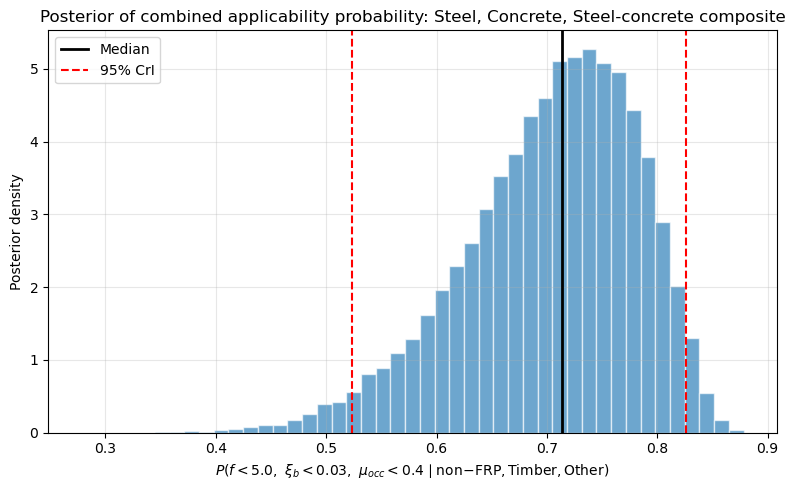

In [145]:
# ==================================================
# COMBINED PROBABILITY WITH OPTIONAL FRP EXCLUSION
#
# A = f < 5 Hz
# B = xi_b < 3%
# C = mu_occ < 0.25
#
# If EXCLUDE_FRP = True:
#   Calculates P(A,B,C | non-FRP)
#
# Uses:
#   1. master_all_bridges_vertical_damping_frequency_span_material.csv
#   2. Data Bridges and mass ratios.csv
#
# Model:
#   P(A,B,C) ≈ sum_m P(M=m) P(A,B | M=m) P(C | M=m)
#
# Assumption:
#   P(C | A,B,M=m) ≈ P(C | M=m)
#
# Damping treatment:
#   observed damping  = deterministic
#   imputed damping   = probabilistic using saved mean and SD
# ==================================================

import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==================================================
# SETTINGS
# ==================================================

DAMPING_CSV = "master_all_bridges_vertical_damping_frequency_span_material.csv"
MU_CSV = "Data Bridges and mass ratios.csv"

F_LIMIT = 5.0
XI_LIMIT = 0.03
MU_LIMIT = 0.4

N_SAMPLES = 50000
RANDOM_SEED = 42

# ==================================================
# MATERIAL EXCLUSION SETTINGS
# ==================================================

EXCLUDED_MATERIALS = ["FRP", "Timber", "Other"]

USE_DIRICHLET_MATERIAL_WEIGHTS = True

ALL_MATERIALS = [
    "Steel",
    "Concrete",
    "Steel-concrete composite",
    "FRP",
    "Timber",
    "Other",
]

MATERIAL_ORDER = [
    m for m in ALL_MATERIALS
    if m not in EXCLUDED_MATERIALS
]

rng = np.random.default_rng(RANDOM_SEED)


# ==================================================
# HELPER FUNCTIONS
# ==================================================

def clean_numeric_column(series):
    s = series.astype(str)
    s = s.str.replace("−", "-", regex=False)
    s = s.str.replace("–", "-", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    s = s.str.extract(r"([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")[0]
    return pd.to_numeric(s, errors="coerce")


def clean_damping_ratio(series):
    raw = series.astype(str)
    raw = raw.str.replace("−", "-", regex=False)
    raw = raw.str.replace("–", "-", regex=False)
    raw = raw.str.replace("%", "", regex=False)

    values = []

    for item in raw:
        nums = re.findall(r"\d*\.?\d+(?:[eE][-+]?\d+)?", item)

        if len(nums) == 0:
            values.append(np.nan)

        elif len(nums) >= 2 and ("-" in item or "to" in item.lower()):
            values.append(np.mean([float(nums[0]), float(nums[1])]))

        else:
            values.append(float(nums[0]))

    z = pd.Series(values, index=series.index, dtype=float)

    # Convert percent-like values to ratio.
    # Example: 0.43 means 0.43%, so convert to 0.0043.
    percent_like = z.notna() & (z > 0.20) & (z <= 20)
    z.loc[percent_like] = z.loc[percent_like] / 100.0

    impossible = z.notna() & ((z <= 0) | (z > 0.20))
    z.loc[impossible] = np.nan

    return z


def clean_material_group(x):
    s = str(x).strip().lower()

    if s in ["", "nan", "none", "-", "unknown", "other", "other types"]:
        return "Other"

    # FRP
    if (
        "frp" in s
        or "gfrp" in s
        or "fiber" in s
        or "fibre" in s
        or "fiberglass" in s
        or "fibreglass" in s
        or "glass fibre" in s
        or "glass fiber" in s
    ):
        return "FRP"

    # Timber
    if "timber" in s or "wood" in s or "wooden" in s:
        return "Timber"

    # Steel-concrete composite
    if (
        ("steel" in s and "concrete" in s)
        or "steel-concrete" in s
        or "steel concrete" in s
        or "composite" in s
        or "mixed steel" in s
    ):
        return "Steel-concrete composite"

    # Concrete
    if "concrete" in s or "reinforced concrete" in s or s == "rc":
        return "Concrete"

    # Steel
    if (
        "steel" in s
        or "warren" in s
        or "bow-string" in s
        or "suspended" in s
    ):
        return "Steel"

    return "Other"


def sample_lognormal_from_mean_sd(mean, sd, size, rng):
    """
    Approximate posterior samples from saved mean and SD.
    Damping is positive, so lognormal is safer than normal.
    """
    mean = float(mean)
    sd = float(sd)

    if not np.isfinite(mean) or mean <= 0:
        return np.full(size, np.nan)

    if not np.isfinite(sd) or sd <= 0:
        return np.full(size, mean)

    sigma2_log = np.log(1.0 + (sd / mean) ** 2)
    sigma_log = np.sqrt(sigma2_log)
    mu_log = np.log(mean) - 0.5 * sigma2_log

    return rng.lognormal(
        mean=mu_log,
        sigma=sigma_log,
        size=size
    )


# ==================================================
# 1. CHECK FILES
# ==================================================

if not os.path.exists(DAMPING_CSV):
    raise FileNotFoundError(
        f"Cannot find {DAMPING_CSV}. "
        "Run the damping-imputation code first, or place this CSV in the current folder."
    )

if not os.path.exists(MU_CSV):
    raise FileNotFoundError(
        f"Cannot find {MU_CSV}. "
        "Place the mass-ratio CSV in the current folder."
    )


# ==================================================
# 2. LOAD DAMPING POPULATION FILE
# ==================================================

pop_df = pd.read_csv(DAMPING_CSV, encoding="utf-8-sig")
pop_df = pop_df.dropna(how="all").copy()

# Frequency
if "first_vertical_frequency_Hz" in pop_df.columns:
    pop_df["frequency"] = clean_numeric_column(
        pop_df["first_vertical_frequency_Hz"]
    )
elif "vertical_natural_frequency_Hz" in pop_df.columns:
    pop_df["frequency"] = clean_numeric_column(
        pop_df["vertical_natural_frequency_Hz"]
    )
else:
    raise KeyError("No frequency column found in damping population file.")

# Material
if "material_group" in pop_df.columns:
    pop_df["material_group_clean"] = pop_df["material_group"].apply(clean_material_group)
elif "material_used" in pop_df.columns:
    pop_df["material_group_clean"] = pop_df["material_used"].apply(clean_material_group)
elif "girder_material" in pop_df.columns:
    pop_df["material_group_clean"] = pop_df["girder_material"].apply(clean_material_group)
else:
    raise KeyError("No material column found in damping population file.")

# Observed damping
if "vertical_damping_ratio" in pop_df.columns:
    pop_df["observed_damping"] = clean_damping_ratio(
        pop_df["vertical_damping_ratio"]
    )
else:
    pop_df["observed_damping"] = np.nan

# Observed/imputed flag
if "damping_observed" in pop_df.columns:
    pop_df["damping_observed_bool"] = (
        pop_df["damping_observed"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes"])
    )
else:
    pop_df["damping_observed_bool"] = pop_df["observed_damping"].notna()

# Imputed mean
if "zeta_imputed_mean" in pop_df.columns:
    pop_df["imputed_mean"] = clean_numeric_column(
        pop_df["zeta_imputed_mean"]
    )
elif "zeta_imputed_median" in pop_df.columns:
    pop_df["imputed_mean"] = clean_numeric_column(
        pop_df["zeta_imputed_median"]
    )
elif "zeta_completed_mean" in pop_df.columns:
    pop_df["imputed_mean"] = clean_numeric_column(
        pop_df["zeta_completed_mean"]
    )
else:
    pop_df["imputed_mean"] = np.nan

# Imputed SD
if "zeta_imputed_sd" in pop_df.columns:
    pop_df["imputed_sd"] = clean_numeric_column(
        pop_df["zeta_imputed_sd"]
    )
else:
    pop_df["imputed_sd"] = 0.0

# Keep usable rows
pop_df = pop_df.dropna(subset=["frequency", "material_group_clean"]).copy()

# Exclude FRP if requested
# Exclude selected materials from population data
pop_df = pop_df[
    ~pop_df["material_group_clean"].isin(EXCLUDED_MATERIALS)
].copy()

pop_df = pop_df[
    pop_df["material_group_clean"].isin(MATERIAL_ORDER)
].copy()
pop_df = pop_df.reset_index(drop=True)

n_pop = len(pop_df)

print("==========================================")
print("Population damping file")
print("==========================================")
print(f"EXCLUDED_MATERIALS = {EXCLUDED_MATERIALS}")
print(f"Rows used = {n_pop}")
print(
    pop_df["material_group_clean"]
    .value_counts()
    .reindex(MATERIAL_ORDER, fill_value=0)
)


# ==================================================
# 3. BUILD DAMPING SAMPLES
# ==================================================

xi_samples = np.zeros((N_SAMPLES, n_pop))

for i, row in pop_df.iterrows():

    if row["damping_observed_bool"] and np.isfinite(row["observed_damping"]):

        # Observed damping stays deterministic
        xi_samples[:, i] = row["observed_damping"]

    else:

        # Imputed damping stays probabilistic
        xi_samples[:, i] = sample_lognormal_from_mean_sd(
            mean=row["imputed_mean"],
            sd=row["imputed_sd"],
            size=N_SAMPLES,
            rng=rng
        )

# Check for failed damping samples
bad_cols = np.isnan(xi_samples).any(axis=0)

if bad_cols.any():
    bad_rows = pop_df.loc[bad_cols, [
        "frequency",
        "material_group_clean",
        "observed_damping",
        "imputed_mean",
        "imputed_sd",
    ]]

    raise ValueError(
        "Some bridges have neither observed damping nor usable imputed mean/SD:\n"
        + bad_rows.to_string()
    )


# ==================================================
# 4. LOAD MASS-RATIO DATA
# ==================================================

mu_df = pd.read_csv(MU_CSV, encoding="utf-8-sig")
mu_df = mu_df.dropna(how="all").copy()

mu_df["material_group_clean"] = mu_df["Material / type"].apply(clean_material_group)

mu_df["mu_occ"] = clean_numeric_column(
    mu_df["Occupancy mass ratio"]
)

mu_df = mu_df.dropna(subset=["mu_occ", "material_group_clean"]).copy()

# Exclude selected materials if requested
if EXCLUDED_MATERIALS:
    mu_df = mu_df[~mu_df["material_group_clean"].isin(EXCLUDED_MATERIALS)].copy()

mu_df = mu_df[mu_df["material_group_clean"].isin(MATERIAL_ORDER)].copy()
mu_df = mu_df.reset_index(drop=True)

print("\n==========================================")
print("Mass-ratio file")
print("==========================================")
print(f"EXCLUDED_MATERIALS = {EXCLUDED_MATERIALS}")
print(f"Rows used = {len(mu_df)}")
print(
    mu_df["material_group_clean"]
    .value_counts()
    .reindex(MATERIAL_ORDER, fill_value=0)
)


# ==================================================
# 5. MASS-RATIO COUNTS BY MATERIAL
# ==================================================

mu_count_rows = []

for mat in MATERIAL_ORDER:

    vals = mu_df.loc[
        mu_df["material_group_clean"] == mat,
        "mu_occ"
    ].to_numpy()

    n_m = len(vals)
    k_m = int(np.sum(vals < MU_LIMIT))

    mu_count_rows.append({
        "material": mat,
        "n_mu_known": n_m,
        "k_mu_below": k_m,
    })

mu_count_df = pd.DataFrame(mu_count_rows)

print("\nMass-ratio threshold counts:")
print(mu_count_df.to_string(index=False))


# ==================================================
# 6. COMBINED PROBABILITY POSTERIOR
# ==================================================

A_fixed = pop_df["frequency"].to_numpy() < F_LIMIT
materials_pop = pop_df["material_group_clean"].to_numpy()

joint_samples = np.zeros(N_SAMPLES)

material_summary_rows = []

# Material population counts after optional FRP exclusion
N_material = (
    pop_df["material_group_clean"]
    .value_counts()
    .reindex(MATERIAL_ORDER, fill_value=0)
    .to_numpy()
)

# Material weights
if USE_DIRICHLET_MATERIAL_WEIGHTS:
    w_material_samples = rng.dirichlet(
        alpha=1 + N_material,
        size=N_SAMPLES
    )
else:
    w_fixed = N_material / N_material.sum()
    w_material_samples = np.repeat(
        w_fixed[None, :],
        N_SAMPLES,
        axis=0
    )

for mat_i, mat in enumerate(MATERIAL_ORDER):

    idx_m = np.where(materials_pop == mat)[0]

    if len(idx_m) == 0:
        continue

    # ------------------------------------------
    # P(A,B | M=m)
    # ------------------------------------------
    B_samples_m = xi_samples[:, idx_m] < XI_LIMIT
    A_m = A_fixed[idx_m]

    AB_given_M_samples = np.mean(
        B_samples_m * A_m[None, :],
        axis=1
    )

    # ------------------------------------------
    # P(C | M=m)
    # Bayesian Beta posterior
    # ------------------------------------------
    row = mu_count_df[mu_count_df["material"] == mat].iloc[0]

    n_mu = int(row["n_mu_known"])
    k_mu = int(row["k_mu_below"])

    theta_C_given_M_samples = rng.beta(
        1 + k_mu,
        1 + n_mu - k_mu,
        size=N_SAMPLES
    )

    # ------------------------------------------
    # Contribution of material m
    # ------------------------------------------
    contribution_samples = (
        w_material_samples[:, mat_i]
        * AB_given_M_samples
        * theta_C_given_M_samples
    )

    joint_samples += contribution_samples

    material_summary_rows.append({
        "material": mat,
        "N_population": len(idx_m),
        "n_mu_known": n_mu,
        "k_mu_below": k_mu,

        "P_M_median": np.percentile(w_material_samples[:, mat_i], 50),
        "P_M_q025": np.percentile(w_material_samples[:, mat_i], 2.5),
        "P_M_q975": np.percentile(w_material_samples[:, mat_i], 97.5),

        "P_AB_given_M_median": np.percentile(AB_given_M_samples, 50),
        "P_AB_given_M_q025": np.percentile(AB_given_M_samples, 2.5),
        "P_AB_given_M_q975": np.percentile(AB_given_M_samples, 97.5),

        "P_C_given_M_median": np.percentile(theta_C_given_M_samples, 50),
        "P_C_given_M_q025": np.percentile(theta_C_given_M_samples, 2.5),
        "P_C_given_M_q975": np.percentile(theta_C_given_M_samples, 97.5),

        "contribution_median": np.percentile(contribution_samples, 50),
        "contribution_q025": np.percentile(contribution_samples, 2.5),
        "contribution_q975": np.percentile(contribution_samples, 97.5),
    })

material_summary_df = pd.DataFrame(material_summary_rows)


# ==================================================
# 7. SUMMARY
# ==================================================

q025, q50, q975 = np.percentile(joint_samples, [2.5, 50, 97.5])
q05, q95 = np.percentile(joint_samples, [5, 95])

mean_val = np.mean(joint_samples)
sd_val = np.std(joint_samples, ddof=1)

print("\n==========================================")
print("Material-level summary")
print("==========================================")
print(material_summary_df.to_string(index=False))

print("\n==========================================")
print("Combined probability")
print("==========================================")

if EXCLUDED_MATERIALS:
    print(
        rf"P(f < {F_LIMIT}, xi_b < {XI_LIMIT}, "
        rf"mu_occ < {MU_LIMIT} | {', '.join(MATERIAL_ORDER)})"
    )
else:
    print(
        rf"P(f < {F_LIMIT}, xi_b < {XI_LIMIT}, "
        rf"mu_occ < {MU_LIMIT})"
    )

print(f"Mean   = {mean_val:.4f} = {100*mean_val:.1f}%")
print(f"SD     = {sd_val:.4f} = {100*sd_val:.1f}%")
print(f"Median = {q50:.4f} = {100*q50:.1f}%")
print(f"90% CrI = [{q05:.4f}, {q95:.4f}]")
print(f"95% CrI = [{q025:.4f}, {q975:.4f}]")
print(f"95% CrI [%] = [{100*q025:.1f}%, {100*q975:.1f}%]")


# ==================================================
# 8. SAVE RESULTS
# ==================================================

suffix = "non_excluded" if EXCLUDED_MATERIALS else "all_materials"

material_summary_df.to_csv(
    f"combined_probability_material_summary_{suffix}.csv",
    index=False,
    encoding="utf-8-sig"
)

joint_samples_df = pd.DataFrame({
    "joint_probability_sample": joint_samples
})

joint_samples_df.to_csv(
    f"combined_probability_posterior_samples_{suffix}.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print(f"combined_probability_material_summary_{suffix}.csv")
print(f"combined_probability_posterior_samples_{suffix}.csv")


# ==================================================
# 9. PLOT POSTERIOR
# ==================================================

plt.figure(figsize=(8, 5))

plt.hist(
    joint_samples,
    bins=45,
    density=True,
    alpha=0.65,
    edgecolor="white"
)

plt.axvline(q50, color="black", linewidth=2, label="Median")
plt.axvline(q025, color="red", linestyle="--", linewidth=1.5, label="95% CrI")
plt.axvline(q975, color="red", linestyle="--", linewidth=1.5)

if EXCLUDED_MATERIALS:
    xlabel = (
        rf"$P(f<{F_LIMIT},\ \xi_b<{XI_LIMIT},\ "
        rf"\mu_{{occ}}<{MU_LIMIT}\mid \mathrm{{non\!-\!{', '.join(EXCLUDED_MATERIALS)}}})$"
    )
    title = f"Posterior of combined applicability probability: {', '.join(MATERIAL_ORDER)}"
else:
    xlabel = (
        rf"$P(f<{F_LIMIT},\ \xi_b<{XI_LIMIT},\ "
        rf"\mu_{{occ}}<{MU_LIMIT})$"
    )
    title = "Posterior of combined applicability probability: all materials"

plt.xlabel(xlabel)
plt.ylabel("Posterior density")
plt.title(title)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()